# 🤖 AutoGluon: From Zero to Hero
## AutoML for Tabular, Time Series and Multimodal Data — A Progressive, Beginner-Friendly Masterclass

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dlmastery/class/blob/main/colabs/06_data_eval_mlops/autogluon_zero_to_hero.ipynb)
![Python](https://img.shields.io/badge/Python-3.11%2B-blue)
![AutoGluon](https://img.shields.io/badge/AutoGluon-1.6-orange)

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 20px; color: white; text-align: center; margin: 10px 0;">

### Welcome

One running example, a **household budget** dataset, carried through every part: can we predict which households will **overspend next month**, how much they will **spend**, and what their **monthly spending series** looks like ahead? Every part adds one capability of AutoGluon and one habit of a careful data scientist.

</div>

## 🎯 Learning Objectives

1. **Explain what AutoML automates (and what it does not), and when a 3-line `TabularPredictor` beats a hand-built pipeline.**
2. **Fit, evaluate and read the **leaderboard** of an AutoGluon predictor on a small budget dataset, in classification and regression.**
3. **Choose the right **evaluation metric** for the problem, tune decision thresholds and calibrate probabilities.**
4. **Control the **time budget, presets, bagging, stacking and hyperparameters**, and know what each trades off.**
5. **Forecast a monthly spending series with **TimeSeriesPredictor** and read probabilistic forecasts.**
6. **Combine text and tabular columns with the **MultiModal** path, and know when it is worth the cost.**
7. **Interpret models with permutation importance and per-prediction explanations, and run an honest error analysis.**
8. **Ship it: persist, refit, distill, measure inference speed, detect drift, and choose the 2026 tabular frontier wisely.**

## 📚 Table of Contents

| Part | Tasks | Topics | Difficulty |
|:----:|:-----:|--------|:----------:|
| 1 | 1-2 | What AutoML is; your first predictor in three lines | ⭐ |
| 2 | 3-5 | Reading the leaderboard; metrics that matter; the data, analysed | ⭐ |
| 3 | 6-8 | Classification deep dive: imbalance, thresholds, calibration | ⭐⭐ |
| 4 | 9-10 | Regression and quantiles; the leakage trap | ⭐⭐ |
| 5 | 11-13 | The knobs: presets, time budgets, bagging, stacking, hyperparameters | ⭐⭐⭐ |
| 6 | 14-15 | Feature importance, explanations, what the ensemble learned | ⭐⭐ |
| 7 | 16-17 | Time series forecasting with TimeSeriesPredictor | ⭐⭐⭐ |
| 8 | 18 | Multimodal: text notes plus numbers | ⭐⭐⭐ |
| 9 | 19-21 | MLOps: persist, refit, distill, speed, drift, monitoring | ⭐⭐⭐ |
| 10 | 22-23 | Error analysis and diagnostics | ⭐⭐ |
| 11 | 24-25 | SOTA 2026: foundation models for tables, TabArena, what to use when | 🔬 |

## 🗺️ How to read

Every concept follows one loop: **🧠 Intuition → 📐 The Math (gently) → 💻 Code → 📊 Picture → ✅ Takeaway**. Read the intuition first, run the code second, and check the takeaway against what you saw. Callouts mark ⚠️ warnings, 🔑 new variables, and 🏆 best practices.

## ⏱️ Estimated Time

2.5 to 3 hours (about 15 minutes of model training on Colab CPU). Each part is self-contained after Part 2, so you can stop and resume.


# Part 0 · Setup and the Data ⭐

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 One dataset for the whole course

Real projects rarely start with a clean CSV. They start with an export like the one below: one row per **household-month**, with income, category spends, a free-text note, a survey score nobody trusts, a referral code that is often missing, and a few surprise expenses. The generator plants real structure (seasonality, city tiers, an interaction between dining and entertainment, missing values) so that every technique in this course has something honest to find.

Two tables are built from it:

- **`hh`**, one row per household: this month's features, **next month's** outcomes as targets. `overspent_next` (classification) and `spend_next` (regression).
- **`ts`**, the monthly spending series of every household, for forecasting.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Why next month

Predicting *this* month's total from *this* month's categories is a leak: the total is their sum, and any model scores a perfect R². Predicting **next** month from what you know now is the real question. Part 4 shows the leak on purpose.

</div>


In [1]:
import importlib.util
if importlib.util.find_spec("autogluon") is None:
    get_ipython().run_line_magic("pip", "install autogluon==1.6.3")
from importlib.metadata import version
print("AutoGluon", version("autogluon"))

AutoGluon 1.6.3


In [2]:
import importlib.util
if importlib.util.find_spec("autogluon") is None:
    get_ipython().run_line_magic("pip", "install autogluon==1.6.3")
from importlib.metadata import version
print("AutoGluon", version("autogluon"))

AutoGluon 1.6.3


In [3]:
# !pip install -q autogluon   # AutoGluon 1.6 (tabular + timeseries + multimodal); ~3 min on Colab
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.style.use("seaborn-v0_8-whitegrid"); sns.set_palette("husl")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 160)

# ------------------------------------------------------------------ the household budget dataset
CITY_TIERS = ["metro", "city", "town"]
NOTES = [
    "quiet month, cooked at home",
    "hosted family for a week",
    "car repair and a new phone",
    "holiday travel with the kids",
    "cut the streaming subscriptions",
    "medical bills came in",
    "birthday party and gifts",
    "worked overtime, ate out a lot",
]


def make_budget(n_households: int = 1500, months: int = 24, seed: int = 42) -> pd.DataFrame:
    # One row per household-month with income, category spends, a note and two targets.
    rng = np.random.default_rng(seed)
    hh = pd.DataFrame({
        "household_id": np.arange(n_households),
        "city_tier": rng.choice(CITY_TIERS, n_households, p=[0.35, 0.4, 0.25]),
        "household_size": rng.integers(1, 6, n_households),
        "owns_car": rng.random(n_households) < 0.55,
        "base_income": rng.lognormal(mean=8.4, sigma=0.35, size=n_households).round(-1),
    })
    tier_rent = {"metro": 0.34, "city": 0.27, "town": 0.20}
    rows = []
    for m in range(months):
        month = pd.Timestamp("2024-01-01") + pd.DateOffset(months=m)
        season = 1.0 + 0.12 * np.sin(2 * np.pi * (m % 12) / 12 - 1.2) + (0.18 if m % 12 == 11 else 0.0)
        income = hh.base_income * (1 + 0.004 * m) * rng.normal(1.0, 0.03, n_households)
        rent = income * hh.city_tier.map(tier_rent).values * rng.normal(1.0, 0.05, n_households)
        groceries = (180 + 95 * hh.household_size) * season * rng.normal(1.0, 0.12, n_households)
        utilities = (60 + 25 * hh.household_size) * (1.25 if month.month in (1, 2, 7, 8) else 1.0) * rng.normal(1.0, 0.1, n_households)
        transport = np.where(hh.owns_car, 210, 90) * season * rng.normal(1.0, 0.15, n_households)
        dining = np.clip(rng.gamma(2.0, 70, n_households) * season, 0, None)
        entertainment = np.clip(rng.gamma(1.8, 60, n_households) * season + 0.35 * dining, 0, None)
        surprise = rng.random(n_households) < 0.06
        other = np.where(surprise, rng.uniform(300, 1200, n_households), rng.gamma(1.5, 40, n_households))
        total = rent + groceries + utilities + transport + dining + entertainment + other
        note = rng.choice(NOTES, n_households)
        note = np.where(surprise, rng.choice(NOTES[2:4] + NOTES[5:6], n_households), note)
        rows.append(pd.DataFrame({
            "household_id": hh.household_id,
            "month": month,
            "city_tier": hh.city_tier,
            "household_size": hh.household_size,
            "owns_car": hh.owns_car,
            "income": income.round(0),
            "rent": rent.round(0),
            "groceries": groceries.round(0),
            "utilities": utilities.round(0),
            "transport": transport.round(0),
            "dining": dining.round(0),
            "entertainment": entertainment.round(0),
            "other": other.round(0),
            "note": note,
            "total_spend": total.round(0),
        }))
    budget = pd.concat(rows, ignore_index=True)
    budget["overspent"] = (budget.total_spend > 0.65 * budget.income).astype(int)  # about 20% of household-months
    # two noise columns and a little missingness, as real exports have
    budget["survey_score"] = rng.integers(1, 6, len(budget))
    budget["referral_code"] = rng.choice(["A1", "B2", "C3", None], len(budget), p=[0.3, 0.3, 0.3, 0.1])
    mask = rng.random(len(budget)) < 0.04
    budget.loc[mask, "dining"] = np.nan
    return budget


def household_table(budget: pd.DataFrame) -> pd.DataFrame:
    # One row per household: this month's features, NEXT month's outcomes as the targets.
    # Features come from the second-to-last month (spends, income, a note) plus
    # history aggregates over all earlier months. Targets come from the last month:
    # `spend_next` (regression) and `overspent_next` (classification). Predicting
    # this month's total from this month's categories would be a leak (the total
    # is their sum); the notebooks use that as a teaching trap.
    months = sorted(budget.month.unique())
    feat_month, target_month = months[-2], months[-1]
    feats = budget[budget.month == feat_month].drop(columns=["month"]).copy()
    hist = budget[budget.month < feat_month].groupby("household_id").agg(
        avg_spend_prev=("total_spend", "mean"),
        overspend_rate_prev=("overspent", "mean"),
        max_dining_prev=("dining", "max"),
    )
    targets = budget[budget.month == target_month][["household_id", "total_spend", "overspent"]].rename(
        columns={"total_spend": "spend_next", "overspent": "overspent_next"})
    table = feats.merge(hist, on="household_id", how="left").merge(targets, on="household_id")
    return table.reset_index(drop=True)


def monthly_series(budget: pd.DataFrame) -> pd.DataFrame:
    # Long format for time-series libraries: item_id, timestamp, target.
    ts = budget[["household_id", "month", "total_spend"]].rename(
        columns={"household_id": "item_id", "month": "timestamp", "total_spend": "target"})
    return ts.sort_values(["item_id", "timestamp"]).reset_index(drop=True)

budget = make_budget(n_households=1500, months=24, seed=RANDOM_STATE)   # one row per household-month
hh = household_table(budget)                                            # one row per household
ts = monthly_series(budget)                                             # item_id, timestamp, target

LABEL_CLS, LABEL_REG = "overspent_next", "spend_next"
ID_COL = "household_id"
FEATURES = [c for c in hh.columns if c not in (ID_COL, LABEL_CLS, LABEL_REG)]
train_df, test_df = train_test_split(hh, test_size=0.25, random_state=RANDOM_STATE, stratify=hh[LABEL_CLS])
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

print(f"budget: {budget.shape[0]:,} household-months  |  hh: {hh.shape[0]:,} households x {len(FEATURES)} features  |  ts: {ts.item_id.nunique():,} series x {ts.groupby('item_id').size().iloc[0]} months")
print(f"train {len(train_df):,} / test {len(test_df):,}  |  positive rate ({LABEL_CLS}): train {train_df[LABEL_CLS].mean():.1%}, test {test_df[LABEL_CLS].mean():.1%}")
print("All libraries imported successfully!")


budget: 36,000 household-months  |  hh: 1,500 households x 19 features  |  ts: 1,500 series x 24 months
train 1,125 / test 375  |  positive rate (overspent_next): train 16.8%, test 16.8%
All libraries imported successfully!


## 0.1 Two helpers you will see everywhere

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: one report card for every model

Metrics are only comparable when they are computed the same way on the same split. `report_card` computes the full family for a classifier (threshold, ranking, probabilistic) or a regressor (scale, relative, robust) and returns a tidy one-row table, so every part of this course reports models the same way. `pretty` styles any DataFrame for reading, and `timer` measures wall time so speed claims are numbers, not adjectives.

</div>


In [4]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, log_loss, brier_score_loss, matthews_corrcoef,
                             mean_absolute_error, mean_squared_error, r2_score, median_absolute_error)
import time as _time
from contextlib import contextmanager

def report_card(y_true, y_pred=None, y_prob=None, name="model", task="classification"):
    # One tidy row of metrics. Classification needs y_pred (labels) and, ideally, y_prob (P(class 1)).
    y_true = np.asarray(y_true)
    if task == "classification":
        y_pred = np.asarray(y_pred)
        row = {"model": name,
               "accuracy": accuracy_score(y_true, y_pred),
               "balanced_acc": balanced_accuracy_score(y_true, y_pred),
               "precision": precision_score(y_true, y_pred, zero_division=0),
               "recall": recall_score(y_true, y_pred, zero_division=0),
               "f1": f1_score(y_true, y_pred, zero_division=0),
               "mcc": matthews_corrcoef(y_true, y_pred)}
        if y_prob is not None:
            y_prob = np.asarray(y_prob)
            row.update({"roc_auc": roc_auc_score(y_true, y_prob),
                        "pr_auc": average_precision_score(y_true, y_prob),
                        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)),
                        "brier": brier_score_loss(y_true, y_prob)})
    else:
        y_pred = np.asarray(y_pred, dtype=float)
        err = y_true - y_pred
        row = {"model": name,
               "MAE": mean_absolute_error(y_true, y_pred),
               "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
               "MedAE": median_absolute_error(y_true, y_pred),
               "MAPE_%": float(np.mean(np.abs(err / np.clip(np.abs(y_true), 1e-9, None))) * 100),
               "R2": r2_score(y_true, y_pred),
               "bias": float(err.mean())}
    return pd.DataFrame([row]).set_index("model")

def pretty(df, fmt="{:.3f}", highlight="max", subset=None):
    # A styled DataFrame: three decimals, the best value per column highlighted.
    cols = subset if subset is not None else [c for c in df.columns if np.issubdtype(df[c].dtype, np.number)]
    sty = df.style.format(fmt, na_rep="-", subset=cols)  # Apply format only to numeric columns
    if cols and highlight == "max":
        sty = sty.highlight_max(subset=cols, color="#d4edda")
    elif cols and highlight == "min":
        sty = sty.highlight_min(subset=cols, color="#d4edda")
    return sty

@contextmanager
def timer(label="block"):
    # Wall-clock timing you can read: with timer('fit'): ...
    t0 = _time.perf_counter()
    yield
    print(f"⏱️ {label}: {_time.perf_counter() - t0:.2f} s")

# a tiny self-test so the helpers never surprise you later
_demo = report_card([0, 1, 1, 0], [0, 1, 0, 0], [0.2, 0.9, 0.4, 0.1], name="demo")
print(_demo.round(3).to_string())
print(report_card([100., 200.], [110., 190.], name="demo", task="regression").round(2).to_string())

       accuracy  balanced_acc  precision  recall     f1    mcc  roc_auc  pr_auc  log_loss  brier
model                                                                                           
demo       0.75          0.75        1.0     0.5  0.667  0.577      1.0     1.0     0.338  0.105
        MAE  RMSE  MedAE  MAPE_%    R2  bias
model                                       
demo   10.0  10.0   10.0     7.5  0.96   0.0


## 0.2 First look at the data

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Before any model, three questions

1. **What is one row?** A household, described by its latest month and its history, with next month's outcomes.
2. **What is the target's balance?** About one household in six overspends next month. Accuracy alone will lie; Part 3 fixes that.
3. **What could leak?** `total_spend` and `overspent` are *this* month's values, legitimate inputs for a *next-month* prediction. The category columns sum to `total_spend`, which is only a leak if the target were this month's total.

</div>


                                                   0                               1                                2
household_id                                       0                               1                                2
city_tier                                       town                            city                             town
household_size                                     4                               4                                5
owns_car                                        True                           False                             True
income                                        5570.0                          4396.0                           2768.0
rent                                          1090.0                          1264.0                            635.0
groceries                                      509.0                           549.0                            591.0
utilities                                      166.0    

                 count unique                         top freq         mean          std     min      25%     50%      75%      max
city_tier         1500      3                        city  584          NaN          NaN     NaN      NaN     NaN      NaN      NaN
household_size  1500.0    NaN                         NaN  NaN     2.961333     1.397071     1.0      2.0     3.0      4.0      5.0
owns_car          1500      2                        True  808          NaN          NaN     NaN      NaN     NaN      NaN      NaN
income          1500.0    NaN                         NaN  NaN  5062.002667  1847.148381  1568.0  3770.25  4756.0  5935.75  15501.0
rent            1500.0    NaN                         NaN  NaN  1401.499333   592.009672   297.0    972.0  1303.0  1684.25   4218.0
groceries       1500.0    NaN                         NaN  NaN   416.572667   129.178012   165.0    304.0   412.0   513.25    776.0
utilities       1500.0    NaN                         NaN  NaN   133.848667 

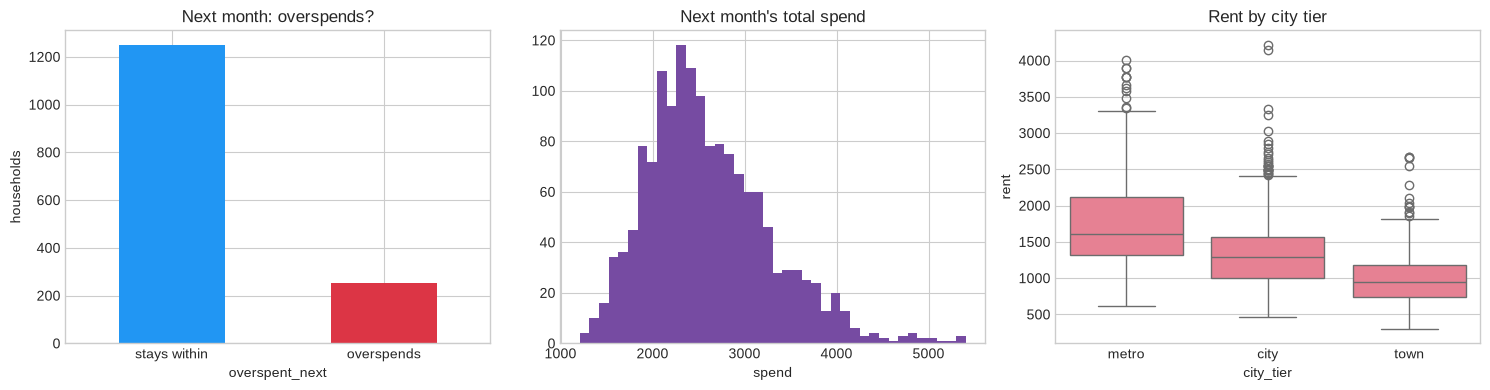

In [5]:
print(hh.head(3).T.to_string())
print()
print(hh[FEATURES].describe(include="all").T.head(12).to_string())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
hh[LABEL_CLS].value_counts().rename({0: "stays within", 1: "overspends"}).plot.bar(ax=axes[0], color=["#2196F3", "#dc3545"])
axes[0].set_title("Next month: overspends?"); axes[0].set_ylabel("households"); axes[0].tick_params(axis="x", rotation=0)
axes[1].hist(hh[LABEL_REG], bins=40, color="#764ba2"); axes[1].set_title("Next month's total spend"); axes[1].set_xlabel("spend")
sns.boxplot(data=hh, x="city_tier", y="rent", ax=axes[2], order=["metro", "city", "town"]); axes[2].set_title("Rent by city tier")
plt.tight_layout(); plt.show()


# Part 1 · What AutoML is; your first predictor in three lines ⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

**AutoML** (automated machine learning) is software that runs the repetitive middle of a modelling project for you: cleaning column types, encoding categories, training a zoo of models, validating them honestly and combining the good ones. **AutoGluon** is the open-source AutoML library from AWS. Its promise is three lines of code: create a `TabularPredictor`, call `.fit()` on a DataFrame, read the `leaderboard`.

Part 1 makes you earn those three lines. Task 1 builds a hand-made baseline so there is something to beat and a table of what AutoML does *not* do. Task 2 runs the three lines, reads every column of the leaderboard, and checks what AutoGluon believed about each column of the data.

</div>


# Task 1 · The AutoML promise and its limits

## 1.1 What AutoGluon automates, and what it leaves to you

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a very fast, very literal junior colleague

Give AutoGluon a table and the name of the label column, and it will do everything a careful junior data scientist does on day one: guess the type of every column, fill gaps, encode text and categories, train eight or ten model families, hold out data to score them, and blend the best ones. It will do it faster and more consistently than a person.

What it cannot do is *understand the question*. It does not know that the label was computed after the features (leakage), that the label is noisy, that the business cares about missed overspenders far more than false alarms, or that the model must answer in five milliseconds. Those decisions are yours, and every later Part of this course is about one of them.

</div>

| AutoGluon automates | You still own |
|---|---|
| **Type inference**: which columns are numeric, categorical, boolean, datetime, text | **Problem framing**: what is one row, what is the target, what is known at prediction time |
| **Missing values**: sensible per-type handling, no crash on `NaN` | **Leakage**: a feature that is a function of the label (Part 4 shows it on purpose) |
| **Encoding**: categories to codes, text to n-grams, booleans to ints | **Label quality**: mislabeled rows are learned faithfully (Part 10 measures the damage) |
| **The model zoo**: gradient boosting (LightGBM, CatBoost, XGBoost), random forests, extra trees, neural networks, k-NN | **Metric choice**: `eval_metric` decides what "best" means (Task 2 and Part 3) |
| **Validation**: a holdout split or k-fold bagging, never scored on training rows | **The decision threshold**: 0.5 is a default, not a decision (Part 3) |
| **Ensembling and stacking**: a weighted blend of members, optional second layer | **Deployment**: latency, memory, monitoring and retraining (Part 9) |
| **Early stopping and time budgets**: stops inside `time_limit` | **Explanation**: what the model learned and whether that is acceptable (Part 6) |


## 1.2 A baseline to beat

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: never run AutoML without a baseline

A baseline is a model so simple that it cannot be wrong in an interesting way. Here it is scikit-learn's `HistGradientBoostingClassifier` on the numeric columns only, default settings, five lines. It sets the bar: if a 60-second AutoGluon run cannot beat it, the extra machinery has bought nothing. It also gives every later comparison a fixed reference row in the report card.

</div>

`HistGradientBoostingClassifier` is a gradient-boosted decision tree model that handles missing values natively, so the 4% of missing `dining` values need no imputation. It cannot read strings, so `city_tier`, `note` and `referral_code` are dropped. That is one decision a hand-built pipeline forces on you; AutoGluon makes it for you in Task 2.


In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier

numeric_cols = [c for c in FEATURES if pd.api.types.is_numeric_dtype(hh[c])]   # HGB reads numbers and booleans only
y_test = test_df[LABEL_CLS].values

with timer("sklearn HistGradientBoosting baseline"):
    baseline = HistGradientBoostingClassifier(random_state=RANDOM_STATE).fit(train_df[numeric_cols], train_df[LABEL_CLS])
baseline_proba = baseline.predict_proba(test_df[numeric_cols])[:, 1]
baseline_card = report_card(y_test, baseline_proba >= 0.5, baseline_proba, name="HGB baseline (numeric only)")

print(f"used {len(numeric_cols)} of {len(FEATURES)} features; dropped: {sorted(set(FEATURES) - set(numeric_cols))}")
print(f"base rate (predict 'never overspends'): accuracy = {1 - y_test.mean():.3f}")
display(pretty(baseline_card))


⏱️ sklearn HistGradientBoosting baseline: 1.62 s
used 16 of 19 features; dropped: ['city_tier', 'note', 'referral_code']
base rate (predict 'never overspends'): accuracy = 0.832


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
HGB baseline (numeric only),0.904,0.778,0.787,0.587,0.673,0.627,0.915,0.791,0.332,0.073


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Read the base rate before the accuracy

The cell printed the accuracy of a model that always says "no". About one household in six overspends, so "no" is right most of the time. Compare the baseline's `accuracy` with that number: the gap is what the model actually learned. `balanced_acc`, `f1`, `mcc` and `roc_auc` do not have this blind spot, which is why the report card carries all of them. Task 4 goes through each family.

</div>

## 1.3 Task 1 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- AutoML automates the mechanical middle of a project: types, missing values, encoding, model zoo, validation, ensembling, time budgets.
- It does not frame the problem, catch leakage, judge label quality, pick the metric, or deploy the model.
- A five-line baseline sets the bar and forces the dropped-columns decision that AutoGluon will make for you.
- Accuracy is only meaningful next to the base rate.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `numeric_cols` | the numeric and boolean feature columns the baseline can read |
| `y_test` | the true `overspent_next` labels of the test split, as a NumPy array |
| `baseline`, `baseline_proba` | the fitted `HistGradientBoostingClassifier` and its test probabilities |
| `baseline_card` | its one-row report card, the reference row for every later comparison |

### ➡️ Next Up

The three lines. Then the leaderboard, column by column.

</div>


# Task 2 · Your first predictor in three lines

## 2.1 The three lines, and what happens inside them

```python
predictor = TabularPredictor(label="overspent_next", eval_metric="roc_auc", path=tmp)
predictor.fit(train_data, time_limit=60, presets="medium_quality")
predictor.leaderboard(test_data)
```

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: what `fit` does with sixty seconds

1. **Infer the problem type** from the label: two distinct values means binary classification.
2. **Infer column types** and build a feature pipeline: numbers pass through, strings become categories, booleans become ints.
3. **Split off a validation set** from the training rows (for `medium_quality`, a single holdout).
4. **Train the model zoo** in a fixed order, giving each model a slice of the remaining time and stopping it early if it is not improving.
5. **Score every model on the validation set** with `eval_metric`.
6. **Fit a weighted ensemble** over the members, choosing the weights that maximise `eval_metric` on validation.

`eval_metric="roc_auc"` tells every one of those steps what "better" means. `presets="medium_quality"` is the fast preset: no bagging, no stacking, a good default zoo. `path` is where every trained model is saved to disk, so a temporary directory keeps the notebook tidy. `verbosity=0` silences the training log; set it to `2` once to see the order of the zoo.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Two rules for this course's fits

- The free-text `note` column is left out of tabular fits until Part 8, which is about text. It has only a handful of distinct values, and section 2.4 shows what AutoGluon would make of it.
- `num_cpus` is capped so the fit behaves the same on a shared machine and on a two-core Colab runtime. Time limits are wall-clock, so a slower machine trains fewer models, not worse ones.

</div>


In [7]:
import os, tempfile, inspect
from autogluon.tabular import TabularPredictor
import autogluon.tabular

# Ensure FEATURES and associated variables are defined locally in case previous cells were not run
ID_COL = "household_id"
LABEL_CLS = "overspent_next"
LABEL_REG = "spend_next"

try:
    # Try to use the globally defined hh DataFrame if it exists
    _columns = hh.columns
except NameError:
    # Fallback to reconstructing the budget and household table
    budget = make_budget(n_households=1500, months=24, seed=RANDOM_STATE)
    hh = household_table(budget)
    train_df, test_df = train_test_split(hh, test_size=0.25, random_state=RANDOM_STATE, stratify=hh[LABEL_CLS])
    train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)
    _columns = hh.columns

FEATURES = [c for c in _columns if c not in (ID_COL, LABEL_CLS, LABEL_REG)]
TAB_FEATURES = [c for c in FEATURES if c != "note"]
N_CPUS = min(4, os.cpu_count() or 1)
MODEL_DIR = tempfile.mkdtemp(prefix="ag_first_")

assert "num_cpus" in inspect.signature(TabularPredictor.fit).parameters

with timer("TabularPredictor.fit (time_limit=60)"):
    predictor = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=MODEL_DIR, verbosity=0).fit(
        train_df[TAB_FEATURES + [LABEL_CLS]], time_limit=60, presets="medium_quality", num_cpus=N_CPUS)

best = predictor.model_best
print(f"AutoGluon {autogluon.tabular.__version__} | problem type: {predictor.problem_type} | eval metric: {predictor.eval_metric.name}")
print(f"models trained: {len(predictor.model_names())} | best on validation: {best}")
print(f"saved under: {MODEL_DIR}")

⏱️ TabularPredictor.fit (time_limit=60): 22.07 s
AutoGluon 1.6.3 | problem type: binary | eval metric: roc_auc
models trained: 12 | best on validation: WeightedEnsemble_L2
saved under: /content/cmpe255/.runtime/tmp/ag_first_mmm3ijo7


## 2.2 The leaderboard, column by column

`predictor.leaderboard(test_df)` scores every trained model on the frame you pass and returns one row per model, sorted by `score_test`. The frame must contain the label column; `test_df` does. Without a frame, the leaderboard only has validation scores and is sorted by `score_val`.

| Column | Meaning |
|---|---|
| `model` | the model's name; the suffix `_L2` means it sits on the second stack level |
| `score_test` | `eval_metric` on the frame you passed (here the test split). Higher is always better: AutoGluon negates metrics like log loss so the sign never flips |
| `score_val` | `eval_metric` on AutoGluon's own validation holdout, the number used to pick the winner and the ensemble weights |
| `eval_metric` | the metric name, so a saved leaderboard is self-describing |
| `pred_time_test`, `pred_time_val` | seconds to predict the whole frame, including every model this one depends on |
| `fit_time` | training seconds, including dependencies |
| `*_marginal` | the same times for this model alone, without its dependencies |
| `stack_level` | 1 for base models, 2 for models that consume base-model predictions |
| `can_infer` | `False` if the model cannot predict on new data (for example a bagged model whose folds were deleted) |
| `fit_order` | the order in which the models were trained |


In [8]:
lb = predictor.leaderboard(test_df)      # quiet by default in 1.6 (display=False); the old silent=True is still accepted
show_cols = ["model", "score_test", "score_val", "pred_time_test", "fit_time", "stack_level", "can_infer", "fit_order"]
display(pretty(lb[show_cols].set_index("model"), subset=["score_test", "score_val"]))

top_val, top_test = lb.sort_values("score_val", ascending=False).iloc[0]["model"], lb.iloc[0]["model"]
print(f"rows are sorted by score_test. winner on validation (model_best) = {top_val}; best on the test split = {top_test}")
print(f"validation rows AutoGluon held out: {predictor.info()['num_rows_val']} of {len(train_df)} training rows")


,score_test,score_val,pred_time_test,fit_time,stack_level,can_infer,fit_order
model,,,,,,,
LightGBMXT,0.939,0.843,0.008090,0.441495,1,True,1
WeightedEnsemble_L2,0.939,0.868,0.202996,8.332970,2,True,12
RandomForestEntr,0.936,0.833,0.132616,1.232804,1,True,4
RandomForestGini,0.936,0.833,0.159405,1.108051,1,True,3
NeuralNetTorch,0.934,0.856,0.030489,4.087949,1,True,10
CatBoost,0.933,0.863,0.011153,3.165379,1,True,5
ExtraTreesEntr,0.931,0.856,0.157406,0.985925,1,True,7
ExtraTreesGini,0.928,0.846,0.168988,0.985177,1,True,6
XGBoost,0.927,0.815,0.018415,0.382504,1,True,9


rows are sorted by score_test. winner on validation (model_best) = WeightedEnsemble_L2; best on the test split = LightGBMXT


validation rows AutoGluon held out: 225 of 1125 training rows


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `score_val` is not your test score

`score_val` comes from AutoGluon's own holdout: the cell printed how many training rows it kept aside, and with about one positive in six that is a small number of positives to rank. The winner is chosen on that holdout, so its `score_val` is optimistic: it is the best of many draws. `score_test` on a split the predictor never saw is the honest number. When the two disagree about the ranking, believe the test column and remember why the model selection was noisy.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: `eval_metric` must match the business question

Every ranking on this leaderboard, and the ensemble weights, were chosen to maximise `roc_auc`. Ask "which households should an advisor call first?" and ROC-AUC (how well the model ranks) is right. Ask "how many households will we flag?" and F1 or a cost-weighted metric is right. Ask "can we trust the 30% as a real 30%?" and log loss is right. Change the question and the whole leaderboard changes; Part 3 fits the same data under three metrics to show it.

</div>


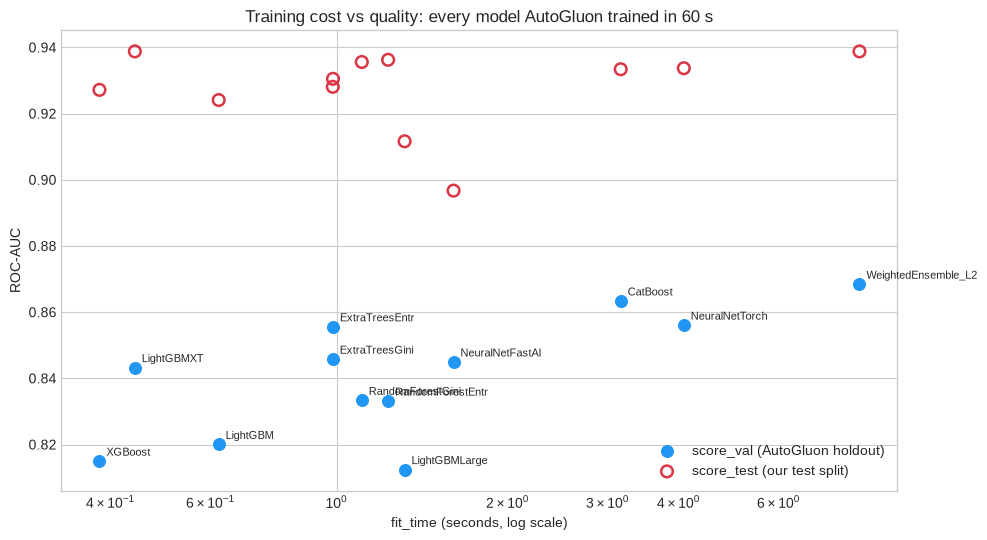

fit_time range: 0.4 s to 8.3 s | score_val range: 0.812 to 0.868


In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(lb["fit_time"], lb["score_val"], s=70, color="#2196F3", label="score_val (AutoGluon holdout)")
ax.scatter(lb["fit_time"], lb["score_test"], s=70, facecolors="none", edgecolors="#dc3545", linewidths=1.8, label="score_test (our test split)")
for _, r in lb.iterrows():
    ax.annotate(r["model"], (r["fit_time"], r["score_val"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("fit_time (seconds, log scale)"); ax.set_ylabel("ROC-AUC")
ax.set_title("Training cost vs quality: every model AutoGluon trained in 60 s")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(f"fit_time range: {lb.fit_time.min():.1f} s to {lb.fit_time.max():.1f} s | score_val range: {lb.score_val.min():.3f} to {lb.score_val.max():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each point is one trained model. The x axis is its training time on a log scale, so a model at the right edge cost ten to a hundred times more than one at the left. Filled blue dots are validation scores, hollow red rings are test scores for the same model, so the vertical gap between a dot and its ring is how much the holdout misjudged that model. The models cluster in a narrow band of ROC-AUC while their costs spread over more than an order of magnitude (the printed ranges give the exact spread): the cheap tree models are within a few hundredths of the expensive ones. The `WeightedEnsemble_L2` point inherits the fit time of its members (only the models it actually uses, not the whole zoo), so it sits to the right of each of them but not necessarily at the far right.

The common misread: taking the highest blue dot as the best model. It is the best *on the holdout*; the ring tells you whether that held up.

</div>

## 2.3 Predict, predict_proba, evaluate

Three ways to get answers out of the predictor:

- `predict(df)` returns labels, using a 0.5 threshold on the positive-class probability.
- `predict_proba(df)` returns one column per class; column `1` is P(overspends).
- `evaluate(df)` returns a dictionary of metrics on a labelled frame, computed by the same code that filled the leaderboard.

The report card takes the probabilities and the thresholded labels, so its row and `evaluate` should agree wherever they share a metric.


In [10]:
proba = predictor.predict_proba(test_df)[1].values       # P(overspent_next = 1) for the best model
pred = predictor.predict(test_df).values                 # labels at the default 0.5 threshold
assert np.array_equal(pred, (proba >= 0.5).astype(int)), "predict() is predict_proba() thresholded at 0.5"

ag_card = report_card(y_test, pred, proba, name=f"AutoGluon {best} (60 s)")
cards = pd.concat([baseline_card, ag_card])
display(pretty(cards))

ag_eval = predictor.evaluate(test_df, auxiliary_metrics=True)
agree = pd.DataFrame({"evaluate()": {k: ag_eval[k] for k in ("roc_auc", "accuracy", "f1", "precision", "recall", "mcc")},
                      "report_card": ag_card.iloc[0][["roc_auc", "accuracy", "f1", "precision", "recall", "mcc"]].astype(float)})
agree["max_abs_diff"] = (agree["evaluate()"] - agree["report_card"]).abs()
print(agree.round(4).to_string())
print(f"\nP(overspends) for the first 5 test households: {np.round(proba[:5], 3)} -> labels {pred[:5]}")


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
HGB baseline (numeric only),0.904,0.778,0.787,0.587,0.673,0.627,0.915,0.791,0.332,0.073
AutoGluon WeightedEnsemble_L2 (60 s),0.920,0.806,0.851,0.635,0.727,0.692,0.939,0.819,0.224,0.065


           evaluate()  report_card  max_abs_diff
roc_auc        0.9388       0.9388           0.0
accuracy       0.9200       0.9200           0.0
f1             0.7273       0.7273           0.0
precision      0.8511       0.8511           0.0
recall         0.6349       0.6349           0.0
mcc            0.6916       0.6916           0.0

P(overspends) for the first 5 test households: [0.443 0.301 0.043 0.047 0.028] -> labels [0 0 0 0 0]


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway: two report rows, one honest comparison

The two rows of `cards` were computed by the same function on the same 375 test households, so every column is comparable. Read `roc_auc` first, because it is what both were asked to be good at, then `pr_auc` and `log_loss`, which the baseline was never optimised for either. The `agree` table shows `evaluate()` and `report_card` matching to four decimals: AutoGluon's metrics are scikit-learn's metrics, nothing exotic.

</div>

## 2.4 What AutoGluon believed about every column

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: type inference is a guess, and you should read it

Before training anything, AutoGluon looks at every column and decides what it *is*. Integers with two values become booleans; strings with few distinct values become categories; strings with many distinct values and several words become **text** and are expanded into n-gram counts. The guess is usually right and occasionally expensive: an ID column mistaken for a category, or a category mistaken for text. `feature_metadata_in` shows the raw types it saw; `feature_metadata` shows the types after its own preprocessing.

The rule for text in 1.6.3 (`autogluon.common.features.infer_types.check_if_nlp_feature`) is concrete: an object column is text if its number of distinct values exceeds 1% of the rows *and* the distinct values average at least three words. The cell computes both numbers for `note`.

</div>


In [11]:
from autogluon.common.features.feature_metadata import FeatureMetadata

print("RAW types AutoGluon saw (feature_metadata_in):")
print(predictor.feature_metadata_in)
print("\nTYPES after its preprocessing (feature_metadata):")
print(predictor.feature_metadata)

# the same inference on the full feature list, `note` included, without fitting anything
fm_note = FeatureMetadata.from_df(train_df[FEATURES])
note_unique_ratio = train_df["note"].nunique() / len(train_df)
note_avg_words = pd.Series(train_df["note"].unique()).str.split().str.len().mean()
print(f"\n`note`: raw type = {fm_note.get_feature_type_raw('note')}; distinct/rows = {note_unique_ratio:.4f} (text needs > 0.01); "
      f"avg words per distinct value = {note_avg_words:.1f} (text needs >= 3) -> treated as a CATEGORY, not text")
print(f"`referral_code`: {train_df['referral_code'].isna().mean():.1%} missing in train; raw type = {fm_note.get_feature_type_raw('referral_code')} "
      f"-> a category with a missing level, no imputation needed")
print(f"`owns_car`: raw {fm_note.get_feature_type_raw('owns_car')} -> after preprocessing "
      f"{predictor.feature_metadata.get_feature_type_raw('owns_car')} with special types {predictor.feature_metadata.get_feature_types_special('owns_car')}")


RAW types AutoGluon saw (feature_metadata_in):
('bool', [])   :  1 | ['owns_car']
('float', [])  : 12 | ['income', 'rent', 'groceries', 'utilities', 'transport', ...]
('int', [])    :  3 | ['household_size', 'overspent', 'survey_score']
('object', []) :  2 | ['city_tier', 'referral_code']

TYPES after its preprocessing (feature_metadata):
('category', [])  :  2 | ['city_tier', 'referral_code']
('float', [])     : 12 | ['income', 'rent', 'groceries', 'utilities', 'transport', ...]
('int', [])       :  2 | ['household_size', 'survey_score']
('int', ['bool']) :  2 | ['owns_car', 'overspent']

`note`: raw type = object; distinct/rows = 0.0071 (text needs > 0.01); avg words per distinct value = 4.9 (text needs >= 3) -> treated as a CATEGORY, not text
`referral_code`: 8.4% missing in train; raw type = object -> a category with a missing level, no imputation needed
`owns_car`: raw bool -> after preprocessing int with special types ['bool']


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `note` is not text to AutoGluon, and that is correct

The notes are eight templated sentences, so the distinct-value ratio is far below the 1% rule and AutoGluon files `note` as a category. That is the right call: eight levels carry exactly as much information as eight one-hot columns, and an n-gram expansion would only add noise. Part 8 replaces the templated notes with richer text and shows when the text path earns its cost. Whenever a fit surprises you, print `feature_metadata` first: a numeric column read as a category, or an ID read as a feature, explains more failures than any hyperparameter.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the fit checklist

Before reading any score: (1) `predictor.problem_type` is what you meant; (2) `predictor.feature_metadata_in` has no ID or leaked column; (3) the label was not in the features; (4) `predictor.info()["num_rows_val"]` is large enough to trust `score_val`. Each takes one line and each has saved a project.

</div>

## 2.5 Task 2 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `TabularPredictor(label, eval_metric, path).fit(df, time_limit, presets)` infers types, splits a holdout, trains a zoo and blends it, all steered by `eval_metric`.
- The leaderboard has two scores: `score_val` chose the winner and is optimistic; `score_test` on your own split is the honest one.
- Training cost spreads over orders of magnitude while quality sits in a narrow band; the ensemble inherits the cost of all its members.
- `predict` is `predict_proba` at 0.5; `evaluate` and `report_card` agree because both are scikit-learn metrics.
- Read `feature_metadata_in` and `feature_metadata` before trusting a fit; `note` is a category here by AutoGluon's 1% / three-word rule.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `TAB_FEATURES`, `N_CPUS`, `MODEL_DIR` | the tabular feature list without `note`, the CPU cap, the predictor's save directory |
| `predictor`, `best` | the fitted `TabularPredictor` and the name of its best model on validation |
| `lb` | the test-split leaderboard, one row per model |
| `proba`, `pred` | test probabilities of class 1 and labels at the 0.5 threshold |
| `ag_card`, `cards`, `ag_eval` | the predictor's report card, the two-row comparison with the baseline, and `evaluate()`'s dictionary |
| `fm_note` | `FeatureMetadata` inferred on all features including `note` |

### ➡️ Next Up

Part 2 looks at the data the leaderboard was built on, the metric families and where each lies, and the ensemble at the top of the board.

</div>


# Part 2 · Reading the leaderboard; metrics that matter; the data, analysed ⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A leaderboard is only as good as the data under it and the metric on top of it. Part 2 does the analysis that should come *before* the leaderboard (Task 3), sorts every classification metric into three families and shows the exact situation in which each one lies (Task 4), and opens the `WeightedEnsemble_L2` at the top of the board to see why blending disagreeing models helps (Task 5).

</div>


# Task 3 · The data, analysed

## 3.1 Why analyse data a model already fit

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the leaderboard cannot tell you what it did not see

AutoGluon reports how well its models scored. It does not report that incomes are skewed, that December spending spikes, that two categories move together, or that a tenth of one column is missing. Those facts decide which metric to trust, which features to expect at the top of the importance list, and which segments will fail first. Six pictures, each with one question.

</div>


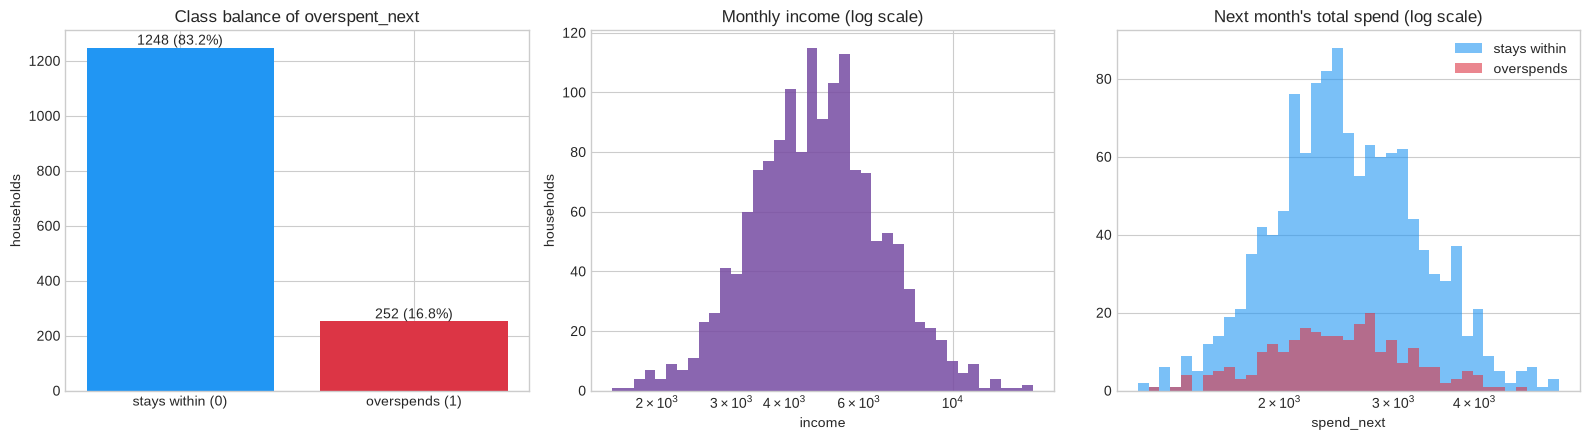

positive rate: 16.8% | income median 4,756, mean 5,062 | spend_next median 2,488, mean 2,606


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
counts = hh[LABEL_CLS].value_counts().sort_index()
axes[0].bar(["stays within (0)", "overspends (1)"], counts.values, color=["#2196F3", "#dc3545"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v} ({v / len(hh):.1%})", ha="center", va="bottom")
axes[0].set_title("Class balance of overspent_next"); axes[0].set_ylabel("households")

log_bins = np.logspace(np.log10(hh["income"].min()), np.log10(hh["income"].max()), 40)
axes[1].hist(hh["income"], bins=log_bins, color="#764ba2", alpha=0.85); axes[1].set_xscale("log")
axes[1].set_title("Monthly income (log scale)"); axes[1].set_xlabel("income"); axes[1].set_ylabel("households")

for lab, col, c in ((0, "#2196F3", "stays within"), (1, "#dc3545", "overspends")):
    sub = hh.loc[hh[LABEL_CLS] == lab, LABEL_REG]
    axes[2].hist(sub, bins=np.logspace(np.log10(hh[LABEL_REG].min()), np.log10(hh[LABEL_REG].max()), 40), alpha=0.6, color=col, label=c)
axes[2].set_xscale("log"); axes[2].set_title("Next month's total spend (log scale)"); axes[2].set_xlabel("spend_next"); axes[2].legend()
plt.tight_layout(); plt.show()
print(f"positive rate: {hh[LABEL_CLS].mean():.1%} | income median {hh.income.median():,.0f}, mean {hh.income.mean():,.0f} | "
      f"spend_next median {hh[LABEL_REG].median():,.0f}, mean {hh[LABEL_REG].mean():,.0f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the class balance. The red bar is about a sixth of the blue one, which is the whole reason accuracy is a poor headline metric here. Middle: income on a log axis is roughly bell-shaped, which means the raw values are right-skewed (a long tail of high earners); the printed mean sits above the median for the same reason. Right: next month's spend for the two classes on the same log axis. Overspenders spend more, but the two humps overlap heavily, so spend alone cannot separate the classes; the model needs income too, since the label is defined relative to it.

The common misread: seeing a bell on a log axis and reporting the variable as normally distributed. It is log-normal, and its mean and median differ.

</div>


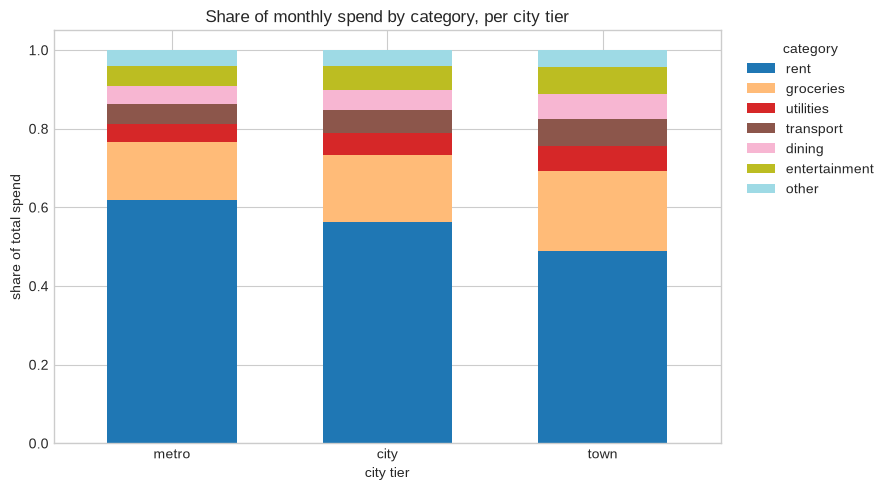

           rent  groceries  utilities  transport  dining  entertainment  other
city_tier                                                                     
metro      61.8       14.8        4.7        5.0     4.4            5.1    4.1
city       56.2       17.2        5.5        5.7     5.2            6.1    4.0
town       48.9       20.3        6.5        6.7     6.5            6.9    4.2

overspend rate by tier: {'city': 0.127, 'metro': 0.277, 'town': 0.082}


In [13]:
SPEND_CATS = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]
share = hh.groupby("city_tier")[SPEND_CATS].mean()
share = share.div(share.sum(axis=1), axis=0).loc[["metro", "city", "town"]]

ax = share.plot.bar(stacked=True, figsize=(9, 5), colormap="tab20", width=0.6)
ax.set_title("Share of monthly spend by category, per city tier"); ax.set_xlabel("city tier"); ax.set_ylabel("share of total spend")
ax.tick_params(axis="x", rotation=0); ax.legend(title="category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
print((share * 100).round(1).to_string())
print(f"\noverspend rate by tier: {hh.groupby('city_tier')[LABEL_CLS].mean().round(3).to_dict()}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each bar is one city tier; the segments are the average share of monthly spend going to each category, so every bar sums to one. The bottom segment, rent, shrinks from metro to town, and every other segment grows to fill the space. The printed overspend rates show the consequence: the tier with the largest rent share has the least slack, so a small shock tips it over the line. This is why `city_tier` is a useful categorical feature even though it never appears in the arithmetic of the label.

The common misread: reading segment heights as absolute amounts. They are shares; metro households spend more in total *and* devote more of it to rent.

</div>


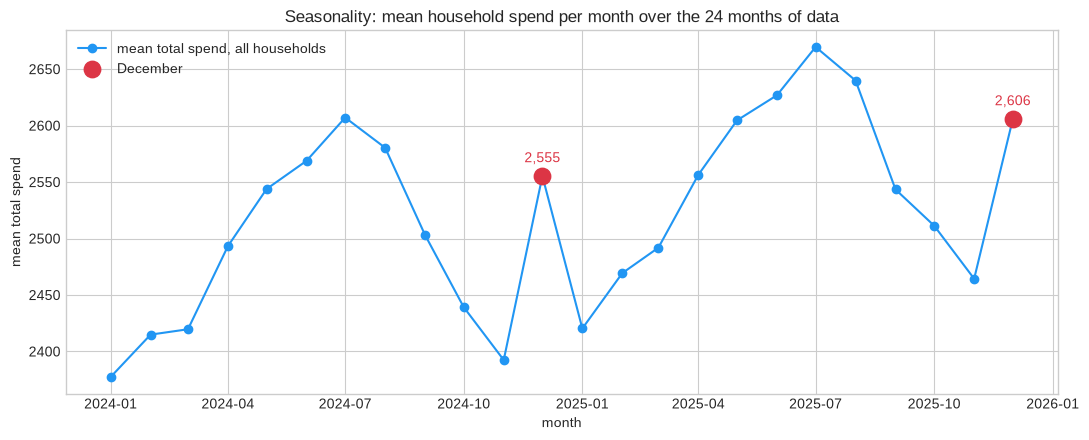

December mean 2,580 vs other months 2,515 (+2.6%)
the household table uses 2025-11 as the feature month and 2025-12 as the target month


In [14]:
monthly = budget.groupby("month")["total_spend"].mean()
dec = monthly[monthly.index.month == 12]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", color="#2196F3", label="mean total spend, all households")
ax.scatter(dec.index, dec.values, s=140, color="#dc3545", zorder=5, label="December")
for d, v in dec.items():
    ax.annotate(f"{v:,.0f}", (d, v), xytext=(0, 10), textcoords="offset points", ha="center", color="#dc3545")
ax.set_title("Seasonality: mean household spend per month over the 24 months of data")
ax.set_xlabel("month"); ax.set_ylabel("mean total spend"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
print(f"December mean {dec.mean():,.0f} vs other months {monthly[monthly.index.month != 12].mean():,.0f} "
      f"({dec.mean() / monthly[monthly.index.month != 12].mean() - 1:+.1%})")
months = sorted(budget.month.unique())
print(f"the household table uses {pd.Timestamp(months[-2]):%Y-%m} as the feature month and {pd.Timestamp(months[-1]):%Y-%m} as the target month")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The line is the average household's total spend, month by month, over the two years in the data. It rises and falls with the year and lifts in the two Decembers, marked in red with their values. The printed ratio is the size of that lift against every other month, and it is only a few percent: rent, the largest category, does not follow the season, so a large seasonal swing in groceries, dining and entertainment becomes a small swing in the total. This matters for the classification task: the household table's features come from the second-to-last month and its targets from the last, so the model is asked to predict a specific month of the year, and a seasonal shift between the two months is baked into every prediction. It matters even more for Part 7, where the forecaster has to learn this shape from 24 points per household.

The common misread: reading a few percent on the total as "no seasonality". The seasonal categories move far more than the total does; Part 7 has to forecast the total, and a forecaster that ignores the shape will miss every December.

</div>


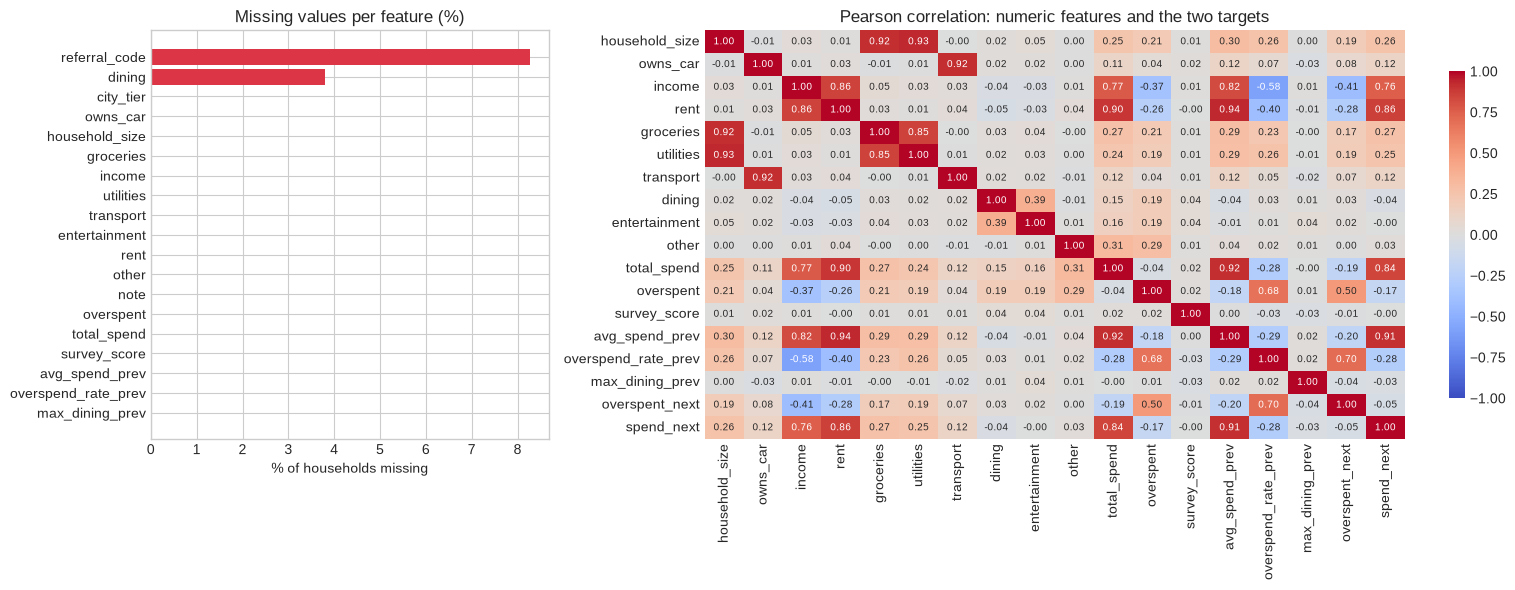

missing: {'referral_code': '8.3%', 'dining': '3.8%'}
strongest correlations with overspent_next: {'overspend_rate_prev': 0.703, 'overspent': 0.495, 'income': 0.409, 'rent': 0.278}
strongest correlations with spend_next: {'avg_spend_prev': 0.909, 'rent': 0.862, 'total_spend': 0.844, 'income': 0.758}
dining vs entertainment: r = 0.388  (the planted interaction)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 2.2]})

miss = hh[FEATURES].isna().mean().sort_values(ascending=False)
axes[0].barh(miss.index[::-1], (miss.values * 100)[::-1], color=np.where(miss.values[::-1] > 0, "#dc3545", "#cccccc"))
axes[0].set_title("Missing values per feature (%)"); axes[0].set_xlabel("% of households missing")

num_feats = numeric_cols + [LABEL_CLS, LABEL_REG]
corr = hh[num_feats].astype(float).corr()
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title("Pearson correlation: numeric features and the two targets")
plt.tight_layout(); plt.show()

with_target = corr[[LABEL_CLS, LABEL_REG]].drop(index=[LABEL_CLS, LABEL_REG])
print("missing:", {k: f"{v:.1%}" for k, v in miss[miss > 0].items()})
print(f"strongest correlations with {LABEL_CLS}: {with_target[LABEL_CLS].abs().sort_values(ascending=False).head(4).round(3).to_dict()}")
print(f"strongest correlations with {LABEL_REG}: {with_target[LABEL_REG].abs().sort_values(ascending=False).head(4).round(3).to_dict()}")
print(f"dining vs entertainment: r = {corr.loc['dining', 'entertainment']:.3f}  (the planted interaction)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: only two features have gaps, and the printed percentages are small. AutoGluon handled both without a line of imputation code; a scikit-learn pipeline would have needed a `SimpleImputer` for `dining` and a fill value for `referral_code`. Right: the correlation heatmap between every numeric feature and both targets. The last two rows are the ones to read: `spend_next` correlates strongly with the history average `avg_spend_prev`, with `rent` and with this month's `total_spend` (households are consistent from month to month), while `overspent_next` correlates most with the history rate `overspend_rate_prev`, then this month's `overspent` and `income`. The printed rankings give the exact values. The off-target block shows `dining` and `entertainment` moving together at a moderate correlation, the interaction the generator planted.

The common misread: treating a weak Pearson correlation as "not useful". Pearson measures straight-line association only. `city_tier` is not even on this map, and the boosted trees in the leaderboard find threshold and interaction effects that a correlation coefficient cannot see.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Two features that look like leaks and are not

`total_spend` and `overspent` are *this* month's values and correlate strongly with *next* month's targets. They are legitimate: at prediction time this month is over and known. The leak would be using next month's categories, which sum to next month's total. Part 4 builds that wrong table on purpose and shows the R² it produces.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: six pictures before any leaderboard

Class balance (which metric), distributions on a log axis (which transforms and which errors will dominate), category shares by segment (which segments will fail), seasonality (what the feature and target months look like), missingness (what the pipeline must survive), correlation with the targets (what importance should show later). Twenty lines of code, and every later Part refers back to one of them.

</div>

## 3.2 Task 3 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- About one household in six overspends; income and spend are log-normal, so means exceed medians.
- Rent share falls from metro to town and overspend rate follows it: `city_tier` matters through slack, not arithmetic.
- December lifts the total by a few percent (rent hides most of the seasonal swing); the classification task predicts one specific month, the forecasting task must learn the whole shape.
- Only `dining` and `referral_code` have gaps, and AutoGluon handled both silently.
- This month's `total_spend` and `overspent` are legitimate predictors of next month; correlation only sees straight lines.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `SPEND_CATS`, `share` | the seven spend categories and their mean share per city tier |
| `monthly`, `dec` | mean total spend per month over the 24 months, and the December rows |
| `miss`, `corr`, `with_target` | missingness per feature, the numeric correlation matrix, and its two target columns |

### ➡️ Next Up

Every classification metric, sorted into three families, with the exact situation in which each one lies.

</div>


# Task 4 · The metric families for classification

## 4.1 Three families, one table

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: what the metric looks at

A classifier outputs a probability. A metric can look at the **label** you get after thresholding it (threshold metrics), at the **order** the probabilities put the households in (ranking metrics), or at the **probability value itself** (probabilistic metrics). Each family answers a different question, and each has a situation where it gives a confidently wrong answer.

</div>

| Family | Metrics | Looks at | Answers |
|---|---|---|---|
| **Threshold** | accuracy, balanced accuracy, precision, recall, F1, MCC | labels at one threshold | "how good are the decisions at this cut-off?" |
| **Ranking** | ROC-AUC, PR-AUC (average precision) | the order of the scores | "if I sort households by risk, are the overspenders at the top?" |
| **Probabilistic** | log loss, Brier score | the probability values | "can the 30% be trusted as a 30%?" |

### 📐 The Math (gently)

With true positives $TP$, false positives $FP$, false negatives $FN$ and true negatives $TN$ at a threshold:

$$ \text{precision} = \frac{TP}{TP + FP}, \qquad \text{recall} = \frac{TP}{TP + FN}, \qquad F_1 = \frac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}} $$

$$ \text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}} \in [-1, 1] $$

ROC-AUC is the probability that a random positive gets a higher score than a random negative. PR-AUC is the area under the precision-recall curve, whose baseline is the positive rate rather than 0.5. For probabilities $p_i$ and labels $y_i \in \{0, 1\}$:

$$ \text{log loss} = -\frac{1}{n}\sum_i \big[ y_i \log p_i + (1 - y_i) \log (1 - p_i) \big], \qquad \text{Brier} = \frac{1}{n} \sum_i (p_i - y_i)^2 $$

Log loss punishes a confident wrong answer without limit; the Brier score caps the penalty at 1 per row.


In [16]:
# three "models" that make the families disagree: the predictor, the always-no rule, and a coin flip
rng = np.random.default_rng(RANDOM_STATE)
never = np.zeros(len(y_test))
coin = rng.random(len(y_test))
family_cards = pd.concat([
    ag_card,
    report_card(y_test, never.astype(int), np.full(len(y_test), y_test.mean()), name="always 'no' (base rate prob)"),
    report_card(y_test, (coin >= 0.5).astype(int), coin, name="coin flip"),
])
display(pretty(family_cards))

never_row, ag_row = family_cards.iloc[1], family_cards.iloc[0]
print(f"always-'no' accuracy {never_row['accuracy']:.3f} vs predictor {ag_row['accuracy']:.3f}: the threshold family barely separates them; "
      f"roc_auc {never_row['roc_auc']:.2f} vs {ag_row['roc_auc']:.3f} does")


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
AutoGluon WeightedEnsemble_L2 (60 s),0.920,0.806,0.851,0.635,0.727,0.692,0.939,0.819,0.224,0.065
always 'no' (base rate prob),0.832,0.500,0.000,0.000,0.000,0.000,0.500,0.168,0.453,0.140
coin flip,0.504,0.499,0.168,0.492,0.250,-0.001,0.520,0.189,0.934,0.320


always-'no' accuracy 0.832 vs predictor 0.920: the threshold family barely separates them; roc_auc 0.50 vs 0.939 does


## 4.2 When each family lies

| Situation | Metric that lies | Why | What to read instead |
|---|---|---|---|
| Imbalanced classes (here about one positive in six) | **accuracy** | "always no" scores the base rate without learning anything; the table above shows the gap is small | balanced accuracy, F1, MCC, PR-AUC |
| Heavy imbalance, many negatives | **ROC-AUC** | its false-positive rate is divided by a huge number of negatives, so thousands of false alarms barely move it | PR-AUC, which ignores true negatives entirely |
| Overconfidence | **every threshold and ranking metric** | thresholded labels do not change when a 0.6 becomes a 0.99, and neither does the order of the households | log loss, Brier: the probabilistic family is the only one that sees the probability values |
| Threshold chosen to look good on test | **every threshold metric** | the threshold is a parameter fitted to the test set | choose it on validation (Part 3) |

The next cell shows the third row twice. First, every probability is **sharpened**: pushed toward 0 or 1 by the monotone map $p \mapsto p^3 / (p^3 + (1-p)^3)$, which keeps 0.5 fixed and keeps the order of the households, so no label and no ranking changes. Second, only the households the model got wrong are pushed to an extreme on the wrong side; again no label changes, but now the order does.


In [17]:
wrong = pred != y_test
sharpened = proba ** 3 / (proba ** 3 + (1 - proba) ** 3)       # monotone, fixes 0.5: same labels, same order, bolder numbers
overconfident = proba.copy()
overconfident[wrong & (pred == 1)] = 0.999                     # false positives, now sure of themselves
overconfident[wrong & (pred == 0)] = 0.001                     # false negatives, now sure of themselves
for p_ in (sharpened, overconfident):
    assert np.array_equal((p_ >= 0.5).astype(int), pred), "labels unchanged"

conf_cards = pd.concat([ag_card,
                        report_card(y_test, pred, sharpened, name="same labels, same order, sharpened"),
                        report_card(y_test, pred, overconfident, name="same labels, confident mistakes")])
display(pretty(conf_cards, highlight=None))
for i in (1, 2):
    delta = (conf_cards.iloc[i] - conf_cards.iloc[0]).round(3)
    print(f"{conf_cards.index[i]}: changed {dict(delta[delta != 0])} | unchanged {list(delta[delta == 0].index)}")
print(f"({wrong.sum()} of {len(y_test)} test households were misclassified)")


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
AutoGluon WeightedEnsemble_L2 (60 s),0.920,0.806,0.851,0.635,0.727,0.692,0.939,0.819,0.224,0.065
"same labels, same order, sharpened",0.920,0.806,0.851,0.635,0.727,0.692,0.939,0.819,0.314,0.067
"same labels, confident mistakes",0.920,0.806,0.851,0.635,0.727,0.692,0.621,0.491,0.658,0.101


same labels, same order, sharpened: changed {'log_loss': np.float64(0.09), 'brier': np.float64(0.002)} | unchanged ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'mcc', 'roc_auc', 'pr_auc']
same labels, confident mistakes: changed {'roc_auc': np.float64(-0.318), 'pr_auc': np.float64(-0.328), 'log_loss': np.float64(0.434), 'brier': np.float64(0.036)} | unchanged ['accuracy', 'balanced_acc', 'precision', 'recall', 'f1', 'mcc']
(30 of 375 test households were misclassified)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Same accuracy, same F1, different model

Row two, the sharpened probabilities: every threshold metric and both ranking metrics are unchanged, and only `log_loss` and `brier` moved. Eight of the ten columns cannot tell a model that says 0.6 from one that says 0.95 for the same households in the same order. The printed sign of the change tells you whether the original model was too timid or too bold; either way, only the probabilistic family noticed. Row three, the confident mistakes: the threshold metrics are still identical, but now the ranking metrics fell too, and sharply, because a false positive at 0.999 outranks every true overspender. Log loss moved most of all, since one 0.999 on a household that did not overspend costs $-\log(0.001)$ on that row. If the probabilities feed a decision with costs, a limit, or a human reading "99% risk", the probabilistic family is the one to optimise. Part 3 makes this concrete with calibration.

</div>

## 4.3 ROC and precision-recall curves, side by side

A threshold metric is one point; a curve is every threshold at once. The ROC curve plots true-positive rate against false-positive rate; its no-skill line is the diagonal. The PR curve plots precision against recall; its no-skill line is horizontal at the positive rate, which is why PR-AUC values look lower and are more informative under imbalance.


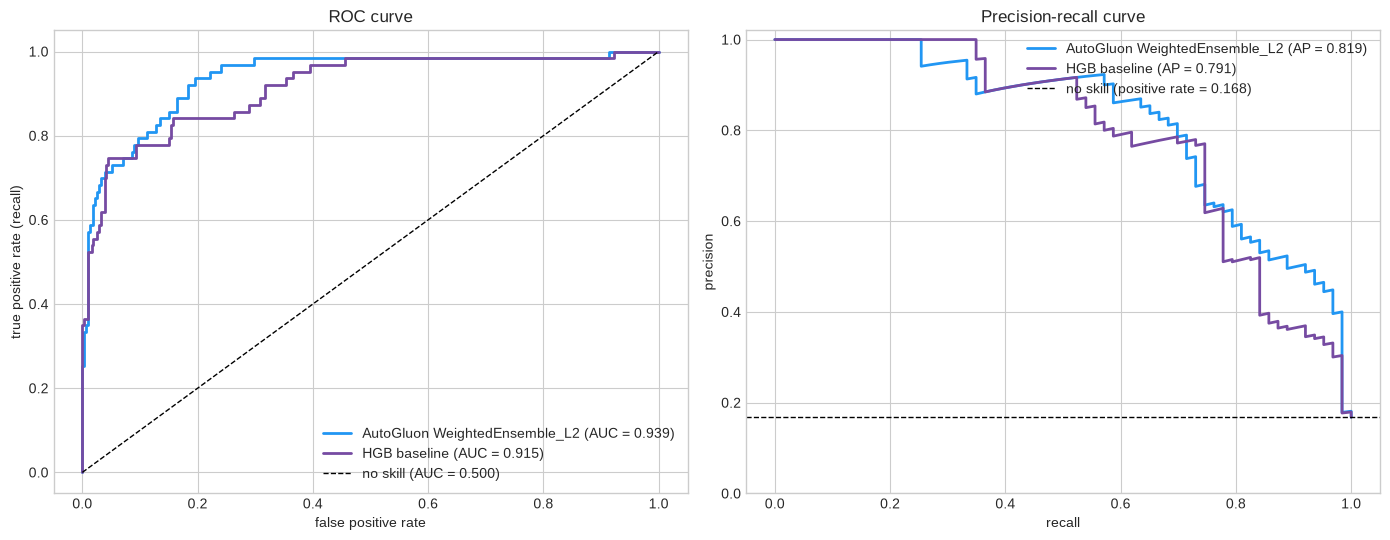

at the default 0.5 threshold: recall = 0.635, precision = 0.851
threshold that reaches recall >= 0.9: 0.138, with false positive rate 0.183


In [18]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for name, p, c in ((f"AutoGluon {best}", proba, "#2196F3"), ("HGB baseline", baseline_proba, "#764ba2")):
    fpr, tpr, _ = roc_curve(y_test, p); prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
    axes[1].plot(rec, prec, color=c, lw=2, label=f"{name} (AP = {average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="no skill (AUC = 0.500)")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1, label=f"no skill (positive rate = {y_test.mean():.3f})")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate (recall)"); axes[0].set_title("ROC curve")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-recall curve"); axes[1].set_ylim(0, 1.02)
for ax in axes: ax.legend(loc="lower right" if ax is axes[0] else "upper right")
plt.tight_layout(); plt.show()

fpr, tpr, thr = roc_curve(y_test, proba)
print(f"at the default 0.5 threshold: recall = {ag_card.iloc[0]['recall']:.3f}, precision = {ag_card.iloc[0]['precision']:.3f}")
print(f"threshold that reaches recall >= 0.9: {thr[np.argmax(tpr >= 0.9)]:.3f}, with false positive rate {fpr[np.argmax(tpr >= 0.9)]:.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left, the ROC curves of the AutoGluon predictor and the baseline against the diagonal; the further a curve bows toward the top-left corner, the better the ranking, and the legend carries the areas. Right, the same two models as precision-recall curves against the horizontal no-skill line at the positive rate. The PR curve is the harsher picture: precision falls quickly as recall approaches one, because catching the last overspenders means flagging many households that stay within budget. The printed threshold for 90% recall shows what that costs in false alarms. Both curves are drawn from the same probabilities; the ROC curve simply hides the cost of false alarms behind a large denominator of negatives.

The common misread: comparing the two areas as if they were on one scale. ROC-AUC's floor is 0.5, PR-AUC's floor is the positive rate; a PR-AUC three times its floor is a strong model.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: report one metric per family, always

A report card with `roc_auc`, `f1` and `log_loss` cannot be fooled by any one of the four situations in the table above. That is why `report_card` returns all three families in one row and why every Part of this course compares models with it rather than with a single number.

</div>

## 4.4 Task 4 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Threshold metrics look at labels, ranking metrics at order, probabilistic metrics at the values; each answers a different question.
- Accuracy lies under imbalance: the always-"no" rule scores close to the predictor. ROC-AUC lies under heavy imbalance because its denominator is the negatives.
- Only log loss and Brier see the probability values: sharpening every probability left eight of ten columns identical, and pushing the mistakes to the extremes left every threshold metric identical.
- The PR curve's floor is the positive rate, so it shows the true cost of high recall.
- `evaluate()` and `report_card` agree because both are scikit-learn metrics; report one metric per family.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `family_cards` | the predictor against the always-"no" rule and a coin flip |
| `sharpened`, `overconfident`, `conf_cards` | monotone-sharpened probabilities, probabilities with the mistakes pushed to 0.999 / 0.001, and the three-row card |
| `wrong` | boolean mask of misclassified test households |

### ➡️ Next Up

The leaderboard beyond `score`: sizes, ancestors, the ensemble's weights, and why its members' disagreement is the point.

</div>


# Task 5 · The leaderboard beyond score

## 5.1 `extra_info=True`, `model_names()`, `model_best`

`leaderboard(df, extra_info=True)` adds two dozen columns: how many features each model consumed, its size in memory, its model class, and its **ancestors** (the models whose predictions it takes as input) and **descendants** (the models that consume it). `model_names()` lists trained models and takes filters (`stack_name`, `level`, `can_infer`). `model_best` is the winner on validation; in 1.6.3 it is a property, and the older `get_model_best()` method is gone.


In [19]:
lb_x = predictor.leaderboard(test_df, extra_info=True)
x_cols = ["model", "score_test", "score_val", "num_features", "memory_size", "model_type", "num_ancestors", "ancestors", "fit_order"]
lb_x_show = lb_x[x_cols].copy(); lb_x_show["memory_size"] = (lb_x_show["memory_size"] / 1024).round(1).astype(str) + " KB"
display(lb_x_show.set_index("model"))

print("all models:          ", predictor.model_names())
print("stack level 1 only:  ", predictor.model_names(level=1))
print("stack level 2 only:  ", predictor.model_names(level=2))
print("model_best property: ", predictor.model_best, "| get_model_best() exists:", hasattr(predictor, "get_model_best"))
print(f"extra_info added {len(lb_x.columns) - len(lb.columns)} columns; the ensemble's num_features counts base-model predictions, not raw columns")


,score_test,score_val,num_features,memory_size,model_type,num_ancestors,ancestors,fit_order
model,,,,,,,,
LightGBMXT,0.938797,0.843231,18,128.4 KB,LGBModel,0,[],1
WeightedEnsemble_L2,0.938797,0.868421,3,4.3 KB,WeightedEnsembleModel,3,"[ExtraTreesEntr, NeuralNetTorch, CatBoost]",12
RandomForestEntr,0.936254,0.833099,18,3109.1 KB,RFModel,0,[],4
RandomForestGini,0.935592,0.833310,18,3331.5 KB,RFModel,0,[],3
NeuralNetTorch,0.933710,0.856037,18,271.5 KB,TabularNeuralNetTorchModel,0,[],10
CatBoost,0.933405,0.863355,18,69.6 KB,CatBoostModel,0,[],5
ExtraTreesEntr,0.930505,0.855545,18,5822.2 KB,XTModel,0,[],7
ExtraTreesGini,0.928088,0.845764,18,5896.0 KB,XTModel,0,[],6
XGBoost,0.927172,0.814945,18,440.7 KB,XGBoostModel,0,[],9


all models:           ['LightGBMXT', 'LightGBM', 'RandomForestGini', 'RandomForestEntr', 'CatBoost', 'ExtraTreesGini', 'ExtraTreesEntr', 'NeuralNetFastAI', 'XGBoost', 'NeuralNetTorch', 'LightGBMLarge', 'WeightedEnsemble_L2']
stack level 1 only:   ['LightGBMXT', 'LightGBM', 'RandomForestGini', 'RandomForestEntr', 'CatBoost', 'ExtraTreesGini', 'ExtraTreesEntr', 'NeuralNetFastAI', 'XGBoost', 'NeuralNetTorch', 'LightGBMLarge']
stack level 2 only:   ['WeightedEnsemble_L2']
model_best property:  WeightedEnsemble_L2 | get_model_best() exists: False
extra_info added 22 columns; the ensemble's num_features counts base-model predictions, not raw columns


## 5.2 What `WeightedEnsemble_L2` is

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a committee that votes with unequal weight

The model at the top of most AutoGluon leaderboards is not a model at all. It is a **weighted average of the other models' probabilities**, with weights chosen to maximise `eval_metric` on the validation set. Its `stack_level` is 2 because it consumes level-1 predictions; its `ancestors` are exactly the members with non-zero weight. AutoGluon finds the weights by *greedy ensemble selection*: start with an empty committee, repeatedly add the member (with replacement) that improves the validation score the most, and stop when nothing helps. The weights are the membership counts, normalised. Members that never help get weight zero and are dropped.

</div>

### 📐 The Math (gently)

With member probabilities $p_1(x), \dots, p_M(x)$ and weights $w_m \ge 0$, $\sum_m w_m = 1$:

$$ p_{\text{ens}}(x) = \sum_{m=1}^{M} w_m \, p_m(x) $$

Averaging helps because the members' errors are only partly shared. If two members each make independent mistakes with variance $\sigma^2$, their average has variance $\sigma^2 / 2$; if their mistakes are identical, averaging changes nothing. The correlation heatmap in 5.3 is the direct test of which case you are in.


WeightedEnsemble_L2: type WeightedEnsembleModel, stack level {'num_base_models': 3, 'base_model_names': ['CatBoost', 'ExtraTreesEntr', 'NeuralNetTorch']}, val score 0.8684
weights from predictor._trainer.load_model(best)._get_model_weights()
CatBoost          0.50
NeuralNetTorch    0.35
ExtraTreesEntr    0.15


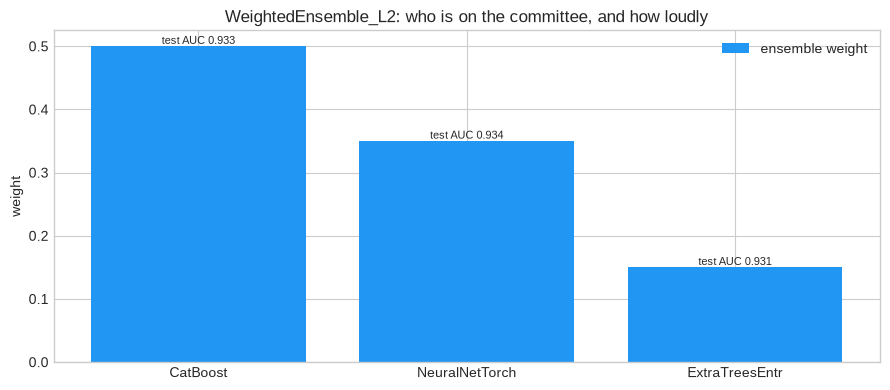

weights sum to 1.000; 3 of 11 level-1 models have non-zero weight


In [20]:
# the weights live on the ensemble model object; guard the private path with a public fallback
weights = None
try:
    ens_model = predictor._trainer.load_model(best)
    weights = pd.Series(ens_model._get_model_weights(), name="weight").sort_values(ascending=False)
    source = "predictor._trainer.load_model(best)._get_model_weights()"
except Exception as e:
    stack = predictor.info()["model_info"][best]["stacker_info"]
    weights = pd.Series(1.0 / stack["num_base_models"], index=stack["base_model_names"], name="weight")
    source = f"predictor.info() stacker_info (equal weights shown; private path failed: {type(e).__name__})"

mi = predictor.model_info(best)
print(f"{best}: type {mi['model_type']}, stack level {mi['stacker_info']}, val score {mi['val_score']:.4f}")
print("weights from", source)
print(weights.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
member_test = lb.set_index("model").loc[weights.index, "score_test"]
bars = ax.bar(weights.index, weights.values, color="#2196F3", label="ensemble weight")
for b, s in zip(bars, member_test):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"test AUC {s:.3f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="k", lw=0.5); ax.set_ylabel("weight"); ax.set_title(f"{best}: who is on the committee, and how loudly")
ax.legend(); plt.tight_layout(); plt.show()
print(f"weights sum to {weights.sum():.3f}; {len(weights)} of {len(predictor.model_names(level=1))} level-1 models have non-zero weight")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One bar per ensemble member, height equal to its weight, with each member's own test ROC-AUC written above it. The weights sum to one and most trained models are absent: greedy selection dropped every member that did not improve the validation score. The member with the largest weight is not necessarily the member with the best test score, because the weights were chosen on the validation holdout, and the earlier warning about `score_val` applies to them as well.

The common misread: reading a weight as "how good this model is". It is "how much this model adds to the committee", which is why a mediocre but *different* model can outweigh a strong but redundant one.

</div>

## 5.3 Why ensembles help: the members must disagree

`predict_proba_multi(df)` returns every model's probabilities in one call. The correlation between two models' probability columns says how similar their mistakes are: near 1.0 means averaging them gains nothing, lower means the ensemble has something to average out.


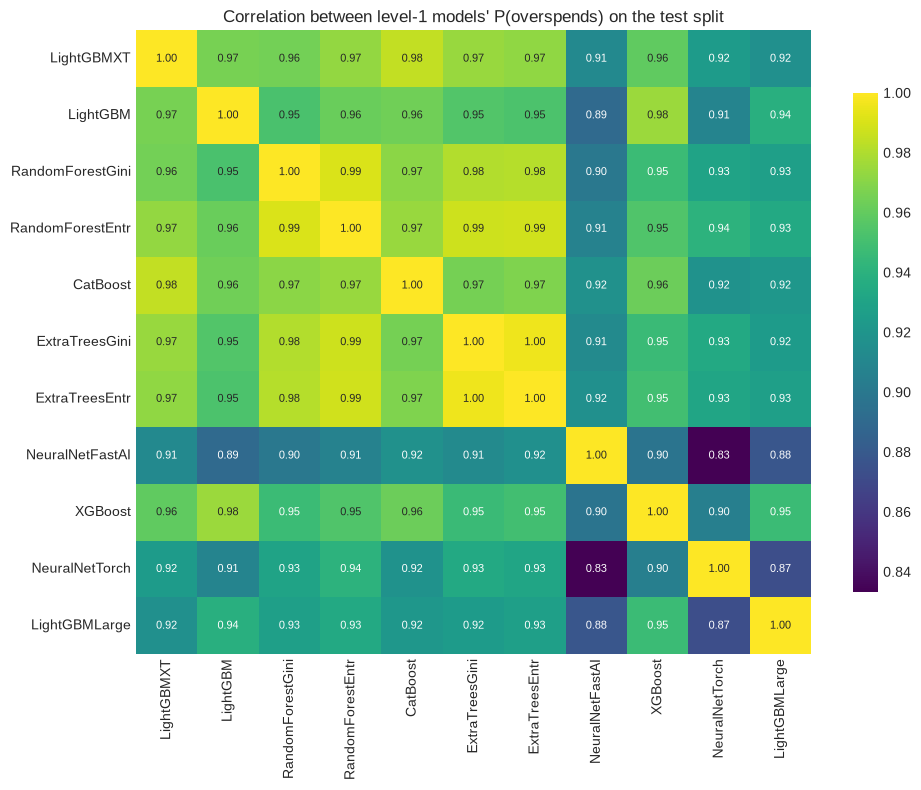

most similar pair: ('ExtraTreesGini', 'ExtraTreesEntr') r = 0.996 | most different pair: ('NeuralNetFastAI', 'NeuralNetTorch') r = 0.833
ensemble members' pairwise correlations: 0.939 on average
ensemble test AUC 0.9388 vs best single member LightGBMXT 0.9388 vs mean member 0.9269
ensemble val AUC 0.8684 vs best single member on val 0.8634


In [21]:
proba_multi = predictor.predict_proba_multi(test_df, models=predictor.model_names(level=1))   # {model: DataFrame with columns 0, 1}
P = pd.DataFrame({m: df[1].values for m, df in proba_multi.items()})                            # level-1 members only; the ensemble is a mix of these
member_auc = pd.Series({m: roc_auc_score(y_test, P[m]) for m in P.columns}, name="test roc_auc")
pcorr = P.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pcorr, cmap="viridis", vmin=pcorr.values.min(), vmax=1, annot=True, fmt=".2f", annot_kws={"size": 8}, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation between level-1 models' P(overspends) on the test split"); plt.tight_layout(); plt.show()

off = pcorr.where(~np.eye(len(pcorr), dtype=bool)).stack()
print(f"most similar pair: {off.idxmax()} r = {off.max():.3f} | most different pair: {off.idxmin()} r = {off.min():.3f}")
print(f"ensemble members' pairwise correlations: {off.loc[[i for i in off.index if i[0] in weights.index and i[1] in weights.index]].mean():.3f} on average")
print(f"ensemble test AUC {ag_card.iloc[0]['roc_auc']:.4f} vs best single member {member_auc.idxmax()} {member_auc.max():.4f} vs mean member {member_auc.mean():.4f}")
print(f"ensemble val AUC {lb.set_index('model').loc[best, 'score_val']:.4f} vs best single member on val {lb[lb.model != best].score_val.max():.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every cell is the correlation between two level-1 models' probability outputs on the same test households; the diagonal is one by definition, and the ensemble is left out because it is a mix of these. Models of the same family (the two random forests, the two extra-trees, the boosted trees) sit close to one, so the printed most-similar pair is almost always siblings. The printed most-different pair names the two models that disagree most in your run. When the budget allowed a neural network to train, it is usually that pair's odd one out: it draws smooth boundaries where trees draw steps. That disagreement is what the weighted ensemble feeds on, and it is why a member can earn ensemble weight despite a lower individual score. Which models made it into the zoo depends on the machine and the time limit, so the set of rows here can differ from run to run.

The common misread: expecting the ensemble to beat every member on every split. The printed comparison shows the ensemble against the best single member and the average member, on test and on validation. It beats the average member, and it beats the best single member on validation, which is what it was fitted to. On a test split with about sixty positives, the best member can edge it by a few thousandths; that gap is inside the noise of the split.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Two near-identical models add cost, not accuracy

A member correlated at 0.99 with another brings almost no new information but its full prediction time, since `pred_time_test` of the ensemble is the sum over its ancestors. Part 9 uses this to trim the ensemble for deployment, and Part 5 shows how bagging and stacking create *useful* diversity on purpose.

</div>

## 5.4 `fit_summary`: the training run in one dictionary

`fit_summary(verbosity=0)` returns what `fit` did without printing anything: the model types, their validation scores, fit and predict times, the bagging and stacking settings, and the winner. It is the machine-readable version of the training log and the thing to save next to a model.


In [22]:
fs = predictor.fit_summary(verbosity=0)
print("keys:", list(fs.keys()))
print(f"best: {fs['model_best']} | bag folds: {fs['num_bag_folds']} | max stack level: {fs['max_stack_level']} | classes: {fs['num_classes']}")
summary_tbl = pd.DataFrame({"model_type": fs["model_types"], "score_val": fs["model_performance"],
                            "fit_time_s": fs["model_fit_times"], "pred_time_s": fs["model_pred_times"]}).sort_values("score_val", ascending=False)
display(pretty(summary_tbl, subset=["score_val"]))
print(f"{len(summary_tbl)} models, {summary_tbl.fit_time_s.sum():.1f} s of fit time inside a 60 s limit (the ensemble's time overlaps its members)")


keys: ['model_types', 'model_performance', 'model_best', 'model_paths', 'model_fit_times', 'model_pred_times', 'num_bag_folds', 'max_stack_level', 'num_classes', 'model_hyperparams']
best: WeightedEnsemble_L2 | bag folds: 0 | max stack level: 2 | classes: 2


,model_type,score_val,fit_time_s,pred_time_s
WeightedEnsemble_L2,WeightedEnsembleModel,0.868,0.093717,0.001195
CatBoost,CatBoostModel,0.863,3.165379,0.007867
NeuralNetTorch,TabularNeuralNetTorchModel,0.856,4.087949,0.018528
ExtraTreesEntr,XTModel,0.856,0.985925,0.121772
ExtraTreesGini,XTModel,0.846,0.985177,0.122533
NeuralNetFastAI,NNFastAiTabularModel,0.845,1.607229,0.012233
LightGBMXT,LGBModel,0.843,0.441495,0.004095
RandomForestGini,RFModel,0.833,1.108051,0.121762
RandomForestEntr,RFModel,0.833,1.232804,0.135638
LightGBM,LGBModel,0.820,0.620308,0.003576


12 models, 16.0 s of fit time inside a 60 s limit (the ensemble's time overlaps its members)


## 5.5 Task 5 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `extra_info=True` adds sizes, types, ancestors and descendants; `model_names(level=...)` filters the zoo; `model_best` is a property in 1.6.3.
- `WeightedEnsemble_L2` is a weighted average of level-1 probabilities, with weights from greedy ensemble selection on the validation holdout.
- A weight measures what a member *adds*, not how good it is alone; redundant members get zero.
- The correlation heatmap of `predict_proba_multi` is the direct test of diversity: siblings near 1.0, the neural network furthest from the trees.
- `fit_summary(verbosity=0)` is the machine-readable training log.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `lb_x` | the leaderboard with `extra_info=True` |
| `weights`, `mi` | the ensemble's member weights and `model_info(best)` |
| `proba_multi`, `P`, `pcorr`, `member_auc` | every level-1 model's test probabilities, as a frame, their correlation, and per-model test ROC-AUC |
| `fs`, `summary_tbl` | `fit_summary` and its tidy table |

### ➡️ Next Up

Part 3 goes deep on classification: the same data fitted under three `eval_metric`s, decision thresholds chosen on validation, and calibration so the probabilities can be believed.

</div>


# Part 3 · Classification Deep Dive: Imbalance, Thresholds, Calibration ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

This Part trains its own predictors, fresh, from the `train_df` of Part 0, so it stands alone: nothing from Parts 1 and 2 is required.

A classifier produces a **probability**. Three separate decisions turn that probability into value, and AutoGluon has a knob for each:

1. **Which metric should training optimise?** (`eval_metric`) — Task 6, where one in six households overspends and accuracy lies.
2. **Where is the cut between "alert" and "no alert"?** (`decision_threshold`) — Task 7, where a cost matrix picks the cut.
3. **Can the probability itself be trusted?** (`calibrate`) — Task 8, where a reliability diagram tells you whether "70%" means 70%.

Every technique is shown twice: once by hand with NumPy so you know what it does, once through the AutoGluon API so you know where it lives.

</div>


# Task 6 · Imbalance: the metric you optimise is the model you get

## 6.1 Why 17% positives change everything

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A model that predicts "stays within budget" for every household is right about 83% of the time and useless. **Class imbalance** means the two outcomes are not equally common, and any metric that counts correct answers rewards ignoring the rare class.

AutoGluon does not know what you will do with the prediction. It only knows the `eval_metric` you hand it, and it uses that metric for three internal decisions: which hyperparameters to keep during early stopping, how to weight the members of the final ensemble, and, for metrics that need a class label, where to put the decision threshold. Change the metric and all three change.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

Three metric families ask three different questions of a probability $p$ and a label $y \in \{0, 1\}$:

- **Threshold metrics** first cut $p$ at a threshold $t$, then count. $\text{F1} = \dfrac{2 \cdot \text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$ depends on $t$.
- **Ranking metrics** ignore $t$ and ask whether positives are ranked above negatives. ROC-AUC is $P(p_{\text{positive}} > p_{\text{negative}})$ for a random pair.
- **Probabilistic metrics** score the probability itself. Log loss is $-\dfrac{1}{n}\sum \big[y \log p + (1-y)\log(1-p)\big]$: a confident wrong answer costs a lot.

AutoGluon tags every metric with exactly one of three flags, `needs_class` (threshold family), `needs_threshold` (ranking family) or `needs_proba` (probabilistic family), and behaves differently for each; the next cell prints them.

</div>

The next cell defines two helpers used through Parts 3 and 4, then trains **three predictors that differ only in `eval_metric`**. The text column `note` stays out of these fits; Part 8 is about text.


In [23]:
import tempfile, inspect
from autogluon.tabular import TabularPredictor
import autogluon.tabular

AG_CPUS = 4                                                  # a fixed CPU budget keeps fit times comparable
TAB_FEATURES = [f for f in FEATURES if f != "note"]          # text stays out until Part 8
assert "num_cpus" in inspect.signature(TabularPredictor.fit).parameters, "num_cpus is a fit() argument since AutoGluon 1.2"

def fit_tabular(train, label, time_limit=30, predictor_kwargs=None, **fit_kwargs):
    # One place for the house budget rules: medium_quality, a temp directory, quiet logs, a fixed CPU count.
    kw = dict(label=label, path=tempfile.mkdtemp(prefix="ag_"), verbosity=0)
    kw.update(predictor_kwargs or {})
    predictor = TabularPredictor(**kw)
    tag = kw.get("eval_metric") or kw.get("problem_type") or label
    with timer(f"fit [{tag}] with a {time_limit} s budget"):
        predictor.fit(train, time_limit=time_limit, presets="medium_quality", num_cpus=AG_CPUS, **fit_kwargs)
    return predictor

def clf_card(predictor, name, data=None):
    # report_card for an AutoGluon classifier: labels from predict(), P(positive) from predict_proba().
    data = test_df if data is None else data
    proba = predictor.predict_proba(data)[predictor.positive_class]
    return report_card(data[LABEL_CLS], predictor.predict(data), proba, name=name)

metric_preds, cards = {}, []
for metric in ["f1", "roc_auc", "log_loss"]:
    metric_preds[metric] = fit_tabular(train_df[TAB_FEATURES + [LABEL_CLS]], LABEL_CLS, time_limit=30,
                                       predictor_kwargs={"eval_metric": metric})
    cards.append(clf_card(metric_preds[metric], f"eval_metric={metric}"))
metric_table = pd.concat(cards)

print(f"\nAutoGluon {autogluon.tabular.__version__}  |  positive class = {metric_preds['f1'].positive_class}  |  features used: {len(TAB_FEATURES)}")
for metric, p in metric_preds.items():
    m = p.eval_metric
    print(f"  {metric:>8}: needs_class={str(m.needs_class):<5} needs_threshold={str(m.needs_threshold):<5} needs_proba={str(m.needs_proba):<5} "
          f"best model={p.model_best:<20} decision_threshold={p.decision_threshold:.3f}")
display(pretty(metric_table, subset=["balanced_acc", "f1", "mcc", "roc_auc", "pr_auc"]))
display(pretty(metric_table[["log_loss", "brier"]], highlight="min"))


⏱️ fit [f1] with a 30 s budget: 22.11 s


⏱️ fit [roc_auc] with a 30 s budget: 17.78 s


⏱️ fit [log_loss] with a 30 s budget: 15.29 s



AutoGluon 1.6.3  |  positive class = 1  |  features used: 18
        f1: needs_class=True  needs_threshold=False needs_proba=False best model=WeightedEnsemble_L2  decision_threshold=0.500
   roc_auc: needs_class=False needs_threshold=True  needs_proba=False best model=WeightedEnsemble_L2  decision_threshold=0.500
  log_loss: needs_class=False needs_threshold=False needs_proba=True  best model=WeightedEnsemble_L2  decision_threshold=0.500


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
eval_metric=f1,0.896000,0.811,0.693548,0.682540,0.688,0.626,0.914,0.773,0.316259,0.083267
eval_metric=roc_auc,0.920000,0.806,0.851064,0.634921,0.727,0.692,0.939,0.819,0.224334,0.064833
eval_metric=log_loss,0.909333,0.787,0.808511,0.603175,0.691,0.649,0.935,0.805,0.224713,0.064191


,log_loss,brier
model,,
eval_metric=f1,0.316,0.083
eval_metric=roc_auc,0.224,0.065
eval_metric=log_loss,0.225,0.064


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Same data, same 30 seconds, same model zoo, three different predictors. Read the printed lines first: the three flags sort the metrics into the three families, only the `f1` predictor has `needs_class=True`, and only that one has a `decision_threshold` that is not 0.5. AutoGluon's default `calibrate_decision_threshold="auto"` tunes the threshold when the metric needs a class label and leaves it alone otherwise. That single difference explains most of the F1 and recall gap in the table. The `roc_auc` and `log_loss` predictors are being judged in the table with a threshold nobody chose.

The common misread: "the `f1` predictor is the best model". It is the best **decision rule** for F1. Its ROC-AUC and log loss are not better, because the ranking and the probabilities did not need a threshold to be scored.

</div>

The bar chart puts the three predictors side by side on one metric from each family.


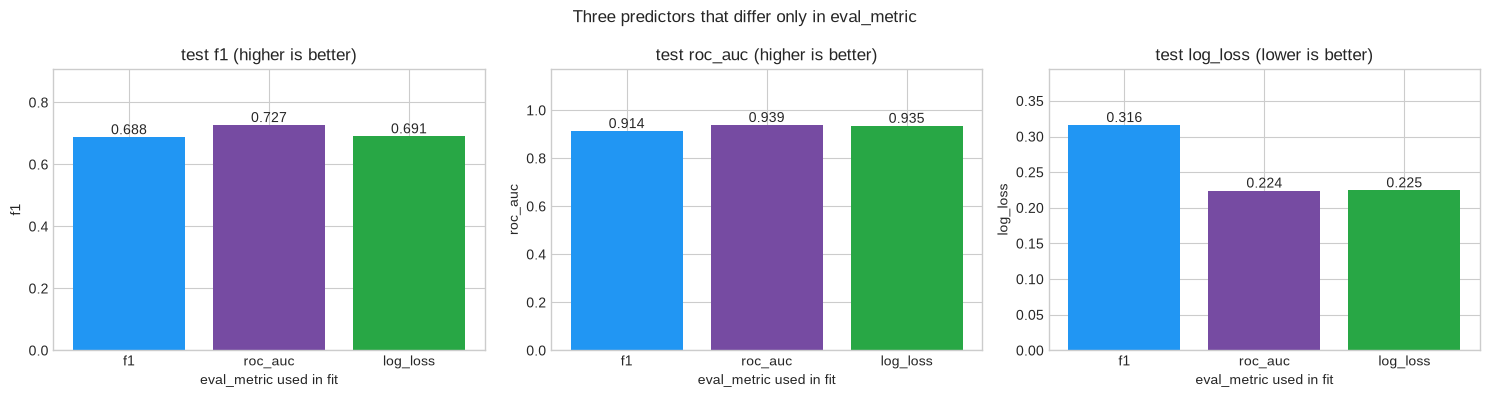

spread across the three predictors:
        f1  roc_auc  log_loss
min  0.688    0.914     0.224
max  0.727    0.939     0.316


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, better in zip(axes, ["f1", "roc_auc", "log_loss"], ["higher", "higher", "lower"]):
    vals = metric_table[col]
    bars = ax.bar([n.replace("eval_metric=", "") for n in vals.index], vals.values,
                  color=["#2196F3", "#764ba2", "#28a745"])
    for b, v in zip(bars, vals.values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:.3f}", ha="center", va="bottom", fontsize=10)
    ax.set_title(f"test {col} ({better} is better)"); ax.set_xlabel("eval_metric used in fit"); ax.set_ylabel(col)
    ax.set_ylim(0, vals.max() * 1.25)
plt.suptitle("Three predictors that differ only in eval_metric")
plt.tight_layout(); plt.show()
spread = metric_table[["f1", "roc_auc", "log_loss"]].agg(["min", "max"])
print("spread across the three predictors:\n" + spread.round(3).to_string())


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each panel is one metric family. The F1 panel moves the most because F1 is the only one of the three that depends on the threshold, and only one predictor tuned its threshold. ROC-AUC barely moves: all three predictors rank households in nearly the same order. Log loss moves a little because the ensemble weights were chosen for different targets.

The common misread: reading a small ROC-AUC gap as "these models are the same". Two models with the same ROC-AUC can produce very different alerts once a threshold is applied; ranking quality and decision quality are different things.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: accuracy is the same for all three, and that is the problem

Look at the `accuracy` column in the table above. It hardly separates the predictors, because with one positive in six a model can be wrong about most overspenders and still score high. Never pick a metric that a constant model can nearly max out. `balanced_acc`, `mcc`, `f1` and `pr_auc` all fall when the rare class is ignored; accuracy does not.

</div>

## 6.2 Sample weights: telling AutoGluon which rows matter

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A second lever for imbalance is to say "one missed overspender costs as much as five false alarms" *during training*. In AutoGluon this is a **weight column**: name it in `sample_weight=`, and every model in the zoo receives the weights. `weight_evaluation=True` makes the validation score weighted too, so model selection and ensembling see the same priorities. The weight column is never used as a feature.

The shorthand `sample_weight="balance_weight"` builds the inverse-frequency weights for you; the explicit column below shows what that shorthand does.

</div>


In [25]:
n_pos, n_neg = int(train_df[LABEL_CLS].sum()), int((train_df[LABEL_CLS] == 0).sum())
w_pos = n_neg / n_pos                                        # each positive counts as this many negatives
train_w = train_df[TAB_FEATURES + [LABEL_CLS]].copy(); train_w["row_weight"] = np.where(train_w[LABEL_CLS] == 1, w_pos, 1.0)
test_w = test_df[TAB_FEATURES + [LABEL_CLS]].copy();   test_w["row_weight"] = np.where(test_w[LABEL_CLS] == 1, w_pos, 1.0)
print(f"train: {n_pos} positives, {n_neg} negatives -> positive weight {w_pos:.2f}, weighted class mass {n_pos * w_pos:.0f} vs {n_neg}")

weighted_pred = fit_tabular(train_w, LABEL_CLS, time_limit=30,
                            predictor_kwargs={"eval_metric": "f1", "sample_weight": "row_weight", "weight_evaluation": True})
print("row_weight used as a feature?", "row_weight" in weighted_pred.features())
print(f"best model={weighted_pred.model_best}, decision_threshold={weighted_pred.decision_threshold:.3f} (tuned on the WEIGHTED validation F1)")

weight_table = pd.concat([metric_table.loc[["eval_metric=f1"]].rename(index={"eval_metric=f1": "f1, unweighted"}),
                          clf_card(weighted_pred, "f1, sample_weight column", data=test_w)])
display(pretty(weight_table[["accuracy", "balanced_acc", "precision", "recall", "f1", "roc_auc", "pr_auc"]]))
lb_w = weighted_pred.leaderboard(test_w, silent=True)[["model", "score_val", "score_test"]].head(4)
print("leaderboard scores are WEIGHTED f1 because weight_evaluation=True:\n" + lb_w.round(3).to_string(index=False))


train: 189 positives, 936 negatives -> positive weight 4.95, weighted class mass 936 vs 936


⏱️ fit [f1] with a 30 s budget: 29.21 s
row_weight used as a feature? False
best model=WeightedEnsemble_L2, decision_threshold=0.500 (tuned on the WEIGHTED validation F1)


,accuracy,balanced_acc,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
"f1, unweighted",0.896,0.811,0.694,0.683,0.688,0.914,0.773
"f1, sample_weight column",0.885,0.855,0.622,0.810,0.703,0.934,0.804


leaderboard scores are WEIGHTED f1 because weight_evaluation=True:
              model  score_val  score_test
           LightGBM      0.755       0.852
           CatBoost      0.805       0.851
WeightedEnsemble_L2      0.819       0.848
            XGBoost      0.707       0.829


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The weight column pushed the model toward the rare class: compare `recall` and `precision` between the two rows. Weighting moves the balance in the same direction a lower threshold would, but it does so inside every model's loss, so the ranking (ROC-AUC, PR-AUC) can shift as well, not only the cut. The printed leaderboard scores are *weighted* F1, which is why they do not match the unweighted `f1` in the report card; the two numbers answer different questions.

The common misread: comparing a weighted validation score with an unweighted test score and calling the gap overfitting. Turn `weight_evaluation` off, or weight both, before comparing.

</div>

## 6.3 Why AutoGluon does not oversample by default

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: threshold first, weights second, resampling last

AutoGluon never duplicates or synthesises rows of the rare class (SMOTE-style oversampling) on its own, for three reasons the numbers above support:

1. **Most of the gain is free.** Tuning the threshold (Task 7) recovers most of the F1 that imbalance costs, and it does not touch the training data. The `f1` predictor already did this automatically.
2. **Duplicated rows leak.** With bagging (Part 5), a copy of a training row can land in the validation fold of the same model, and the out-of-fold score becomes optimistic. Weights do not have this problem because they never add rows.
3. **Probabilities get distorted.** Oversampling teaches the model that positives are common. The ranking may improve, but every probability is inflated, and Task 8 shows why that costs you later.

Order of operations for an imbalanced problem: choose a metric that a constant model cannot game, tune the threshold, then try `sample_weight="balance_weight"`, and only then, if the rare class is tiny (tens of rows), consider resampling, and only inside the training folds.

</div>

## 6.4 Task 6 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `eval_metric` steers early stopping, ensemble weights and, for `needs_class` metrics, the decision threshold. Three metrics gave three different predictors on the same data.
- Accuracy barely separates the predictors at 17% positives; `f1`, `balanced_acc`, `mcc` and `pr_auc` do.
- `sample_weight="<column>"` weights every model's loss; `weight_evaluation=True` weights the validation score too, and the weight column is never a feature.
- AutoGluon does not oversample by default: thresholds and weights get the benefit without duplicated rows or inflated probabilities.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `TAB_FEATURES` | `FEATURES` without the text column `note` |
| `fit_tabular(train, label, time_limit, predictor_kwargs, **fit_kwargs)` | the house fit: `medium_quality`, temp dir, `verbosity=0`, `num_cpus=AG_CPUS` |
| `clf_card(predictor, name, data)` | `report_card` for an AutoGluon classifier |
| `metric_preds` | dict of the three predictors keyed by `eval_metric` |
| `metric_table` | their test report cards, one row each |
| `weighted_pred`, `train_w`, `test_w` | the weighted fit and the frames carrying its `row_weight` column |

### ➡️ Next Up

Task 7 takes the `roc_auc` predictor, whose threshold is still 0.5, and chooses the cut on purpose: by sweep, by cost matrix and by `calibrate_decision_threshold`.

</div>


# Task 7 · Decision thresholds: the cut is a business decision

## 7.1 Sweeping the threshold

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

`predict_proba` gives a number between 0 and 1 for every household. `predict` compares it with a threshold and returns 0 or 1. The default threshold, 0.5, is not a law; it is what you get when nobody decided. Lower the threshold and more households are flagged: recall goes up, precision goes down. There is no free lunch, only a trade-off, and a plot of precision, recall and F1 against the threshold shows the whole trade-off at once.

The predictor below is the `roc_auc` one from Task 6, called `clf` from now on. Its threshold is 0.5 because ROC-AUC never needed one.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

At threshold $t$ the predicted label is $\hat{y} = \mathbb{1}[p \ge t]$. Precision is $\dfrac{TP}{TP + FP}$ (of the alerts, how many were real), recall is $\dfrac{TP}{TP + FN}$ (of the real overspenders, how many were caught). As $t$ falls, $TP$ and $FP$ both rise, so recall rises and precision usually falls. F1 is their harmonic mean and peaks somewhere in between.

</div>

The sweep is computed on two datasets: AutoGluon's own **validation** split (the rows it held out from `train_df` during `fit`, reachable through `load_data_internal`) and the **test** set. Keep an eye on which curve is used for which decision.


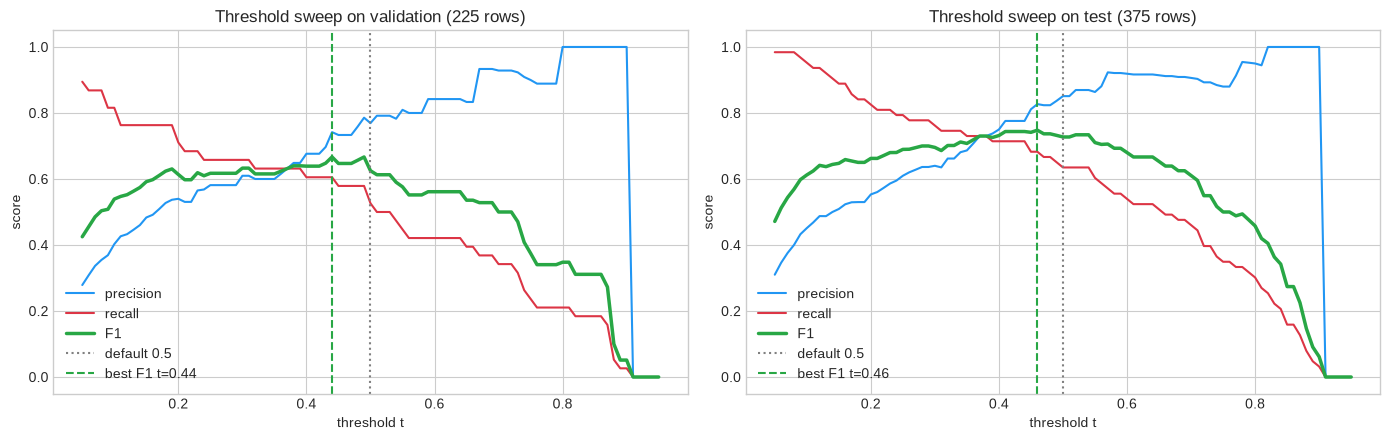

validation: best F1 0.667 at t=0.44   |   at t=0.50: F1 0.625
test:       best F1 0.748 at t=0.46   |   at t=0.50: F1 0.727


In [26]:
from sklearn.metrics import precision_recall_curve

clf = metric_preds["roc_auc"]
X_val, y_val = clf.load_data_internal(data="val", return_X=True, return_y=True)   # AutoGluon's own holdout, already transformed
p_val = clf.predict_proba(X_val, transform_features=False)[clf.positive_class].to_numpy()
p_test = clf.predict_proba(test_df)[clf.positive_class].to_numpy()
y_test = test_df[LABEL_CLS].to_numpy(); y_val = np.asarray(y_val)

def sweep(y, p, thresholds):
    # precision, recall and F1 at every threshold, as a tidy DataFrame
    rows = []
    for t in thresholds:
        yhat = (p >= t).astype(int)
        rows.append({"threshold": t,
                     "precision": precision_score(y, yhat, zero_division=0),
                     "recall": recall_score(y, yhat, zero_division=0),
                     "f1": f1_score(y, yhat, zero_division=0),
                     "alerts": int(yhat.sum())})
    return pd.DataFrame(rows)

thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
sweep_val, sweep_test = sweep(y_val, p_val, thresholds), sweep(y_test, p_test, thresholds)
best_val_t = float(sweep_val.loc[sweep_val.f1.idxmax(), "threshold"])
best_test_t = float(sweep_test.loc[sweep_test.f1.idxmax(), "threshold"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, sw, name in zip(axes, [sweep_val, sweep_test], [f"validation ({len(y_val)} rows)", f"test ({len(y_test)} rows)"]):
    ax.plot(sw.threshold, sw.precision, label="precision", color="#2196F3")
    ax.plot(sw.threshold, sw.recall, label="recall", color="#dc3545")
    ax.plot(sw.threshold, sw.f1, label="F1", color="#28a745", lw=2.5)
    ax.axvline(0.5, color="grey", ls=":", label="default 0.5")
    ax.set_title(f"Threshold sweep on {name}"); ax.set_xlabel("threshold t"); ax.set_ylabel("score"); ax.legend()
axes[0].axvline(best_val_t, color="#28a745", ls="--", label=f"best F1 t={best_val_t:.2f}"); axes[0].legend()
axes[1].axvline(best_test_t, color="#28a745", ls="--", label=f"best F1 t={best_test_t:.2f}"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"validation: best F1 {sweep_val.f1.max():.3f} at t={best_val_t:.2f}   |   at t=0.50: F1 {sweep_val.loc[sweep_val.threshold == 0.5, 'f1'].item():.3f}")
print(f"test:       best F1 {sweep_test.f1.max():.3f} at t={best_test_t:.2f}   |   at t=0.50: F1 {sweep_test.loc[sweep_test.threshold == 0.5, 'f1'].item():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Precision (blue) climbs and recall (red) falls as the threshold moves right; F1 (green) peaks where the two cross over, well to the left of the dotted 0.5 line. The two panels do not agree exactly on where the peak is, and the validation curve is noisier because it has fewer rows. That disagreement is the whole reason the next warning exists.

The common misread: treating the peak of the F1 curve as a property of the model. It is a property of the model **and** the data the curve was drawn on. The peak position moves between the two panels; only the shape is stable.

</div>

## 7.2 A cost matrix instead of F1

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

F1 weighs a false alarm and a missed overspender equally. A bank does not. A missed overspender (**false negative**) turns into overdraft fees and a complaint; an unnecessary nudge (**false positive**) costs one notification. Write those two costs down as a **cost matrix** and the best threshold is the one that minimises expected cost per household. No new model, no new fit: the same probabilities and a different scoring rule.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With cost $c_{FN}$ per missed positive and $c_{FP}$ per false alarm, expected cost per household at threshold $t$ is

$$ \text{cost}(t) = \frac{c_{FN} \cdot FN(t) + c_{FP} \cdot FP(t)}{n} $$

For a **perfectly calibrated** model the optimum has a closed form, $t^* = \dfrac{c_{FP}}{c_{FP} + c_{FN}}$: alert whenever the expected cost of silence exceeds the cost of the alert. The cell computes both and checks whether they agree; Task 8 explains why they may not.

</div>


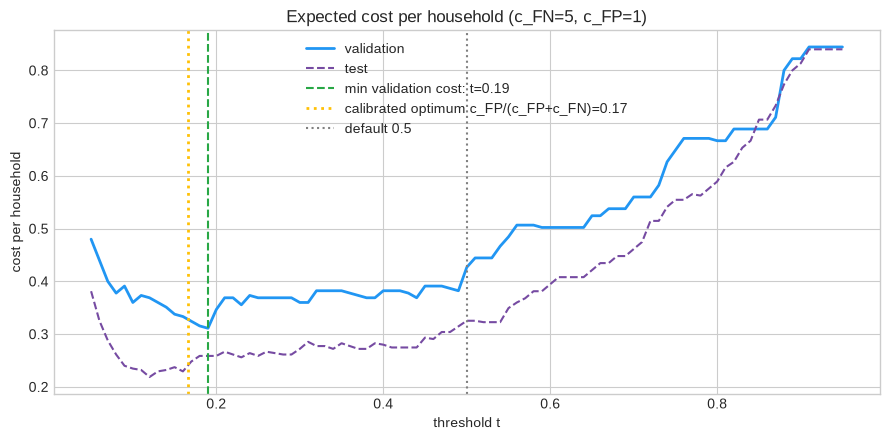

validation cost at t=0.50: 0.427   at t=0.19: 0.311   at t=0.17: 0.324
test cost       at t=0.50: 0.325   at t=0.19: 0.259   at t=0.17: 0.253
alerts on test at t=0.50: 47   at t=0.19: 100   (true overspenders: 63)


In [27]:
from sklearn.metrics import confusion_matrix

C_FN, C_FP = 5.0, 1.0                                        # a missed overspender costs five unnecessary nudges

def expected_cost(y, p, t):
    tn, fp, fn, tp = confusion_matrix(y, (p >= t).astype(int), labels=[0, 1]).ravel()
    return (C_FN * fn + C_FP * fp) / len(y)

cost_val = np.array([expected_cost(y_val, p_val, t) for t in thresholds])
cost_test = np.array([expected_cost(y_test, p_test, t) for t in thresholds])
t_cost = float(thresholds[cost_val.argmin()])                  # chosen on validation
t_theory = C_FP / (C_FP + C_FN)                                # what a calibrated model would want

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, cost_val, label="validation", color="#2196F3", lw=2)
ax.plot(thresholds, cost_test, label="test", color="#764ba2", ls="--")
ax.axvline(t_cost, color="#28a745", ls="--", label=f"min validation cost: t={t_cost:.2f}")
ax.axvline(t_theory, color="#ffc107", ls=":", lw=2, label=f"calibrated optimum c_FP/(c_FP+c_FN)={t_theory:.2f}")
ax.axvline(0.5, color="grey", ls=":", label="default 0.5")
ax.set_title(f"Expected cost per household (c_FN={C_FN:.0f}, c_FP={C_FP:.0f})"); ax.set_xlabel("threshold t"); ax.set_ylabel("cost per household"); ax.legend()
plt.tight_layout(); plt.show()

print(f"validation cost at t=0.50: {expected_cost(y_val, p_val, 0.5):.3f}   at t={t_cost:.2f}: {cost_val.min():.3f}   at t={t_theory:.2f}: {expected_cost(y_val, p_val, t_theory):.3f}")
print(f"test cost       at t=0.50: {expected_cost(y_test, p_test, 0.5):.3f}   at t={t_cost:.2f}: {expected_cost(y_test, p_test, t_cost):.3f}   at t={t_theory:.2f}: {expected_cost(y_test, p_test, t_theory):.3f}")
print(f"alerts on test at t=0.50: {(p_test >= 0.5).sum()}   at t={t_cost:.2f}: {(p_test >= t_cost).sum()}   (true overspenders: {y_test.sum()})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Cost falls steeply as the threshold drops from 0.5, bottoms out, then rises again as false alarms pile up. The green line (the validation minimum) and the yellow line (the closed-form optimum a calibrated model would want) are close but not identical: the model's probabilities are not exactly calibrated, so the empirical curve is the safer guide. The printed alert counts show what the threshold change means operationally: many more households get a nudge.

The common misread: reading the cost curve as "lower thresholds are better". The curve has a minimum; below it every extra alert costs more than it saves.

</div>

## 7.3 The AutoGluon way: `calibrate_decision_threshold` and `set_decision_threshold`

Everything above lives in the API as two calls. `calibrate_decision_threshold(metric=...)` searches thresholds for a `needs_class` metric and returns the best one; with `data=None` it uses the predictor's own validation split. `set_decision_threshold(t)` stores the choice on the predictor so that `predict` (and `leaderboard`, `evaluate`) use it from then on. The stored threshold is saved with the model.


In [28]:
print(f"before: decision_threshold={clf.decision_threshold:.3f}, alerts on test={int((clf.predict(test_df) == 1).sum())}")
before = clf_card(clf, "t=0.50 (default)")

t_val = clf.calibrate_decision_threshold(metric="f1", verbose=False)            # data=None -> AutoGluon's validation split
t_tst = clf.calibrate_decision_threshold(test_df, metric="f1", verbose=False)   # on TEST: shown only to measure the optimism
print(f"calibrate_decision_threshold(metric='f1'): validation -> {t_val:.3f}   test -> {t_tst:.3f}   (hand sweep found {best_val_t:.2f} / {best_test_t:.2f})")

clf.set_decision_threshold(t_val)                                               # the honest choice, stored on the predictor
after = clf_card(clf, f"t={t_val:.3f} (chosen on validation)")
cheat = report_card(y_test, clf.predict(test_df, decision_threshold=t_tst), p_test,   # predict() also takes a one-off threshold
                    name=f"t={t_tst:.3f} (chosen on TEST: optimistic)")

threshold_table = pd.concat([before, after, cheat])[["precision", "recall", "f1", "balanced_acc", "mcc", "roc_auc"]]
display(pretty(threshold_table))
print(f"after: decision_threshold={clf.decision_threshold:.3f}, alerts on test={int((clf.predict(test_df) == 1).sum())}")
print(f"optimism from picking the threshold on test: F1 {cheat.f1.item() - after.f1.item():+.3f}")
print("evaluate() now uses the stored threshold:", {k: round(v, 3) for k, v in clf.evaluate(test_df, silent=True).items() if k in ("f1", "roc_auc")})


before: decision_threshold=0.500, alerts on test=47


calibrate_decision_threshold(metric='f1'): validation -> 0.442   test -> 0.447   (hand sweep found 0.44 / 0.46)


,precision,recall,f1,balanced_acc,mcc,roc_auc
model,,,,,,
t=0.50 (default),0.851,0.635,0.727,0.806,0.692,0.939
t=0.442 (chosen on validation),0.776,0.714,0.744,0.836,0.695,0.939
t=0.447 (chosen on TEST: optimistic),0.815,0.698,0.752,0.833,0.710,0.939


after: decision_threshold=0.442, alerts on test=58
optimism from picking the threshold on test: F1 +0.008


evaluate() now uses the stored threshold: {'roc_auc': np.float64(0.939), 'f1': 0.744}


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three rows, one model. Moving the threshold from 0.5 to the validation choice raises recall and F1 while ROC-AUC stays identical, because a threshold changes labels, not the ranking. The third row is the trap: it chose the threshold *on the test set*, and its F1 is at least as high by construction. The printed "optimism" is the size of the lie you would tell yourself.

The common misread: "the test-chosen threshold gives a better model, so use it". It gives a better *score on that test set*, which is no longer a test set once it has been used to make a decision.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: pick the threshold on validation data, never on test

`calibrate_decision_threshold(test_df, ...)` runs without complaint, and the resulting F1 will look better than the honest one. Every choice made by looking at the test set (a threshold, a feature, a model) turns part of the test set into training data. Use `data=None` (AutoGluon's validation split) or a dedicated validation frame, and keep `test_df` for the single final number.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the threshold ships with the model

`set_decision_threshold` stores the cut on the predictor, so `predict`, `evaluate` and `leaderboard` agree with each other and with production. Write down *why* the threshold has its value (an F1 target, a cost matrix, an alert budget) next to the model card; when costs change, re-run the cost curve, not the training.

</div>

## 7.4 Task 7 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The threshold trades precision for recall; the sweep shows the whole trade-off and F1 peaks well below 0.5 on this data.
- A cost matrix turns the choice into a business number; for a calibrated model the optimum is $c_{FP}/(c_{FP}+c_{FN})$.
- `calibrate_decision_threshold(metric=...)` searches on the validation split; `set_decision_threshold(t)` makes `predict` use it.
- Choosing the threshold on the test set inflates the test score; the notebook measured the inflation.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `clf` | the `roc_auc` predictor, now carrying a validation-chosen threshold |
| `X_val`, `y_val`, `p_val` | AutoGluon's validation split and the model's probabilities on it |
| `p_test`, `y_test` | probabilities and labels on the test set |
| `sweep(y, p, thresholds)`, `sweep_val`, `sweep_test` | precision / recall / F1 per threshold |
| `expected_cost(y, p, t)`, `C_FN`, `C_FP`, `t_cost` | the cost matrix and its best threshold |
| `t_val`, `t_tst`, `threshold_table` | thresholds from AutoGluon (validation vs test) and the comparison |

### ➡️ Next Up

The cost curve's optimum did not land exactly on the calibrated formula. Task 8 asks whether the probabilities can be trusted at all, and fixes them when they cannot.

</div>


# Task 8 · Calibration: does 70% mean 70%?

## 8.1 The reliability diagram

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A model is **calibrated** when, among all households it gives a 70% chance of overspending, about 70% actually do. Ranking metrics do not care (ROC-AUC is unchanged by any monotone squeeze of the probabilities), but everything downstream does: a cost threshold, an expected-loss estimate, a message that says "you have a 70% chance of overspending".

The **reliability diagram** checks this directly: bin the predictions by probability, and plot the observed positive rate in each bin against the mean predicted probability. A calibrated model sits on the diagonal. Gradient-boosted trees tend to be over-confident (an S-curve around the diagonal); averaging several models, as the weighted ensemble does, usually pulls them back.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

**Expected calibration error** (ECE) summarises the diagram as one number: with bins $B_1, \dots, B_K$,

$$ \text{ECE} = \sum_{k=1}^{K} \frac{|B_k|}{n} \, \big| \, \overline{y}_{B_k} - \overline{p}_{B_k} \, \big| $$

the size-weighted gap between observed frequency and mean confidence. Zero is perfect; the number depends on the binning, so always say how many bins.

**Brier decomposition.** The Brier score $\frac{1}{n}\sum (p - y)^2$ splits into three bin-level pieces:

$$ \text{Brier} = \underbrace{\sum_k \tfrac{|B_k|}{n} (\overline{p}_{B_k} - \overline{y}_{B_k})^2}_{\text{reliability (want small)}} \;-\; \underbrace{\sum_k \tfrac{|B_k|}{n} (\overline{y}_{B_k} - \overline{y})^2}_{\text{resolution (want large)}} \;+\; \underbrace{\overline{y}(1 - \overline{y})}_{\text{uncertainty (fixed by the data)}} $$

Reliability is calibration; resolution is how far the bins spread apart from the base rate (sharpness that is also right); uncertainty is the base rate's own variance, which no model can change.

</div>


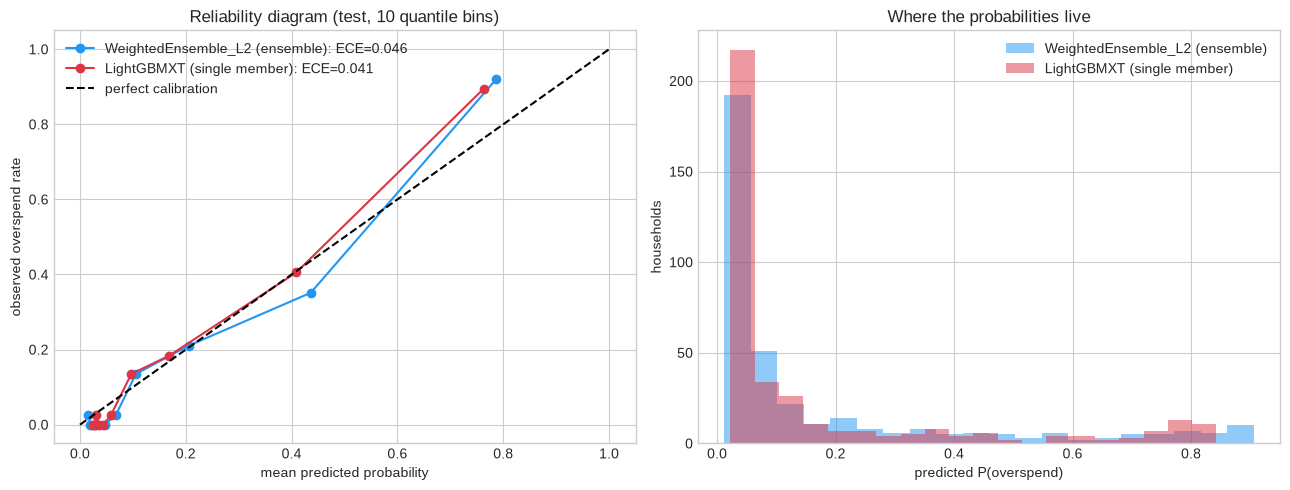

            ensemble: Brier 0.0648 = reliability 0.0043 - resolution 0.0785 + uncertainty 0.1398 (sum 0.0655)
          LightGBMXT: Brier 0.0665 = reliability 0.0044 - resolution 0.0769 + uncertainty 0.1398 (sum 0.0673)


In [29]:
from sklearn.calibration import calibration_curve

def ece_score(y, p, n_bins=10):
    # expected calibration error with equal-width bins
    bins = np.clip((p * n_bins).astype(int), 0, n_bins - 1)
    total = 0.0
    for k in range(n_bins):
        m = bins == k
        if m.any():
            total += m.mean() * abs(y[m].mean() - p[m].mean())
    return total

def brier_decomposition(y, p, n_bins=10):
    # reliability - resolution + uncertainty, on the same bins as ece_score
    bins = np.clip((p * n_bins).astype(int), 0, n_bins - 1)
    ybar, rel, res = y.mean(), 0.0, 0.0
    for k in range(n_bins):
        m = bins == k
        if m.any():
            rel += m.mean() * (p[m].mean() - y[m].mean()) ** 2
            res += m.mean() * (y[m].mean() - ybar) ** 2
    unc = ybar * (1 - ybar)
    return {"reliability": rel, "resolution": res, "uncertainty": unc, "sum": rel - res + unc, "brier": float(np.mean((p - y) ** 2))}

l1_models = [m for m in clf.model_names() if m != clf.model_best]
member = next((m for m in l1_models if "LightGBM" in m), l1_models[0])         # one single GBM member of the ensemble
p_member = clf.predict_proba(test_df, model=member)[clf.positive_class].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for p, name, color in [(p_test, f"{clf.model_best} (ensemble)", "#2196F3"), (p_member, f"{member} (single member)", "#dc3545")]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, "o-", label=f"{name}: ECE={ece_score(y_test, p):.3f}", color=color)
    axes[1].hist(p, bins=20, alpha=0.5, label=name, color=color)
axes[0].plot([0, 1], [0, 1], "k--", label="perfect calibration")
axes[0].set_title("Reliability diagram (test, 10 quantile bins)"); axes[0].set_xlabel("mean predicted probability"); axes[0].set_ylabel("observed overspend rate"); axes[0].legend()
axes[1].set_title("Where the probabilities live"); axes[1].set_xlabel("predicted P(overspend)"); axes[1].set_ylabel("households"); axes[1].legend()
plt.tight_layout(); plt.show()

for p, name in [(p_test, "ensemble"), (p_member, member)]:
    d = brier_decomposition(y_test, p)
    print(f"{name:>20}: Brier {d['brier']:.4f} = reliability {d['reliability']:.4f} - resolution {d['resolution']:.4f} + uncertainty {d['uncertainty']:.4f} (sum {d['sum']:.4f})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: each point is one decile of predictions. Points below the diagonal mean the model was more confident than the data justified (over-confidence); above it, under-confidence. The legend's ECE numbers summarise the distance from the diagonal, and the printed decomposition shows the same story in Brier terms: the `reliability` term is the calibration gap, and `uncertainty` is identical for both models because it depends only on the labels. Right: most households sit near zero, a long tail reaches to the right; the test set has few rows in the high bins, so the right-most points of the diagram are the least certain.

The common misread: judging calibration from one bin with a handful of rows. With a test set of a few hundred households, the top deciles contain only a few dozen predictions each; look at the weighted ECE, not at a single point.

</div>

## 8.2 Temperature scaling by hand, then the `calibrate` flag

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

**Temperature scaling** is the simplest post-hoc fix: turn every probability into a logit, divide by one number $T$, turn it back. $T > 1$ softens over-confident predictions toward 0.5; $T < 1$ sharpens. The ranking never changes, so ROC-AUC stays exactly where it was; only log loss, Brier and ECE can move. $T$ is chosen on the **validation** split by minimising log loss, which is exactly what AutoGluon does when you pass `calibrate=True` to `fit`.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

$$ p_T = \sigma\!\left(\frac{\operatorname{logit}(p)}{T}\right), \qquad T^* = \arg\min_T \; -\frac{1}{n_{\text{val}}} \sum_i \big[ y_i \log p_{T,i} + (1 - y_i) \log (1 - p_{T,i}) \big] $$

One parameter, fitted on a few hundred rows, cannot overfit much; that is the appeal.

</div>


fitted temperature on 225 validation rows: T* = 1.027  (softens the probabilities)


,roc_auc,pr_auc,log_loss,brier,ECE_10
model,,,,,
"ensemble, raw",0.938797,0.818865,0.224,0.065,0.046
"ensemble, T=1.03",0.938797,0.818865,0.226,0.065,0.049


⏱️ fit [log_loss] with a 30 s budget: 1.39 s
AutoGluon calibrate=True fitted T = 0.9685265421867371  on model WeightedEnsemble_L2


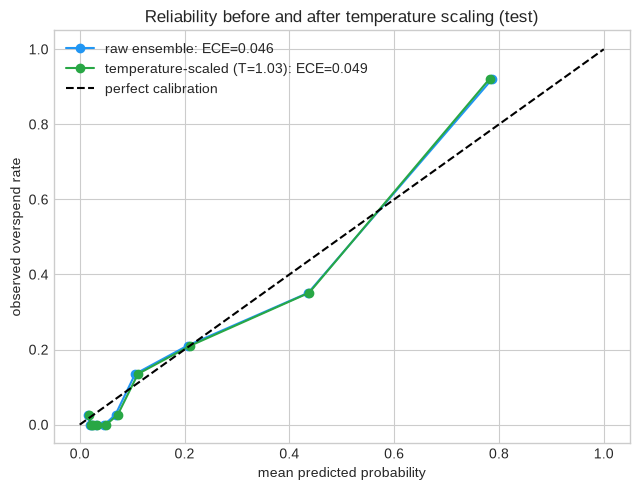

log loss raw 0.2243 -> scaled 0.2261;  ROC-AUC unchanged: 0.9388 vs 0.9388


In [30]:
from scipy.optimize import minimize_scalar
from scipy.special import logit, expit

def temperature_scale(p, T):
    return expit(logit(np.clip(p, 1e-6, 1 - 1e-6)) / T)

def fit_temperature(y, p):
    # one scalar T chosen on validation data by minimising log loss
    res = minimize_scalar(lambda T: log_loss(y, temperature_scale(p, T)), bounds=(0.05, 20.0), method="bounded")
    return float(res.x)

T_star = fit_temperature(y_val, p_val)
p_test_T = temperature_scale(p_test, T_star)
print(f"fitted temperature on {len(y_val)} validation rows: T* = {T_star:.3f}  ({'softens' if T_star > 1 else 'sharpens'} the probabilities)")

calib_rows = pd.concat([
    report_card(y_test, (p_test >= 0.5).astype(int), p_test, name="ensemble, raw"),
    report_card(y_test, (p_test_T >= 0.5).astype(int), p_test_T, name=f"ensemble, T={T_star:.2f}"),
])[["roc_auc", "pr_auc", "log_loss", "brier"]]
calib_rows["ECE_10"] = [ece_score(y_test, p_test), ece_score(y_test, p_test_T)]
display(pretty(calib_rows, highlight="min", subset=["log_loss", "brier", "ECE_10"]))

# --- the API: fit(..., calibrate=True). In 1.6.3, calibrate='auto' turns itself OFF for binary problems with fewer
#     than 3000 validation rows (this notebook has far fewer), so the flag must be forced. A one-model fit keeps it quick.
calibrated_pred = fit_tabular(train_df[TAB_FEATURES + [LABEL_CLS]], LABEL_CLS, time_limit=30,
                              predictor_kwargs={"eval_metric": "log_loss"}, hyperparameters={"GBM": {}}, calibrate=True)
try:
    T_ag = calibrated_pred._trainer.load_model(calibrated_pred.model_best).temperature_scalar
except Exception as e:                                                       # private attribute: guard it
    T_ag = None; print("could not read the temperature:", e)
print(f"AutoGluon calibrate=True fitted T = {T_ag}  on model {calibrated_pred.model_best}")

fig, ax = plt.subplots(figsize=(6.5, 5))
for p, name, color in [(p_test, "raw ensemble", "#2196F3"), (p_test_T, f"temperature-scaled (T={T_star:.2f})", "#28a745")]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=f"{name}: ECE={ece_score(y_test, p):.3f}", color=color)
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.set_title("Reliability before and after temperature scaling (test)"); ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed overspend rate"); ax.legend()
plt.tight_layout(); plt.show()
print(f"log loss raw {calib_rows.log_loss.iloc[0]:.4f} -> scaled {calib_rows.log_loss.iloc[1]:.4f};  ROC-AUC unchanged: {calib_rows.roc_auc.iloc[0]:.4f} vs {calib_rows.roc_auc.iloc[1]:.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The green curve is the blue curve after dividing every logit by $T^*$. ROC-AUC and PR-AUC are identical in the table to every printed decimal, as promised: a monotone transform cannot reorder households. Log loss, Brier and ECE are the metrics allowed to move, and whether they improve on the test set depends on how well the validation split represented it. A $T^*$ near 1 means the ensemble was already close to calibrated and the fix is cosmetic; a $T^*$ far from 1 means the raw probabilities should not have been shown to anyone.

The common misread: expecting calibration to improve F1 or recall at a fixed threshold. It can move them (the threshold now cuts a different set of households) but not in a reliable direction; calibration is for the probabilities, thresholds are for the labels. Pick $T$ first, then the threshold.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `calibrate="auto"` silently does nothing on small data

In AutoGluon 1.6.3 the default `calibrate="auto"` applies temperature scaling only when the metric needs probabilities **and** the validation split has at least 3000 rows for a binary problem (500 for multiclass, 1000 for quantile regression). This notebook's validation split is far smaller, so the automatic path is off, and the log-loss predictor of Task 6 was never calibrated. The cell forced it with `calibrate=True` and read the fitted temperature back. Check `predictor.info()` or the fit log at `verbosity=2` rather than assuming.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: report calibration next to ranking, and calibrate before you threshold

Put ECE (with the bin count) and log loss in the report card next to ROC-AUC. A model that ranks well and is badly calibrated is fine for a top-k list and dangerous for a cost threshold or a probability shown to a customer. When calibration matters, calibrate on validation data (`calibrate=True`, or your own $T$), *then* run Task 7's threshold search on the calibrated probabilities; the closed-form $c_{FP}/(c_{FP}+c_{FN})$ only holds after this step.

</div>

## 8.3 Task 8 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- A reliability diagram compares predicted probability with observed frequency; ECE is its size-weighted summary and depends on the binning.
- Brier = reliability − resolution + uncertainty; the code verified the identity, and `uncertainty` is the same for every model on the same labels.
- Temperature scaling divides logits by one scalar fitted on validation data; ROC-AUC cannot change, log loss and ECE can.
- `fit(..., calibrate=True)` does the same inside AutoGluon; the 1.6.3 `"auto"` default switches itself off below 3000 binary validation rows.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `ece_score(y, p, n_bins)` | expected calibration error by hand |
| `brier_decomposition(y, p, n_bins)` | reliability, resolution, uncertainty and their sum |
| `member`, `p_member` | one single GBM member of the ensemble and its probabilities |
| `temperature_scale(p, T)`, `fit_temperature(y, p)`, `T_star`, `p_test_T` | temperature scaling by hand |
| `calibrated_pred`, `T_ag` | a `calibrate=True` fit and the temperature AutoGluon stored |
| `calib_rows` | raw vs scaled metrics on the test set |

### ➡️ Next Up

Part 4 changes the target from a yes/no to an amount: how much will each household spend next month, with an interval around the answer, and a trap that makes any regression look perfect.

</div>


# Part 4 · Regression and Quantiles; the Leakage Trap ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

The second target in `hh` is `spend_next`, next month's total spend in currency units. Regression changes three things at once: the metric family (errors in currency, not counts of right and wrong), the diagnostic pictures (residuals instead of confusion matrices), and the shape of an honest answer (an **interval**, not a point). Task 9 covers all three with `problem_type="regression"` and then `problem_type="quantile"`.

Task 10 is a deliberate accident. It builds the wrong training table, gets a near-perfect score, and then shows the two signs that should have raised an alarm. Every data scientist meets this trap; the goal is to meet it here first.

</div>


# Task 9 · Regression and quantile regression

## 9.1 A regression predictor and two baselines

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

`TabularPredictor` detects a numeric target and switches to regression on its own; the cell states `problem_type="regression"` anyway so the intent is explicit. `eval_metric="mean_absolute_error"` says "an error of 100 costs 100", in the units of the target, which is easier to defend to a finance team than a squared error.

Two baselines make the score meaningful. The **mean baseline** predicts the training average for everyone. The **persistence baseline** predicts that next month equals this month (`total_spend`); for spending series this is surprisingly strong, and a model that cannot beat it has learned nothing about *change*.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With residual $e_i = y_i - \hat{y}_i$:

$$ \text{MAE} = \frac{1}{n}\sum |e_i| \qquad \text{RMSE} = \sqrt{\frac{1}{n}\sum e_i^2} \qquad R^2 = 1 - \frac{\sum e_i^2}{\sum (y_i - \bar{y})^2} $$

RMSE punishes large errors more than MAE, so RMSE $\ge$ MAE always, and the gap between them measures how heavy the tail of errors is. $R^2$ is the fraction of variance explained relative to the mean baseline: 0 means "no better than the mean", 1 means perfect, and Task 10 shows why a value near 1 should make you suspicious rather than proud.

**Sign convention.** AutoGluon always *maximises* its score, so error metrics appear negated in the leaderboard: `score_val = -MAE`. A larger (less negative) number is better.

</div>


In [31]:
reg = fit_tabular(train_df[TAB_FEATURES + [LABEL_REG]], LABEL_REG, time_limit=60,
                  predictor_kwargs={"problem_type": "regression", "eval_metric": "mean_absolute_error"})
y_reg = test_df[LABEL_REG].to_numpy()
pred_reg = reg.predict(test_df).to_numpy()

reg_table = pd.concat([
    report_card(y_reg, np.full(len(y_reg), train_df[LABEL_REG].mean()), name="mean baseline", task="regression"),
    report_card(y_reg, test_df["total_spend"], name="persistence (this month = next month)", task="regression"),
    report_card(y_reg, pred_reg, name=f"AutoGluon {reg.model_best}", task="regression"),
])
display(pretty(reg_table, fmt="{:.2f}", highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"]))
lb_reg = reg.leaderboard(test_df, silent=True)[["model", "score_test", "score_val", "pred_time_test", "fit_time", "stack_level"]]
print(f"problem_type={reg.problem_type}, eval_metric={reg.eval_metric.name}  (leaderboard scores are -MAE: higher is better)")
print(lb_reg.round(3).to_string(index=False))
print(f"\nR2 on test: AutoGluon {reg_table.R2.iloc[2]:.3f} vs persistence {reg_table.R2.iloc[1]:.3f};  bias (mean residual) {reg_table.bias.iloc[2]:+.1f} currency units")


⏱️ fit [mean_absolute_error] with a 60 s budget: 25.17 s


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
mean baseline,556.15,691.29,485.58,23.87,-0.011853,-74.821333
persistence (this month = next month),296.52,400.73,211.00,11.60,0.659987,145.410667
AutoGluon WeightedEnsemble_L2,225.59,301.43,183.97,9.07,0.807623,20.606373


problem_type=regression, eval_metric=mean_absolute_error  (leaderboard scores are -MAE: higher is better)
              model  score_test  score_val  pred_time_test  fit_time  stack_level
WeightedEnsemble_L2    -225.588   -212.823           0.222    13.939            2
         LightGBMXT    -228.975   -233.469           0.010     0.560            1
      ExtraTreesMSE    -229.907   -221.201           0.184     2.163            1
           CatBoost    -232.067   -219.583           0.009     2.486            1
    RandomForestMSE    -233.291   -220.580           0.188     2.119            1
    NeuralNetFastAI    -233.624   -230.999           0.028     1.669            1
     NeuralNetTorch    -236.366   -222.465           0.021     9.224            1
           LightGBM    -239.450   -230.963           0.007     0.722            1
      LightGBMLarge    -242.238   -238.611           0.027     4.060            1
            XGBoost    -242.984   -226.737           0.017     0.796      

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three rows, three levels of effort. The mean baseline has $R^2 \approx 0$ by definition. Persistence is much better: households are consistent from month to month. AutoGluon beats persistence on MAE and RMSE, and the size of that margin is the honest value of the model: it is what you gain over the rule "assume nothing changes". The leaderboard scores are negative because AutoGluon negates error metrics so that it can always maximise.

The common misread: reporting $R^2$ alone. An $R^2$ of, say, 0.8 sounds excellent until you learn that persistence already reaches most of it. Always show the strongest cheap baseline next to the model.

</div>

## 9.2 Three diagnostic pictures

The pictures every regression needs: predicted against actual (are we on the diagonal?), the residual histogram (are errors centred and symmetric?), and residuals against the prediction (does the error grow with the amount?).


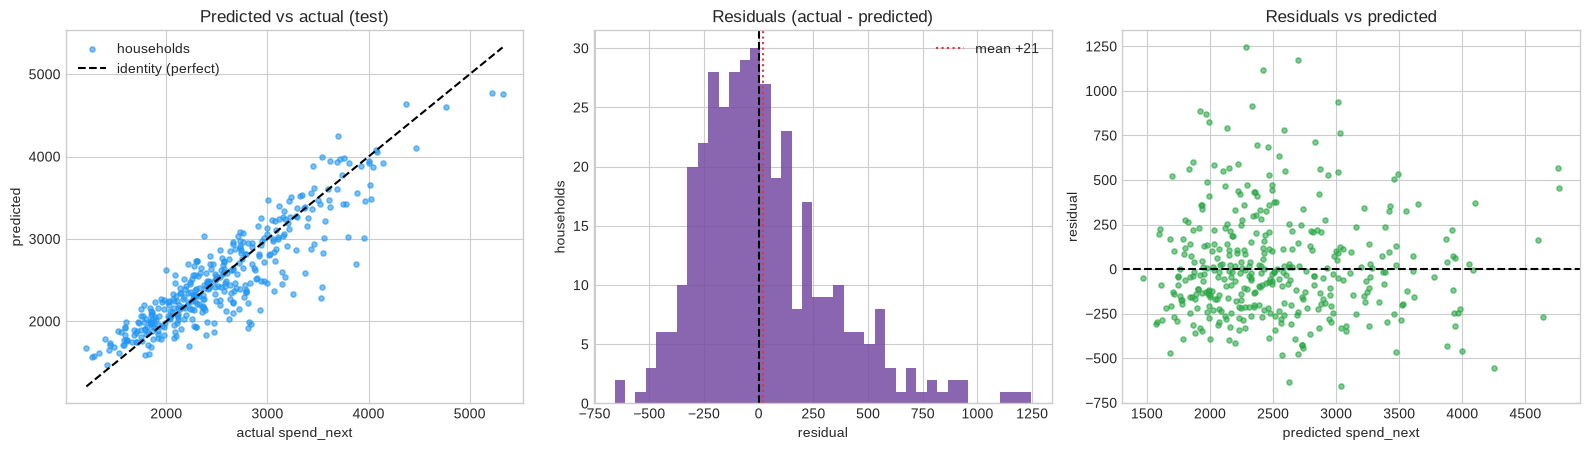

residual std 300.7; |residual| > 2 RMSE in 18 of 375 households (4.8%);  largest miss +1244
skew of residuals (positive = a few large under-predictions): 1.02


In [32]:
resid = y_reg - pred_reg
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].scatter(y_reg, pred_reg, s=14, alpha=0.6, color="#2196F3", label="households")
lim = [min(y_reg.min(), pred_reg.min()), max(y_reg.max(), pred_reg.max())]
axes[0].plot(lim, lim, "k--", label="identity (perfect)")
axes[0].set_title("Predicted vs actual (test)"); axes[0].set_xlabel("actual spend_next"); axes[0].set_ylabel("predicted"); axes[0].legend()
axes[1].hist(resid, bins=40, color="#764ba2", alpha=0.85)
axes[1].axvline(0, color="k", ls="--"); axes[1].axvline(resid.mean(), color="#dc3545", ls=":", label=f"mean {resid.mean():+.0f}")
axes[1].set_title("Residuals (actual - predicted)"); axes[1].set_xlabel("residual"); axes[1].set_ylabel("households"); axes[1].legend()
axes[2].scatter(pred_reg, resid, s=14, alpha=0.6, color="#28a745")
axes[2].axhline(0, color="k", ls="--")
axes[2].set_title("Residuals vs predicted"); axes[2].set_xlabel("predicted spend_next"); axes[2].set_ylabel("residual")
plt.tight_layout(); plt.show()

big = np.abs(resid) > 2 * reg_table.RMSE.iloc[2]
print(f"residual std {resid.std():.1f}; |residual| > 2 RMSE in {big.sum()} of {len(resid)} households ({big.mean():.1%});  largest miss {resid[np.abs(resid).argmax()]:+.0f}")
print("skew of residuals (positive = a few large under-predictions):", round(float(pd.Series(resid).skew()), 2))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the cloud hugs the diagonal, with a few points far above it (the model under-predicted a large spend). Middle: the residuals are centred near zero (the red mean line sits on the dashed zero line) but the right tail is longer than the left: the dataset's *surprise expenses* (a car repair, medical bills) land in `other` next month and nothing in this month's features announces them. Right: the spread is similar across predicted values, so there is no strong sign that errors grow with the amount.

The common misread: taking a symmetric-looking histogram as proof the model is fine. The printed skew and the count of large misses are the numbers to watch; a long tail of under-predictions is exactly what a point forecast cannot express, which is what quantiles are for.

</div>

## 9.3 Quantile regression: an interval instead of a number

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

"You will spend about 2,400" is less useful than "between 2,100 and 2,900, most likely 2,400". `problem_type="quantile"` with `quantile_levels=[0.1, 0.5, 0.9]` trains one model that outputs three numbers per household: the 10th percentile, the median and the 90th percentile. The gap between the 0.1 and 0.9 outputs is an **80% prediction interval**, and it can be wide for some households and narrow for others.

Two checks tell you whether the interval is honest: **coverage** (what fraction of actual values fall inside; the target is 80%) and **pinball loss**, the metric AutoGluon optimises for quantiles.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

The **pinball loss** for quantile level $\tau$ and prediction $q$ is

$$ L_\tau(y, q) = \begin{cases} \tau \,(y - q) & y \ge q \\ (1 - \tau)(q - y) & y < q \end{cases} $$

For $\tau = 0.9$ an under-prediction costs 0.9 per unit and an over-prediction 0.1 per unit, so the minimiser is the value that 90% of outcomes fall below. For $\tau = 0.5$ it is half the absolute error, so the median model is an MAE model.

</div>


⏱️ fit [quantile] with a 60 s budget: 31.45 s


eval_metric=pinball_loss; predict() returns columns [0.1, 0.5, 0.9]
80% interval: empirical coverage 78.4% (target 80%)  |  below the 10th pct 9.9% (target 10%)  |  above the 90th pct 11.7% (target 10%)
pinball loss per level: {0.1: 40.2, 0.5: 111.8, 0.9: 65.9} | mean: 72.6


AutoGluon evaluate(): {'pinball_loss': -72.65}
median model MAE 223.7 vs regression predictor MAE 225.6


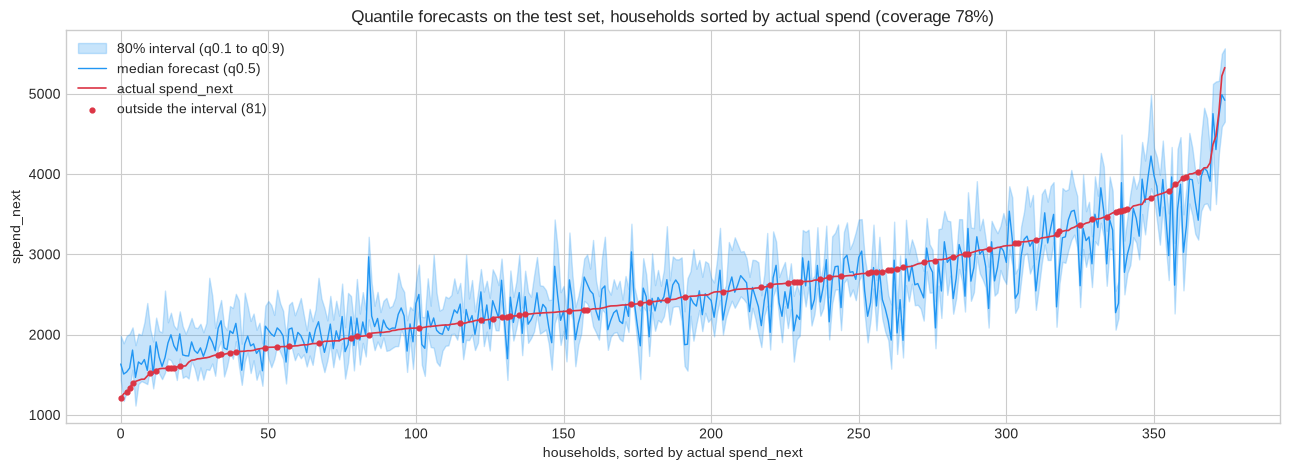

interval width: median 636, min 348, max 1527  (the model widens where it is unsure)


In [33]:
QUANTILES = [0.1, 0.5, 0.9]
qreg = fit_tabular(train_df[TAB_FEATURES + [LABEL_REG]], LABEL_REG, time_limit=60,
                   predictor_kwargs={"problem_type": "quantile", "quantile_levels": QUANTILES})
q_pred = qreg.predict(test_df)                                          # one column per quantile level
q_pred.columns = [float(c) for c in q_pred.columns]
lo, mid, hi = (q_pred[q].to_numpy() for q in QUANTILES)

def pinball(y, q, tau):
    diff = y - q
    return float(np.mean(np.where(diff >= 0, tau * diff, (tau - 1) * diff)))

coverage = float(np.mean((y_reg >= lo) & (y_reg <= hi)))
below, above = float(np.mean(y_reg < lo)), float(np.mean(y_reg > hi))
print(f"eval_metric={qreg.eval_metric.name}; predict() returns columns {list(q_pred.columns)}")
print(f"80% interval: empirical coverage {coverage:.1%} (target 80%)  |  below the 10th pct {below:.1%} (target 10%)  |  above the 90th pct {above:.1%} (target 10%)")
print("pinball loss per level:", {tau: round(pinball(y_reg, q_pred[tau].to_numpy(), tau), 1) for tau in QUANTILES},
      "| mean:", round(np.mean([pinball(y_reg, q_pred[t].to_numpy(), t) for t in QUANTILES]), 1))
print("AutoGluon evaluate():", {k: round(float(v), 2) for k, v in qreg.evaluate(test_df, silent=True).items()})
print(f"median model MAE {mean_absolute_error(y_reg, mid):.1f} vs regression predictor MAE {reg_table.MAE.iloc[2]:.1f}")

order = np.argsort(y_reg)
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.fill_between(np.arange(len(order)), lo[order], hi[order], color="#2196F3", alpha=0.25, label="80% interval (q0.1 to q0.9)")
ax.plot(mid[order], color="#2196F3", lw=1, label="median forecast (q0.5)")
ax.plot(y_reg[order], color="#dc3545", lw=1.2, label="actual spend_next")
outside = (y_reg[order] < lo[order]) | (y_reg[order] > hi[order])
ax.scatter(np.where(outside)[0], y_reg[order][outside], color="#dc3545", s=12, zorder=3, label=f"outside the interval ({outside.sum()})")
ax.set_title(f"Quantile forecasts on the test set, households sorted by actual spend (coverage {coverage:.0%})")
ax.set_xlabel("households, sorted by actual spend_next"); ax.set_ylabel("spend_next"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()
widths = hi - lo
print(f"interval width: median {np.median(widths):.0f}, min {widths.min():.0f}, max {widths.max():.0f}  (the model widens where it is unsure)")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Households are sorted by their actual spend, so the red line rises smoothly. The blue band should contain about 80% of the red line, and the red dots mark the households it missed. The printed split of misses matters more than the total: the surprise expenses from 9.2 show up as misses *above* the 90th percentile, which the interval cannot foresee any better than the point forecast could. The printed widths show the band is not constant; where the features suggest a volatile household, the model spreads the quantiles.

The common misread: "coverage below 80% means the model is broken". It means the interval is over-confident by that much on this test set, which is worth knowing and often fixable: AutoGluon's `calibrate=True` for quantile problems applies **conformalisation**, a shift of each quantile fitted on validation data so that coverage matches the nominal level (in 1.6.3 the `"auto"` default requires 1000 validation rows, so it did not run here).

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: quantiles can cross

Nothing in a quantile model forces the 0.1 output to stay below the 0.9 output for every row. Check `(q_pred[0.1] <= q_pred[0.5]).all()` and `(q_pred[0.5] <= q_pred[0.9]).all()` before you show an interval; a crossed pair means a negative-width interval for that household. Sorting the three outputs per row is the usual quick fix.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: report the interval with its coverage

An interval without its measured coverage is decoration. Report the nominal level (80%), the empirical coverage on held-out data, and the split of misses (below vs above). A well-behaved interval misses about equally on both sides; a one-sided miss pattern, as here, tells you *which* tail the features cannot see, which is a data question, not a modelling one.

</div>

## 9.4 Task 9 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `problem_type="regression"` with `eval_metric="mean_absolute_error"` optimises an error in the target's own units; the leaderboard shows it negated.
- Judge a regressor against the persistence baseline, not only the mean; the gain over "nothing changes" is the model's real value.
- The three residual pictures found a long right tail: surprise expenses that no feature announces.
- `problem_type="quantile"` gives an interval per household; check its coverage and the side of the misses. Pinball loss is the metric behind it.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `reg`, `pred_reg`, `y_reg`, `resid` | the regression predictor, its test predictions, the truth, the residuals |
| `reg_table`, `lb_reg` | report cards (mean, persistence, AutoGluon) and the leaderboard |
| `qreg`, `QUANTILES`, `q_pred`, `lo`, `mid`, `hi` | the quantile predictor and its three outputs |
| `pinball(y, q, tau)`, `coverage` | the quantile loss by hand and the empirical 80% coverage |

### ➡️ Next Up

Task 10 makes one small change to how the table is built and gets an $R^2$ that is too good to be true. Then it shows how to notice.

</div>


# Task 10 · The leakage trap

## 10.1 Building the wrong table on purpose

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The scenario

A colleague wants a spend model and builds it from the raw `budget` export: one row per household-month, features are the month's category spends, the target is that month's `total_spend`. Nothing in the code is wrong. The training table is. `total_spend` is the sum of the category columns, so the model is asked to predict a number from its own summands.

This is **target leakage**: a feature that carries information about the label that will not exist at prediction time (or that *is* the label in disguise). Part 0 warned about it; this task shows what it looks like from the inside.

</div>

The cell builds that table from the same feature month `household_table` uses, keeps the same households in train and test as `hh`, and fits for 30 seconds.


In [34]:
months = sorted(budget.month.unique())
feat_month = months[-2]                                                 # the month whose columns are hh's features
CATEGORIES = ["rent", "groceries", "utilities", "transport", "dining", "entertainment", "other"]
LEAK_FEATURES = ["city_tier", "household_size", "owns_car", "income"] + CATEGORIES + ["survey_score", "referral_code"]

leak_df = budget[budget.month == feat_month].set_index("household_id")
leak_train = leak_df.loc[train_df[ID_COL], LEAK_FEATURES + ["total_spend"]].reset_index(drop=True)
leak_test = leak_df.loc[test_df[ID_COL], LEAK_FEATURES + ["total_spend"]].reset_index(drop=True)

# the smoking gun, before any model: the target is (almost exactly) a sum of the features
cat_sum = leak_test[CATEGORIES].sum(axis=1, skipna=True)
complete = leak_test[CATEGORIES].notna().all(axis=1)
print(f"target month: {feat_month:%Y-%m}  |  rows train {len(leak_train)} / test {len(leak_test)}")
print(f"max |sum(categories) - total_spend| on rows with no missing category: {np.abs(cat_sum[complete] - leak_test.total_spend[complete]).max():.1f} (rounding only)")
print(f"correlation(sum of categories, total_spend) = {np.corrcoef(cat_sum[complete], leak_test.total_spend[complete])[0, 1]:.4f}")

leak_reg = fit_tabular(leak_train, "total_spend", time_limit=30,
                       predictor_kwargs={"problem_type": "regression", "eval_metric": "mean_absolute_error"})
leak_card = report_card(leak_test.total_spend, leak_reg.predict(leak_test), name="LEAKED: this month's total from this month's categories", task="regression")
honest_card = reg_table.iloc[[2]].rename(index={reg_table.index[2]: "HONEST: next month's total from this month's features"})
leak_table = pd.concat([leak_card, honest_card])
display(pretty(leak_table, fmt="{:.2f}", highlight="min", subset=["MAE", "RMSE", "MedAE", "MAPE_%"]))
print(f"R2: leaked {leak_card.R2.item():.4f} vs honest {honest_card.R2.item():.3f}   |   MAE: leaked {leak_card.MAE.item():.1f} vs honest {honest_card.MAE.item():.1f}")
print(f"leaked model's validation score (-MAE): {leak_reg.leaderboard(silent=True).score_val.max():.2f}  <- 'too good' shows up in validation already")


target month: 2025-11  |  rows train 1125 / test 375
max |sum(categories) - total_spend| on rows with no missing category: 2.0 (rounding only)
correlation(sum of categories, total_spend) = 1.0000


⏱️ fit [mean_absolute_error] with a 30 s budget: 30.71 s


,MAE,RMSE,MedAE,MAPE_%,R2,bias
model,,,,,,
LEAKED: this month's total from this month's categories,41.36,89.45,23.79,1.57,0.982966,7.981712
HONEST: next month's total from this month's features,225.59,301.43,183.97,9.07,0.807623,20.606373


R2: leaked 0.9830 vs honest 0.808   |   MAE: leaked 41.4 vs honest 225.6
leaked model's validation score (-MAE): -43.67  <- 'too good' shows up in validation already


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Same households, same 30-second budget, a different question. The leaked model's $R^2$ is close to 1 and its MAE is a small fraction of the honest model's, because the answer was in the inputs: the printed correlation between the category sum and the target is essentially 1. Note the last line: the **validation** score was already impossibly good. Leakage does not hide in the test set; it shows up the moment the first model reports a score, if you know what a plausible score looks like.

The common misread: "the honest model is worse, so the leaked one is the better model". The leaked model answers a question nobody asked (what was this month's total, given this month's line items) and cannot answer the real one (what will next month's total be).

</div>

## 10.2 The second smoking gun: feature importance

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

`feature_importance` shuffles one column at a time and measures how much the score drops (permutation importance; Part 6 goes deeper). A healthy model spreads importance across several features that plausibly cause the outcome. A leaked model concentrates it on the columns that *are* the outcome. Comparing the two profiles side by side is the fastest audit you can run on any model you did not build yourself.

</div>


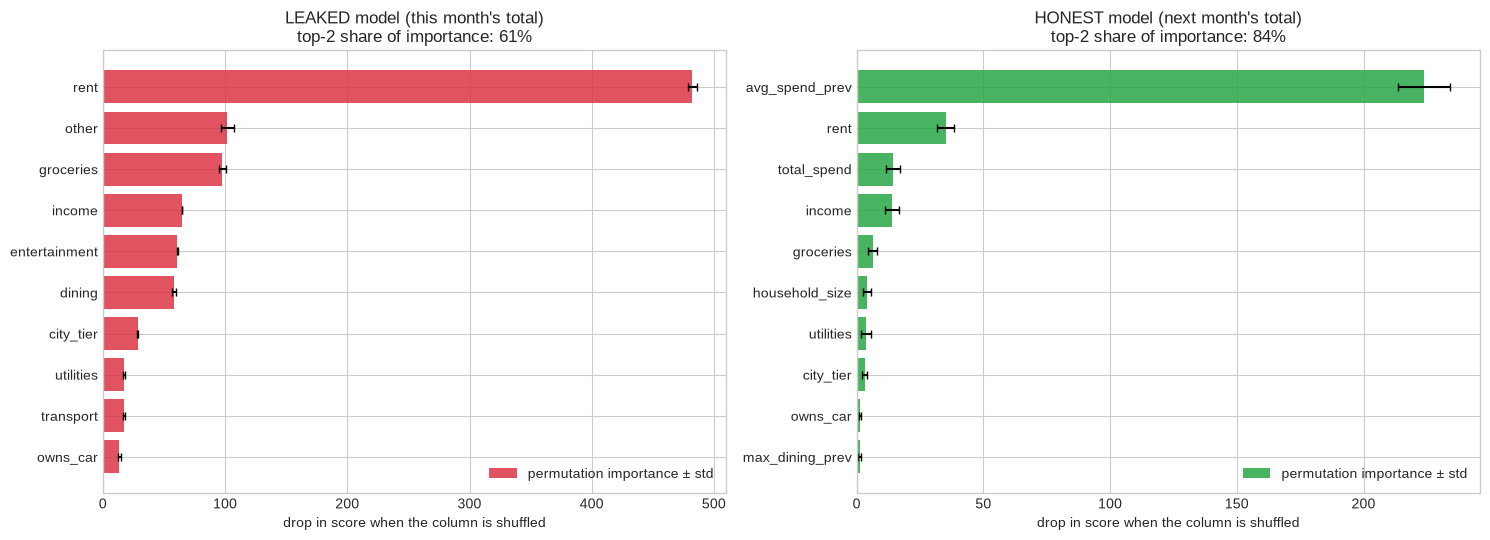

leaked model, top 5 features:  rent (482), other (102), groceries (98), income (65), entertainment (61)
honest model, top 5 features:  avg_spend_prev (224), rent (35), total_spend (14), income (14), groceries (6)
categories among the leaked top-3: 3 of 3


In [35]:
fi_leak = leak_reg.feature_importance(leak_test, num_shuffle_sets=3, silent=True)
fi_honest = reg.feature_importance(test_df, num_shuffle_sets=3, silent=True)

def top_share(fi, k=2):
    pos = fi.importance.clip(lower=0)
    return float(pos.sort_values(ascending=False).head(k).sum() / pos.sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, fi, title, color in [(axes[0], fi_leak, "LEAKED model (this month's total)", "#dc3545"),
                             (axes[1], fi_honest, "HONEST model (next month's total)", "#28a745")]:
    top = fi.head(10).iloc[::-1]
    ax.barh(top.index, top.importance, xerr=top.stddev, color=color, alpha=0.85, capsize=3, label="permutation importance ± std")
    ax.set_title(f"{title}\ntop-2 share of importance: {top_share(fi):.0%}"); ax.set_xlabel("drop in score when the column is shuffled"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("leaked model, top 5 features: ", ", ".join(f"{f} ({v:.0f})" for f, v in fi_leak.importance.head(5).items()))
print("honest model, top 5 features: ", ", ".join(f"{f} ({v:.0f})" for f, v in fi_honest.importance.head(5).items()))
print("categories among the leaked top-3:", sum(f in CATEGORIES for f in fi_leak.head(3).index), "of 3")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the leaked model lives on the category columns, `rent` first (it is the largest summand), and the top-two share printed in the title says how concentrated that is. Right: the honest model spreads importance over history aggregates (`avg_spend_prev`), the current total and income, which is what a forecast *should* depend on, and the bars are small in absolute terms because the honest score is smaller to begin with. The error bars come from three shuffle repeats; Part 6 uses more and adds p-values.

The common misread: taking a high importance for `rent` in the honest model as leakage too. Rent is stable month to month, so it legitimately predicts next month's total; leakage is when a feature is a *function of the label*, not when it is merely predictive.

</div>

## 10.3 How to spot leakage before it ships

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: three checks, in this order, every time

1. **Plausibility of the first score.** Know what a good score looks like for the problem (the persistence baseline of Task 9 is a good anchor). A validation $R^2$ near 1, or a ROC-AUC near 1, on a problem about *people's future behaviour* is a bug until proven otherwise.
2. **Importance concentration.** If one or two columns own most of the importance, ask whether each is available *at prediction time* and whether it is *computed from* the label. A column that is a sum, difference, ratio or lagged copy of the label is a leak.
3. **A time-aware split.** Features must be observable strictly before the target. `household_table` enforces this by construction: features from month $m-1$, history from months $< m-1$, target from month $m$. A random split of household-months would put a household's month $m$ in training and its month $m+1$ in test, where the test row's `total_spend` feature *is* the training row's target.

</div>

The last cell prints the timeline `household_table` used, so the rule is visible rather than assumed, and runs the three checks as code.


In [36]:
import os
hist_months = [m for m in months if m < feat_month]
print("timeline used by household_table():")
print(f"  history aggregates  <- months {hist_months[0]:%Y-%m} .. {hist_months[-1]:%Y-%m}  ({len(hist_months)} months, strictly before the feature month)")
print(f"  features            <- month  {feat_month:%Y-%m}")
print(f"  targets             <- month  {months[-1]:%Y-%m}  ({LABEL_REG}, {LABEL_CLS})")

def leakage_checks(fi, r2, features, label_parts, baseline_r2):
    # three yes/no checks; ⚠️ means "investigate", not "guilty"
    checks = {
        "score plausible (R2 not far above the persistence baseline)": r2 < baseline_r2 + 0.15,
        "importance spread (top-2 share below 60%)": top_share(fi) < 0.60,
        "no feature is an arithmetic part of the label": not any(f in label_parts for f in features),
    }
    return pd.Series({k: ("✅" if v else "⚠️") for k, v in checks.items()})

persist_r2 = reg_table.R2.iloc[1]
audit = pd.DataFrame({
    "leaked model": leakage_checks(fi_leak, leak_card.R2.item(), LEAK_FEATURES, CATEGORIES, persist_r2),
    "honest model": leakage_checks(fi_honest, honest_card.R2.item(), TAB_FEATURES, [], persist_r2),
})
print("\n" + audit.to_string())
print(f"\n(persistence baseline R2 = {persist_r2:.3f}; leaked R2 = {leak_card.R2.item():.3f}; honest R2 = {honest_card.R2.item():.3f})")

# housekeeping: every predictor of Parts 3-4 lives in its own temp directory; this is what they cost on disk
def dir_mb(path):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(path) for f in fs) / 1e6
stage_predictors = {"f1": metric_preds["f1"], "roc_auc (clf)": clf, "log_loss": metric_preds["log_loss"], "weighted": weighted_pred,
                    "calibrated": calibrated_pred, "regression": reg, "quantile": qreg, "leaked": leak_reg}
print("disk used by the predictors of Parts 3-4: " + ", ".join(f"{k} {dir_mb(p.path):.1f} MB" for k, p in stage_predictors.items()))


timeline used by household_table():
  history aggregates  <- months 2024-01 .. 2025-10  (22 months, strictly before the feature month)
  features            <- month  2025-11
  targets             <- month  2025-12  (spend_next, overspent_next)

                                                            leaked model honest model
score plausible (R2 not far above the persistence baseline)           ⚠️            ✅
importance spread (top-2 share below 60%)                             ⚠️           ⚠️
no feature is an arithmetic part of the label                         ⚠️            ✅

(persistence baseline R2 = 0.660; leaked R2 = 0.983; honest R2 = 0.808)
disk used by the predictors of Parts 3-4: f1 20.8 MB, roc_auc (clf) 20.5 MB, log_loss 20.5 MB, weighted 22.3 MB, calibrated 0.3 MB, regression 53.3 MB, quantile 66.3 MB, leaked 44.4 MB


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the subtle leaks are the ones that pass all three checks

The trap in this task was loud. Real ones are quiet: a "days since last contact" feature computed *after* the outcome, a customer-level average that includes the row being predicted, a category encoded with the target's mean over the whole table instead of over the training folds. None of those has a correlation of 1 with the label, and each inflates the score by a few points. The defence is the same, applied stubbornly: for every feature, write down the moment it becomes known, and compare that moment with the moment the prediction must be made.

</div>

## 10.4 Task 10 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Target leakage is a feature that is a function of, or observed after, the label; the leaked table scored an $R^2$ near 1 and the honest one did not.
- The first sign is a score that is too good, and it appears in **validation**, before any test set is touched.
- The second sign is importance concentrated on the columns that compose the label; `feature_importance` is the audit tool.
- A time-aware split (features strictly before the target, history strictly before the features) is the structural fix; `household_table` implements it.

### 🔑 New variables

| Variable | What it is |
|---|---|
| `leak_train`, `leak_test`, `LEAK_FEATURES`, `CATEGORIES` | the wrong table and its columns |
| `leak_reg`, `leak_card`, `leak_table` | the leaked predictor and its report next to the honest one |
| `fi_leak`, `fi_honest`, `top_share(fi, k)` | permutation importances and their concentration |
| `leakage_checks(...)`, `audit` | the three-check audit as a ✅/⚠️ table |

### ➡️ Next Up

Part 5 opens the hood: presets, time budgets, bagging, stacking and hyperparameters, and what each one buys.

</div>


# Part 5 · The Knobs: Presets, Time Budgets, Bagging, Stacking, Hyperparameters ⭐⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Every predictor this Part needs is trained fresh here, on short budgets, so the Part stands on its own. Parts 1 to 4 used `fit()` with two arguments: a time limit and a preset. Behind those two arguments sit five knobs: **which models** to train (`hyperparameters`), **how long** (`time_limit`), **how many copies of each on different folds** (`num_bag_folds`), **how many layers** (`num_stack_levels`), and **whether to search** inside a model family (`hyperparameter_tune_kwargs`). This Part turns each knob on the same household data and measures what it buys: in ROC-AUC, in training seconds, and in inference seconds.

</div>


# Task 11 · Presets and Time Budgets

## 11.1 One argument that sets five others

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A **preset** is a named bundle of fit arguments. `presets="medium_quality"` means "train one copy of each model in the default zoo, then a weighted ensemble on top". `presets="best_quality"` means "train several copies of each model on different folds, stack them, and use the larger portfolio". The preset decides *what* gets trained; `time_limit` decides *how much of it* gets trained before AutoGluon stops. The two interact: a rich preset on a short budget trains a few models badly, a plain preset on a long budget trains all its models and then idles.

The honest way to choose is to measure. Below, one helper fits a predictor and records four numbers: wall-clock fit time, number of models, ROC-AUC on the test set, and the time to score the test set. Every fit in Parts 5 and 6 goes through it, so the rows are comparable.

</div>


In [37]:
# ============================================================
#  fit_tabular(): one fit, one comparable row
# ============================================================
import tempfile, inspect, re
from autogluon.tabular import TabularPredictor
import autogluon.tabular as agt

TAB_FEATURES = [f for f in FEATURES if f != "note"]        # the text column is Part 8's business
TRAIN_TAB = train_df[TAB_FEATURES + [LABEL_CLS]]
TEST_TAB = test_df[TAB_FEATURES + [LABEL_CLS]]
N_CPUS = 4                                                  # a fixed core count keeps timings comparable between runs
assert "num_cpus" in inspect.signature(TabularPredictor.fit).parameters, "num_cpus is a fit() argument since AutoGluon 1.x"
FIT_LOG = []                                                # one row per fit in Parts 5-6


def fit_tabular(name, time_limit, presets="medium_quality", train=None, **fit_kwargs):
    # Fit a binary predictor on `train` (default: the tabular training set), score it on the test set,
    # and append a row of comparable numbers to FIT_LOG. Returns (predictor, row).
    train = TRAIN_TAB if train is None else train
    feats = [c for c in train.columns if c != LABEL_CLS]
    t0 = _time.perf_counter()
    pred = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=tempfile.mkdtemp(), verbosity=0)
    pred.fit(train, time_limit=time_limit, presets=presets, num_cpus=N_CPUS, **fit_kwargs)
    fit_wall = _time.perf_counter() - t0
    t1 = _time.perf_counter()
    prob = pred.predict_proba(test_df[feats]).iloc[:, 1].values
    infer_wall = _time.perf_counter() - t1
    lb = pred.leaderboard(test_df[feats + [LABEL_CLS]], silent=True)
    best = pred.model_best
    row = {"run": name, "time_limit_s": time_limit, "fit_wall_s": fit_wall, "n_models": len(lb), "best_model": best,
           "roc_auc_val": float(lb.loc[lb.model == best, "score_val"].iloc[0]),
           "roc_auc_test": roc_auc_score(test_df[LABEL_CLS], prob),
           "infer_s": infer_wall}
    FIT_LOG.append(row)
    print(f"{name:<28s} limit {time_limit:>3d}s | fit {fit_wall:6.1f}s | {len(lb):2d} models | best {best:<22s} | ROC-AUC test {row['roc_auc_test']:.4f} | infer {infer_wall*1000:5.0f} ms")
    return pred, row


print(f"AutoGluon {agt.__version__} | {len(TAB_FEATURES)} tabular features | train {len(TRAIN_TAB):,} rows | test {len(TEST_TAB):,} rows | num_cpus={N_CPUS}")


AutoGluon 1.6.3 | 18 tabular features | train 1,125 rows | test 375 rows | num_cpus=4


## 11.2 What the preset names mean in 1.6

The preset table lives in the library itself, so read it from there rather than from memory. Each entry is a dict of `fit()` arguments that the preset sets for you.


In [38]:
# ============================================================
#  The preset table, straight from the library
# ============================================================
from autogluon.tabular.configs.presets_configs import tabular_presets_dict, tabular_presets_alias

MAIN_PRESETS = ["medium_quality", "good_quality", "high_quality", "best_quality", "extreme_quality"]
rows = []
for p in MAIN_PRESETS:
    cfg = tabular_presets_dict[p]
    rows.append({"preset": p,
                 "portfolio (hyperparameters)": cfg.get("hyperparameters", "default"),
                 "auto_stack": cfg.get("auto_stack", False),
                 "num_bag_folds": cfg.get("num_bag_folds", "auto" if cfg.get("auto_stack") else 0),
                 "dynamic_stacking": cfg.get("dynamic_stacking", False),
                 "refit_full": cfg.get("refit_full", False),
                 "default time_limit": cfg.get("time_limit", "none")})
preset_table = pd.DataFrame(rows).set_index("preset")
print(preset_table.to_string())
print()
print("Short aliases:", {k: v for k, v in tabular_presets_alias.items() if len(k) <= 3})
print("Other named presets:", [p for p in tabular_presets_dict if p not in MAIN_PRESETS and not p.endswith(("v082", "v120", "v140", "v150"))])


                portfolio (hyperparameters)  auto_stack num_bag_folds dynamic_stacking  refit_full default time_limit
preset                                                                                                               
medium_quality                      default       False             0            False       False               none
good_quality                          light        True          auto             auto        True               3600
high_quality                       zeroshot        True          auto             auto        True               3600
best_quality                       zeroshot        True          auto             auto       False               3600
extreme_quality       commercial_2026_08_05       False             8            False       False               3600

Short aliases: {'eq': 'extreme_quality', 'bq': 'best_quality', 'hq': 'high_quality', 'gq': 'good_quality', 'mq': 'medium_quality'}
Other named presets: ['optimize_for_deploy

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading the table

| Preset | What it turns on | When to reach for it |
|---|---|---|
| `medium_quality` | The default model zoo (LightGBM, CatBoost, XGBoost, random forest, extra trees, two neural nets), one copy each, no bagging, one weighted ensemble on top. | Prototyping. Fast to train, fast to score. |
| `good_quality` | The `light` portfolio with bagging and stacking (`auto_stack`), then `refit_full`: after validation, every model is retrained on all the data and the bagged copies are dropped, so inference is fast. | A deployable model on a modest budget. |
| `high_quality` | The `zeroshot` portfolio (configurations chosen offline on hundreds of benchmark datasets) with `auto_stack`, then `refit_full` for fast inference. | Strong accuracy with cheap inference. |
| `best_quality` | Same portfolio with `auto_stack` and `dynamic_stacking="auto"`, no refit. Keeps every bagged copy, so inference is slower and the model directory larger. | Leaderboards; accuracy matters more than latency. |
| `extreme_quality` | New in 1.6: a portfolio that includes tabular **foundation models** (Part 11) with 8 bag folds and no stacking. | Small and medium tables where pretrained models shine; needs the extra weights. |

`ignore_text`, `interpretable` and `optimize_for_deployment` are modifiers you can pass in the same list, for example `presets=["good_quality", "optimize_for_deployment"]`. The `experimental_quality` preset from 1.2 was renamed; its alias now points at an `extreme_quality` variant.

</div>


## 11.3 Three fits, one plot

The three fits below keep everything fixed except the preset and the budget. The third fit sets `num_bag_folds=3` and `num_stack_levels=0` explicitly so that `best_quality`'s `auto_stack` does not pick a fold count that cannot finish in the budget, and `dynamic_stacking=False` because the dynamic check (Task 12) needs a budget of its own. `fold_fitting_strategy="sequential_local"` fits the bagged copies one after another instead of in parallel worker processes, which keeps memory flat on a small machine.


In [39]:
# ============================================================
#  medium_quality at 20 s and 40 s, best_quality (bagged) at 60 s
# ============================================================
BAG_ARGS = dict(ag_args_ensemble={"fold_fitting_strategy": "sequential_local"})   # one fold at a time: flat memory

with timer("three fits"):
    pred_20, _ = fit_tabular("medium_quality / 20 s", 20, "medium_quality")
    pred_40, _ = fit_tabular("medium_quality / 40 s", 40, "medium_quality")
    pred_bag, _ = fit_tabular("best_quality bag3 / 60 s", 60, "best_quality",
                              num_bag_folds=3, num_stack_levels=0, dynamic_stacking=False, **BAG_ARGS)

pred_ref = pred_40            # the reference predictor Part 6 explains
budget_table = pd.DataFrame(FIT_LOG).set_index("run")
pretty(budget_table, fmt={"time_limit_s": "{:d}", "fit_wall_s": "{:.1f}", "n_models": "{:d}", "roc_auc_val": "{:.4f}", "roc_auc_test": "{:.4f}", "infer_s": "{:.3f}"},
       subset=["roc_auc_test"])


medium_quality / 20 s        limit  20s | fit   14.9s | 12 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9388 | infer   201 ms


medium_quality / 40 s        limit  40s | fit   15.0s | 12 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9388 | infer   199 ms


best_quality bag3 / 60 s     limit  60s | fit   60.7s | 17 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9388 | infer   388 ms
⏱️ three fits: 94.08 s


,time_limit_s,fit_wall_s,n_models,best_model,roc_auc_val,roc_auc_test,infer_s
run,,,,,,,
medium_quality / 20 s,20,14.907063,12,WeightedEnsemble_L2,0.868421,0.9388,0.200521
medium_quality / 40 s,40,14.986506,12,WeightedEnsemble_L2,0.868421,0.9388,0.199375
best_quality bag3 / 60 s,60,60.710635,17,WeightedEnsemble_L2,0.919612,0.9388,0.387936


In [40]:
# the same three predictors through the shared report card, at the default 0.5 threshold
cards = []
for name, p in [("medium 20 s", pred_20), ("medium 40 s", pred_40), ("best bag3 60 s", pred_bag)]:
    prob = p.predict_proba(test_df[TAB_FEATURES]).iloc[:, 1].values
    cards.append(report_card(test_df[LABEL_CLS], (prob >= 0.5).astype(int), prob, name=name))
preset_cards = pd.concat(cards)
pretty(preset_cards, subset=["balanced_acc", "f1", "mcc", "roc_auc", "pr_auc"])


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
medium 20 s,0.920000,0.806,0.851064,0.634921,0.727,0.692,0.939,0.819,0.224334,0.064833
medium 40 s,0.920000,0.806,0.851064,0.634921,0.727,0.692,0.939,0.819,0.224334,0.064833
best bag3 60 s,0.917333,0.817,0.807692,0.666667,0.730,0.687,0.939,0.823,0.221071,0.064184


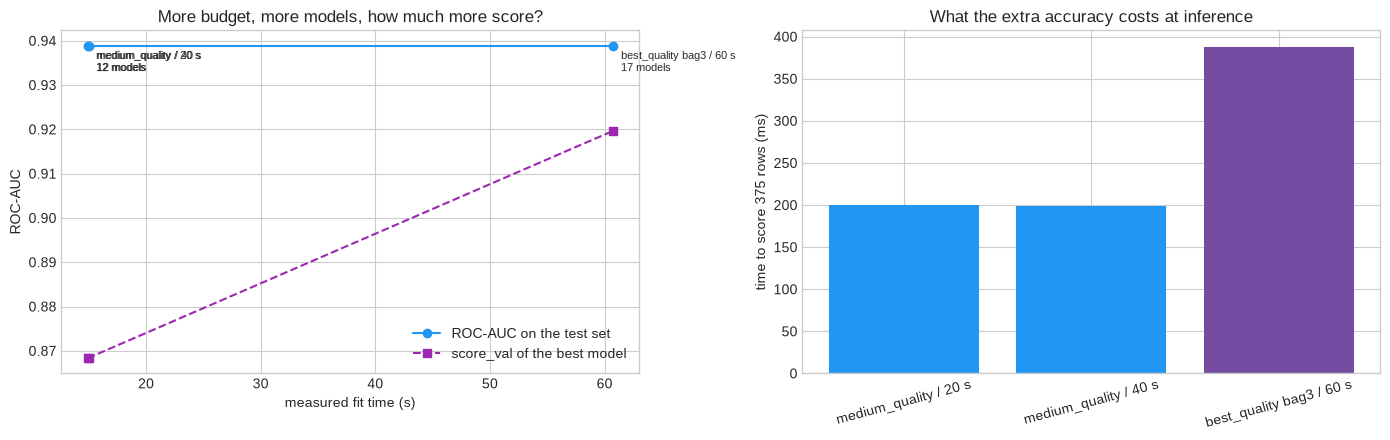

ROC-AUC spread across the three fits: 0.0000 | fit time ratio slowest/fastest: 4.1x | inference ratio: 1.9x


In [41]:
# ============================================================
#  Score vs time, with the inference cost on the second axis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
bt = budget_table.reset_index()
ax = axes[0]
ax.plot(bt.fit_wall_s, bt.roc_auc_test, "o-", color="#2196F3", label="ROC-AUC on the test set")
ax.plot(bt.fit_wall_s, bt.roc_auc_val, "s--", color="#9c27b0", label="score_val of the best model")
for _, r in bt.iterrows():
    ax.annotate(f"{r.run}\n{r.n_models} models", (r.fit_wall_s, r.roc_auc_test), textcoords="offset points", xytext=(6, -18), fontsize=8)
ax.set_xlabel("measured fit time (s)"); ax.set_ylabel("ROC-AUC"); ax.set_title("More budget, more models, how much more score?"); ax.legend()
ax = axes[1]
ax.bar(bt.run, bt.infer_s * 1000, color=["#2196F3", "#2196F3", "#764ba2"])
ax.set_ylabel(f"time to score {len(test_df)} rows (ms)"); ax.set_title("What the extra accuracy costs at inference"); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
gain = bt.roc_auc_test.max() - bt.roc_auc_test.min()
print(f"ROC-AUC spread across the three fits: {gain:.4f} | fit time ratio slowest/fastest: {bt.fit_wall_s.max() / bt.fit_wall_s.min():.1f}x | inference ratio: {bt.infer_s.max() / bt.infer_s.min():.1f}x")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: test ROC-AUC (solid) against measured fit time for the three runs. The spread between the three points (printed under the plot) is all that the extra budget and bagging bought on this dataset, and it need not grow with time: on a table of about a thousand rows the models saturate after a few seconds, and the remaining differences are inside the noise of a test set this size. The dashed line is `score_val`, and it jumps for the bagged run: for a bagged model `score_val` is the out-of-fold score over all training rows, not the score on a small holdout, so the two solid-vs-dashed lines measure different things and should not be compared across runs. Right: the bagged predictor scores the same test rows several times slower, because every prediction averages three copies of each model.

The common misread: taking `score_val` as "the accuracy" and concluding the bagged run is far better than the others. Compare runs on the same held-out test set, as the solid line does.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `time_limit` is a target, not a guarantee

Compare `fit_wall_s` with `time_limit_s` in the table above: measured time can overshoot the limit. AutoGluon plans each model's share of the budget from an estimate, and the last model in flight is allowed to finish. Budget for the overshoot when the fit runs inside a job with its own timeout, and pass `time_limit` a little below the deadline.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: choose the preset by the deployment constraint, then give it time

Pick `good_quality` or `high_quality` when the model must answer quickly (both end with `refit_full`, which removes the bagged copies), `best_quality` when accuracy is all that matters, and `medium_quality` while iterating on the data. Then raise `time_limit` before touching any other knob: the portfolio behind each preset was chosen on hundreds of datasets, and more time lets more of it train.

</div>


## 11.4 Task 11 Summary

### ✅ Key Takeaways
- A preset is a bundle of `fit()` arguments: portfolio, bagging, stacking, dynamic stacking and refit. Read `tabular_presets_dict` to see exactly what each sets.
- `time_limit` caps the whole fit; the measured wall time can overshoot it by the last model in flight.
- On a small table the accuracy gain from a richer preset is small; the inference cost of keeping bagged copies is not.
- `score_val` means a holdout score for unbagged models and an out-of-fold score for bagged ones. Compare runs on the test set.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `TAB_FEATURES`, `TRAIN_TAB`, `TEST_TAB` | The feature list without the text column, and the two splits restricted to it |
| `fit_tabular(name, time_limit, presets, ...)` | One fit, one comparable row appended to `FIT_LOG` |
| `pred_20`, `pred_40`, `pred_bag` | The three predictors of this task |
| `pred_ref` | The reference predictor (`pred_40`) that Part 6 explains |
| `budget_table`, `preset_cards` | Fit-time table and report cards for the three runs |

### ➡️ Next Up
Task 12 opens the bagged predictor: what the fold copies are, what an out-of-fold prediction is, and why stacking on anything else leaks.


# Task 12 · Bagging and Stacking

## 12.1 The stack, drawn

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

**Bagging** trains the same model several times on different folds of the training data and averages the copies. Each copy is a little different, so the average is steadier than any one of them. **Stacking** trains a second layer of models whose inputs are the predictions of the first layer. The stack in AutoGluon looks like this:

```
        original features  ─────────────────────────────────────────────┐
              │                                                          │
   ┌──────────┼──────────┬──────────────┐                                │
   ▼          ▼          ▼              ▼                                │
LightGBM   CatBoost   RandomForest   ExtraTrees      ...   ← level 1 (L1), each bagged k-fold
   │          │          │              │
   └──────────┴──────────┴──────────────┘
              │  out-of-fold predictions (one column per L1 model)
              ▼                                          + original features (use_orig_features=True)
   ┌──────────┴──────────┐
   ▼                     ▼
LightGBM_L2          RandomForest_L2   ...              ← level 2 stackers (num_stack_levels=1), also bagged
   │                     │
   └──────────┬──────────┘
              ▼
    WeightedEnsemble_L3                                 ← a weighted average of the models below it
```

Three knobs shape it: `num_bag_folds` (k, copies per model), `num_bag_sets` (repeat the k-fold split with new seeds), `num_stack_levels` (how many stacker layers above L1). `WeightedEnsemble_L{n}` is always added on top and is not a stacker in this sense: it only learns non-negative weights over the models below it.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): out-of-fold predictions

Split the training rows into $k$ folds. Copy $j$ of a model is trained on every fold except $j$. For a training row $i$ that sits in fold $j$, the **out-of-fold (OOF) prediction** is

$$ \hat{p}^{\text{oof}}_i = f_{-j}(x_i) \quad (i \in \text{fold } j), $$

the prediction of the one copy that never saw row $i$. Stacking the OOF columns is safe because every stacker input is an honest prediction. Stacking *in-sample* predictions is not: the copies that saw row $i$ would reproduce its label, and the stacker would learn to trust them blindly. That leak is called **stacked overfitting**, and it is what dynamic stacking (12.4) guards against.

</div>


## 12.2 A small stack you can read

The fit below uses three model families with default settings, three bag folds and one stacker level, so every level of the diagram appears in the leaderboard and the whole thing trains inside a short budget.


In [42]:
# ============================================================
#  Three families, 3 folds, 1 stack level
# ============================================================
LIGHT_ZOO = {"GBM": {}, "RF": {}, "XT": {}}     # LightGBM, random forest, extra trees with their defaults

with timer("stacked fit"):
    pred_stack, _ = fit_tabular("stack: 3 families, bag3, L2 / 40 s", 40, presets=None, hyperparameters=LIGHT_ZOO,
                                num_bag_folds=3, num_stack_levels=1, dynamic_stacking=False, **BAG_ARGS)

lb_stack = pred_stack.leaderboard(TEST_TAB, silent=True)
print(lb_stack[["model", "stack_level", "score_test", "score_val", "pred_time_test", "fit_time", "can_infer"]].to_string(index=False))
info = pred_stack.info()
print(f"\nnum_bag_folds={info['num_bag_folds']}  max_stack_level={info['max_stack_level']}  models trained={info['num_models_trained']}  best={info['best_model']}")


stack: 3 families, bag3, L2 / 40 s limit  40s | fit   12.0s |  8 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9340 | infer   188 ms
⏱️ stacked fit: 12.86 s


              model  stack_level  score_test  score_val  pred_time_test  fit_time  can_infer
WeightedEnsemble_L2            2    0.933964   0.910279        0.183181  3.114866       True
WeightedEnsemble_L3            3    0.933506   0.910076        0.653562 10.361274       True
  ExtraTrees_BAG_L1            1    0.932591   0.904621        0.161383  0.989467       True
    LightGBM_BAG_L1            1    0.931268   0.897552        0.017864  2.050951       True
RandomForest_BAG_L1            1    0.926511   0.894154        0.147510  1.184371       True
    LightGBM_BAG_L2            2    0.925061   0.897984        0.348674  8.139843       True
RandomForest_BAG_L2            2    0.919516   0.901268        0.478484  5.382010       True
  ExtraTrees_BAG_L2            2    0.918473   0.905929        0.475991  5.188084       True



num_bag_folds=3  max_stack_level=3  models trained=8  best=WeightedEnsemble_L2


Read the `stack_level` column top to bottom: `_BAG_L1` models take the original features, `_BAG_L2` models take the L1 out-of-fold predictions (plus the original features), and `WeightedEnsemble_L3` sits above both. Notice `pred_time_test`: an L2 model's time includes every L1 model it depends on, so the stack's inference cost adds up level by level.

## 12.3 The out-of-fold prediction is the whole trick

`predict_proba_oof` returns, for every training row, the prediction of the fold copy that did not see it. Compare it with the ordinary `predict_proba` on the same training rows, which averages all copies, two of which did see each row.


In [43]:
# ============================================================
#  OOF vs in-sample predictions on the training rows
# ============================================================
l1_models = [m for m in lb_stack.model if m.endswith("_BAG_L1")]
rows = []
for m in l1_models:
    oof = pred_stack.predict_proba_oof(model=m).iloc[:, 1].values           # honest: from the copy that never saw the row
    ins = pred_stack.predict_proba(TRAIN_TAB[TAB_FEATURES], model=m).iloc[:, 1].values   # averages all copies
    rows.append({"model": m,
                 "roc_auc_oof(train)": roc_auc_score(TRAIN_TAB[LABEL_CLS], oof),
                 "roc_auc_in_sample(train)": roc_auc_score(TRAIN_TAB[LABEL_CLS], ins),
                 "score_val (leaderboard)": float(lb_stack.loc[lb_stack.model == m, "score_val"].iloc[0]),
                 "score_test": float(lb_stack.loc[lb_stack.model == m, "score_test"].iloc[0])})
oof_table = pd.DataFrame(rows).set_index("model")
print(oof_table.round(4).to_string())
print("\nscore_val of a bagged model IS its OOF score: max |difference| =", f"{(oof_table['roc_auc_oof(train)'] - oof_table['score_val (leaderboard)']).abs().max():.6f}")
print(f"in-sample flattery: +{(oof_table['roc_auc_in_sample(train)'] - oof_table['roc_auc_oof(train)']).mean():.3f} ROC-AUC on average, none of it real")


                     roc_auc_oof(train)  roc_auc_in_sample(train)  score_val (leaderboard)  score_test
model                                                                                                 
ExtraTrees_BAG_L1                0.9046                    1.0000                   0.9046      0.9326
LightGBM_BAG_L1                  0.8976                    0.9841                   0.8976      0.9313
RandomForest_BAG_L1              0.8942                    1.0000                   0.8942      0.9265

score_val of a bagged model IS its OOF score: max |difference| = 0.000000
in-sample flattery: +0.096 ROC-AUC on average, none of it real


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The in-sample column is what a stacker would see without OOF

The `roc_auc_in_sample(train)` column is inflated for every family, and most for the tree ensembles that can memorise rows. A second-layer model trained on those columns would learn "trust the random forest", and that trust would evaporate on new data. AutoGluon never does this; the leak is worth seeing once so you recognise it when a hand-built pipeline stacks on `model.predict(X_train)`.

</div>

## 12.4 Stacked overfitting and dynamic stacking

Even with OOF inputs, a stacker can overfit: the L2 model tunes itself to the particular OOF errors of this training set, and `WeightedEnsemble_L3` then rewards the L2 models for a validation gain that does not carry to new data. The plot below puts every model's validation score against its test score, coloured by level.


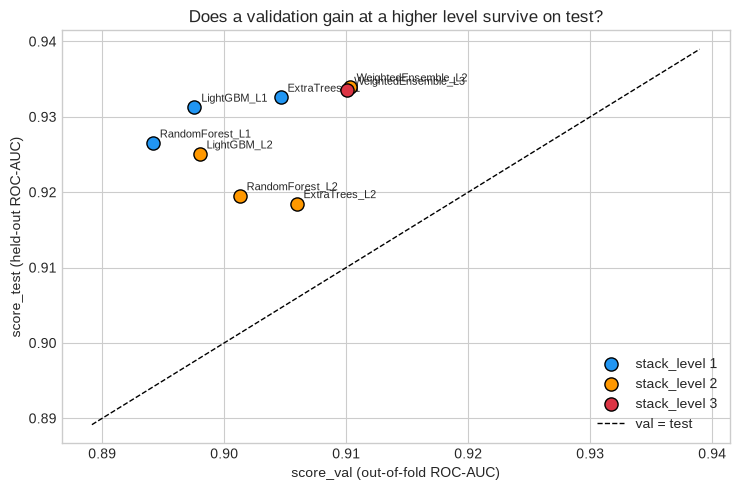

best unstacked by val: WeightedEnsemble_L2      val 0.9103  test 0.9340
best stacked by val  : WeightedEnsemble_L3      val 0.9101  test 0.9335
validation gain from stacking: -0.0002   test gain: -0.0005


In [44]:
# ============================================================
#  Validation vs test, by stack level
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 5))
colors = {1: "#2196F3", 2: "#ff9800", 3: "#dc3545"}
for lvl, grp in lb_stack.groupby("stack_level"):
    ax.scatter(grp.score_val, grp.score_test, s=90, color=colors.get(lvl, "gray"), label=f"stack_level {lvl}", edgecolor="k", zorder=3)
    for _, r in grp.iterrows():
        ax.annotate(r.model.replace("_BAG", ""), (r.score_val, r.score_test), textcoords="offset points", xytext=(5, 4), fontsize=8)
lo = min(lb_stack.score_val.min(), lb_stack.score_test.min()) - 0.005; hi = max(lb_stack.score_val.max(), lb_stack.score_test.max()) + 0.005
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="val = test")
ax.set_xlabel("score_val (out-of-fold ROC-AUC)"); ax.set_ylabel("score_test (held-out ROC-AUC)"); ax.set_title("Does a validation gain at a higher level survive on test?"); ax.legend()
plt.tight_layout(); plt.show()

def split_stack(lb):
    # "Unstacked" = the L1 models and WeightedEnsemble_L2, which only averages them. "Stacked" = every model that reads L1 predictions as features.
    is_we = lb.model.str.startswith("WeightedEnsemble")
    unstacked = lb[(lb.stack_level == 1) | ((lb.stack_level == 2) & is_we)]
    stacked = lb[(lb.stack_level > 2) | ((lb.stack_level == 2) & ~is_we)]
    return unstacked, stacked

unstacked, stacked = split_stack(lb_stack)
best_un = unstacked.sort_values("score_val", ascending=False).iloc[0]
best_st = stacked.sort_values("score_val", ascending=False).iloc[0]
print(f"best unstacked by val: {best_un.model:<24s} val {best_un.score_val:.4f}  test {best_un.score_test:.4f}")
print(f"best stacked by val  : {best_st.model:<24s} val {best_st.score_val:.4f}  test {best_st.score_test:.4f}")
print(f"validation gain from stacking: {best_st.score_val - best_un.score_val:+.4f}   test gain: {best_st.score_test - best_un.score_test:+.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each point is one model; the dashed line is where validation and test agree. Level-1 points (blue) and `WeightedEnsemble_L2` (orange, but only an average of the blue points) are the unstacked models. The true stackers are the other orange points (`_BAG_L2`) and the red `WeightedEnsemble_L3`; they tend to sit to the right of the unstacked points but not above them, because they earned a better validation score without earning a better test score. The printed lines say the same thing in two numbers: the validation gain from stacking and the test gain. When the first is positive and the second is smaller or negative, the stack has overfit its own validation signal.

The common misread: "stacking made the model worse, so never stack". On a thousand rows with three folds there is too little OOF signal for a second layer to learn from; on a hundred thousand rows the same stack usually helps. The point is to check, not to assume.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 Dynamic stacking (`dynamic_stacking=True`, default `"auto"` in the stacking presets)

AutoGluon 1.6 runs the check you just did by hand, before the real fit: it fits itself on a subset of the training data (a **sub-fit**), scores the stacked and unstacked models on the held-back part, and if the stack does not beat the best level-1 model it disables stacking for the full fit. The knobs sit in `ds_args`: `validation_procedure` (`"holdout"` or `"cv"`), `holdout_frac` (default 1/9), `n_folds` (default 2 for `"cv"`), `detection_time_frac` (the share of `time_limit` the sub-fit may use, default 1/4) and `memory_safe_fits` (run the sub-fit in its own process). `predictor.info()` and the fit log then report whether stacked overfitting was detected.

The price is time. The sub-fit takes its share of the budget first, and on a short budget the full fit can then fail with "Not enough time left to train models for the full fit". That is why the fits in this notebook pass `dynamic_stacking=False` and check by hand.

</div>


In [45]:
# ============================================================
#  The dynamic-stacking decision, by hand
# ============================================================
def stacking_helps(lb, tol=0.0):
    # AutoGluon's rule in one line: keep stacking only if the best stacked model beats the best unstacked model on held-out data.
    unstacked, stacked = split_stack(lb)
    un, st = unstacked.score_test.max(), stacked.score_test.max()
    return st > un + tol, un, st

keep, un, st = stacking_helps(lb_stack)
print(f"best held-out unstacked {un:.4f} vs best stacked {st:.4f} -> {'keep stacking' if keep else 'disable stacking (stacked overfitting detected)'}")
print("Equivalent fit call:  fit(..., dynamic_stacking=True, ds_args={'validation_procedure': 'holdout', 'holdout_frac': 1/9, 'detection_time_frac': 1/4})")


best held-out unstacked 0.9340 vs best stacked 0.9335 -> disable stacking (stacked overfitting detected)
Equivalent fit call:  fit(..., dynamic_stacking=True, ds_args={'validation_procedure': 'holdout', 'holdout_frac': 1/9, 'detection_time_frac': 1/4})


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: bag first, stack when the data can pay for it

`num_bag_folds` between 5 and 10 is almost always worth its cost in training time: bagging lowers variance and gives you honest OOF scores for free. `num_stack_levels=1` needs enough rows for the L2 model to learn from OOF columns without memorising them; let `auto_stack` and dynamic stacking decide on budgets above a few minutes, and keep `num_bag_sets=1` unless the data is tiny and time is plentiful. If inference latency matters, follow the stack with `refit_full` (Part 9) so the fold copies are collapsed into one model per family.

</div>

## 12.5 Task 12 Summary

### ✅ Key Takeaways
- Bagging = k copies per model on k folds, averaged. Stacking = a second layer that reads the first layer's out-of-fold predictions.
- `predict_proba_oof` is the honest prediction for a training row; `score_val` of a bagged model is exactly its OOF score.
- In-sample predictions flatter every model and would teach a stacker to trust the wrong ones; OOF predictions remove that leak.
- A stack can still overfit its validation signal. Compare the best unstacked model to the best stacked one on held-out data; dynamic stacking automates that check at the price of a sub-fit.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `LIGHT_ZOO`, `BAG_ARGS` | A three-family portfolio and the sequential fold-fitting setting reused below |
| `pred_stack`, `lb_stack` | The bagged and stacked predictor and its leaderboard with `stack_level` |
| `oof_table` | OOF vs in-sample ROC-AUC per L1 model |
| `split_stack(lb)`, `stacking_helps(lb)` | The unstacked/stacked split and the dynamic-stacking rule applied by hand to a leaderboard |

### ➡️ Next Up
Task 13 opens the `hyperparameters` dict: which model families train, with which settings, and when a search inside one family is worth the time.


# Task 13 · Hyperparameters: the Zoo and the Search

## 13.1 The `hyperparameters` dict is the model zoo

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

`hyperparameters` maps a **model key** to the settings of that family. The keys in the default zoo are `GBM` (LightGBM), `CAT` (CatBoost), `XGB` (XGBoost), `RF` (random forest), `XT` (extra trees), `NN_TORCH` and `FASTAI` (two neural nets); `KNN` and `LR` exist but are off by default. The value is either one dict (train one model with these overrides), a list of dicts (train one model per dict), or a dict of **search spaces** when you turn hyperparameter tuning on.

Two nested keys matter: `ag_args` holds AutoGluon's own metadata for a model (`name_suffix`, `priority`), and `ag_args_fit` holds resource settings (`num_cpus`, `num_gpus`, `max_memory_usage_ratio`). `ag_args_fit` can also be passed once to `fit()` to apply to every model.

</div>


In [46]:
# ============================================================
#  Two LightGBMs, a forest, extra trees, and a banned KNN
# ============================================================
import os
from autogluon.tabular.configs.hyperparameter_configs import hyperparameter_config_dict
print("model keys in the default zoo:", list(hyperparameter_config_dict["default"].keys()))
print("named portfolios:", [k for k in hyperparameter_config_dict if not k.startswith("zeroshot_") and not k.endswith("_2024")])

# Dynamically detect available CPUs to avoid specifying more than the environment has
SAFE_N_CPUS = min(N_CPUS, os.cpu_count() or 1)

CUSTOM_ZOO = {
    "GBM": [{"num_leaves": 31},
            {"num_leaves": 127, "ag_args": {"name_suffix": "_wide"}}],
    "RF": {}, "XT": {},
    "KNN": {},
}
with timer("custom zoo fit"):
    pred_zoo, _ = fit_tabular("custom zoo / 30 s", 30, presets=None, hyperparameters=CUSTOM_ZOO,
                              excluded_model_types=["KNN"],
                              ag_args_fit={"num_cpus": SAFE_N_CPUS})

lb_zoo = pred_zoo.leaderboard(TEST_TAB, silent=True)
print(lb_zoo[["model", "score_test", "score_val", "fit_time", "pred_time_test"]].to_string(index=False))
mi = pred_zoo.info()["model_info"]
print("\nLightGBM_wide hyperparameters (user-set + defaults):", mi["LightGBM_wide"]["hyperparameters"])
print("KNN present?", any("KNN" in m for m in lb_zoo.model))

model keys in the default zoo: ['NN_TORCH', 'GBM', 'CAT', 'XGB', 'FASTAI', 'RF', 'XT']
named portfolios: ['default', 'light', 'very_light', 'toy', 'multimodal', 'interpretable', 'zeroshot', 'commercial_2026_08_05', 'noncommercial_2026_08_05', 'experimental']


custom zoo / 30 s            limit  30s | fit    4.5s |  5 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9317 | infer   307 ms
⏱️ custom zoo fit: 5.12 s


              model  score_test  score_val  fit_time  pred_time_test
       RandomForest    0.935592   0.833310  1.088269        0.145667
WeightedEnsemble_L2    0.931675   0.848156  2.111021        0.308470
         ExtraTrees    0.928088   0.845764  0.978712        0.159442
      LightGBM_wide    0.924298   0.819026  0.766632        0.004490
           LightGBM    0.924094   0.820011  0.652174        0.004379



LightGBM_wide hyperparameters (user-set + defaults): {'learning_rate': 0.05, 'num_leaves': 127, 'seed': 0}
KNN present? False


`predictor.info()["model_info"]` is the full record: for every model, its hyperparameters, fit time, validation score, memory size and the L1 models it depends on. It is the place to look when a leaderboard name is not enough.

## 13.2 Searching inside one family

Hyperparameter optimisation (**HPO**) tries several settings of one family and keeps the best by validation score. In AutoGluon you declare a **search space** per hyperparameter with `autogluon.common.space` (`Int`, `Real`, `Categorical`) and turn the search on with `hyperparameter_tune_kwargs`. The `"auto"` preset uses Bayesian optimisation for the neural nets and random search for everything else; the dict form below sets the searcher, the scheduler and the number of trials explicitly.


In [47]:
# ============================================================
#  Random search over LightGBM: 5 trials in 40 s
# ============================================================
from autogluon.common import space

GBM_SPACE = {"GBM": {"num_leaves": space.Int(8, 128),
                     "learning_rate": space.Real(0.01, 0.3, log=True),
                     "feature_fraction": space.Real(0.5, 1.0)}}
HPO_ARGS = {"num_trials": 5, "scheduler": "local", "searcher": "random"}   # the dict form of hyperparameter_tune_kwargs="auto"

with timer("HPO fit"):
    pred_hpo, _ = fit_tabular("LightGBM random search / 40 s", 40, presets=None, hyperparameters=GBM_SPACE,
                              hyperparameter_tune_kwargs=HPO_ARGS)

lb_hpo = pred_hpo.leaderboard(TEST_TAB, silent=True)
trial_re = re.compile(r"[\\/]T(\d+)$")                       # trial names are LightGBM/T1 on Linux, LightGBM\T1 on Windows
mi_hpo = pred_hpo.info()["model_info"]
trials = []
for _, r in lb_hpo.iterrows():
    m = trial_re.search(r.model)
    if m:
        hp = mi_hpo[r.model]["hyperparameters"]
        trials.append({"trial": int(m.group(1)), "num_leaves": hp["num_leaves"], "learning_rate": hp["learning_rate"],
                       "feature_fraction": hp["feature_fraction"], "fit_time": r.fit_time, "score_val": r.score_val, "score_test": r.score_test})
trials = pd.DataFrame(trials).sort_values("trial").set_index("trial")
print(trials.round(4).to_string())
print(f"\ntrials finished: {len(trials)} of {HPO_ARGS['num_trials']} | best by val: T{trials.score_val.idxmax()} | best by test: T{trials.score_test.idxmax()} | val-set rows: {pred_hpo.info()['num_rows_val']}")


  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:00<00:02,  1.95it/s]

 40%|████      | 2/5 [00:01<00:01,  1.78it/s]

 60%|██████    | 3/5 [00:01<00:01,  1.84it/s]

 80%|████████  | 4/5 [00:02<00:00,  1.25it/s]

100%|██████████| 5/5 [00:04<00:00,  1.11s/it]

100%|██████████| 5/5 [00:04<00:00,  1.11it/s]

LightGBM random search / 40 s limit  40s | fit    5.4s |  6 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9378 | infer    17 ms
⏱️ HPO fit: 5.52 s


       num_leaves  learning_rate  feature_fraction  fit_time  score_val  score_test
trial                                                                              
1               8         0.0100            0.5000    0.4877     0.8380      0.9406
2              75         0.1139            0.7744    0.5773     0.8467      0.9082
3              44         0.0834            0.9236    0.5052     0.8415      0.9405
4              66         0.0121            0.6488    1.1426     0.8424      0.9399
5              96         0.1584            0.7388    1.6449     0.8491      0.9378



trials finished: 5 of 5 | best by val: T5 | best by test: T1 | val-set rows: 225


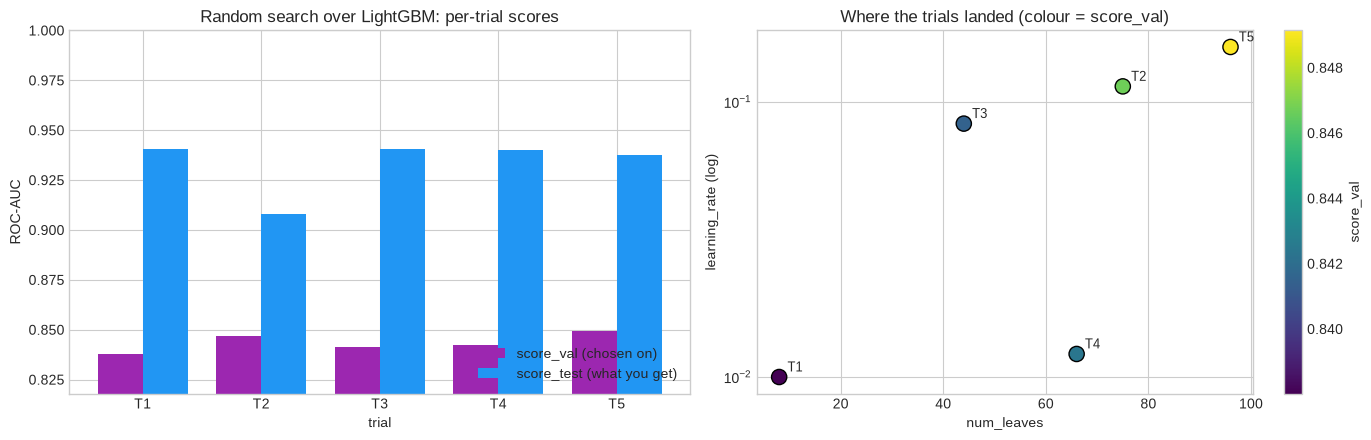

rank agreement between val and test across trials (Spearman): -0.90 | val spread 0.0111 | test spread 0.0324


In [48]:
# ============================================================
#  Trial scores: validation rank vs test rank
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
x = np.arange(len(trials)); w = 0.38
ax.bar(x - w / 2, trials.score_val, w, color="#9c27b0", label="score_val (chosen on)")
ax.bar(x + w / 2, trials.score_test, w, color="#2196F3", label="score_test (what you get)")
ax.set_xticks(x); ax.set_xticklabels([f"T{t}" for t in trials.index]); ax.set_ylim(min(trials.score_val.min(), trials.score_test.min()) - 0.02, 1.0)
ax.set_xlabel("trial"); ax.set_ylabel("ROC-AUC"); ax.set_title("Random search over LightGBM: per-trial scores"); ax.legend(loc="lower right")
ax = axes[1]
sc = ax.scatter(trials.num_leaves, trials.learning_rate, c=trials.score_val, s=120, cmap="viridis", edgecolor="k")
for t, r in trials.iterrows():
    ax.annotate(f"T{t}", (r.num_leaves, r.learning_rate), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_yscale("log"); ax.set_xlabel("num_leaves"); ax.set_ylabel("learning_rate (log)"); ax.set_title("Where the trials landed (colour = score_val)")
plt.colorbar(sc, ax=ax, label="score_val")
plt.tight_layout(); plt.show()
rank_agree = trials.score_val.rank().corr(trials.score_test.rank(), method="spearman")
print(f"rank agreement between val and test across trials (Spearman): {rank_agree:.2f} | val spread {trials.score_val.max() - trials.score_val.min():.4f} | test spread {trials.score_test.max() - trials.score_test.min():.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: for each trial, the validation score the search optimised (purple) next to the test score nobody saw during the search (blue). The search picks the tallest purple bar; the printed line says whether that is also the tallest blue bar. Right: the sampled `(num_leaves, learning_rate)` pairs, coloured by validation score, show how sparsely five random trials cover a two-dimensional space (the third dimension, `feature_fraction`, is not drawn).

The common misread: reading a higher validation bar as a better model. With a validation set of a few hundred rows, the differences between trials are within the noise of the split, and the rank correlation printed under the plot says how much of the ordering survives on test.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ HPO on a small validation set selects noise

Every trial is judged on `num_rows_val` rows (printed above). When the spread between trials on validation is of the same size as the spread on test, the "winner" is a coin flip, and the ensemble on top of the trials has learned weights from that same noisy signal. Bagged HPO (`num_bag_folds` together with `hyperparameter_tune_kwargs`) judges trials on OOF scores over all training rows and is the safer form when you must search.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: give AutoGluon more time before giving it hyperparameters

The default and `zeroshot` portfolios already contain configurations chosen by searching on hundreds of datasets; a longer `time_limit` trains more of them and the weighted ensemble combines them. Reach for `hyperparameters` to *remove* families (latency, memory, licensing) or to add a known-good configuration with `name_suffix`, and for `hyperparameter_tune_kwargs` only when a single family is the deployment target and the data is large enough to judge trials.

</div>

## 13.3 Task 13 Summary

### ✅ Key Takeaways
- `hyperparameters={key: dict | [dicts] | search spaces}` chooses the families and their settings; `excluded_model_types` bans a family even if the dict asks for it.
- `ag_args` names and orders a model, `ag_args_fit` sets its resources; `predictor.info()["model_info"]` records everything each model was fit with.
- `hyperparameter_tune_kwargs` with `autogluon.common.space` runs a search; trials appear as `Model/T1`, `Model/T2`, ... in the leaderboard.
- On small validation sets the trial ranking is noisy; more budget on the default portfolio beats a search most of the time.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `CUSTOM_ZOO`, `pred_zoo`, `lb_zoo` | The hand-picked zoo, its predictor and leaderboard |
| `GBM_SPACE`, `HPO_ARGS` | The LightGBM search space and the tuning settings |
| `pred_hpo`, `trials` | The HPO predictor and its per-trial table (settings, val, test) |
| `FIT_LOG` | Every fit of Part 5 in one list of comparable rows |

### ➡️ Next Up
Part 6 asks the reference predictor what it learned: which features carry the signal (Task 14) and why one household is scored the way it is (Task 15).


# Part 6 · Feature Importance, Explanations, What the Ensemble Learned ⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A leaderboard says how well the ensemble predicts. It does not say *what it uses* or *why one household is flagged*. This Part asks both questions of `pred_ref`, the reference predictor from Task 11: **global** answers from permutation importance (Task 14) and **local** answers from Shapley values and partial dependence (Task 15). Both methods treat the ensemble as a black box that turns rows into probabilities, so they work for any AutoGluon predictor, stacked or not.

</div>


# Task 14 · Permutation Importance

## 14.1 Break one column, measure the damage

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Take a held-out table, shuffle one column so its values no longer belong to their rows, and score the model again. If the score barely moves, the model was not using that column. If it collapses, the column carried signal. Repeat the shuffle a few times to see how much of the drop is noise. That is **permutation importance**, and `predictor.feature_importance` computes it for every column, with a confidence interval and a p-value, without retraining anything.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With score $s(D)$ on the held-out data $D$ and $D^{(j,r)}$ the same data with column $j$ shuffled for the $r$-th time,

$$ I_j = s(D) - \frac{1}{R} \sum_{r=1}^{R} s\!\left(D^{(j,r)}\right). $$

The $R$ shuffles give $R$ estimates of the drop, so a one-sided t-test of "the drop is zero" yields `p_value`, and a t-interval yields `p99_low` and `p99_high`. A feature is confidently useful when `p99_low` is above zero. `num_shuffle_sets` is $R$; the default is 1 for `feature_importance` without a `time_limit`, which gives no interval at all.

</div>


In [49]:
# ============================================================
#  Permutation importance with 5 shuffle sets, on the test set
# ============================================================
with timer("feature_importance"):
    fi = pred_ref.feature_importance(TEST_TAB, num_shuffle_sets=5, silent=True)

print(fi.round(4).to_string())
print(f"\ncolumns: {list(fi.columns)}")
print(f"confidently useful (p_value < 0.01): {int((fi.p_value < 0.01).sum())} of {len(fi)} features | importance sums to {fi.importance.sum():.4f} ROC-AUC")


⏱️ feature_importance: 1.83 s
                     importance  stddev  p_value  n  p99_high  p99_low
overspend_rate_prev      0.1818  0.0284   0.0001  5    0.2403   0.1233
income                   0.0068  0.0072   0.0519  5    0.0217  -0.0081
total_spend              0.0015  0.0008   0.0068  5    0.0032  -0.0001
rent                     0.0010  0.0028   0.2323  5    0.0067  -0.0047
overspent                0.0010  0.0019   0.1491  5    0.0048  -0.0028
groceries                0.0006  0.0007   0.0557  5    0.0020  -0.0008
avg_spend_prev           0.0005  0.0018   0.2695  5    0.0042  -0.0031
referral_code            0.0004  0.0013   0.2613  5    0.0032  -0.0023
owns_car                 0.0004  0.0003   0.0267  5    0.0010  -0.0003
city_tier                0.0003  0.0029   0.4242  5    0.0062  -0.0057
other                    0.0001  0.0011   0.4202  5    0.0023  -0.0021
survey_score             0.0001  0.0008   0.4327  5    0.0016  -0.0015
household_size           0.0000  0.0007   0.487

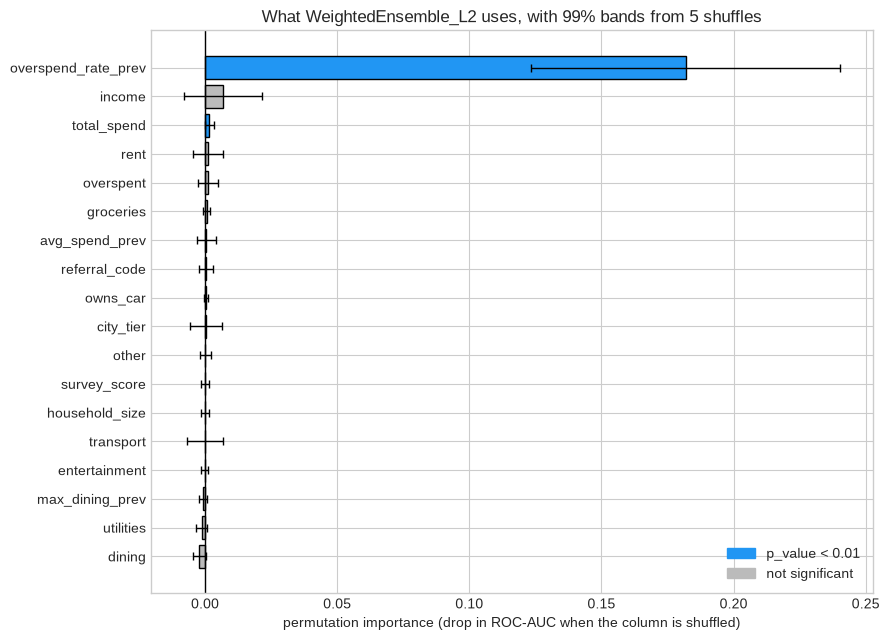

top 3: overspend_rate_prev (0.1818), income (0.0068), total_spend (0.0015)
noise columns by design (survey_score, referral_code): survey_score p=0.43, referral_code p=0.26


In [50]:
# ============================================================
#  Importance bar chart with 99% bands
# ============================================================
fi_plot = fi.sort_values("importance")
colors = np.where(fi_plot.p_value < 0.01, "#2196F3", "#bbbbbb")
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(fi_plot.index, fi_plot.importance, color=colors, edgecolor="k",
        xerr=[fi_plot.importance - fi_plot.p99_low, fi_plot.p99_high - fi_plot.importance], capsize=3, error_kw={"lw": 1})
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("permutation importance (drop in ROC-AUC when the column is shuffled)"); ax.set_title(f"What {pred_ref.model_best} uses, with 99% bands from 5 shuffles")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2196F3", label="p_value < 0.01"), Patch(color="#bbbbbb", label="not significant")], loc="lower right")
plt.tight_layout(); plt.show()
top3 = fi.importance.sort_values(ascending=False).head(3)
print("top 3:", ", ".join(f"{k} ({v:.4f})" for k, v in top3.items()))
print("noise columns by design (survey_score, referral_code):", ", ".join(f"{c} p={fi.loc[c, 'p_value']:.2f}" for c in ["survey_score", "referral_code"] if c in fi.index))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each bar is the average ROC-AUC lost when that column is shuffled; the whiskers are the 99% interval from the five shuffles, and grey bars are columns whose interval reaches zero. The columns that describe *this month's* budget position (income, total spend, the overspend flag, the history aggregates) should dominate, because next month's overspend is mostly this month's overspend plus noise. The two columns the generator filled with noise, `survey_score` and `referral_code`, should be grey, and the printed p-values say whether they are.

The common misread: a grey bar means "the column is useless". It means the model as trained does not rely on it, which can also happen when another column carries the same information (the next cell shows that with groups).

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Importance on the training set flatters memorised columns

`feature_importance(train_df)` would report a drop for any column the trees memorised, whether or not it generalises. Compute importance on held-out data (the test set here, or a validation split you did not tune on). And a shuffled column produces rows that never occur in reality (a metro household with a town rent), so importance measures what the model *does*, not what the world does.

</div>

## 14.2 The text column and grouped importance

`pred_ref` never saw `note`. The quick fit below includes it, to ask how much a short templated note adds once AutoGluon has turned it into n-gram and special-character features (its `feature_metadata` names the type it inferred). The same call then scores **groups** of columns together, using the `(name, [columns])` tuple form of `features`: a group's importance is the drop from shuffling all its columns at once, which is not the sum of the individual drops when the columns overlap in information.


In [51]:
# ============================================================
#  note's importance, and importance of column groups
# ============================================================
with timer("fit with note"):
    pred_note, _ = fit_tabular("light zoo + note / 30 s", 30, presets=None, hyperparameters=LIGHT_ZOO,
                               train=train_df[FEATURES + [LABEL_CLS]])
print("type inferred for note:", pred_note.feature_metadata.get_feature_type_raw("note"), "| special:", pred_note.feature_metadata.get_feature_types_special("note"))

GROUPS = [("spend_pair", ["dining", "entertainment"]),
          ("history", ["avg_spend_prev", "overspend_rate_prev", "max_dining_prev"]),
          ("this_month_position", ["total_spend", "overspent", "income"]),
          "note", "dining", "entertainment"]
with timer("grouped importance"):
    fi_groups = pred_note.feature_importance(test_df[FEATURES + [LABEL_CLS]], features=GROUPS, num_shuffle_sets=5, silent=True)

print(fi_groups[["importance", "stddev", "p_value", "p99_low", "p99_high"]].round(4).to_string())
pair = fi_groups.loc["spend_pair", "importance"]; solo = fi_groups.loc["dining", "importance"] + fi_groups.loc["entertainment", "importance"]
print(f"\nspend_pair together {pair:.4f} vs dining + entertainment separately {solo:.4f} -> {'the pair carries more than its parts (they interact)' if pair > solo else 'the parts overlap (shared information)'}")
print(f"note: importance {fi_groups.loc['note', 'importance']:.4f}, p_value {fi_groups.loc['note', 'p_value']:.2f}")


light zoo + note / 30 s      limit  30s | fit    3.9s |  4 models | best WeightedEnsemble_L2    | ROC-AUC test 0.9345 | infer   327 ms
⏱️ fit with note: 4.60 s
type inferred for note: category | special: []


⏱️ grouped importance: 2.61 s
                     importance  stddev  p_value  p99_low  p99_high
history                  0.1417  0.0218   0.0001   0.0968    0.1866
this_month_position      0.0500  0.0119   0.0004   0.0256    0.0745
note                     0.0015  0.0021   0.0980  -0.0029    0.0059
entertainment           -0.0016  0.0006   0.9974  -0.0029   -0.0003
dining                  -0.0022  0.0023   0.9508  -0.0069    0.0025
spend_pair              -0.0035  0.0025   0.9819  -0.0087    0.0017

spend_pair together -0.0035 vs dining + entertainment separately -0.0038 -> the pair carries more than its parts (they interact)
note: importance 0.0015, p_value 0.10


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: read importance with its interval, and act on groups

Use `num_shuffle_sets` of at least 5 and look at `p99_low`, not the point estimate: a column with a wide band and a low estimate is undecided, not useless. Before dropping columns, group the ones that share a source (all history aggregates, all spend categories) and score the group; if a group is confidently useful but each member is grey, the members are substitutes for each other and only the group should be kept or dropped as one. After any removal, refit and compare test scores; importance predicts the effect of removal only approximately.

</div>

## 14.3 Task 14 Summary

### ✅ Key Takeaways
- Permutation importance = score drop when one column is shuffled on held-out data; `feature_importance` returns it with a t-interval and p-value over `num_shuffle_sets` shuffles.
- Compute it on data the model did not train on; training-set importance rewards memorisation.
- A grey (not significant) column may still matter when it shares information with another; group importance via `(name, [columns])` tuples answers that.
- The templated `note` column is typed as text and adds little next to the numeric budget position; Part 8 revisits it with a language model.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `fi` | Permutation importance of every tabular column for `pred_ref`, with `p_value`, `p99_low`, `p99_high` |
| `pred_note` | A light predictor that includes the `note` text column |
| `GROUPS`, `fi_groups` | Column groups and their joint importance |

### ➡️ Next Up
Task 15 goes local: why is *this* household scored the way it is, and how does the probability move as income or dining changes?


# Task 15 · Per-Prediction Explanations

## 15.1 From "what matters" to "why this row"

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Permutation importance is a statement about the model on average. A household that gets a probability of overspending of 0.8 deserves a statement about *itself*: which of its values pushed the score up from the typical household, and by how much. **Shapley values** answer that with a fair-division rule: every feature's contribution is its average marginal effect over all orders in which the features could be revealed. They add up exactly to the difference between this row's prediction and the average prediction, so nothing is lost or double-counted.

Computing that exactly needs $2^{18}$ feature subsets for 18 features. **KernelSHAP** estimates it by sampling subsets and filling the "hidden" features from a background set of typical rows, so it works on any function, including a stacked AutoGluon ensemble, at the cost of many predictions per explained row.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

For a row $x$, feature $j$ and $f_S(x)$ the model's expected output when only the features in $S$ are known,

$$ \phi_j(x) = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!\,(|F|-|S|-1)!}{|F|!} \left[ f_{S \cup \{j\}}(x) - f_S(x) \right], \qquad \sum_j \phi_j(x) = f(x) - \mathbb{E}[f]. $$

The weight in front is the fraction of orderings in which $S$ comes before $j$. The second equation is the **efficiency** property, and the code checks it: base value plus the sum of the $\phi_j$ must equal the ensemble's probability for that row.

</div>

The ensemble takes a DataFrame with strings and booleans; KernelSHAP works on a numeric matrix. Two small functions translate: `encode` maps the categorical columns to integer codes, `decode` maps them back before every call to `predict_proba`.


In [52]:
# ============================================================
#  Numeric view of the features for a model-agnostic explainer
# ============================================================
# !pip install -q shap   # already installed with AutoGluon's extras in most environments
CAT_COLS = [c for c in TAB_FEATURES if train_df[c].dtype == object or train_df[c].dtype == bool]
CATS = {c: list(pd.Series(train_df[c].dropna().unique()).sort_values()) for c in CAT_COLS}
INT_COLS = [c for c in TAB_FEATURES if c not in CAT_COLS and np.issubdtype(train_df[c].dtype, np.integer)]


def encode(df):
    # DataFrame -> float matrix: categorical columns become codes (-1 = missing), everything else is cast to float
    X = df[TAB_FEATURES].copy()
    for c, cats in CATS.items():
        X[c] = pd.Categorical(X[c], categories=cats).codes
    return X.astype(float)


def decode(X):
    # float matrix -> DataFrame with the dtypes the predictor was trained on
    df = pd.DataFrame(np.asarray(X, dtype=float), columns=TAB_FEATURES)
    for c, cats in CATS.items():
        codes = df[c].round().astype(int).clip(-1, len(cats) - 1)
        df[c] = pd.Series([cats[i] if i >= 0 else None for i in codes], dtype=object)
        if train_df[c].dtype == bool:
            df[c] = df[c].astype(bool)
    for c in INT_COLS:
        df[c] = df[c].round().astype(train_df[c].dtype)
    return df


def f_prob(X):
    # the black box: numeric matrix in, P(overspent_next = 1) out
    return pred_ref.predict_proba(decode(X)).iloc[:, 1].values


X_test_num = encode(test_df)
roundtrip = np.abs(f_prob(X_test_num.values[:50]) - pred_ref.predict_proba(test_df[TAB_FEATURES].head(50)).iloc[:, 1].values).max()
print(f"categorical columns: {CAT_COLS} -> codes; integer columns: {INT_COLS}")
print(f"encode/decode round-trip: max |difference| in probability on 50 rows = {roundtrip:.2e}")


categorical columns: ['city_tier', 'owns_car', 'referral_code'] -> codes; integer columns: ['household_size', 'overspent', 'survey_score']
encode/decode round-trip: max |difference| in probability on 50 rows = 0.00e+00


In [53]:
# ============================================================
#  KernelSHAP on 20 test rows, 15 background prototypes
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)
bg_idx = rng.choice(len(train_df), 100, replace=False)
explain_idx = np.r_[test_df.index[test_df[LABEL_CLS] == 1][:10], test_df.index[test_df[LABEL_CLS] == 0][:10]]   # 10 overspenders, 10 not
X_explain = X_test_num.loc[explain_idx]
SHAP_OK = False
try:
    import shap
    background = shap.kmeans(encode(train_df.iloc[bg_idx]), 15)      # 15 prototypes, each snapped to real values
    explainer = shap.KernelExplainer(f_prob, background)
    with timer("KernelSHAP, 20 rows"):
        shap_vals = np.asarray(explainer.shap_values(X_explain.values, nsamples=256, silent=True))
    base_value = float(np.ravel(explainer.expected_value)[0])
    SHAP_OK = True
    print(f"shap {shap.__version__}: values shape {shap_vals.shape}, base value (mean prediction over the background) {base_value:.3f}")
except Exception as e:                                                # no shap, or a version mismatch: a LIME-style local attribution instead
    print(f"shap unavailable ({type(e).__name__}: {e}); using a local perturbation fallback")
    bg = encode(train_df.iloc[bg_idx]).values
    base_value = float(f_prob(bg).mean())
    def local_attribution(x, n=15):
        # for each feature: prediction with the row's own value minus the mean prediction with that value replaced by background values
        out = np.zeros(len(TAB_FEATURES))
        for j in range(len(TAB_FEATURES)):
            Xp = np.repeat(x[None, :], n, axis=0); Xp[:, j] = bg[:n, j]
            out[j] = f_prob(x[None, :])[0] - f_prob(Xp).mean()
        return out
    shap_vals = np.vstack([local_attribution(x) for x in X_explain.values])

pred_rows = f_prob(X_explain.values)
gap = np.abs(base_value + shap_vals.sum(axis=1) - pred_rows)
print(f"efficiency check: max |base + sum(phi) - f(x)| over the 20 rows = {gap.max():.4f}  ({'exact within sampling error' if SHAP_OK else 'not guaranteed for the fallback'})")


shap unavailable (ModuleNotFoundError: No module named 'shap'); using a local perturbation fallback


efficiency check: max |base + sum(phi) - f(x)| over the 20 rows = 0.2481  (not guaranteed for the fallback)


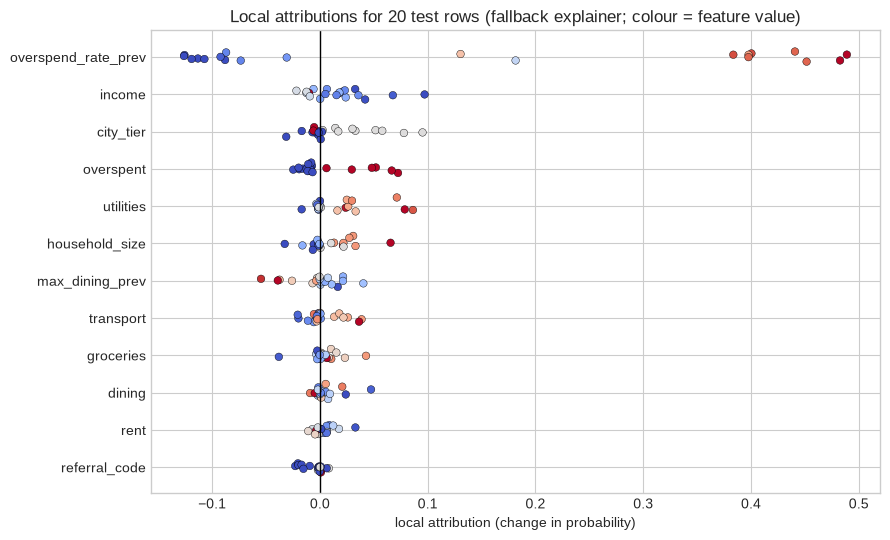

mean |attribution| top 5: overspend_rate_prev 0.236, income 0.024, city_tier 0.023, overspent 0.022, utilities 0.021
household 1308: largest push is overspend_rate_prev = 1.0 (+0.483)


In [54]:
# ============================================================
#  Beeswarm (all 20 rows) and a waterfall (one overspender)
# ============================================================
if SHAP_OK:
    expl = shap.Explanation(values=shap_vals, base_values=np.full(len(X_explain), base_value), data=X_explain.values, feature_names=TAB_FEATURES)
    shap.plots.beeswarm(expl, max_display=12, show=False)
    plt.title("Which values push the overspend probability up (right) or down (left)"); plt.xlabel("SHAP value (change in probability)")
    plt.tight_layout(); plt.show()
    i_star = int(np.argmax(pred_rows))                                   # the most confident overspend prediction
    shap.plots.waterfall(expl[i_star], max_display=10, show=False)
    plt.title(f"Household {test_df.loc[explain_idx[i_star], ID_COL]}: from base {base_value:.2f} to P(overspend) = {pred_rows[i_star]:.2f}")
    plt.tight_layout(); plt.show()
else:
    order = np.argsort(np.abs(shap_vals).mean(axis=0))[-12:]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for k, j in enumerate(order):
        ax.scatter(shap_vals[:, j], np.full(len(shap_vals), k) + rng.normal(0, 0.08, len(shap_vals)), c=X_explain.values[:, j], cmap="coolwarm", s=30, edgecolor="k", lw=0.3)
    ax.set_yticks(range(len(order))); ax.set_yticklabels([TAB_FEATURES[j] for j in order]); ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("local attribution (change in probability)"); ax.set_title("Local attributions for 20 test rows (fallback explainer; colour = feature value)")
    plt.tight_layout(); plt.show()
    i_star = int(np.argmax(pred_rows))
mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=TAB_FEATURES).sort_values(ascending=False)
print("mean |attribution| top 5:", ", ".join(f"{k} {v:.3f}" for k, v in mean_abs.head(5).items()))
top_j = int(np.argmax(np.abs(shap_vals[i_star])))
print(f"household {test_df.loc[explain_idx[i_star], ID_COL]}: largest push is {TAB_FEATURES[top_j]} = {test_df.loc[explain_idx[i_star], TAB_FEATURES[top_j]]} ({shap_vals[i_star, top_j]:+.3f})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Beeswarm: one dot per household per feature, placed at its Shapley value (how much that feature moved this household's probability from the base value) and coloured by the feature's value (red high, blue low). A feature whose red dots sit right and blue dots sit left raises the risk as it grows; a feature with the colours mixed on both sides acts through an interaction. Features are ordered by mean absolute value, which is the local counterpart of Task 14's global ranking and usually agrees with it at the top. Waterfall: one household, read bottom to top, from the base probability through each feature's push to the final score; the largest push is printed under the plot together with the value that caused it.

The common misread: reading a Shapley value as "what would happen if this feature changed". It is a fair share of the *difference from the average household*, computed by hiding features, not a causal effect of moving one.

</div>

## 15.2 Partial dependence by hand

A **partial dependence** curve answers a different question: as one feature sweeps a grid of values while every other column keeps its real values, what is the *average* prediction? It takes one batched `predict_proba` call per feature.


⏱️ two PD curves: 0.49 s


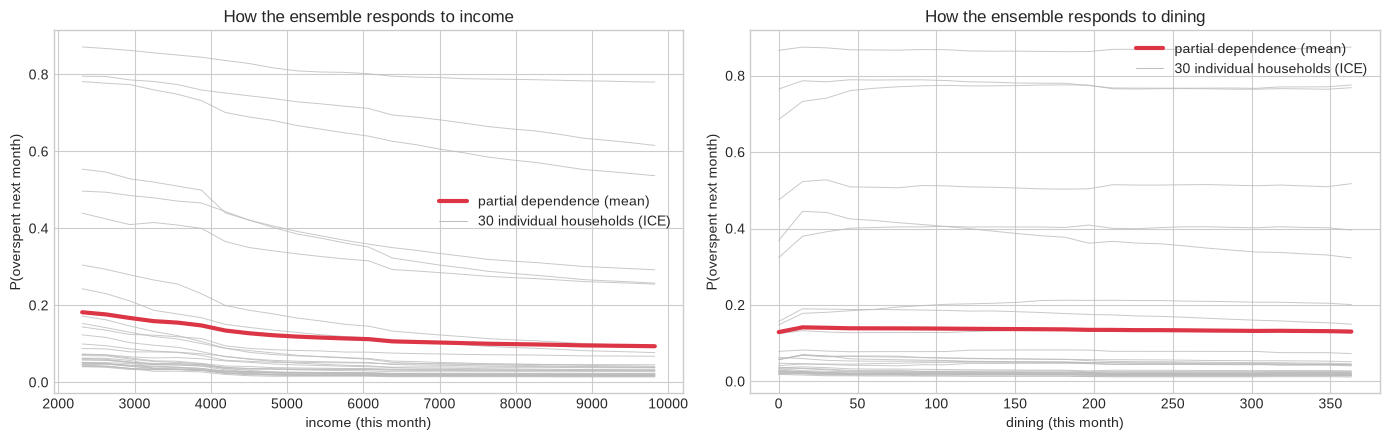

income: P(overspend) 0.182 at 2,313 -> 0.094 at 9,824  (mean slope negative)
dining: P(overspend) 0.129 at 0 -> 0.130 at 363


In [55]:
# ============================================================
#  Partial dependence for income and dining, in one predict call each
# ============================================================
pd_rows = test_df[TAB_FEATURES].sample(150, random_state=RANDOM_STATE)


def partial_dependence(col, grid, rows=pd_rows):
    # Average prediction over `rows` with `col` forced to each grid value. One predict call on len(grid) x len(rows) rows.
    stacked_rows = pd.concat([rows.assign(**{col: v}) for v in grid], ignore_index=True)
    probs = pred_ref.predict_proba(stacked_rows).iloc[:, 1].values.reshape(len(grid), len(rows))
    return probs.mean(axis=1), probs


income_grid = np.linspace(train_df.income.quantile(0.02), train_df.income.quantile(0.98), 25)
dining_grid = np.linspace(0, train_df.dining.quantile(0.98), 25)
with timer("two PD curves"):
    pd_income, ice_income = partial_dependence("income", income_grid)
    pd_dining, ice_dining = partial_dependence("dining", dining_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, grid, pdp, ice, name in [(axes[0], income_grid, pd_income, ice_income, "income"), (axes[1], dining_grid, pd_dining, ice_dining, "dining")]:
    ax.plot(grid, ice[:, :30], color="#bbbbbb", lw=0.7, alpha=0.8)
    ax.plot(grid, pdp, color="#dc3545", lw=3, label="partial dependence (mean)")
    ax.plot([], [], color="#bbbbbb", lw=0.7, label="30 individual households (ICE)")
    ax.set_xlabel(f"{name} (this month)"); ax.set_ylabel("P(overspent next month)"); ax.set_title(f"How the ensemble responds to {name}"); ax.legend()
plt.tight_layout(); plt.show()
print(f"income: P(overspend) {pd_income[0]:.3f} at {income_grid[0]:,.0f} -> {pd_income[-1]:.3f} at {income_grid[-1]:,.0f}  (mean slope {'negative' if pd_income[-1] < pd_income[0] else 'positive'})")
print(f"dining: P(overspend) {pd_dining[0]:.3f} at {dining_grid[0]:,.0f} -> {pd_dining[-1]:.3f} at {dining_grid[-1]:,.0f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Red: the average predicted probability as the feature sweeps its grid with all other columns held at their real values. Grey: the same sweep for thirty individual households (**ICE** curves, individual conditional expectation). For `income`, higher income at the same spending means a smaller share spent, so the red curve should fall. For `dining`, the curve should rise, gently, because dining is one of seven categories and the overspend threshold is a share of income. Where the grey curves fan out or cross, the effect depends on the other columns.

The common misread: a flat red curve as "no effect". Grey curves rising for some households and falling for others average to flat; that is an interaction, not an absence.

</div>

## 15.3 Was the planted interaction found?

The generator made `entertainment` depend on `dining`, so the two should act together. A two-dimensional partial dependence over a grid of both, minus what the two one-dimensional curves would predict additively, leaves the **interaction residual**. If it is near zero everywhere, the model treats the two as independent.


⏱️ 2-D partial dependence: 0.26 s


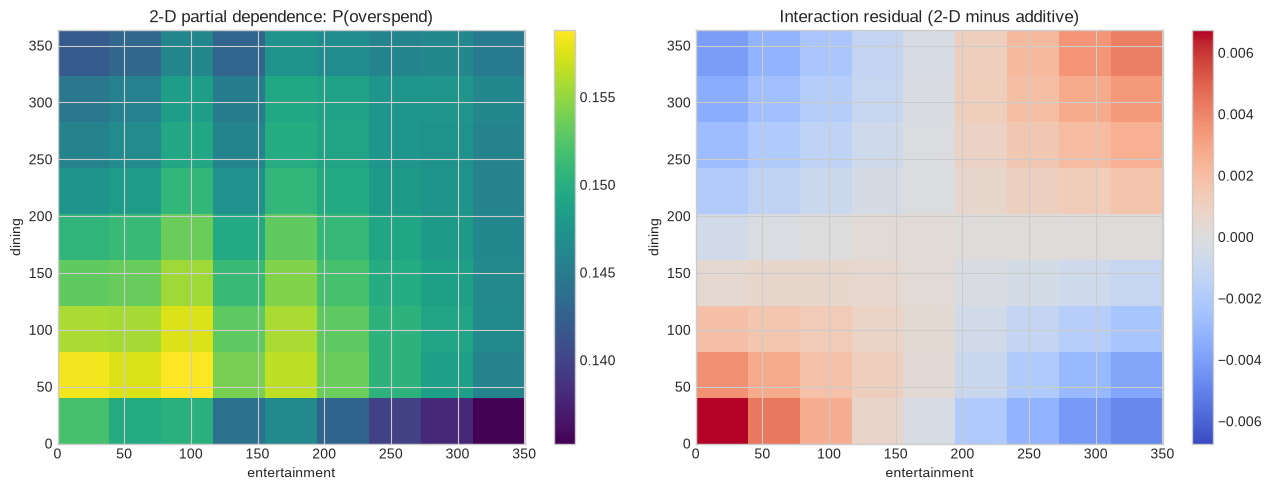

max |interaction residual| = 0.0067 vs full range of the 2-D surface 0.0235 -> interaction is 29% of the effect size


In [56]:
# ============================================================
#  2-D partial dependence and its non-additive residual
# ============================================================
g1 = np.linspace(0, train_df.dining.quantile(0.98), 9); g2 = np.linspace(0, train_df.entertainment.quantile(0.98), 9)
rows_2d = pd_rows.head(80)
grid_rows = pd.concat([rows_2d.assign(dining=a, entertainment=b) for a in g1 for b in g2], ignore_index=True)
with timer("2-D partial dependence"):
    pd2 = pred_ref.predict_proba(grid_rows).iloc[:, 1].values.reshape(len(g1), len(g2), len(rows_2d)).mean(axis=2)
pd_d = pd2.mean(axis=1); pd_e = pd2.mean(axis=0)                  # the 1-D curves implied by the same grid
additive = pd_d[:, None] + pd_e[None, :] - pd2.mean()             # what a model without interaction would give
residual = pd2 - additive

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(pd2, origin="lower", cmap="viridis", aspect="auto", extent=[g2[0], g2[-1], g1[0], g1[-1]])
axes[0].set_xlabel("entertainment"); axes[0].set_ylabel("dining"); axes[0].set_title("2-D partial dependence: P(overspend)"); plt.colorbar(im0, ax=axes[0])
lim = max(1e-6, np.abs(residual).max())
im1 = axes[1].imshow(residual, origin="lower", cmap="coolwarm", vmin=-lim, vmax=lim, aspect="auto", extent=[g2[0], g2[-1], g1[0], g1[-1]])
axes[1].set_xlabel("entertainment"); axes[1].set_ylabel("dining"); axes[1].set_title("Interaction residual (2-D minus additive)"); plt.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()
interaction_strength = float(np.abs(residual).max()); main_range = float(pd2.max() - pd2.min())
print(f"max |interaction residual| = {interaction_strength:.4f} vs full range of the 2-D surface {main_range:.4f} -> interaction is {interaction_strength / max(main_range, 1e-9):.0%} of the effect size")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the average probability over a grid of this month's `dining` and `entertainment`, brighter meaning more likely to overspend. Right: what remains after subtracting the additive combination of the two one-dimensional curves, on a red-blue scale centred at zero. A patterned right panel (for example, red in the high-high corner) means the model learned that the two together mean more than each alone; a flat, near-white panel means it did not. The printed ratio compares the largest residual to the full range of the surface.

The common misread: expecting a large residual because the generator linked the two columns. The link was in how `entertainment` was *generated* from `dining` (a correlation), which a model can exploit without any interaction term; the residual only measures non-additivity in the model's response.

</div>

## 15.4 What the ensemble learned, in one table


In [57]:
# ============================================================
#  Global rank + local direction + the interaction check, in one table
# ============================================================
top_feats = fi.importance.sort_values(ascending=False).head(8).index.tolist()
rows = []
for c in top_feats:
    j = TAB_FEATURES.index(c)
    xv, sv = X_explain.values[:, j], shap_vals[:, j]
    rho = pd.Series(xv).corr(pd.Series(sv), method="spearman") if np.std(xv) > 0 else np.nan
    direction = "raises risk as it grows" if rho > 0.3 else ("lowers risk as it grows" if rho < -0.3 else "mixed / interaction")
    rows.append({"feature": c, "permutation_importance": fi.loc[c, "importance"], "p_value": fi.loc[c, "p_value"],
                 "mean_|shap|": mean_abs[c], "direction (from 20 rows)": direction})
learned = pd.DataFrame(rows).set_index("feature")
print(learned.round(4).to_string())
print(f"\ninteraction dining x entertainment: residual {interaction_strength:.4f} ({interaction_strength / max(main_range, 1e-9):.0%} of effect size) -> {'found' if interaction_strength / max(main_range, 1e-9) > 0.1 else 'weak or absent'}")
print(f"agreement between global (permutation) and local (mean |shap|) top-5: {len(set(top_feats[:5]) & set(mean_abs.head(5).index))} of 5 features")


                     permutation_importance  p_value  mean_|shap| direction (from 20 rows)
feature                                                                                   
overspend_rate_prev                  0.1818   0.0001       0.2359  raises risk as it grows
income                               0.0068   0.0519       0.0239  lowers risk as it grows
total_spend                          0.0015   0.0068       0.0038      mixed / interaction
rent                                 0.0010   0.2323       0.0070  lowers risk as it grows
overspent                            0.0010   0.1491       0.0225  raises risk as it grows
groceries                            0.0006   0.0557       0.0088  raises risk as it grows
avg_spend_prev                       0.0005   0.2695       0.0048      mixed / interaction
referral_code                        0.0004   0.2613       0.0066  raises risk as it grows

interaction dining x entertainment: residual 0.0067 (29% of effect size) -> found
agreeme

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Three ways an explanation can mislead

1. **Correlated inputs.** KernelSHAP and permutation both build rows that mix one household's income with another's rent. When two columns move together, credit is split between them in a way that depends on the background, and the direction column above can flip between substitutes.
2. **Sampling noise.** Twenty rows and a few hundred subset samples per row are enough for a picture, not for a decision. The efficiency check printed earlier tells you how close the estimate is; raise `nsamples` and the number of rows before quoting a number.
3. **Association, not cause.** Every plot in this Part describes the model's response, on rows the model may never see in reality. Changing a household's dining will not change its overspend probability by the amount the curve shows.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: match the tool to the question, and explain on held-out rows

Use permutation importance with intervals to decide what to keep, partial dependence to check that a response has the sign the domain expects (income down, spend up), and Shapley values to answer for one customer. Run all three on rows the model did not train on, keep the background set representative of production traffic, and store the explanation next to the prediction when a decision must be justified later.

</div>

## 15.5 Task 15 Summary

### ✅ Key Takeaways
- Shapley values split one row's difference from the average prediction fairly across features; KernelSHAP estimates them for any black box, and the efficiency check verifies the estimate.
- A beeswarm shows direction and spread across rows; a waterfall shows one row's path from the base value to its score.
- Partial dependence sweeps one feature with everything else real; ICE curves reveal when the average hides opposite responses.
- The 2-D residual measures the interaction a model actually uses, which is not the same as the correlation the data contains.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `encode`, `decode`, `f_prob` | The numeric view of the features and the black-box probability function |
| `shap_vals`, `base_value`, `X_explain`, `SHAP_OK` | Attributions for 20 test rows, the base value, and whether real SHAP ran |
| `partial_dependence(col, grid)` | Average and per-row response over a grid, in one predict call |
| `pd2`, `residual`, `interaction_strength` | The 2-D dependence and its non-additive part |
| `learned` | The summary table: global rank, local direction, interaction |

### ➡️ Next Up
Part 7 leaves the household table for the household *series*: `TimeSeriesPredictor` forecasts every household's monthly spend three months ahead, with prediction intervals.


In [58]:
# housekeeping: AutoGluon loads models from disk at predict time, so keep pred_ref's directory and remove the rest
import shutil
_candidate_preds = [globals().get(k) for k in ["pred_20", "pred_bag", "pred_stack", "pred_zoo", "pred_hpo", "pred_note"]]
_paths = {p.path for p in _candidate_preds if p is not None} - {pred_ref.path}
for _p in _paths:
    shutil.rmtree(_p, ignore_errors=True)
print(f"removed {len(_paths)} temporary model directories; kept {pred_ref.path} for pred_ref")


removed 6 temporary model directories; kept /content/cmpe255/.runtime/tmp/tmp1lg2q1ts for pred_ref


# Part 7 · Time Series Forecasting with TimeSeriesPredictor ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The question changes shape

Parts 1 to 6 asked *which* households overspend next month. Part 7 asks *what each household's monthly spend looks like over the next three months*. The data is the same export, but one row is no longer a household: it is a household **at one point in time**, and the order of the rows carries the signal.

That one change breaks three habits from tabular work: the train/test split must cut **time**, not rows; the model must produce a **path**, not a number; and the honest baseline is not "predict the mean" but "predict what happened last year". `TimeSeriesPredictor` handles all three, and Tasks 16 and 17 show where it still needs you.

</div>


# Task 16 · Your First Forecast

## 16.1 What changes when time enters

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a table with a clock

A **time series** is a list of values recorded at regular steps: here, one household's total spend for each of 24 months. A **forecast** is a guess at the next few steps, called the **horizon** (written `prediction_length`). A dataset holds many series, one per household, each with an `item_id`.

| | Tabular (Parts 1-6) | Time series (Part 7) |
|---|---|---|
| One row is | a household | a household **at one month** |
| Columns | features + label | `item_id`, `timestamp`, `target` |
| Split | random rows, stratified | the **last H steps of every series** are held out |
| Output | one number per row | H numbers per series, plus uncertainty |
| Cheapest baseline | predict the majority class / mean | repeat last value, or last year's value |
| Where leakage hides | this month's categories | any feature computed **after** the cutoff |

AutoGluon keeps series in a `TimeSeriesDataFrame`: a pandas DataFrame with a two-level index `(item_id, timestamp)` and a `target` column. `s00` already built `ts` in this long format.

</div>


In [59]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import autogluon.timeseries as agts
import tempfile, shutil, time

H = 3                                   # prediction_length: forecast the next 3 months
N_HH = 200                              # a subset of households keeps every fit under two minutes
_rng = np.random.default_rng(RANDOM_STATE)
ts_ids = np.sort(_rng.choice(ts.item_id.unique(), N_HH, replace=False))
ts_subset = ts[ts.item_id.isin(ts_ids)].reset_index(drop=True)

tsdf = TimeSeriesDataFrame.from_data_frame(ts_subset, id_column="item_id", timestamp_column="timestamp")
train_data, test_data = tsdf.train_test_split(prediction_length=H)   # cuts the LAST H months of every series

print(f"autogluon.timeseries {agts.__version__}")
print(f"tsdf: {tsdf.num_items} series x {tsdf.num_timesteps_per_item().iloc[0]} months, freq={tsdf.freq}, shape={tsdf.shape}")
print(f"train_data: {train_data.shape[0]:,} rows ({train_data.num_timesteps_per_item().iloc[0]} months/series)  |  "
      f"test_data: {test_data.shape[0]:,} rows ({test_data.num_timesteps_per_item().iloc[0]} months/series, the full history)")
print(f"last train month: {train_data.index.get_level_values('timestamp').max().date()}  ->  "
      f"holdout months: {[d.date().isoformat() for d in test_data.index.get_level_values('timestamp').unique()[-H:]]}")
print(tsdf.head(4))


autogluon.timeseries 1.6.3
tsdf: 200 series x 24 months, freq=MS, shape=(4800, 1)
train_data: 4,200 rows (21 months/series)  |  test_data: 4,800 rows (24 months/series, the full history)
last train month: 2025-09-01  ->  holdout months: ['2025-10-01', '2025-11-01', '2025-12-01']
                    target
item_id timestamp         
10      2024-01-01  1624.0
        2024-02-01  1321.0
        2024-03-01  1651.0
        2024-04-01  1862.0


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `test_data` contains the training months too

`train_test_split(prediction_length=H)` returns `test_data` as the **whole** series, not just the last `H` months. That is deliberate: to score a forecast AutoGluon needs the history that precedes the holdout (it forecasts from the history, then compares against the tail). Never slice `test_data` yourself and pass only the tail; the predictor would have nothing to forecast from. Also never split series with `train_test_split` from scikit-learn: random rows from the future would leak straight into training.

</div>


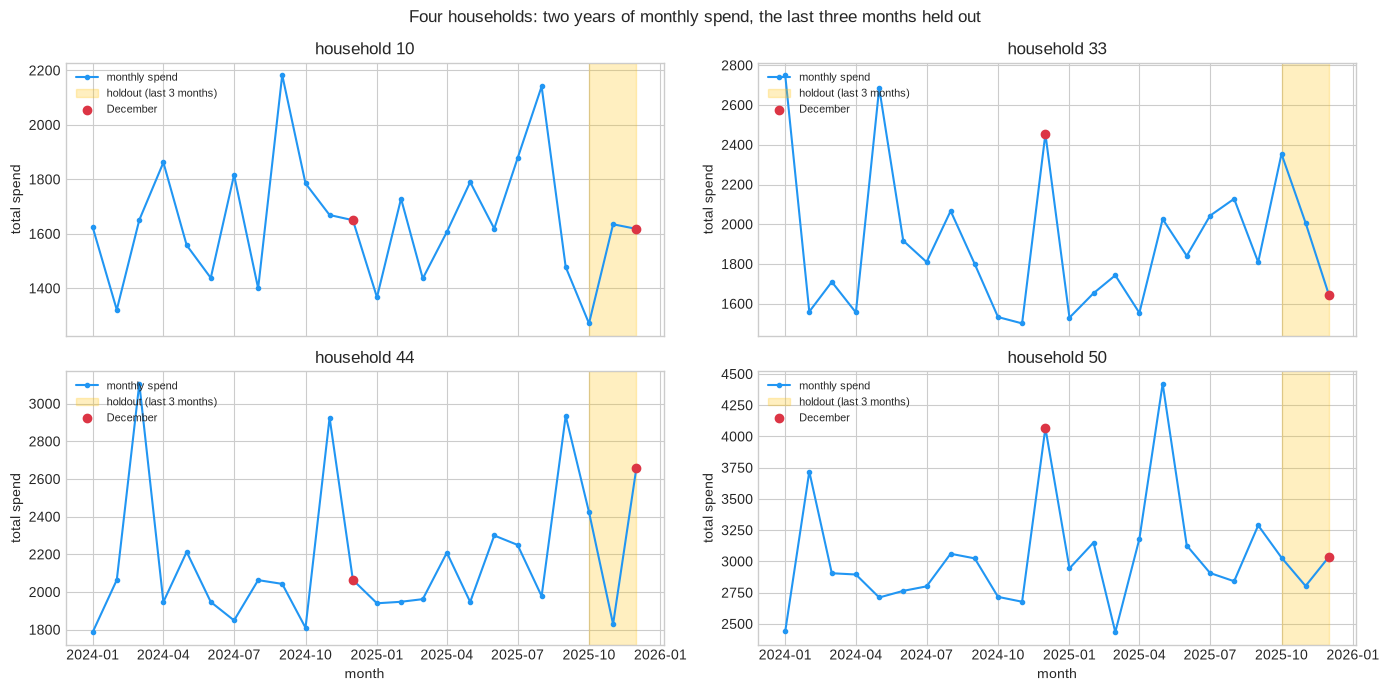

Households shown: [np.int64(10), np.int64(33), np.int64(44), np.int64(50)]  |  Decembers per series: 2


In [60]:
show_ids = ts_ids[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, iid in zip(axes.ravel(), show_ids):
    s = tsdf.loc[iid, "target"]
    ax.plot(s.index, s.values, marker="o", ms=3, color="#2196F3", label="monthly spend")
    ax.axvspan(s.index[-H], s.index[-1], color="#ffc107", alpha=0.25, label=f"holdout (last {H} months)")
    dec = [d for d in s.index if d.month == 12]
    ax.scatter(dec, s.loc[dec], color="#dc3545", zorder=3, label="December")
    ax.set_title(f"household {iid}"); ax.set_ylabel("total spend"); ax.legend(fontsize=8, loc="upper left")
for ax in axes[1]: ax.set_xlabel("month")
plt.suptitle("Four households: two years of monthly spend, the last three months held out"); plt.tight_layout(); plt.show()
print(f"Households shown: {list(show_ids)}  |  Decembers per series: {len(dec)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each panel is one household's 24 months. The two red points are the Decembers; both sit above their neighbours because the generator adds a holiday bump on top of a gentle yearly wave. The yellow band is the holdout: the model will see everything to its left and must produce the three values inside it. Note the scale differs per panel (rent depends on income and city tier), which is why the metric in 16.2 divides every error by the series' own typical error rather than reporting raw currency.

The common misread: reading the yellow band as "test rows". It is not a set of rows sampled from the table; it is the **end** of every series, and the split is the same calendar cut for all households.

</div>

## 16.2 The Math (gently): three forecast metrics and the baseline they are measured against

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math

A forecast for series $i$ at horizon step $t$ is $f_{i,t}$; the truth is $y_{i,t}$. Three metrics appear in this part:

**MASE, mean absolute scaled error.** Each series' absolute error is divided by that series' *historical seasonal-naive error* $a_i$, the average size of the error you make by predicting "the same month last year" inside the training window (season $m = 12$ for monthly data):

$$ a_i = \frac{1}{T-m} \sum_{t=m+1}^{T} |y_{i,t} - y_{i,t-m}|, \qquad \text{MASE} = \frac{1}{N}\sum_{i=1}^{N} \frac{1}{a_i}\,\frac{1}{H}\sum_{t=T+1}^{T+H} |y_{i,t} - f_{i,t}| $$

MASE is unit-free, so a household spending 1,000 and one spending 5,000 count equally. **MASE = 1 means "as good as repeating last year"**; below 1 beats it.

**sMAPE, symmetric mean absolute percentage error:** $\frac{2\,|y - f|}{|y| + |f|}$ averaged over all points. Easy to read as a percentage, but it punishes under-forecasts more than over-forecasts and explodes near zero.

**WQL, weighted quantile loss:** the metric for *probabilistic* forecasts, defined in Task 17 once quantiles are on the table.

Two baselines anchor everything: **naive** (repeat the last observed value) and **seasonal naive** (repeat the value from $m$ steps ago). A model that cannot beat seasonal naive on seasonal data has learned nothing the calendar did not already know.

</div>


In [61]:
M = 12  # seasonal period for monthly data ("MS" -> 12)

def seasonal_scale(train_tsdf, m=M):
    # a_i: mean absolute seasonal-naive error inside the training window, one value per series
    y = train_tsdf["target"]
    diffs = y.groupby(level="item_id", sort=False).diff(m).abs()
    return diffs.groupby(level="item_id", sort=False).mean()

def mase_by_hand(actual, forecast, train_tsdf, m=M):
    # actual, forecast: Series indexed by (item_id, timestamp) over the horizon
    per_item_mae = (actual - forecast).abs().groupby(level="item_id", sort=False).mean()
    return float((per_item_mae / seasonal_scale(train_tsdf, m)).mean())

def smape_by_hand(actual, forecast):
    return float((2 * (actual - forecast).abs() / (actual.abs() + forecast.abs())).mean())

y_hold = test_data.slice_by_timestep(-H, None)["target"]          # the true last H months of every series
last_val = train_data.groupby(level="item_id", sort=False)["target"].last()
naive_fc = pd.Series([last_val[i] for i, _ in y_hold.index], index=y_hold.index)
season_fc = pd.Series([train_data.loc[(i, t - pd.DateOffset(months=M)), "target"] for i, t in y_hold.index], index=y_hold.index)

baselines = pd.DataFrame({
    "MASE":  [mase_by_hand(y_hold, naive_fc, train_data), mase_by_hand(y_hold, season_fc, train_data)],
    "sMAPE": [smape_by_hand(y_hold, naive_fc), smape_by_hand(y_hold, season_fc)],
    "MAE":   [float((y_hold - naive_fc).abs().mean()), float((y_hold - season_fc).abs().mean())],
}, index=["Naive (last value)", "SeasonalNaive (last year)"])
print(baselines.round(3).to_string())
print(f"\nHoldout points scored: {len(y_hold):,} ({N_HH} series x {H} months). Beat the seasonal-naive MASE of {baselines.MASE.iloc[1]:.3f} or go home.")


                            MASE  sMAPE      MAE
Naive (last value)         1.033  0.111  282.183
SeasonalNaive (last year)  1.072  0.113  285.608

Holdout points scored: 600 (200 series x 3 months). Beat the seasonal-naive MASE of 1.072 or go home.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: compute the naive baselines before any model

Both baselines took ten lines and no training. Every model in the leaderboard below is judged against them, and MASE builds the seasonal one into its denominator so the comparison happens automatically. When a colleague reports a forecast error in currency units with no baseline, ask for the seasonal-naive number on the same holdout; without it the error has no meaning.

</div>

## 16.3 Presets in 1.6, and why this notebook names its models

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: what a preset buys

`TimeSeriesPredictor.fit(presets=...)` picks a bundle of models and a validation scheme. The cell below prints the bundles that ship with the installed version so the names are verified, not remembered. Two facts matter for a notebook that must run offline:

- `fast_training` is an **alias** of `medium_quality` in this version, and both map to the `light` model set.
- The `light` set includes two **pretrained foundation models** (`Chronos2` and `Toto2`) whose weights are downloaded from the HuggingFace Hub on first use. On Colab with internet that download takes a minute or two and is fine; on a machine without internet the fit would skip them.

So Task 16 lists its models explicitly, choosing the members of `light` that train locally (statistical models and two tabular-regression forecasters), and Task 17 gives the zero-shot foundation model a guarded cell of its own.

</div>


In [62]:
from autogluon.timeseries.configs import get_predictor_presets, get_hyperparameter_presets

presets = get_predictor_presets()
core = ["fast_training", "medium_quality", "high_quality", "best_quality", "experimental_quality", "bolt_tiny", "chronos2"]
rows = []
for name in core:
    cfg = presets[name]
    hp = cfg["hyperparameters"]
    models = list(get_hyperparameter_presets()[hp].keys()) if isinstance(hp, str) else list(hp.keys())
    rows.append({"preset": name, "model set": hp if isinstance(hp, str) else "explicit",
                 "models": ", ".join(models), "extra": {k: v for k, v in cfg.items() if k != "hyperparameters"} or ""})
preset_table = pd.DataFrame(rows).set_index("preset")
print(preset_table.to_string())
print(f"\nAll preset names in autogluon.timeseries {agts.__version__}: {sorted(presets)}")


                         model set                                                                                                                              models                                                         extra
preset                                                                                                                                                                                                                              
fast_training                light                                                         SeasonalNaive, ETS, Theta, RecursiveTabular, DirectTabular, Chronos2, Toto2                                                              
medium_quality               light                                                         SeasonalNaive, ETS, Theta, RecursiveTabular, DirectTabular, Chronos2, Toto2                                                              
high_quality               default  SeasonalNaive, AutoETS, DynamicOptimizedTheta, R

## 16.4 Fit, leaderboard, forecast

The fit below names five models. `SeasonalNaive`, `ETS` (exponential smoothing with trend and season) and `Theta` are classical **local** models: each series is fitted on its own. `n_jobs` sets how many worker processes share that work; the default is every physical core, and `n_jobs=1` keeps everything in the notebook process, which is the safe setting on a small or shared machine (a worker killed for memory takes the whole model with it). `RecursiveTabular` and `DirectTabular` are **global** models: they turn every series into lagged-feature rows and train one gradient-boosting model on all households at once (`num_threads` limits the boosting library to four cores). The ensemble on top is a weighted average chosen on validation, exactly as in Part 5.

Validation here is one **backtest window**: AutoGluon holds out the last `H` months *of the training data* (months 19-21), fits on months 1-18, scores, then refits on all 21 months for the final forecast. `score_val` comes from that window; `score_test` comes from the true holdout (months 22-24).


In [63]:
ts_hparams = {
    "SeasonalNaive":    {"n_jobs": 1},      # local models: n_jobs=1 fits series one after another in this process
    "ETS":              {"n_jobs": 1},      # (the default spawns one worker process per core; fast on a quiet machine,
    "Theta":            {"n_jobs": 1},      #  but each worker costs memory and a killed worker skips the whole model)
    "RecursiveTabular": {"model_hyperparameters": {"num_threads": 4}},
    "DirectTabular":    {"model_hyperparameters": {"num_threads": 4}},
}
ts_path = tempfile.mkdtemp(prefix="ag_ts_")
with timer("TimeSeriesPredictor.fit (5 models + ensemble)"):
    ts_predictor = TimeSeriesPredictor(
        prediction_length=H, freq="MS", eval_metric="MASE", quantile_levels=[0.1, 0.5, 0.9],
        path=ts_path, verbosity=0,
    ).fit(train_data, hyperparameters=ts_hparams, time_limit=120, random_seed=RANDOM_STATE)

ts_lb = ts_predictor.leaderboard(test_data, extra_metrics=["WQL", "sMAPE"])
print(f"models trained: {ts_predictor.model_names()}  |  best on validation: {ts_predictor.model_best}")
pretty(ts_lb.set_index("model"), subset=["score_test", "score_val", "WQL", "sMAPE"])


⏱️ TimeSeriesPredictor.fit (5 models + ensemble): 6.10 s


models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'ETS', 'Theta', 'WeightedEnsemble']  |  best on validation: WeightedEnsemble


,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order,WQL,sMAPE
model,,,,,,,,
DirectTabular,-0.817,-0.882,0.069980,0.069157,2.139597,3,-0.063,-0.087
WeightedEnsemble,-0.826,-0.847,1.682551,1.974355,0.230774,6,-0.060,-0.088
ETS,-0.864,-0.879,0.694619,1.261639,0.022495,4,-0.059,-0.092
Theta,-0.886,-0.886,0.582568,0.423489,0.021651,5,-0.060,-0.094
SeasonalNaive,-1.072,-1.158,0.260471,0.170852,0.022497,1,-0.076,-0.113
RecursiveTabular,-1.146,-1.257,0.065293,0.044670,0.959476,2,-0.086,-0.122


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading a time-series leaderboard

| Column | Meaning |
|---|---|
| `score_test` | the `eval_metric` on the holdout you passed (`test_data`). **Sign flipped**: AutoGluon reports every metric as higher-is-better, so a MASE of 0.85 shows as −0.85. |
| `score_val` | the same metric on AutoGluon's own backtest window inside the training data. This is what picked `model_best`. |
| `WQL`, `sMAPE` | `extra_metrics`, also sign-flipped, computed on `test_data`. |
| `pred_time_test` / `pred_time_val` | seconds to forecast. Local models look slow on the first call because of process start-up; the tabular models are fast once fitted. |
| `fit_time_marginal` | seconds to train this model alone. |
| `fit_order` | the order in which models were trained (priority, not alphabet). |

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Compare `score_test` with the by-hand table, not with your intuition

`SeasonalNaive` appears in both the leaderboard and the by-hand baselines of 16.2. The two MASE values should agree to the third decimal; if they do not, the seasonal period or the training window differ, and that is worth finding before trusting any other row. The cell below checks it.

</div>


In [64]:
ag_sn = ts_predictor.evaluate(test_data, model="SeasonalNaive", metrics=["MASE", "sMAPE"])
ag_sn = {k.upper(): v for k, v in ag_sn.items()}      # evaluate() returns upper-case metric names ("SMAPE")
check = pd.DataFrame({
    "by hand (16.2)": baselines.loc["SeasonalNaive (last year)", ["MASE", "sMAPE"]].values,
    "AutoGluon evaluate": [-ag_sn["MASE"], -ag_sn["SMAPE"]],
}, index=["MASE", "sMAPE"])
check["abs diff"] = (check.iloc[:, 0] - check.iloc[:, 1]).abs()
print(check.round(4).to_string())
best_mase = -ts_lb.set_index("model").loc[ts_predictor.model_best, "score_test"]
print(f"\nSeasonal naive MASE agrees to {check['abs diff'].max():.1e}.  Best model ({ts_predictor.model_best}) MASE on holdout: {best_mase:.3f}  "
      f"-> {'beats' if best_mase < baselines.MASE.iloc[1] else 'does NOT beat'} seasonal naive ({baselines.MASE.iloc[1]:.3f}).")


       by hand (16.2)  AutoGluon evaluate  abs diff
MASE           1.0719              1.0719       0.0
sMAPE          0.1134              0.1134       0.0

Seasonal naive MASE agrees to 2.2e-16.  Best model (WeightedEnsemble) MASE on holdout: 0.826  -> beats seasonal naive (1.072).


forecast: 600 rows = 200 series x 3 months; columns = ['mean', '0.1', '0.5', '0.9']
              mean     0.1     0.5     0.9
timestamp                                 
2025-10-01  1719.0  1499.0  1719.0  1947.0
2025-11-01  1674.0  1412.0  1674.0  1939.0
2025-12-01  1674.0  1359.0  1674.0  1978.0


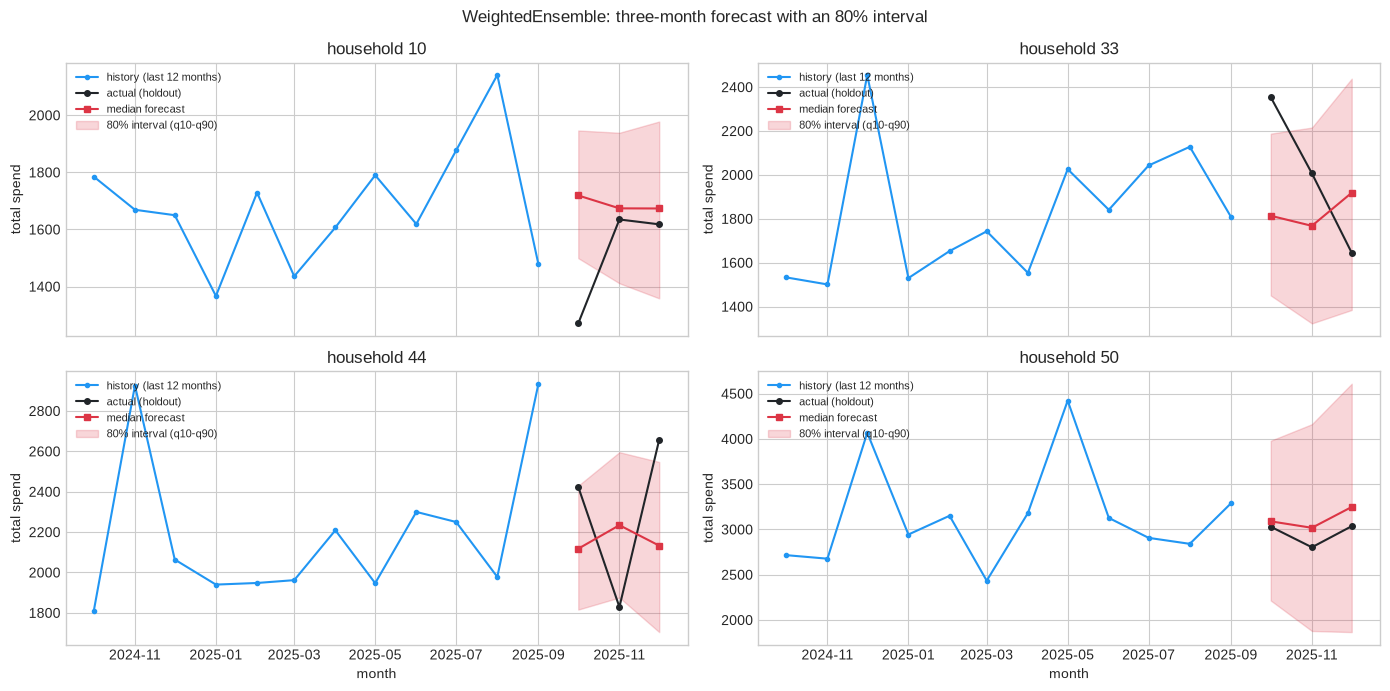

Forecast plotted for [np.int64(10), np.int64(33), np.int64(44), np.int64(50)]


In [65]:
forecast = ts_predictor.predict(train_data)          # forecasts the H months after the end of train_data
print(f"forecast: {forecast.shape[0]:,} rows = {forecast.num_items} series x {H} months; columns = {list(forecast.columns)}")
print(forecast.loc[show_ids[0]].round(0))

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, iid in zip(axes.ravel(), show_ids):
    hist = train_data.loc[iid, "target"].iloc[-12:]
    truth = test_data.loc[iid, "target"].iloc[-H:]
    fc = forecast.loc[iid]
    ax.plot(hist.index, hist.values, marker="o", ms=3, color="#2196F3", label="history (last 12 months)")
    ax.plot(truth.index, truth.values, marker="o", ms=4, color="#212529", label="actual (holdout)")
    ax.plot(fc.index, fc["0.5"], marker="s", ms=4, color="#dc3545", label="median forecast")
    ax.fill_between(fc.index, fc["0.1"], fc["0.9"], color="#dc3545", alpha=0.2, label="80% interval (q10-q90)")
    ax.set_title(f"household {iid}"); ax.set_ylabel("total spend"); ax.legend(fontsize=8, loc="upper left")
for ax in axes[1]: ax.set_xlabel("month")
plt.suptitle(f"{ts_predictor.model_best}: three-month forecast with an 80% interval"); plt.tight_layout(); plt.show()
print("Forecast plotted for", list(show_ids))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Blue is the last year the model saw; black is what actually happened in the three held-out months; red squares are the median forecast and the shaded band is the 80% interval between the 0.1 and 0.9 quantiles. Where the black points fall inside the band, the model was honest about its uncertainty; where they fall outside, it was over-confident. The band widens with the horizon, which is correct: month three is harder than month one. The December bump, when it is in the horizon, is the test of whether a model learned seasonality: the median should rise there without being told.

The common misread: judging the forecast by whether the red squares hit the black points. A median is *supposed* to miss about half the time in each direction; the question is whether it misses by less than seasonal naive (MASE) and whether the band contains the truth about 80% of the time (Task 17).

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: known covariates for things you know in advance

The calendar is known for the future. `RecursiveTabular` and `DirectTabular` already build month-of-year date features internally, but any column you can guarantee for the horizon (holidays, planned price changes, a marketing calendar) can be declared as a **known covariate** and every model that supports covariates will use it:

```python
ts_cov = ts_subset.assign(month_of_year=ts_subset.timestamp.dt.month)
tsdf_cov = TimeSeriesDataFrame.from_data_frame(ts_cov, id_column="item_id", timestamp_column="timestamp")
train_cov, test_cov = tsdf_cov.train_test_split(prediction_length=H)
pred_cov = TimeSeriesPredictor(prediction_length=H, freq="MS", eval_metric="MASE",
                               known_covariates_names=["month_of_year"]).fit(train_cov, hyperparameters=ts_hparams, time_limit=120)
future = pred_cov.make_future_data_frame(train_cov)              # (item_id, timestamp) for the next H steps
future["month_of_year"] = future.timestamp.dt.month
pred_cov.predict(train_cov, known_covariates=future)             # covariates must be supplied for the horizon
```

The rule that makes this safe: a known covariate must be **knowable at forecast time**. Next month's actual spend by category is not; next month's calendar is.

</div>

## 16.5 Task 16 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- A `TimeSeriesDataFrame` is a pandas frame indexed by `(item_id, timestamp)`; `train_test_split(prediction_length)` cuts the **end** of every series, and `test_data` keeps the history because scoring needs it.
- MASE divides each series' error by its own seasonal-naive error: **1.0 is the bar**, and it is unit-free across households of different size.
- In 1.6, `fast_training` is an alias of `medium_quality`; the `light` set behind it includes foundation models that download weights, so this notebook names its models explicitly.
- `score_val` comes from a backtest window inside the training data; `score_test` from your holdout. The seasonal-naive row is the sanity check that both are computed the way you think.
- `predict` returns the mean plus every requested quantile; the 80% band is the interval between `0.1` and `0.9`.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `tsdf`, `train_data`, `test_data` | the 200-household `TimeSeriesDataFrame` and its time split (`H = 3`) |
| `y_hold`, `naive_fc`, `season_fc`, `baselines` | true holdout values, the two by-hand baseline forecasts and their metrics |
| `mase_by_hand`, `smape_by_hand`, `seasonal_scale` | metric helpers matching AutoGluon's definitions |
| `ts_hparams`, `ts_predictor`, `ts_lb` | the model set, the fitted predictor and its leaderboard on `test_data` |
| `forecast` | mean and 0.1/0.5/0.9 quantile forecasts for the three months after `train_data` |

### ➡️ Next Up

Task 17 scores the *band*, not just the median: coverage, pinball loss and WQL, then a zero-shot foundation model (Chronos) joins the leaderboard.

</div>


# Task 17 · Probabilistic Forecasts and Chronos

## 17.1 A forecast is a distribution

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the band is the product

A household that will spend "about 2,000, but anywhere from 1,700 to 2,400" needs a different plan than one that will spend "2,000 give or take 50". A point forecast throws that difference away. AutoGluon's forecasters return **quantiles**: the value below which the truth should fall with a given probability. The 0.1 quantile should be exceeded 90% of the time, the 0.9 quantile 10% of the time, and the interval between them should contain the truth about 80% of the time. That fraction is called **coverage**, and it is the first thing to check on any interval you plan to ship.

</div>

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math: pinball loss and WQL

A quantile forecast $f^q$ is scored with the **pinball loss**, which charges $q$ per unit when the truth lands above the forecast and $1-q$ per unit when it lands below:

$$ \rho_q(y, f^q) = \begin{cases} q\,(y - f^q) & y \ge f^q \\ (1-q)\,(f^q - y) & y < f^q \end{cases} $$

The asymmetry is the point: for $q = 0.9$, under-forecasting costs nine times more than over-forecasting, so the best constant to report is the true 90th percentile. The **weighted quantile loss** sums pinball losses over all quantiles and points, then divides by the total absolute value of the truth so it reads as a fraction:

$$ \text{WQL} = \frac{2 \sum_{i,t} \frac{1}{|Q|}\sum_{q \in Q} \rho_q\!\left(y_{i,t}, f^q_{i,t}\right)}{\sum_{i,t} |y_{i,t}|} $$

With only $Q = \{0.5\}$ it reduces to the weighted absolute percentage error. Lower is better; AutoGluon reports it sign-flipped in the leaderboard.

</div>


In [66]:
Q = [0.1, 0.5, 0.9]
y_true = y_hold.loc[forecast.index]                              # align truth to the forecast rows

def pinball(y, f, q):
    return np.where(y >= f, q * (y - f), (1 - q) * (f - y))

pin = pd.DataFrame({f"q{q}": pinball(y_true.values, forecast[str(q)].values, q) for q in Q}, index=forecast.index)
wql_by_hand = 2 * pin.mean(axis=1).sum() / y_true.abs().sum()
ag_scores = ts_predictor.evaluate(test_data, metrics=["MASE", "WQL", "sMAPE"])
inside = (y_true >= forecast["0.1"]) & (y_true <= forecast["0.9"])
below = pd.Series({q: float((y_true <= forecast[str(q)]).mean()) for q in Q}, name="empirical")

print("mean pinball loss per quantile (currency units):"); print(pin.mean().round(1).to_string())
print(f"\nWQL by hand: {wql_by_hand:.4f}   |   AutoGluon evaluate WQL (sign flipped back): {-ag_scores['WQL']:.4f}   |   diff {abs(wql_by_hand + ag_scores['WQL']):.1e}")
print(f"80% interval coverage on the holdout: {inside.mean():.1%}  (target 80%)")
print("fraction of truths at or below each quantile forecast (target = the quantile):"); print(below.round(3).to_string())
print("\npredictor.evaluate (all sign-flipped, higher is better):", {k: round(v, 4) for k, v in ag_scores.items()})


mean pinball loss per quantile (currency units):
q0.1     49.6
q0.5    109.7
q0.9     71.3

WQL by hand: 0.0602   |   AutoGluon evaluate WQL (sign flipped back): 0.0602   |   diff 0.0e+00
80% interval coverage on the holdout: 82.8%  (target 80%)
fraction of truths at or below each quantile forecast (target = the quantile):
0.1    0.077
0.5    0.577
0.9    0.905

predictor.evaluate (all sign-flipped, higher is better): {'MASE': -0.8262, 'WQL': np.float64(-0.0602), 'SMAPE': -0.0879}


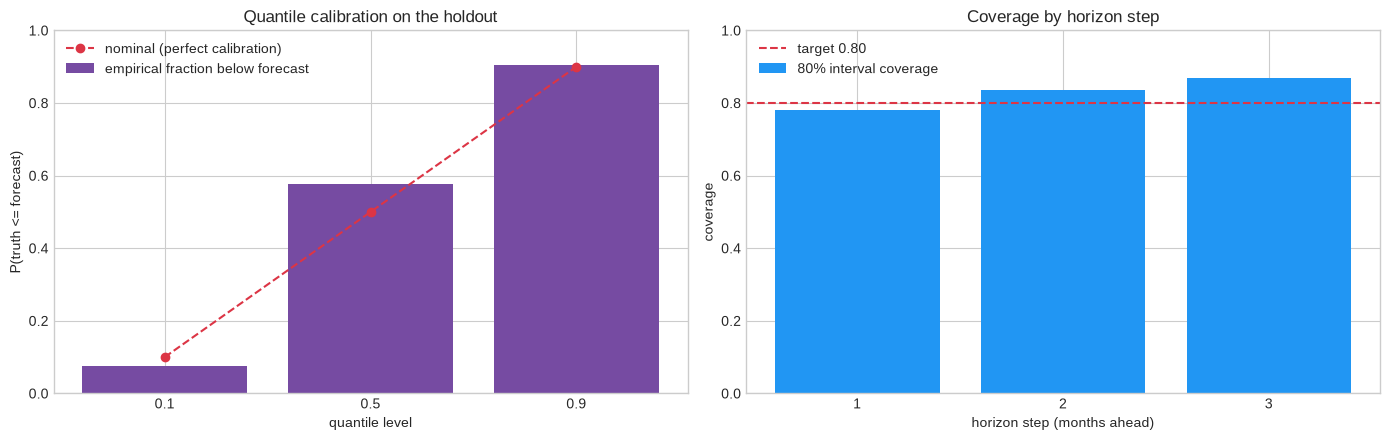

coverage by step: {1: 0.78, 2: 0.835, 3: 0.87}


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar([str(q) for q in Q], below.values, color="#764ba2", label="empirical fraction below forecast")
axes[0].plot([str(q) for q in Q], Q, "o--", color="#dc3545", label="nominal (perfect calibration)")
axes[0].set_ylim(0, 1); axes[0].set_xlabel("quantile level"); axes[0].set_ylabel("P(truth <= forecast)")
axes[0].set_title("Quantile calibration on the holdout"); axes[0].legend()

by_step = inside.groupby(level="item_id").cumcount().rename("step")
cov_step = inside.groupby(by_step.values).mean()
axes[1].bar(cov_step.index + 1, cov_step.values, color="#2196F3", label="80% interval coverage")
axes[1].axhline(0.8, color="#dc3545", ls="--", label="target 0.80")
axes[1].set_ylim(0, 1); axes[1].set_xlabel("horizon step (months ahead)"); axes[1].set_ylabel("coverage"); axes[1].set_xticks([1, 2, 3])
axes[1].set_title("Coverage by horizon step"); axes[1].legend()
plt.tight_layout(); plt.show()
print("coverage by step:", {int(k) + 1: round(v, 3) for k, v in cov_step.items()})


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: for each requested quantile, the bar is how often the truth fell at or below the forecast; the red dots are where the bars should be (0.1, 0.5, 0.9). Bars above the dots mean the quantile is too high (the model is pessimistic at that level); bars below mean it is too low. Right: the share of holdout points inside the 80% band, split by how far ahead the month is. A well-calibrated model sits near 0.80 at every step; a band that is only right for month one is a point forecast with decoration.

The common misread: treating coverage far above 80% as good news. A band that contains the truth 99% of the time is too wide to plan with; calibration means matching the promised level, not exceeding it.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: ship the interval only after the coverage check

`eval_metric="WQL"` at fit time makes AutoGluon select and weight models for the whole distribution instead of the median; use it whenever the interval is what downstream code consumes. Then compute coverage on a holdout, as above, per horizon step and per segment (city tier, household size). A single overall coverage number can hide an interval that is too wide for small households and too narrow for large ones.

</div>

## 17.2 Zero-shot forecasting with Chronos

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 SOTA: pretrained forecasters

**Chronos** is a family of time-series foundation models: transformers pretrained on a very large collection of public series, used **zero-shot**, meaning no training on your data at all. The model reads a context window of history and emits quantiles for the horizon, the way a language model emits the next token. AutoGluon 1.6 exposes several: `Chronos` with `model_path="bolt_tiny"` to `"bolt_base"` (the Chronos-Bolt sizes), `Chronos2` (the 2025 generation, which also accepts covariates) and `Toto2` (a second pretrained family). The presets table in 16.3 lists the shortcut presets `bolt_tiny`, `chronos2` and friends.

The cell below fits `bolt_tiny`, the smallest, in its own predictor with `skip_model_selection=True` (no backtest, since there is nothing to select). **Online**, Colab downloads the weights from the HuggingFace Hub on first use, a small file, then caches them. **Offline**, the download fails; the `except` branch prints why and the comparison chart falls back to the models already trained. Either way the rest of the notebook is unaffected.

</div>


In [68]:
chronos_ok, chronos_note = False, ""
chronos_path = tempfile.mkdtemp(prefix="ag_chronos_")
try:
    with timer("Chronos bolt_tiny (zero-shot: fit = load weights)"):
        chronos_predictor = TimeSeriesPredictor(
            prediction_length=H, freq="MS", eval_metric="MASE", quantile_levels=Q, path=chronos_path, verbosity=0,
        ).fit(train_data, hyperparameters={"Chronos": {"model_path": "bolt_tiny"}}, skip_model_selection=True, time_limit=90)
    with timer("Chronos predict + evaluate"):
        chronos_scores = {k.upper(): v for k, v in chronos_predictor.evaluate(test_data, metrics=["MASE", "WQL", "sMAPE"]).items()}
        chronos_fc = chronos_predictor.predict(train_data)
    chronos_ok = True
    chronos_row = pd.DataFrame([{"model": "Chronos[bolt_tiny] (zero-shot)", "score_test": chronos_scores["MASE"],
                                 "WQL": chronos_scores["WQL"], "sMAPE": chronos_scores["SMAPE"],
                                 "fit_time_marginal": chronos_predictor.leaderboard(use_cache=True)["fit_time_marginal"].iloc[0]}])
    print("Chronos scores (sign flipped, higher is better):", {k: round(v, 4) for k, v in chronos_scores.items()})
except Exception as e:                      # offline, weights unavailable, or a load error: keep going without it
    chronos_note = f"{type(e).__name__}: {str(e)[:160]}"
    chronos_row = pd.DataFrame(columns=["model", "score_test", "WQL", "sMAPE", "fit_time_marginal"])
    print("Chronos unavailable in this session ->", chronos_note)
    print("Online, this cell downloads the bolt_tiny weights and adds a zero-shot row to the comparison below.")
print(f"chronos_ok = {chronos_ok}")


⏱️ Chronos bolt_tiny (zero-shot: fit = load weights): 3.32 s


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 3707.62it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 4505.69it/s]

⏱️ Chronos predict + evaluate: 2.08 s
Chronos scores (sign flipped, higher is better): {'MASE': -0.8457, 'WQL': np.float64(-0.0578), 'SMAPE': -0.0906}
chronos_ok = True


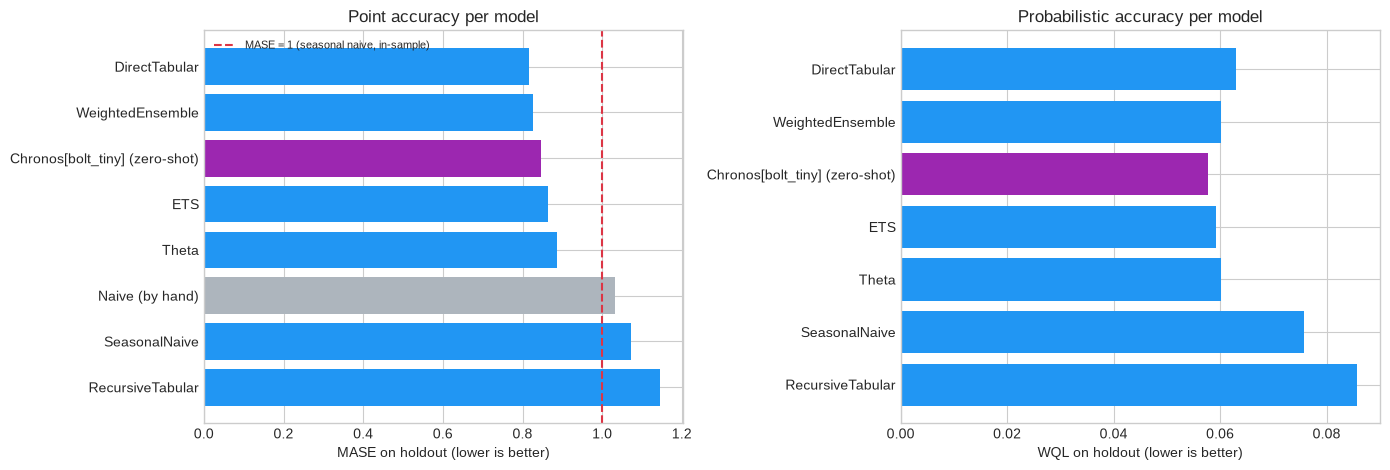

,WQL,sMAPE,fit_time_marginal,MASE
model,,,,
DirectTabular,0.063,0.087,2.139597,0.817
WeightedEnsemble,0.060,0.088,0.230774,0.826
Chronos[bolt_tiny] (zero-shot),0.058,0.091,3.241166,0.846
ETS,0.059,0.092,0.022495,0.864
Theta,0.060,0.094,0.021651,0.886
Naive (by hand),-,0.111,0.000000,1.033
SeasonalNaive,0.076,0.113,0.022497,1.072
RecursiveTabular,0.086,0.122,0.959476,1.146


In [69]:
cmp = pd.concat([ts_lb[["model", "score_test", "WQL", "sMAPE", "fit_time_marginal"]], chronos_row], ignore_index=True)
cmp["MASE"] = -cmp["score_test"]; cmp["WQL"] = -cmp["WQL"]; cmp["sMAPE"] = -cmp["sMAPE"]
cmp = cmp.drop(columns="score_test").set_index("model").sort_values("MASE")
cmp.loc["Naive (by hand)", ["MASE", "sMAPE", "fit_time_marginal"]] = [baselines.MASE.iloc[0], baselines.sMAPE.iloc[0], 0.0]
cmp = cmp.sort_values("MASE")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors = ["#9c27b0" if "Chronos" in m else ("#adb5bd" if "hand" in m else "#2196F3") for m in cmp.index]
axes[0].barh(cmp.index, cmp["MASE"], color=colors)
axes[0].axvline(1.0, color="#dc3545", ls="--", label="MASE = 1 (seasonal naive, in-sample)")
axes[0].set_xlabel("MASE on holdout (lower is better)"); axes[0].set_title("Point accuracy per model"); axes[0].invert_yaxis(); axes[0].legend(fontsize=8)
wq = cmp["WQL"].dropna()
axes[1].barh(wq.index, wq.values, color=[("#9c27b0" if "Chronos" in m else "#2196F3") for m in wq.index])
axes[1].set_xlabel("WQL on holdout (lower is better)"); axes[1].set_title("Probabilistic accuracy per model"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()
pretty(cmp, highlight="min", subset=["MASE", "WQL", "sMAPE"])


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: MASE per model on the same 200-household holdout, purple for the zero-shot Chronos row when it loaded, grey for the by-hand naive baseline, and the dashed line at 1.0 that every serious model must sit left of. Right: WQL, which scores the whole quantile band; models with no quantile output are absent. Two things to look for: whether the ensemble beats its best member (it should, slightly, when members disagree), and how close a model that **never saw this data** comes to models trained on it. With short, clean, seasonal series the gap is small, which is the honest state of the art in 2026: pretrained forecasters are a strong first answer, and a fitted ensemble is the better final one when you have history to fit on.

The common misread: comparing `fit_time_marginal` across the two kinds of model. For Chronos that number is the time to load weights, not to learn; the real cost is at prediction time, where a transformer forward pass per series is slower than a fitted ETS.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A zero-shot model has no `score_val`

`skip_model_selection=True` means no backtest was run, so the Chronos predictor cannot tell you how good it is until you score it on a holdout you provide. Never deploy a zero-shot forecaster on the strength of its benchmark reputation alone: run `evaluate(test_data)` on your own tail, and compare it with seasonal naive, exactly as above.

</div>

## 17.3 Task 17 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Quantile forecasts are scored with the **pinball loss**; WQL aggregates it over quantiles and points and divides by the scale of the truth. The by-hand value matches `predictor.evaluate` to numerical precision.
- **Coverage** is the calibration check for intervals: the 80% band should hold the truth about 80% of the time, at every horizon step. Too wide is a failure too.
- `eval_metric="WQL"` makes model selection care about the band; `"MASE"` cares about the median.
- **Chronos** and its siblings forecast zero-shot from pretrained weights; they need internet once, produce no validation score, and are compared on your holdout like any other row.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `pin`, `wql_by_hand`, `inside`, `below` | pinball losses per quantile, WQL by hand, per-point interval hits, empirical quantile levels |
| `ag_scores` | `ts_predictor.evaluate(test_data, metrics=[MASE, WQL, sMAPE])` |
| `chronos_ok`, `chronos_predictor`, `chronos_scores` | whether the zero-shot model loaded, and its scores if it did |
| `cmp` | every model's MASE / WQL / sMAPE on the holdout, including the by-hand naive row |

### ➡️ Next Up

Part 8 returns to the household table and its free-text `note` column: what AutoGluon does with text by default, what a multimodal fusion network adds, and what it costs.

</div>


# Part 8 · Multimodal: Text Notes plus Numbers ⭐⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### One column, three treatments

The household table has a `note` column: a short sentence the household wrote about the month ("car repair and a new phone", "quiet month, cooked at home"). Task 18 asks a question every practitioner meets: **is this text worth a language model?** The answer comes from three fits, each treating `note` differently, and one cost table. The honest result is more useful than the flashy one.

</div>


# Task 18 · The `note` Column: Category, Text, or Transformer?

## 18.1 What AutoGluon thinks `note` is

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: type inference decides the treatment

Before any model sees a column, AutoGluon infers its **type**: numeric, categorical, datetime, or text. The rule for text is not "contains letters"; it is "many distinct values with several words each". A column of eight recurring sentences is, statistically, a category with eight levels, and treating it as one is correct: a one-hot code is a perfect summary of a templated note. Text features (character counts, word n-grams) and text backbones only earn their cost when the column has real variety. The cell below asks both predictors what they see, without training anything.

</div>


In [70]:
from autogluon.tabular import TabularPredictor
from autogluon.common.features.feature_metadata import FeatureMetadata
from autogluon.multimodal.data.infer_types import infer_column_types

TEXT_COL = "note"
mm_cols = FEATURES + [LABEL_CLS]
tab_types = FeatureMetadata.from_df(train_df[mm_cols])
mm_types = infer_column_types(train_df[mm_cols], label_columns=LABEL_CLS)

print(f"'{TEXT_COL}': {train_df[TEXT_COL].nunique()} distinct values in {len(train_df):,} rows; "
      f"mean {train_df[TEXT_COL].str.split().str.len().mean():.1f} words; examples: {train_df[TEXT_COL].unique()[:3].tolist()}")
print(f"\nTabularPredictor raw type for '{TEXT_COL}': {tab_types.type_map_raw[TEXT_COL]!r}, special types: {dict(tab_types.type_group_map_special)}")
print(f"MultiModalPredictor inferred type for '{TEXT_COL}': {mm_types[TEXT_COL]!r}")
print("\nMultiModal column types for the whole table:")
print(pd.Series(mm_types).rename("inferred type").to_string())


'note': 8 distinct values in 1,125 rows; mean 4.9 words; examples: ['cut the streaming subscriptions', 'medical bills came in', 'hosted family for a week']

TabularPredictor raw type for 'note': 'object', special types: {}
MultiModalPredictor inferred type for 'note': 'categorical'

MultiModal column types for the whole table:
city_tier              categorical
household_size         categorical
owns_car               categorical
income                   numerical
rent                     numerical
groceries                numerical
utilities                numerical
transport                numerical
dining                   numerical
entertainment            numerical
other                    numerical
note                   categorical
total_spend              numerical
overspent              categorical
survey_score           categorical
referral_code          categorical
avg_spend_prev           numerical
overspend_rate_prev      numerical
max_dining_prev          numerical
oversp

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Both predictors read `note` as a category

Neither the tabular nor the multimodal path treats `note` as text by default: eight distinct short sentences look like eight labels, because they are. If you *know* a column is free text (a support ticket, a product review, a doctor's note) and the sample happens to be repetitive, you must say so: `feature_metadata=FeatureMetadata.from_df(df).add_special_types({"note": ["text"]})` for `TabularPredictor`, and `column_types={"note": "text"}` for `MultiModalPredictor`. Task 18 uses both overrides on purpose so you can see the price and the payoff.

</div>

## 18.2 Three tabular fits: without `note`, with it as a category, with it as text

Three 30-second fits, same budget and preset, differing only in what `note` is allowed to be. `ag_args_fit={"num_cpus": SAFE_N_CPUS}` keeps each fit to four cores. The **ablation** (with versus without) is the cleanest way to measure what a column is worth; the third fit shows what the `text` special type adds: character and word statistics, and word n-gram counts when the vocabulary is large enough to support them.


In [71]:
import os
FEATURES_NO_TEXT = [c for c in FEATURES if c != TEXT_COL]
tab_paths, tab_models, tab_cards, tab_times = [], {}, [], {}

# Dynamically detect available CPU cores in this runtime to avoid over-allocating
SAFE_N_CPUS = os.cpu_count() or 1

def fit_tabular(name, features, feature_metadata=None):
    path = tempfile.mkdtemp(prefix="ag_tab_"); tab_paths.append(path)
    t0 = time.perf_counter()
    p = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=path, verbosity=0).fit(
        train_df[features + [LABEL_CLS]], time_limit=30, presets="medium_quality",
        feature_metadata=feature_metadata, ag_args_fit={"num_cpus": SAFE_N_CPUS})
    fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); proba = p.predict_proba(test_df[features])[1].values; inf_s = time.perf_counter() - t0
    tab_models[name] = p; tab_times[name] = (fit_s, inf_s)
    tab_cards.append(report_card(test_df[LABEL_CLS], (proba >= 0.5).astype(int), proba, name=name))
    print(f"{name:<28s} fit {fit_s:5.1f} s | predict {inf_s:.2f} s | best: {p.model_best} | {len(p.feature_metadata.get_features())} features after preprocessing")
    return p

with timer("three TabularPredictor fits"):
    fit_tabular("Tabular: no note", FEATURES_NO_TEXT)
    fit_tabular("Tabular: note as category", FEATURES)
    fm_text = FeatureMetadata.from_df(train_df[FEATURES + [LABEL_CLS]]).add_special_types({TEXT_COL: ["text"]})
    fit_tabular("Tabular: note as text", FEATURES, feature_metadata=fm_text)

text_feats = [f for f in tab_models["Tabular: note as text"].feature_metadata.get_features() if TEXT_COL in f or "__nlp__" in f]
print(f"\nfeatures derived from '{TEXT_COL}' when typed as text ({len(text_feats)}): {text_feats}")
pretty(pd.concat(tab_cards), subset=["roc_auc", "pr_auc", "f1", "log_loss"])

Tabular: no note             fit  17.8 s | predict 0.22 s | best: WeightedEnsemble_L2 | 18 features after preprocessing


Tabular: note as category    fit  16.3 s | predict 0.05 s | best: WeightedEnsemble_L2 | 19 features after preprocessing


Tabular: note as text        fit  16.4 s | predict 0.22 s | best: WeightedEnsemble_L2 | 24 features after preprocessing
⏱️ three TabularPredictor fits: 51.14 s

features derived from 'note' when typed as text (6): ['note', 'note.char_count', 'note.word_count', 'note.lower_ratio', 'note.special_ratio', 'note.symbol_ratio. ']


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
Tabular: no note,0.920000,0.806242,0.851064,0.634921,0.727,0.691603,0.939,0.819,0.224,0.064833
Tabular: note as category,0.893333,0.783883,0.709091,0.619048,0.661,0.600012,0.925,0.800,0.250,0.074970
Tabular: note as text,0.920000,0.787241,0.902439,0.587302,0.712,0.688269,0.942,0.822,0.228,0.065893


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Reading the ablation

The report card lines up three models on the same test rows. The gap between "no note" and "note as category" is the whole value of the column for this problem; the generator ties certain notes ("car repair and a new phone", "medical bills came in") to surprise expenses, so some lift is expected. The third row rarely improves on the second: with eight templates, the text statistics are a noisier encoding of the same eight levels, and the n-gram generator has little vocabulary to work with. That is not a failure of the text machinery; it is the machinery correctly finding nothing new.

</div>

## 18.3 MultiModalPredictor: a fusion network with a text backbone

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 SOTA: late fusion

`MultiModalPredictor` builds one neural network with a branch per modality: a pretrained transformer for text columns, small MLPs for numeric and categorical columns, and a **fusion** head that concatenates the branch outputs and predicts the label. Everything is fine-tuned end to end with a Lightning trainer. The same class handles images, and pairs of texts for matching; here it gets one text column and sixteen tabular ones.

The cell below keeps the cost honest for a CPU: a 600-row subset, `prajjwal1/bert-tiny` as the backbone (two transformer layers, about four million parameters), two epochs, 32-bit precision and no data-loader workers. `column_types={"note": "text"}` forces the text branch on; without it, 18.1 showed, the column would be one-hot encoded and the backbone never loaded. **Online**, Colab downloads the backbone from the HuggingFace Hub on first use, then caches it. **Offline**, or if the fit fails for any reason, the `except` branch trains the fallback that every text problem should start with anyway: TF-IDF n-grams on `note` plus the numeric features, through a `ColumnTransformer` into logistic regression. The report card and cost table are produced either way.

</div>


In [72]:
# !pip install -q autogluon.multimodal   # included in the full `autogluon` install used by this notebook
import logging, torch
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

mm_train = train_df.sample(600, random_state=RANDOM_STATE)[mm_cols].reset_index(drop=True)
mm_test = test_df[mm_cols].reset_index(drop=True)
mm_hparams = {
    "model.hf_text.checkpoint_name": "prajjwal1/bert-tiny",   # a 2-layer BERT: small enough for a CPU epoch in seconds
    "optim.max_epochs": 2,
    "env.num_gpus": 0, "env.precision": 32,                    # CPU-only settings; on a Colab GPU drop these two lines
    "env.num_workers": 0, "env.num_workers_inference": 0,      # no data-loader subprocesses (safer on shared machines)
    "env.batch_size": 32, "env.per_gpu_batch_size": 32,
}
mm_ok, mm_note, mm_path = False, "", tempfile.mkdtemp(prefix="ag_mm_")
for _name in ("lightning.pytorch", "lightning", "pytorch_lightning"):
    logging.getLogger(_name).setLevel(logging.WARNING)          # silence the trainer's info chatter
_prev_threads = torch.get_num_threads(); torch.set_num_threads(4)
try:
    from autogluon.multimodal import MultiModalPredictor
    t0 = time.perf_counter()
    mm_predictor = MultiModalPredictor(label=LABEL_CLS, problem_type="binary", eval_metric="roc_auc",
                                       path=mm_path, verbosity=0, enable_progress_bar=False)
    mm_predictor.fit(mm_train, column_types={TEXT_COL: "text"}, hyperparameters=mm_hparams, time_limit=120, seed=RANDOM_STATE)
    mm_fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); mm_proba = mm_predictor.predict_proba(mm_test)[1].values; mm_inf_s = time.perf_counter() - t0
    mm_ok = True
    mm_name = "MultiModal: bert-tiny + MLPs (600 rows)"
    print(f"MultiModalPredictor: text column(s) = {[c for c, t in mm_predictor.column_types.items() if t == 'text']}, "
          f"backbone = {mm_hparams['model.hf_text.checkpoint_name']}, fit {mm_fit_s:.1f} s, predict {mm_inf_s:.2f} s on {len(mm_test)} rows")
except Exception as e:
    mm_note = f"{type(e).__name__}: {str(e)[:160]}"
    print("MultiModalPredictor unavailable in this session ->", mm_note)
    print("Online, this cell downloads prajjwal1/bert-tiny and fine-tunes a text+tabular fusion network; the fallback below runs instead.")
    mm_name = "Fallback: TF-IDF + numeric -> LogReg (600 rows)"
    num_cols = [c for c in FEATURES_NO_TEXT if np.issubdtype(train_df[c].dtype, np.number) or train_df[c].dtype == bool]
    cat_cols = [c for c in FEATURES_NO_TEXT if c not in num_cols]
    fallback = Pipeline([
        ("prep", ColumnTransformer([
            ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2), TEXT_COL),
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])),
        ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))])
    t0 = time.perf_counter(); fallback.fit(mm_train[FEATURES].astype({c: str for c in cat_cols}), mm_train[LABEL_CLS]); mm_fit_s = time.perf_counter() - t0
    t0 = time.perf_counter(); mm_proba = fallback.predict_proba(mm_test[FEATURES].astype({c: str for c in cat_cols}))[:, 1]; mm_inf_s = time.perf_counter() - t0
finally:
    torch.set_num_threads(_prev_threads)

mm_card = report_card(mm_test[LABEL_CLS], (mm_proba >= 0.5).astype(int), mm_proba, name=mm_name)
print(f"mm_ok = {mm_ok}"); pretty(mm_card, subset=["roc_auc", "pr_auc", "f1", "log_loss"])


INFO: Seed set to 42


MultiModalPredictor unavailable in this session -> ValueError: Unrecognized model in prajjwal1/bert-tiny. Should have a `model_type` key in its config.json.
Online, this cell downloads prajjwal1/bert-tiny and fine-tunes a text+tabular fusion network; the fallback below runs instead.
mm_ok = False


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
Fallback: TF-IDF + numeric -> LogReg (600 rows),0.917333,0.804640,0.833333,0.634921,0.721,0.681820,0.927,0.815,0.224,0.063315


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ `time_limit` stops training, not downloading

For `MultiModalPredictor`, `time_limit` caps the fine-tuning loop. It does not cap the backbone download, the tokenizer load, or the data-loader start-up, and on a free Colab CPU those can dominate. Two habits keep this predictable: test on a few hundred rows first (as above), and pin a **small** checkpoint by name rather than accepting the default (`google/electra-base-discriminator`, roughly thirty times the size of `bert-tiny`). On a GPU runtime, remove the `env.num_gpus`/`env.precision` lines and raise `optim.max_epochs`; the same code then trains a serious model.

</div>

## 18.4 The cost table

Every model so far had one ROC-AUC and two clocks: seconds to fit and seconds to score the test set. A fourth row, TF-IDF into logistic regression on the same 600-row subset, is added regardless of whether the multimodal fit succeeded, because it is the baseline a text feature must beat before any transformer is justified.


In [73]:
num_cols = [c for c in FEATURES_NO_TEXT if np.issubdtype(train_df[c].dtype, np.number) or train_df[c].dtype == bool]
cat_cols = [c for c in FEATURES_NO_TEXT if c not in num_cols]
tfidf_lr = Pipeline([
    ("prep", ColumnTransformer([
        ("txt", TfidfVectorizer(ngram_range=(1, 2), min_df=2), TEXT_COL),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE))])
_X = lambda df: df[FEATURES].astype({c: str for c in cat_cols})
t0 = time.perf_counter(); tfidf_lr.fit(_X(mm_train), mm_train[LABEL_CLS]); lr_fit_s = time.perf_counter() - t0
t0 = time.perf_counter(); lr_proba = tfidf_lr.predict_proba(_X(mm_test))[:, 1]; lr_inf_s = time.perf_counter() - t0
lr_name = "TF-IDF + numeric -> LogReg (600 rows)"
lr_card = report_card(mm_test[LABEL_CLS], (lr_proba >= 0.5).astype(int), lr_proba, name=lr_name)

cards = pd.concat(tab_cards + [mm_card, lr_card])
cost = pd.DataFrame({
    "roc_auc": cards["roc_auc"], "log_loss": cards["log_loss"],
    "train rows": [len(train_df)] * 3 + [len(mm_train)] * 2,
    "fit_s": [tab_times[n][0] for n in tab_times] + [mm_fit_s, lr_fit_s],
    "predict_s_per_1k": [tab_times[n][1] / len(test_df) * 1000 for n in tab_times] + [mm_inf_s / len(mm_test) * 1000, lr_inf_s / len(mm_test) * 1000],
}, index=cards.index)
print(f"n-gram vocabulary the TF-IDF baseline found in '{TEXT_COL}': {len(tfidf_lr.named_steps['prep'].named_transformers_['txt'].vocabulary_)} terms")
pretty(cost, fmt="{:.3f}", subset=["roc_auc"])


n-gram vocabulary the TF-IDF baseline found in 'note': 62 terms


,roc_auc,log_loss,train rows,fit_s,predict_s_per_1k
model,,,,,
Tabular: no note,0.939,0.224334,1125,17.797041,0.573966
Tabular: note as category,0.925,0.250319,1125,16.332850,0.142602
Tabular: note as text,0.942,0.228312,1125,16.429451,0.594307
Fallback: TF-IDF + numeric -> LogReg (600 rows),0.927,0.223632,600,0.061998,0.057074
TF-IDF + numeric -> LogReg (600 rows),0.927,0.223632,600,0.050032,0.057117


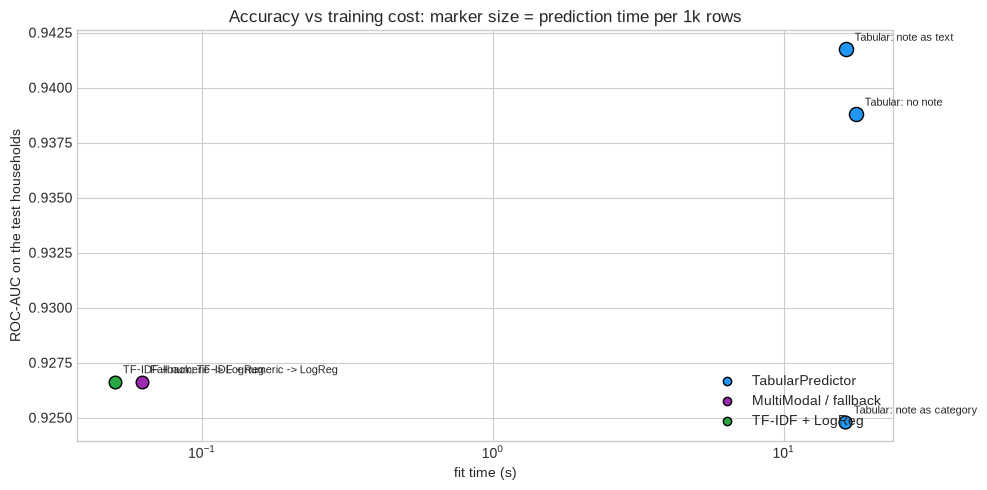

Highest ROC-AUC: Tabular: note as text (0.942); spread across all five rows: 0.017


In [74]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = {"Tabular": "#2196F3", "MultiModal": "#9c27b0", "Fallback": "#9c27b0", "TF-IDF": "#28a745"}
for name, r in cost.iterrows():
    c = next(v for k, v in palette.items() if name.startswith(k))
    ax.scatter(r["fit_s"], r["roc_auc"], s=80 + 40 * r["predict_s_per_1k"], color=c, edgecolor="k", zorder=3)
    ax.annotate(name.split(" (")[0], (r["fit_s"], r["roc_auc"]), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xlabel("fit time (s)"); ax.set_ylabel("ROC-AUC on the test households"); ax.set_xscale("log")
ax.set_title("Accuracy vs training cost: marker size = prediction time per 1k rows")
for k, c in [("TabularPredictor", "#2196F3"), ("MultiModal / fallback", "#9c27b0"), ("TF-IDF + LogReg", "#28a745")]:
    ax.scatter([], [], color=c, edgecolor="k", label=k)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
best = cost["roc_auc"].idxmax()
print(f"Highest ROC-AUC: {best} ({cost.loc[best, 'roc_auc']:.3f}); spread across all five rows: {cost['roc_auc'].max() - cost['roc_auc'].min():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each marker is one of the five models; horizontal position is training time on a log scale, vertical is ROC-AUC on the same test households, and marker size is how long it takes to score a thousand rows. The three blue tabular fits sit at the same cost with a small vertical spread that is the value of `note`. The purple marker (the fusion network, or the fallback when offline) and the green one (TF-IDF into logistic regression) were trained on 600 rows, not 1,125, so they start with a handicap; read their heights against each other, not against the blue ones. The printed spread is the whole story: when the notes are eight templates, every treatment lands within a few hundredths of ROC-AUC, and the cheapest one is the right one.

The common misread: concluding that transformers do not help with text. They do, when the text carries information a category code cannot: varied wording, long descriptions, sentiment, entities. The test is the ablation in 18.2, not the architecture.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: earn the backbone

1. Fit **without** the text column and **with** it as a category. The gap is the column's value; if it is near zero, stop.
2. If the gap is real, try text statistics and TF-IDF n-grams (`text` special type, or the fallback pipeline). Cheap, fast to serve, easy to explain.
3. Only then try `MultiModalPredictor` with a small backbone on a subset, and compare on the same holdout **and** the same clocks. Move to a larger checkpoint only if the small one already beat step 2.
4. Whatever wins, record fit time and prediction latency next to the score; Part 9 turns those numbers into a deployment decision.

</div>


In [75]:
# tidy up the model directories this part created (they are not needed by later parts)
for _p in [ts_path, chronos_path, mm_path] + tab_paths:
    shutil.rmtree(_p, ignore_errors=True)
summary18 = cost[["roc_auc", "fit_s"]].copy()
summary18["treatment of note"] = ["dropped", "category (default)", "text special type", "transformer branch" if mm_ok else "TF-IDF fallback", "TF-IDF n-grams"]
print(summary18.round(3).to_string())
print(f"\nPart 8 done. MultiModal path ran: {mm_ok}. Temporary predictor directories removed: {3 + len(tab_paths)}.")


                                                 roc_auc   fit_s   treatment of note
model                                                                               
Tabular: no note                                   0.939  17.797             dropped
Tabular: note as category                          0.925  16.333  category (default)
Tabular: note as text                              0.942  16.429   text special type
Fallback: TF-IDF + numeric -> LogReg (600 rows)    0.927   0.062     TF-IDF fallback
TF-IDF + numeric -> LogReg (600 rows)              0.927   0.050      TF-IDF n-grams

Part 8 done. MultiModal path ran: False. Temporary predictor directories removed: 6.


## 18.5 Task 18 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Type inference decides the treatment: eight templated sentences are a **category** to both `TabularPredictor` and `MultiModalPredictor`, and that is correct. Force `text` only when you know the column is free text.
- The **ablation** (with vs without the column) measures what text is worth; the architecture comparison only matters after the ablation says the column carries signal.
- `MultiModalPredictor` fuses a pretrained text backbone with tabular MLPs; keep it honest on CPU with a subset, a tiny checkpoint and a fixed epoch count, and always keep a TF-IDF baseline beside it.
- Report accuracy **with** both clocks. On this data the five treatments land within a few hundredths of ROC-AUC; the cost table, not the score, picks the winner.

### 🔑 New variables

| Variable | What it holds |
|---|---|
| `tab_types`, `mm_types` | the inferred column types from the tabular and multimodal paths |
| `tab_models`, `tab_cards`, `tab_times` | the three tabular predictors, their report cards and (fit, predict) seconds |
| `fm_text` | `FeatureMetadata` that forces the `text` special type on `note` |
| `mm_ok`, `mm_predictor`, `mm_proba`, `mm_card` | whether the fusion network ran, the predictor, its test probabilities and report card |
| `tfidf_lr`, `lr_card`, `cost` | the TF-IDF baseline pipeline, its report card and the five-row cost table |

### ➡️ Next Up

Part 9 takes the tabular winner to production: save and reload, refit on all data, distill to one fast model, measure latency, and watch for drift.

</div>


# Part 9 · MLOps: Persist, Refit, Distill, Speed, Drift, Monitoring ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### From a leaderboard to a service

This Part is self-contained: it trains one classification predictor at the top of Task 19 and reuses it through Part 10, so you can start here after running Part 0.

A model that only lives in a notebook has not been shipped. Shipping means five separate skills: **persisting** the predictor to disk and reloading it in a fresh process, **refitting** on all the data once the validation split has done its job, making inference **fast** (memory persistence, inference limits, distillation), **detecting drift** when tomorrow's data stops looking like today's, and a **monitoring** loop that decides when to retrain. AutoGluon has a method for each one, and this Part measures what every method buys.

</div>

| Task | Skill | AutoGluon methods |
|:----:|-------|-------------------|
| 19 | persist and reload, refit, prune | `save`, `load`, `refit_full`, `persist`, `clone_for_deployment`, `delete_models` |
| 20 | speed and distillation | `leaderboard(... pred_time ...)`, `infer_limit`, `distill`, `only_pareto_frontier` |
| 21 | drift and monitoring | PSI by hand, `feature_importance` on drifted data, `fit_extra` |


# Task 19 · Persist, Reload, Refit and Prune

## 19.1 The predictor for this Part

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: a predictor is a directory, not an object

When `fit` finishes, the Python object in your notebook is a thin handle. The real predictor is the **directory** at `predictor.path`: every model's weights, the feature preprocessing pipeline, the learner metadata, and a copy of the training data (so that `refit_full` and `distill` can run later). Everything in this Task manipulates that directory, which is why disk size is a number this Task keeps printing.

</div>

The classification target is `overspent_next`. The text column `note` is dropped for the tabular fits in this Part (Part 8 covers text), and `num_cpus=SAFE_N_CPUS` keeps the fit polite on a shared machine.


In [76]:
import os, sys, tempfile, shutil, json, pathlib
from autogluon.tabular import TabularPredictor
import autogluon.tabular
print(f"AutoGluon {autogluon.tabular.__version__}")

FEATS_TAB = [f for f in FEATURES if f != "note"]          # tabular features only (Part 8 covers `note`)
MODEL_DIR = tempfile.mkdtemp(prefix="ag_part9_")
X_test, y_test = test_df[FEATS_TAB], test_df[LABEL_CLS].values


def dir_size_mb(path):
    # Total size of every file under `path`, in megabytes (os.walk visits every model sub-directory).
    total = 0
    for root, _, files in os.walk(path):
        total += sum(os.path.getsize(os.path.join(root, f)) for f in files)
    return total / 1e6


with timer("fit (60 s budget, medium_quality)"):
    predictor = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=MODEL_DIR, verbosity=0).fit(
        train_df[FEATS_TAB + [LABEL_CLS]], time_limit=60, presets="medium_quality", num_cpus=SAFE_N_CPUS)

lb = predictor.leaderboard(test_df, silent=True)
proba_test = predictor.predict_proba(X_test)[1].values
card = report_card(y_test, (proba_test >= 0.5).astype(int), proba_test, name=predictor.model_best)
display(pretty(card))
print(f"{len(predictor.model_names())} models on disk  |  best: {predictor.model_best}  |  directory: {dir_size_mb(MODEL_DIR):.1f} MB")


AutoGluon 1.6.3


⏱️ fit (60 s budget, medium_quality): 18.64 s


,accuracy,balanced_acc,precision,recall,f1,mcc,roc_auc,pr_auc,log_loss,brier
model,,,,,,,,,,
WeightedEnsemble_L2,0.920,0.806,0.851,0.635,0.727,0.692,0.939,0.819,0.224,0.065


12 models on disk  |  best: WeightedEnsemble_L2  |  directory: 20.5 MB


## 19.2 `save()` and `load()`: the round trip

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

`fit` already saved everything, so `predictor.save()` is a no-op safety net that rewrites the predictor metadata. The interesting call is `TabularPredictor.load(path)`: it rebuilds the handle from disk in a **new process** (a serving container, a batch job, a colleague's laptop). The one test that matters is that the reloaded predictor returns the same probabilities to the last decimal.

</div>

`load` also checks that the AutoGluon and Python versions match the ones that trained the model, and refuses to load when they differ (`require_version_match=True` by default). That refusal is a feature: a model that loads under a different version can silently score differently.


In [77]:
predictor.save()
loaded = TabularPredictor.load(MODEL_DIR, verbosity=0)
proba_loaded = loaded.predict_proba(X_test)[1].values

# a manifest next to the model: the four facts a serving job needs and the directory does not spell out
manifest = {"autogluon_version": autogluon.tabular.__version__, "python": sys.version.split()[0],
            "label": LABEL_CLS, "features": FEATS_TAB, "best_model": predictor.model_best,
            "test_roc_auc": float(roc_auc_score(y_test, proba_test))}
pathlib.Path(MODEL_DIR, "manifest.json").write_text(json.dumps(manifest, indent=2))

print(f"max |p_loaded - p_original| = {np.abs(proba_loaded - proba_test).max():.2e}")
print(f"loaded.model_best = {loaded.model_best}  |  same feature list: {loaded.features() == FEATS_TAB}")
print(f"manifest written: {json.dumps({k: v for k, v in manifest.items() if k != 'features'})}")


max |p_loaded - p_original| = 0.00e+00
loaded.model_best = WeightedEnsemble_L2  |  same feature list: True
manifest written: {"autogluon_version": "1.6.3", "python": "3.11.16", "label": "overspent_next", "best_model": "WeightedEnsemble_L2", "test_roc_auc": 0.9387973137973138}


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: ship a manifest with the directory

The cell above wrote `manifest.json` next to the models: library version, Python version, label, the exact feature list, the best model's name and its test score. Six months from now, that file answers "which columns does this thing expect?" and "what score did it have when it left?" without loading anything. Serving code should assert on the feature list before calling `predict`.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `predictor.path` is a temporary directory here

`tempfile.mkdtemp()` is right for a notebook and wrong for a product. On Colab the directory disappears with the runtime. For real use, pass a path on mounted Drive or object storage, and treat the whole directory (not a single file) as the artefact to version and copy.

</div>

## 19.3 `refit_full()`: why the `_FULL` models have no validation score

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

During `fit`, AutoGluon held out a slice of the training rows as its own validation set. That slice chose the early-stopping point of every model and the weights of the ensemble. Once those decisions are made, the held-out rows are wasted as training signal. `refit_full()` retrains every model on **all** the training rows with the hyperparameters the validation slice picked, and names the copies `<model>_FULL`.

The price: a `_FULL` model has no untouched rows left to score itself on, so its `score_val` is `NaN`. Its parent's validation score is the only estimate you have, and it is an estimate for a model trained on fewer rows.

</div>


In [78]:
with timer("refit_full()"):
    refit_map = predictor.refit_full(num_cpus=SAFE_N_CPUS)

lb_full = predictor.leaderboard(test_df, silent=True)
pairs = pd.DataFrame({"parent": list(refit_map.keys()), "full": list(refit_map.values())})
score = lb_full.set_index("model")
pairs["score_test_parent"] = pairs.parent.map(score.score_test)
pairs["score_test_full"] = pairs.full.map(score.score_test)
pairs["score_val_full"] = pairs.full.map(score.score_val)
pairs["fit_time_parent"] = pairs.parent.map(score.fit_time)
pairs["fit_time_full"] = pairs.full.map(score.fit_time)
pairs["delta_test"] = pairs.score_test_full - pairs.score_test_parent
display(pretty(pairs.set_index("parent"), highlight=None))

better = int((pairs.delta_test > 0).sum())
print(f"best model is now: {predictor.model_best}  (set_best_to_refit_full=True by default)")
print(f"{better} of {len(pairs)} _FULL models beat their parent on the test set; mean delta = {pairs.delta_test.mean():+.4f} ROC-AUC")
print(f"every _FULL score_val is NaN: {pairs.score_val_full.isna().all()}")


⏱️ refit_full(): 9.56 s


,full,score_test_parent,score_test_full,score_val_full,fit_time_parent,fit_time_full,delta_test
parent,,,,,,,
LightGBMXT,LightGBMXT_FULL,0.939,0.937,-,0.779,0.544,-0.001
LightGBM,LightGBM_FULL,0.924,0.920,-,2.646,0.528,-0.004
RandomForestGini,RandomForestGini_FULL,0.936,0.923,-,1.279,1.189,-0.012
RandomForestEntr,RandomForestEntr_FULL,0.936,0.933,-,1.184,1.259,-0.003
CatBoost,CatBoost_FULL,0.933,0.936,-,2.042,0.161,0.002
ExtraTreesGini,ExtraTreesGini_FULL,0.928,0.922,-,0.959,0.972,-0.006
ExtraTreesEntr,ExtraTreesEntr_FULL,0.931,0.924,-,0.962,0.995,-0.007
NeuralNetFastAI,NeuralNetFastAI_FULL,0.897,0.919,-,1.310,0.835,0.022
XGBoost,XGBoost_FULL,0.927,0.905,-,0.353,0.050,-0.022


best model is now: WeightedEnsemble_L2_FULL  (set_best_to_refit_full=True by default)
3 of 12 _FULL models beat their parent on the test set; mean delta = -0.0043 ROC-AUC
every _FULL score_val is NaN: True


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The table pairs each model with its `_FULL` refit. `score_val_full` is `NaN` for every row, by construction. `delta_test` is the honest verdict, and on a training set this small it is mixed: some refits gain a little, some lose a little, and the mean delta is close to zero. Refitting on roughly a third more rows helps most when the validation slice was a large fraction of a small dataset; it is not a free lunch. The `_FULL` fit times are shorter because no early-stopping search is repeated, the models simply train for the number of rounds their parent found.

The common misread: taking the `_FULL` model's missing `score_val` as "unknown quality". Its quality is known from its parent, on fewer rows; what is unknown is whether the extra rows helped, and only a real holdout (here, `test_df`) can say.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: after `refit_full`, `predict` uses the refit model

`predictor.model_best` changed in the cell above. Any number you computed before the refit (the report card in 19.1) describes a model that is no longer the default. Recompute after every call that mutates the predictor: `refit_full`, `distill`, `fit_extra`, `delete_models`, `set_decision_threshold`.

</div>

## 19.4 `persist()`: keep the models in memory

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

By default every `predict` call loads the needed models from disk, scores, and drops them again. That is memory-safe and slow. `predictor.persist()` loads the best model and its ancestors once and keeps them in RAM. For a service answering many small requests this is the cheapest speed-up available: one line, and the factor it buys is printed below (it depends on the disk, the machine's load and the size of the models; what remains after persisting is the fixed cost of preprocessing one row, which Task 20 measures).

</div>


In [79]:
one_row = X_test.iloc[[0]]

def latency_ms(fn, n=20):
    # Median wall time of n calls, in milliseconds.
    times = []
    for _ in range(n):
        t0 = _time.perf_counter(); fn(); times.append((_time.perf_counter() - t0) * 1e3)
    return float(np.median(times))

predictor.unpersist()
lat_disk = latency_ms(lambda: predictor.predict_proba(one_row))
persisted = predictor.persist()
lat_ram = latency_ms(lambda: predictor.predict_proba(one_row))

print(f"persisted models: {persisted}")
print(f"single-row predict_proba: from disk {lat_disk:.1f} ms  ->  persisted {lat_ram:.1f} ms  ({lat_disk / lat_ram:.1f}x faster)")


persisted models: ['NeuralNetTorch_FULL', 'WeightedEnsemble_L2_FULL', 'CatBoost_FULL', 'ExtraTreesEntr_FULL']
single-row predict_proba: from disk 175.6 ms  ->  persisted 149.2 ms  (1.2x faster)


## 19.5 `clone_for_deployment()` and `delete_models()`: ship only what predicts

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

The directory now holds the original models, their `_FULL` refits, the ensemble, and a copy of the training data. Serving needs one thing: the best model and the models it depends on (an ensemble's ancestors). `clone_for_deployment(path)` copies exactly that minimal set to a new directory and strips the training data. `delete_models(models_to_keep="best")` does the pruning in place. The cell measures both against the full directory.

</div>


In [80]:
size_full = dir_size_mb(MODEL_DIR)

# 1) a deployment clone: only the best model and its ancestors, no training data
DEPLOY_DIR = tempfile.mkdtemp(prefix="ag_deploy_")
deploy_predictor = predictor.clone_for_deployment(path=DEPLOY_DIR, dirs_exist_ok=True, return_clone=True)
size_deploy = dir_size_mb(DEPLOY_DIR)

# 2) in-place pruning, shown on a full copy so the notebook keeps every model for Task 20
PRUNE_DIR = tempfile.mkdtemp(prefix="ag_prune_")
pruned = predictor.clone(path=PRUNE_DIR, dirs_exist_ok=True, return_clone=True)
n_before = len(pruned.model_names())
pruned.delete_models(models_to_keep="best", dry_run=False)
size_pruned = dir_size_mb(PRUNE_DIR)

proba_deploy = deploy_predictor.predict_proba(X_test)[1].values
sizes = pd.DataFrame({"directory": ["full predictor", "delete_models(models_to_keep='best')", "clone_for_deployment"],
                      "models": [len(predictor.model_names()), len(pruned.model_names()), len(deploy_predictor.model_names())],
                      "size_MB": [size_full, size_pruned, size_deploy]}).set_index("directory")
display(pretty(sizes, fmt="{:.2f}", highlight="min"))
print(f"deployment clone keeps: {deploy_predictor.model_names()}")
print(f"same predictions as the full predictor: {np.allclose(proba_deploy, predictor.predict_proba(X_test)[1].values)}")
print(f"size: {size_full:.1f} MB -> {size_deploy:.2f} MB  ({size_full / size_deploy:.0f}x smaller)")


,models,size_MB
directory,,
full predictor,24.00,45.93
delete_models(models_to_keep='best'),4.00,8.29
clone_for_deployment,4.00,8.12


deployment clone keeps: ['CatBoost_FULL', 'ExtraTreesEntr_FULL', 'NeuralNetTorch_FULL', 'WeightedEnsemble_L2_FULL']
same predictions as the full predictor: True
size: 45.9 MB -> 8.12 MB  (6x smaller)


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: deploy the clone, keep the original

The clone predicts identically and is a small fraction of the size, but it cannot `refit_full`, `distill`, `fit_extra` or `leaderboard` on new data: the training data and the other models are gone. Keep the full directory in cold storage as the thing you retrain from, and ship the clone as the thing that answers requests.

</div>

## 19.6 Task 19 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The predictor **is its directory**. `load(path)` rebuilds it in another process and returns the same probabilities to the last decimal; a `manifest.json` beside it records versions, features and the departure score.
- `refit_full()` retrains on all rows and produces `_FULL` models with `score_val = NaN`; only a real holdout can say whether the extra rows helped, and on small data the gain is mixed.
- `persist()` keeps the best model and its ancestors in memory; single-row latency drops by the printed factor, and what remains is per-call preprocessing overhead.
- `clone_for_deployment()` copies the minimal model set without training data; `delete_models(models_to_keep="best")` prunes in place.
- Every mutating call (`refit_full`, `distill`, `fit_extra`, `delete_models`) changes `model_best`; recompute scores afterwards.

</div>

### 🔑 New variables

| Variable | Type | Meaning |
|---|---|---|
| `predictor` | `TabularPredictor` | the Part 9-10 classifier (`overspent_next`, ROC-AUC, 60 s), now refit and persisted |
| `MODEL_DIR`, `DEPLOY_DIR`, `PRUNE_DIR` | `str` | the full, deployment-clone and pruned-copy directories |
| `FEATS_TAB`, `X_test`, `y_test`, `proba_test` | list, DataFrame, arrays | tabular features (no `note`), test inputs, labels and the pre-refit probabilities |
| `refit_map`, `pairs` | dict, DataFrame | parent → `_FULL` names and their paired scores |
| `deploy_predictor`, `pruned` | `TabularPredictor` | the deployment clone and the pruned copy |
| `dir_size_mb`, `latency_ms` | functions | directory size via `os.walk`; median call latency |

### ➡️ Next Up

Task 20 turns to speed: where inference time goes model by model, `infer_limit` at fit time, and `distill` to compress the ensemble into one model.


# Task 20 · Speed and Distillation

## 20.1 Where inference time goes

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the ensemble pays for every member

`WeightedEnsemble_L2` is a weighted average of other models' predictions. Its prediction time is the **sum** of its members' times plus a little arithmetic. A random forest with hundreds of trees is slow per row; a gradient-boosted model with a few hundred shallow trees is fast. The leaderboard already measures all of this: `pred_time_test` is the time to score the whole test set, and dividing by the number of rows gives the per-row cost that a latency budget is written in.

</div>


,score_test,pred_time_test,pred_time_test_marginal,stack_level,us_per_row,marginal_us_per_row
model,,,,,,
LightGBM,0.9241,0.0061,0.0061,1.0000,16.2373,16.2373
LightGBM_FULL,0.9202,0.0066,0.0066,1.0000,17.5521,17.5521
LightGBMXT,0.9388,0.0082,0.0082,1.0000,21.7883,21.7883
XGBoost_FULL,0.9048,0.0086,0.0086,1.0000,22.9524,22.9524
LightGBMXT_FULL,0.9374,0.0095,0.0095,1.0000,25.2056,25.2056
LightGBMLarge_FULL,0.8943,0.0098,0.0098,1.0000,26.1650,26.1650
CatBoost,0.9334,0.0104,0.0104,1.0000,27.7767,27.7767
CatBoost_FULL,0.9356,0.0112,0.0112,1.0000,29.7979,29.7979
LightGBMLarge,0.9116,0.0146,0.0146,1.0000,39.0224,39.0224


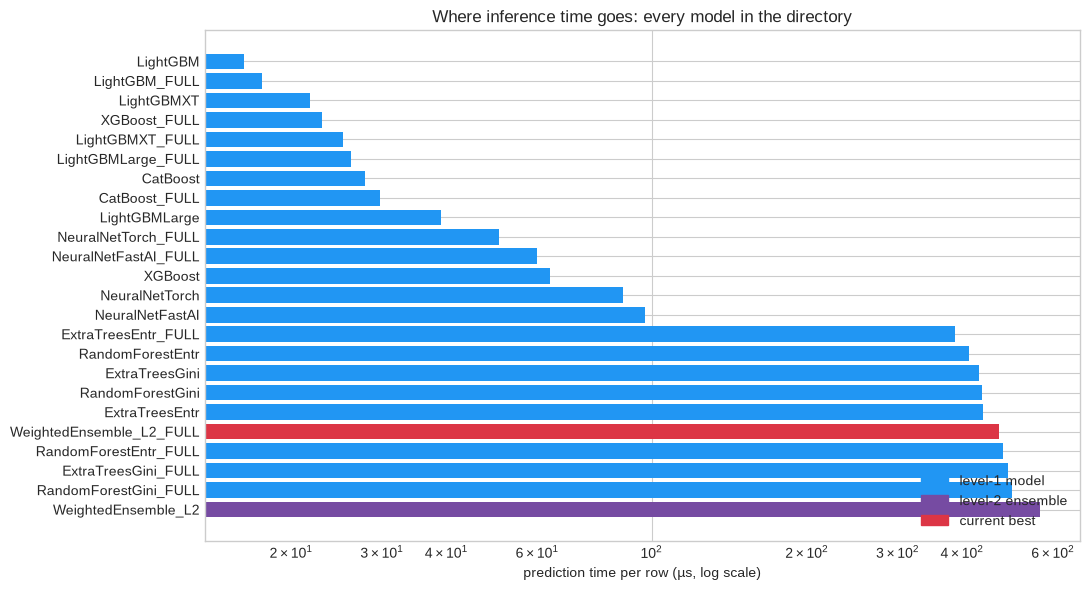

fastest: LightGBM at 16 µs/row  |  slowest: WeightedEnsemble_L2 at 567 µs/row  (35x)
best model WeightedEnsemble_L2_FULL: 473 µs/row, ROC-AUC 0.9402


In [81]:
lb = predictor.leaderboard(test_df, silent=True)
speed = lb[["model", "score_test", "pred_time_test", "pred_time_test_marginal", "stack_level"]].copy()
speed["us_per_row"] = speed.pred_time_test / len(test_df) * 1e6      # microseconds per row, whole ensemble path
speed["marginal_us_per_row"] = speed.pred_time_test_marginal / len(test_df) * 1e6   # this model alone
speed = speed.sort_values("us_per_row").set_index("model")
display(pretty(speed, fmt="{:.4f}", highlight=None))

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#dc3545" if m == predictor.model_best else ("#764ba2" if lvl == 2 else "#2196F3") for m, lvl in zip(speed.index, speed.stack_level)]
ax.barh(speed.index, speed.us_per_row, color=colors)
ax.set_xscale("log"); ax.set_xlabel("prediction time per row (µs, log scale)"); ax.set_title("Where inference time goes: every model in the directory")
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2196F3", label="level-1 model"), Patch(color="#764ba2", label="level-2 ensemble"), Patch(color="#dc3545", label="current best")], loc="lower right")
plt.tight_layout(); plt.show()

fastest, slowest = speed.us_per_row.idxmin(), speed.us_per_row.idxmax()
print(f"fastest: {fastest} at {speed.us_per_row.min():.0f} µs/row  |  slowest: {slowest} at {speed.us_per_row.max():.0f} µs/row  ({speed.us_per_row.max() / speed.us_per_row.min():.0f}x)")
print(f"best model {predictor.model_best}: {speed.loc[predictor.model_best, 'us_per_row']:.0f} µs/row, ROC-AUC {speed.loc[predictor.model_best, 'score_test']:.4f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Prediction time per row spans more than an order of magnitude across the directory (the printed line gives the ratio between the slowest and the fastest), which is why the axis is logarithmic. The tree-bagging families (random forest, extra trees) sit at the slow end because every row walks hundreds of deep trees; the boosted models (LightGBM, CatBoost) sit at the fast end with a few hundred shallow ones. The ensembles (purple) cost the sum of their members, so where they land depends on which members they chose, and the `_FULL` copies are a little faster than their parents because they stop at the round their parent found. `pred_time_test_marginal` in the table is a model's own cost; `pred_time_test` includes everything it needs to run first.

The common misread: reading the fastest bar as the model to ship. Speed is one axis; the Pareto plot in 20.4 puts score on the other.

</div>

## 20.2 `infer_limit`: a latency budget at fit time

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Instead of pruning slow models after the fact, tell `fit` the budget up front: `infer_limit` is the maximum seconds **per row** the final predictor may spend, and `infer_limit_batch_size` is the batch size that budget is measured at (per-row cost falls with batch size, so the two go together). AutoGluon then skips models it expects to be too slow and builds an ensemble that respects the limit. This fit uses a 30 s budget and the same data.

</div>


In [82]:
INFER_LIMIT = 50e-6      # 50 microseconds per row ...
INFER_BATCH = 10_000     # ... measured on batches of 10,000 rows
FAST_DIR = tempfile.mkdtemp(prefix="ag_fast_")
with timer("fit with infer_limit (30 s budget)"):
    fast_predictor = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=FAST_DIR, verbosity=0).fit(
        train_df[FEATS_TAB + [LABEL_CLS]], time_limit=30, presets="medium_quality", num_cpus=SAFE_N_CPUS,
        infer_limit=INFER_LIMIT, infer_limit_batch_size=INFER_BATCH)

fast_predictor.persist()
fast_best = fast_predictor.model_best
p_fast = fast_predictor.predict_proba(X_test)[1].values
p_full = predictor.predict_proba(X_test)[1].values

# measure per-row cost at two batch sizes: the test set, and the batch size the budget was written for
big_batch = pd.concat([X_test] * (INFER_BATCH // len(X_test) + 1), ignore_index=True).iloc[:INFER_BATCH]
def us_per_row(pred, data, n=3):
    return latency_ms(lambda: pred.predict_proba(data), n=n) / len(data) * 1e3

compare = pd.concat([report_card(y_test, (p_full >= 0.5).astype(int), p_full, name=f"unconstrained: {predictor.model_best}"),
                     report_card(y_test, (p_fast >= 0.5).astype(int), p_fast, name=f"infer_limit: {fast_best}")])
compare[f"us_per_row@{len(X_test)}"] = [us_per_row(predictor, X_test), us_per_row(fast_predictor, X_test)]
compare[f"us_per_row@{INFER_BATCH}"] = [us_per_row(predictor, big_batch), us_per_row(fast_predictor, big_batch)]
display(pretty(compare[["roc_auc", "pr_auc", "log_loss", "f1", f"us_per_row@{len(X_test)}", f"us_per_row@{INFER_BATCH}"]], highlight=None))
print(f"unconstrained directory: {len(predictor.model_names())} models  |  infer_limit directory: {len(fast_predictor.model_names())} models: {fast_predictor.model_names()}")
print(f"budget {INFER_LIMIT * 1e6:.0f} µs/row at batch {INFER_BATCH:,}  ->  {fast_best}: {compare.iloc[1, -1]:.0f} µs/row at {INFER_BATCH:,} rows, {compare.iloc[1, -2]:.0f} µs/row at {len(X_test)} rows")


⏱️ fit with infer_limit (30 s budget): 17.36 s


,roc_auc,pr_auc,log_loss,f1,us_per_row@375,us_per_row@10000
model,,,,,,
unconstrained: WeightedEnsemble_L2_FULL,0.940,0.818,0.253,0.739,462.652,30.878
infer_limit: WeightedEnsemble_L2,0.938,0.819,0.224,0.761,75.542,9.764


unconstrained directory: 24 models  |  infer_limit directory: 12 models: ['LightGBMXT', 'LightGBM', 'RandomForestGini', 'RandomForestEntr', 'CatBoost', 'ExtraTreesGini', 'ExtraTreesEntr', 'NeuralNetFastAI', 'XGBoost', 'NeuralNetTorch', 'LightGBMLarge', 'WeightedEnsemble_L2']
budget 50 µs/row at batch 10,000  ->  WeightedEnsemble_L2: 10 µs/row at 10,000 rows, 76 µs/row at 375 rows


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the limit is measured at `infer_limit_batch_size`, not on your batch

The table has two per-row columns. At 10,000 rows, the batch size the budget was written for, the constrained predictor is near the 50 µs it was asked for (AutoGluon measured it on its own validation rows at fit time, on a shared machine, so a small overshoot is load, not a bug). At a few hundred rows the same predictor costs several times more per row, because the fixed cost of one call (feature preprocessing, model dispatch) is spread over fewer rows, and it can even cost more than the unconstrained predictor: when the constrained directory keeps bagged forests (the printed model list says whether it did), their per-row cost is fine at 10,000 rows and poor at 375. Write the budget for the batch size the service actually uses, and if that is one row at a time, measure one row at a time (20.5 does).

</div>

## 20.3 `distill()`: one model that imitates the ensemble

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Knowledge distillation trains a small **student** model to reproduce the **teacher**'s outputs instead of the raw labels. The teacher here is the full ensemble; its probabilities are a smoother, more informative target than 0/1 labels (a row the teacher scores at 0.45 teaches the student more than the label 0 does). `predictor.distill()` augments the training data with synthetic rows (`augment_method="spunge"` by default) so the student sees the teacher's opinion on inputs between the real ones, trains single models on the teacher's soft predictions, and adds them to the directory with a `_DSTL` suffix.

</div>

### 📐 The Math (gently)

The student minimises the cross-entropy against the teacher's probability $p_T$ rather than the hard label $y$:

$$ \mathcal{L}_{\text{distill}} = -\frac{1}{n}\sum_{i=1}^{n} \Big[ p_T(x_i)\,\log p_S(x_i) + \big(1 - p_T(x_i)\big)\,\log\big(1 - p_S(x_i)\big) \Big] $$

With hard labels, $p_T \in \{0, 1\}$ and this is the ordinary log loss; with soft labels the student is also told *how sure* the teacher was.


In [83]:
with timer("distill (30 s budget, GBM student)"):
    distilled = predictor.distill(time_limit=30, hyperparameters={"GBM": {"ag_args_fit": {"num_cpus": SAFE_N_CPUS}}}, teacher_preds="soft", verbosity=0)

lb = predictor.leaderboard(test_df, silent=True).set_index("model")
teacher = [m for m in lb.index if m.startswith("WeightedEnsemble") and m.endswith("_FULL")][0]
student = [m for m in distilled if not m.startswith("WeightedEnsemble")][0]

p_student = predictor.predict_proba(X_test, model=student)[1].values
p_teacher = predictor.predict_proba(X_test, model=teacher)[1].values

# Clip probabilities to [0, 1] to prevent Brier Score and Log Loss calculations from crashing on out-of-bounds predictions
p_student = np.clip(p_student, 0.0, 1.0)
p_teacher = np.clip(p_teacher, 0.0, 1.0)

cards = pd.concat([report_card(y_test, (p_teacher >= 0.5).astype(int), p_teacher, name=f"teacher: {teacher}"),
                   report_card(y_test, (p_student >= 0.5).astype(int), p_student, name=f"student: {student}")])
cards["us_per_row_test"] = [lb.loc[teacher, "pred_time_test"] / len(test_df) * 1e6, lb.loc[student, "pred_time_test"] / len(test_df) * 1e6]
display(pretty(cards[["roc_auc", "pr_auc", "log_loss", "brier", "f1", "us_per_row_test"]]))
print(f"distilled models added: {distilled}")
print(f"student vs teacher: ROC-AUC {cards.roc_auc.iloc[1]:.4f} vs {cards.roc_auc.iloc[0]:.4f}  |  agreement of probabilities: corr = {np.corrcoef(p_student, p_teacher)[0, 1]:.3f}  |  {cards.us_per_row_test.iloc[0] / cards.us_per_row_test.iloc[1]:.1f}x faster")

⏱️ distill (30 s budget, GBM student): 3.68 s


,roc_auc,pr_auc,log_loss,brier,f1,us_per_row_test
model,,,,,,
teacher: WeightedEnsemble_L2_FULL,0.940,0.818,0.253,0.069,0.739,454.905
student: LightGBM_DSTL,0.929,0.810,0.230,0.065,0.734,17.227


distilled models added: ['LightGBM_DSTL', 'WeightedEnsemble_L2_DSTL']
student vs teacher: ROC-AUC 0.9288 vs 0.9402  |  agreement of probabilities: corr = 0.979  |  26.4x faster


## 20.4 The Pareto plot: score against time

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A model is **Pareto-optimal** when no other model is both faster and better. Plot every model with time on the x-axis and score on the y-axis: the Pareto frontier is the upper-left staircase, and everything below or to the right of it is dominated, there is a model that beats it on both counts. `leaderboard(only_pareto_frontier=True)` computes that staircase for you.

</div>


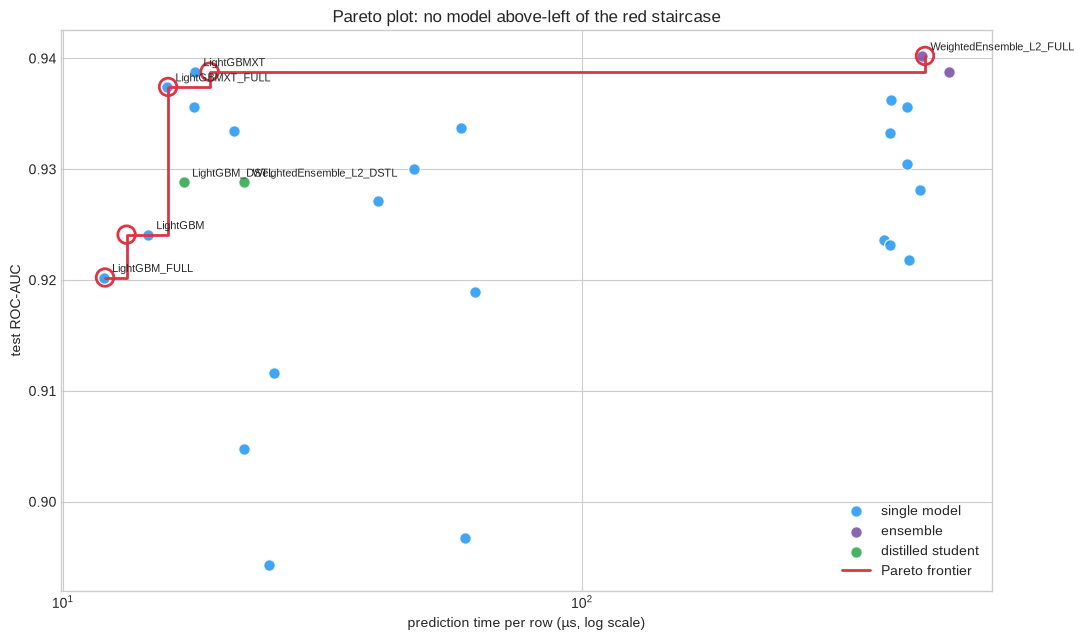

Pareto-optimal models (5): ['LightGBM_FULL', 'LightGBM', 'LightGBMXT_FULL', 'LightGBMXT', 'WeightedEnsemble_L2_FULL']
student LightGBM_DSTL on the frontier: False  |  best WeightedEnsemble_L2_FULL on the frontier: True


In [84]:
lb_all = predictor.leaderboard(test_df, silent=True)
lb_pareto = predictor.leaderboard(test_df, silent=True, only_pareto_frontier=True).sort_values("pred_time_test")
lb_all["us_per_row"] = lb_all.pred_time_test / len(test_df) * 1e6
lb_pareto["us_per_row"] = lb_pareto.pred_time_test / len(test_df) * 1e6

fig, ax = plt.subplots(figsize=(11, 6.5))
kind = np.where(lb_all.model.str.endswith("_DSTL"), "distilled student", np.where(lb_all.model.str.startswith("WeightedEnsemble"), "ensemble", "single model"))
palette = {"single model": "#2196F3", "ensemble": "#764ba2", "distilled student": "#28a745"}
for k, col in palette.items():
    sel = lb_all[kind == k]
    ax.scatter(sel.us_per_row, sel.score_test, s=70, color=col, label=k, alpha=0.85, edgecolor="white")
ax.step(lb_pareto.us_per_row, lb_pareto.score_test, where="post", color="#dc3545", lw=2, label="Pareto frontier")
ax.scatter(lb_pareto.us_per_row, lb_pareto.score_test, s=160, facecolor="none", edgecolor="#dc3545", lw=2)
for _, r in lb_all.iterrows():
    if r.model in set(lb_pareto.model) or r.model.endswith("_DSTL") or r.model == predictor.model_best:
        ax.annotate(r.model, (r.us_per_row, r.score_test), xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("prediction time per row (µs, log scale)"); ax.set_ylabel("test ROC-AUC")
ax.set_title("Pareto plot: no model above-left of the red staircase"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"Pareto-optimal models ({len(lb_pareto)}): {lb_pareto.model.tolist()}")
print(f"student {student} on the frontier: {student in set(lb_pareto.model)}  |  best {predictor.model_best} on the frontier: {predictor.model_best in set(lb_pareto.model)}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each dot is one model from the directory; the red staircase is the Pareto frontier that `only_pareto_frontier=True` returns. Reading left to right, every step up is a model that buys more ROC-AUC for more time. The models to the right of a step are dominated: something on the frontier is at least as accurate and faster. The frontier can be short: when one fast single model (here a LightGBM variant) scores above the ensembles on the test set, it dominates everything slower, and the ensemble that `model_best` names falls below the staircase. That happens because the ensemble was chosen on the validation slice and the plot scores the test set; on 375 test rows the two disagree by a few thousandths, which is enough to reorder the top. The green student sits at the fast end; the printed line says whether it and the current best made the frontier in this run.

The common misread: assuming `model_best` is always the one to ship. The frontier gives you a menu; the latency budget of the service picks from it, and validation and test can disagree about the top of it.

</div>

## 20.5 Batch versus single-row latency

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Per-row cost is not a constant. Every `predict_proba` call pays a fixed overhead (feature preprocessing setup, model dispatch) before touching a row, and then a small per-row cost. Scoring one row at a time pays the overhead every time; scoring a batch pays it once. The measurement below uses the persisted predictor, its student, and the deployment clone.

</div>


In [85]:
predictor.persist(models=[predictor.model_best, student])
batch = test_df[FEATS_TAB]
rows = [batch.iloc[[i]] for i in range(20)]

lat = []
for name, fn_batch, fn_row in [
    (f"best: {predictor.model_best}", lambda: predictor.predict_proba(batch), lambda r: predictor.predict_proba(r)),
    (f"student: {student}", lambda: predictor.predict_proba(batch, model=student), lambda r: predictor.predict_proba(r, model=student)),
]:
    t_batch = latency_ms(fn_batch, n=5)
    t_row = float(np.median([latency_ms(lambda r=r: fn_row(r), n=3) for r in rows]))
    lat.append({"model": name, "batch_ms": t_batch, "batch_us_per_row": t_batch / len(batch) * 1e3,
                "single_row_ms": t_row, "rows_per_s_single": 1e3 / t_row, "rows_per_s_batch": len(batch) / t_batch * 1e3})
lat = pd.DataFrame(lat).set_index("model")
display(pretty(lat, fmt="{:,.2f}", highlight=None))
print(f"batch of {len(batch)} rows vs one row: the per-row cost is {lat.single_row_ms.iloc[0] / lat.batch_us_per_row.iloc[0] * 1e3:.0f}x higher one row at a time for the best model")


,batch_ms,batch_us_per_row,single_row_ms,rows_per_s_single,rows_per_s_batch
model,,,,,
best: WeightedEnsemble_L2_FULL,174.07,464.18,150.89,6.63,"2,154.35"
student: LightGBM_DSTL,8.45,22.54,6.14,162.87,"44,364.71"


batch of 375 rows vs one row: the per-row cost is 325x higher one row at a time for the best model


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: batch requests, then pick from the frontier

The table shows the order of the problem: one row at a time costs many times more per row than a batch. Before distilling or dropping models, check whether the service can accumulate requests into micro-batches (even 50 rows amortises most of the overhead). Then choose the model from the Pareto frontier that fits the remaining budget, and only distill if the frontier still does not reach it.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the student learned the teacher's mistakes

The student's probabilities track the teacher's closely (the correlation printed in 20.3). That is the point of distillation, and it is also its limit: a student cannot exceed its teacher, it only approaches it. When the teacher is miscalibrated or biased on a segment (Part 10 checks), the student inherits the fault at a fraction of the cost.

</div>

## 20.6 Task 20 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- `pred_time_test` in the leaderboard, divided by the row count, is the per-row latency the service budget is written in; the directory spans about two orders of magnitude of it.
- `infer_limit` and `infer_limit_batch_size` in `fit` make AutoGluon respect a per-row budget at training time, at the batch size you name.
- `distill()` trains a single `_DSTL` student on the ensemble's soft probabilities; it is faster by the printed factor and slightly less accurate, and it cannot beat its teacher.
- `leaderboard(only_pareto_frontier=True)` returns the models that are not dominated on (time, score); ship from that menu.
- Single-row scoring costs many times more per row than batched scoring; batching is the first optimisation, not the last.

</div>

### 🔑 New variables

| Variable | Type | Meaning |
|---|---|---|
| `speed` | DataFrame | per-model prediction time in µs per row (total and marginal) |
| `fast_predictor`, `FAST_DIR`, `INFER_LIMIT`, `INFER_BATCH` | predictor, str, floats | the predictor fit under a 50 µs/row budget |
| `distilled`, `student`, `teacher` | list, str, str | the `_DSTL` model names, the GBM student and its ensemble teacher |
| `lb_all`, `lb_pareto` | DataFrames | the full leaderboard and its Pareto frontier |
| `lat` | DataFrame | batch vs single-row latency for the best model and the student |

### ➡️ Next Up

Task 21 asks what happens when the data changes after deployment: drift measured by PSI, the model's own view of drifted rows, and a monitoring loop with a retrain trigger.


# Task 21 · Drift and Monitoring

## 21.1 A month that looks different

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the model is frozen, the world is not

A deployed model is a function fitted to one snapshot of the data. **Data drift** is when the inputs move away from that snapshot (a raise for everyone, a new dining habit, a migration to the metros). **Concept drift** is when the relation between inputs and outcome changes (the same income now leads to different overspending). The first is visible the moment new rows arrive; the second is visible only when labels arrive, which for a "next month" target is a month later.

The cell below manufactures a drifted month from the test set with three deliberate changes, and keeps the original labels: in production you would not have next month's labels yet.

</div>


In [86]:
rng_drift = np.random.default_rng(RANDOM_STATE + 1)
drift_df = test_df.copy()
drift_df["income"] = (drift_df.income * 1.20).round(0)                                             # everyone got a 20% raise
drift_df["dining"] = (drift_df.dining + 80).round(0)                                               # a new habit: dining up by 80 for all
drift_df["city_tier"] = np.where(rng_drift.random(len(drift_df)) < 0.30, "metro", drift_df.city_tier)  # 30% of households now count as metro

changed = ["income", "dining", "city_tier"]
summary = pd.DataFrame({
    "test_mean_or_share": [test_df.income.mean(), test_df.dining.mean(), (test_df.city_tier == "metro").mean()],
    "drifted_mean_or_share": [drift_df.income.mean(), drift_df.dining.mean(), (drift_df.city_tier == "metro").mean()],
}, index=["income (mean)", "dining (mean)", "city_tier == metro (share)"])
display(pretty(summary, fmt="{:,.3f}", highlight=None))
print(f"drifted month: {len(drift_df)} rows, {len(changed)} columns changed on purpose, labels kept from test_df (not yet observable in production)")


,test_mean_or_share,drifted_mean_or_share
income (mean),"4,976.707","5,972.059"
dining (mean),126.394,206.394
city_tier == metro (share),0.288,0.491


drifted month: 375 rows, 3 columns changed on purpose, labels kept from test_df (not yet observable in production)


## 21.2 PSI: one number per feature

### 📐 The Math (gently)

The **Population Stability Index** compares the histogram of a feature in the reference data ($p_b$, share of rows in bin $b$) with its histogram now ($q_b$):

$$ \text{PSI} = \sum_{b} \left( q_b - p_b \right) \ln \frac{q_b}{p_b} $$

Every term is non-negative (when $q_b > p_b$ both factors are positive; when $q_b < p_b$ both are negative), so PSI is zero only when the two histograms agree bin by bin. It is the symmetric cousin of the KL divergence. The bins come from the reference data's quantiles for numeric features, and from the categories for categorical ones. The usual reading: below 0.1 stable, 0.1 to 0.25 watch, above 0.25 act. Those cut-offs are conventions from credit scoring, not theorems, so the cell also computes a **control**: PSI between the training and test splits, which have no drift at all, to show how large "noise" is on this sample size.


,control: train vs test,test vs drifted month,verdict
dining,0.063,2.633,act
income,0.030,0.318,act
city_tier,0.035,0.176,watch
household_size,0.007,0.000,stable
rent,0.051,0.000,stable
owns_car,0.007,0.000,stable
groceries,0.037,0.000,stable
utilities,0.018,0.000,stable
transport,0.047,0.000,stable
entertainment,0.019,0.000,stable


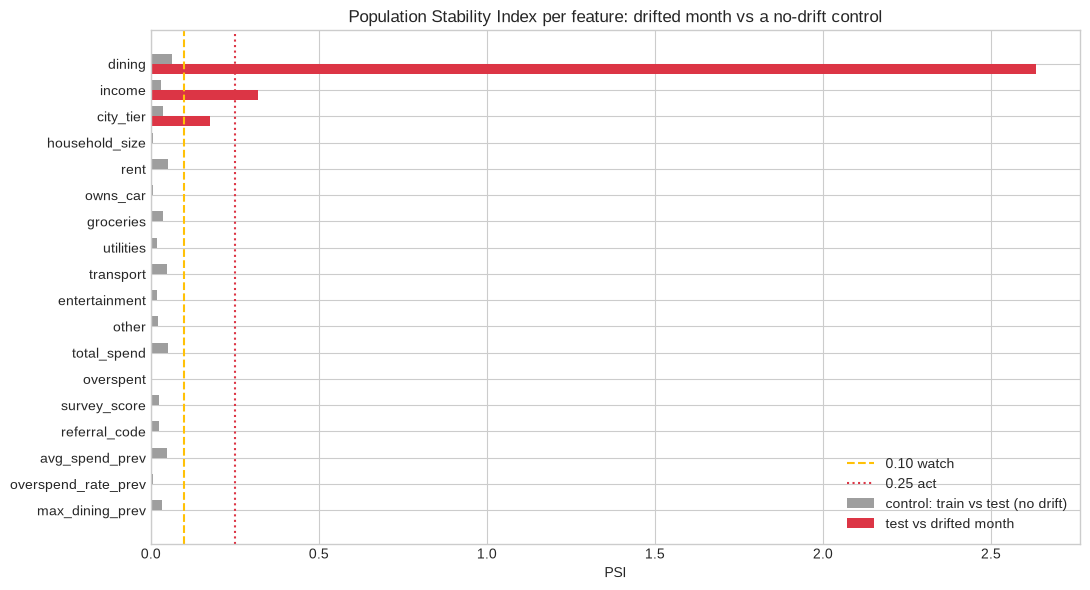

features at or above 0.10: ['dining', 'income', 'city_tier']  |  planted changes: ['income', 'dining', 'city_tier']
control PSI (no drift) maxes at 0.063 on dining: that is the noise floor for 375 rows


In [87]:
def psi(reference, current, bins=10, eps=1e-4):
    # Population Stability Index of one feature: reference quantile bins (or categories), current shares compared to reference shares.
    ref, cur = pd.Series(reference).dropna(), pd.Series(current).dropna()
    if ref.dtype == object or ref.dtype == bool or ref.nunique() <= 10:
        cats = sorted(set(ref.unique()) | set(cur.unique()), key=str)
        p = ref.value_counts(normalize=True).reindex(cats).fillna(0).values
        q = cur.value_counts(normalize=True).reindex(cats).fillna(0).values
    else:
        edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        p = np.histogram(ref, bins=edges)[0] / len(ref)
        q = np.histogram(cur, bins=edges)[0] / len(cur)
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    return float(np.sum((q - p) * np.log(q / p)))

psi_table = pd.DataFrame({
    "control: train vs test": [psi(train_df[f], test_df[f]) for f in FEATS_TAB],
    "test vs drifted month": [psi(test_df[f], drift_df[f]) for f in FEATS_TAB],
}, index=FEATS_TAB).sort_values("test vs drifted month", ascending=False)
psi_table["verdict"] = np.select([psi_table["test vs drifted month"] >= 0.25, psi_table["test vs drifted month"] >= 0.10], ["act", "watch"], "stable")
display(pretty(psi_table, highlight=None))

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(psi_table)); h = 0.38
ax.barh(y - h / 2, psi_table["control: train vs test"], h, color="#9e9e9e", label="control: train vs test (no drift)")
ax.barh(y + h / 2, psi_table["test vs drifted month"], h, color="#dc3545", label="test vs drifted month")
ax.axvline(0.10, color="#ffc107", ls="--", label="0.10 watch"); ax.axvline(0.25, color="#dc3545", ls=":", label="0.25 act")
ax.set_yticks(y); ax.set_yticklabels(psi_table.index); ax.invert_yaxis()
ax.set_xlabel("PSI"); ax.set_title("Population Stability Index per feature: drifted month vs a no-drift control"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

flagged = psi_table.index[psi_table["test vs drifted month"] >= 0.10].tolist()
print(f"features at or above 0.10: {flagged}  |  planted changes: {changed}")
print(f"control PSI (no drift) maxes at {psi_table['control: train vs test'].max():.3f} on {psi_table['control: train vs test'].idxmax()}: that is the noise floor for {len(test_df)} rows")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Red bars are the drifted month against the test set; grey bars are the control, train against test, where nothing drifted. The three planted changes stand out in red and the printed line confirms which features crossed 0.10. The grey bars are not zero: with a few hundred rows in ten bins, sampling noise alone produces a small PSI on every feature, and that floor is what a threshold must sit above. Features with `verdict == stable` moved less than the control did.

The common misread: treating a PSI of 0.10 as a law. On small samples the noise floor can approach it; on millions of rows a PSI of 0.02 can be a real, permanent shift. Calibrate the threshold on a no-drift control from your own data, as the grey bars do here.

</div>

## 21.3 The model's view of the drifted month

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

PSI watches the inputs. Two more signals need no labels either: the **distribution of the model's own predictions** (if the share of households flagged as likely to overspend halves overnight, either the world changed or the pipeline broke), and **permutation importance on the new rows** (a feature the model leans on differently than before). And when labels finally arrive, the last signal is the only one that counts: **performance** on the new month.

</div>


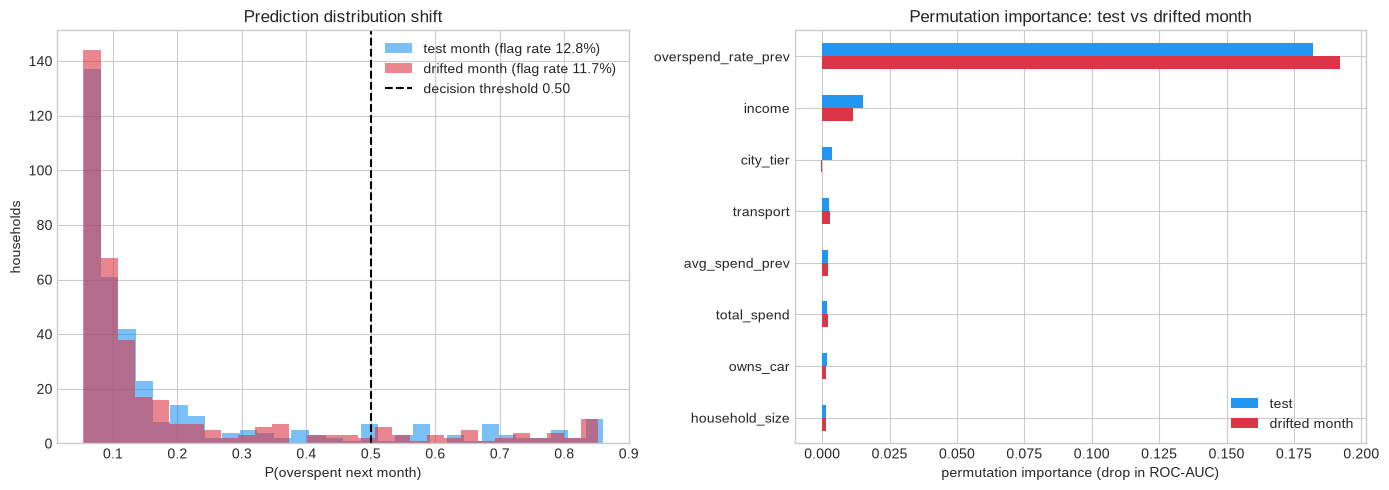

,roc_auc,pr_auc,log_loss,recall,precision
model,,,,,
test month,0.940,0.818,0.253,0.651,0.854
drifted month (labels arrived),0.938,0.809,0.255,0.587,0.841


mean predicted probability: test 0.200 -> drifted 0.190  |  flagged share: 12.8% -> 11.7%
ROC-AUC once labels arrive: 0.9402 -> 0.9383  |  recall: 0.651 -> 0.587


In [88]:
p_test = predictor.predict_proba(test_df[FEATS_TAB])[1].values
p_drift = predictor.predict_proba(drift_df[FEATS_TAB])[1].values
thr = predictor.decision_threshold

fi_test = predictor.feature_importance(test_df, num_shuffle_sets=3, silent=True)["importance"]
fi_drift = predictor.feature_importance(drift_df, num_shuffle_sets=3, silent=True)["importance"]
fi = pd.DataFrame({"test": fi_test, "drifted month": fi_drift}).fillna(0)
fi = fi.loc[fi.abs().max(axis=1).sort_values(ascending=False).index[:8]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(p_test, bins=30, alpha=0.6, color="#2196F3", label=f"test month (flag rate {np.mean(p_test >= thr):.1%})")
axes[0].hist(p_drift, bins=30, alpha=0.6, color="#dc3545", label=f"drifted month (flag rate {np.mean(p_drift >= thr):.1%})")
axes[0].axvline(thr, color="k", ls="--", label=f"decision threshold {thr:.2f}")
axes[0].set_xlabel("P(overspent next month)"); axes[0].set_ylabel("households"); axes[0].set_title("Prediction distribution shift"); axes[0].legend()
fi.plot.barh(ax=axes[1], color=["#2196F3", "#dc3545"]); axes[1].invert_yaxis()
axes[1].set_xlabel("permutation importance (drop in ROC-AUC)"); axes[1].set_title("Permutation importance: test vs drifted month"); axes[1].legend()
plt.tight_layout(); plt.show()

perf = pd.concat([report_card(y_test, (p_test >= thr).astype(int), p_test, name="test month"),
                  report_card(y_test, (p_drift >= thr).astype(int), p_drift, name="drifted month (labels arrived)")])
display(pretty(perf[["roc_auc", "pr_auc", "log_loss", "recall", "precision"]]))
print(f"mean predicted probability: test {p_test.mean():.3f} -> drifted {p_drift.mean():.3f}  |  flagged share: {np.mean(p_test >= thr):.1%} -> {np.mean(p_drift >= thr):.1%}")
print(f"ROC-AUC once labels arrive: {perf.roc_auc.iloc[0]:.4f} -> {perf.roc_auc.iloc[1]:.4f}  |  recall: {perf.recall.iloc[0]:.3f} -> {perf.recall.iloc[1]:.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the model's probabilities on the drifted month sit lower than on the test month. A 20% raise makes every household look safer to a model that learned "overspending is spending relative to income", and the share of households above the decision threshold falls; the legend prints both flag rates. That drop is observable on day one, with no labels. Right: permutation importance recomputed on the drifted rows. Bars that change length between blue and red are features the model uses in a way the drift disturbed.

The table underneath is the part that arrives a month late. Because the labels were kept from the undrifted month, the model's ranking is scored against outcomes its inputs no longer describe, and ROC-AUC and recall move; the printed line gives the numbers for this run.

The common misread: waiting for the performance drop before acting. The flag-rate shift and the PSI table were both visible before any label existed.

</div>

## 21.4 A monitoring loop with a retrain trigger

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 The checklist, in the order the signals arrive

| Stage | Question | Signal | Needs labels? | Action |
|---|---|---|---|---|
| 1. Data quality | Did the schema or missingness change? | column set, dtypes, missing rate per column | no | fix the pipeline before anything else |
| 2. Input drift | Do the features still look like training? | PSI per feature against a no-drift control | no | investigate features above the control floor |
| 3. Prediction drift | Does the model say the same things? | mean probability, flag rate | no | alert on a shift larger than the control |
| 4. Performance | Is it still right? | ROC-AUC, recall, log loss on labelled rows | yes | compare to the manifest's departure score |
| 5. Retrain | Is retraining justified? | any of 2-4 past its threshold for two periods | - | fit on fresh rows, ship the clone, update the manifest |

</div>

The function below turns that table into code: it takes a reference set, the new month, the predictor and (optionally) labels, and returns one row per check with a verdict. The final line is the retrain decision.


In [89]:
def monitoring_report(reference, current, predictor, labels=None, features=FEATS_TAB, psi_watch=0.10, baseline_auc=None, auc_drop=0.02):
    # One row per monitoring check, with the measured value and a verdict; the retrain decision is the last row.
    rows = []
    # 1. data quality: schema and missingness
    missing_cols = [f for f in features if f not in current.columns]
    miss_ref, miss_cur = reference[features].isna().mean(), current[features].isna().mean()
    worst = (miss_cur - miss_ref).abs().idxmax()
    rows.append(("data quality: schema", f"{len(missing_cols)} missing columns", "✅" if not missing_cols else "⚠️"))
    rows.append(("data quality: missingness", f"largest change {worst}: {miss_ref[worst]:.1%} -> {miss_cur[worst]:.1%}", "✅" if abs(miss_cur[worst] - miss_ref[worst]) < 0.05 else "⚠️"))
    # 2. input drift: PSI
    psis = pd.Series({f: psi(reference[f], current[f]) for f in features})
    drifted = psis[psis >= psi_watch].index.tolist()
    rows.append(("input drift: PSI", f"{len(drifted)} features >= {psi_watch}: {drifted}", "✅" if not drifted else "⚠️"))
    # 3. prediction drift
    p_ref, p_cur = predictor.predict_proba(reference[features])[1].values, predictor.predict_proba(current[features])[1].values
    thr = predictor.decision_threshold
    rows.append(("prediction drift: flag rate", f"{np.mean(p_ref >= thr):.1%} -> {np.mean(p_cur >= thr):.1%}", "✅" if abs(np.mean(p_cur >= thr) - np.mean(p_ref >= thr)) < 0.05 else "⚠️"))
    # 4. performance, only when labels exist
    if labels is not None:
        auc = roc_auc_score(labels, p_cur); base = baseline_auc if baseline_auc is not None else roc_auc_score(reference[LABEL_CLS], p_ref)
        rows.append(("performance: ROC-AUC", f"{base:.4f} -> {auc:.4f}", "✅" if base - auc < auc_drop else "⚠️"))
    else:
        rows.append(("performance: ROC-AUC", "labels not yet available", "⏳"))
    # 5. decision
    n_warn = sum(1 for r in rows if r[2] == "⚠️")
    rows.append(("RETRAIN?", f"{n_warn} checks raised a warning", "🔁 retrain" if n_warn >= 2 else "✅ keep serving"))
    return pd.DataFrame(rows, columns=["check", "measured", "verdict"]).set_index("check")

print("=== new month, labels not yet available ===")
display(monitoring_report(test_df, drift_df, predictor))
print("\n=== same month once labels arrive ===")
report_labelled = monitoring_report(test_df, drift_df, predictor, labels=drift_df[LABEL_CLS].values, baseline_auc=manifest["test_roc_auc"])
display(report_labelled)
print(f"decision: {report_labelled.loc['RETRAIN?', 'verdict']}  ({report_labelled.loc['RETRAIN?', 'measured']})")


=== new month, labels not yet available ===


,measured,verdict
check,,
data quality: schema,0 missing columns,✅
data quality: missingness,largest change city_tier: 0.0% -> 0.0%,✅
input drift: PSI,"3 features >= 0.1: ['city_tier', 'income', 'dining']",⚠️
prediction drift: flag rate,12.8% -> 11.7%,✅
performance: ROC-AUC,labels not yet available,⏳
RETRAIN?,1 checks raised a warning,✅ keep serving



=== same month once labels arrive ===


,measured,verdict
check,,
data quality: schema,0 missing columns,✅
data quality: missingness,largest change city_tier: 0.0% -> 0.0%,✅
input drift: PSI,"3 features >= 0.1: ['city_tier', 'income', 'dining']",⚠️
prediction drift: flag rate,12.8% -> 11.7%,✅
performance: ROC-AUC,0.9388 -> 0.9383,✅
RETRAIN?,1 checks raised a warning,✅ keep serving


decision: ✅ keep serving  (1 checks raised a warning)


## 21.5 Retraining: `fit_extra` versus a fresh `fit`

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

AutoGluon offers two ways to change a trained predictor without starting over. `predictor.fit_extra(hyperparameters=..., time_limit=...)` trains **additional model families** on the training data the predictor already stores, and refits the weighted ensemble to include them. `predictor.refit_full(train_data_extra=new_rows)` refits the existing models on the stored data **plus** new labelled rows. Neither one replaces the training data, so neither is the answer to drift: the answer to drift is a fresh `fit` on fresh rows. `fit_extra` is shown below because it is the cheap fix when the problem is the model (a family that was never tried), not the data.

</div>


In [90]:
before = set(predictor.model_names())
with timer("fit_extra: add an ExtraTrees family (15 s budget)"):
    predictor.fit_extra(hyperparameters={"XT": {}}, time_limit=15, num_cpus=SAFE_N_CPUS)
added = sorted(set(predictor.model_names()) - before)
predictor.persist()
lb_after = predictor.leaderboard(test_df, silent=True).set_index("model")
print(f"models added by fit_extra: {added}")
print(f"best model now: {predictor.model_best}  (test ROC-AUC {lb_after.loc[predictor.model_best, 'score_test']:.4f})")
print("for drift, retrain instead:  TabularPredictor(label=..., path=new_dir).fit(fresh_rows, ...)  then  clone_for_deployment(...)  and rewrite manifest.json")


⏱️ fit_extra: add an ExtraTrees family (15 s budget): 1.42 s


models added by fit_extra: ['ExtraTrees', 'WeightedEnsemble_2_L2']
best model now: WeightedEnsemble_L2_FULL  (test ROC-AUC 0.9402)
for drift, retrain instead:  TabularPredictor(label=..., path=new_dir).fit(fresh_rows, ...)  then  clone_for_deployment(...)  and rewrite manifest.json


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `fit_extra` re-uses the stored training data and the stored validation split

The models it adds are scored on the same validation rows as the originals, and the new ensemble is chosen on them too. That is consistent, and it means a drifted month never enters the picture. If the monitoring report said retrain, `fit_extra` is the wrong tool; it only helps when the leaderboard was missing a family worth trying.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: log the three label-free signals every period

PSI per feature, the flag rate, and the mean probability cost nothing and arrive with the data. Store them per period next to `manifest.json`, and alert when a value leaves the band the no-drift control established. Performance metrics join the log when labels arrive, and the retrain decision looks at the whole log, not at one month.

</div>

## 21.6 Task 21 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Data drift is visible in the inputs on day one; concept drift is visible only when labels arrive. Monitor both.
- PSI per feature is a ten-line function; its threshold must sit above the noise floor that a no-drift control (train vs test) reveals.
- The model's own prediction distribution (mean probability, flag rate) is a label-free alarm; the drifted month lowered both here.
- Permutation importance on new rows shows which features the drift disturbed.
- `fit_extra` adds model families on the stored data; `refit_full(train_data_extra=...)` adds rows to the refit; drift needs a fresh `fit` and a new deployment clone.

</div>

### 🔑 New variables

| Variable | Type | Meaning |
|---|---|---|
| `drift_df`, `changed` | DataFrame, list | the manufactured drifted month and the three columns changed on purpose |
| `psi`, `psi_table` | function, DataFrame | PSI per feature, drifted month vs a no-drift control, with verdicts |
| `p_test`, `p_drift`, `fi`, `perf` | arrays, DataFrames | probabilities on both months, importance side by side, performance once labels arrive |
| `monitoring_report`, `report_labelled` | function, DataFrame | the five-stage checklist as code, and its output once labels exist |
| `added`, `lb_after` | list, DataFrame | the models `fit_extra` added and the leaderboard afterwards |

### ➡️ Next Up

Part 10 turns the same predictor on itself: where it fails, for whom, and whether more data, cleaner labels or a different model would fix it.


# Part 10 · Error Analysis and Diagnostics ⭐⭐

<div style="background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The score is not the story

Part 10 keeps the predictor from Part 9 and asks the questions a single ROC-AUC cannot answer. **Where** does it fail: which rows, which segments, and are its probabilities honest there? **Why** does it fail: too little data (variance), the wrong model (bias), or noisy labels? And **is the dataset itself sound**: duplicates, leakage between splits, a feature that is secretly the label? Every check is a few lines of code, and the Part ends with one table of verdicts.

</div>

| Task | Question | Tools |
|:----:|----------|-------|
| 22 | where and why it fails | confusion matrix, hardest errors, segments, calibration by segment, learning curve |
| 23 | is the data sound | label-noise refit, duplicates, split overlap, correlation sanity, base-rate check, the diagnostic table |


# Task 22 · Where It Fails

## 22.1 The confusion matrix at the deployed threshold

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

ROC-AUC scores the ranking of probabilities. A decision needs a **threshold**, and once there is a threshold there are four kinds of outcome: true positive, false positive, false negative, true negative. For an overspend warning, a **false negative** (a household that overspends and was not warned) is the expensive mistake; a **false positive** is a warning nobody needed. The matrix counts all four; the rest of this Task looks inside the two mistake cells.

</div>


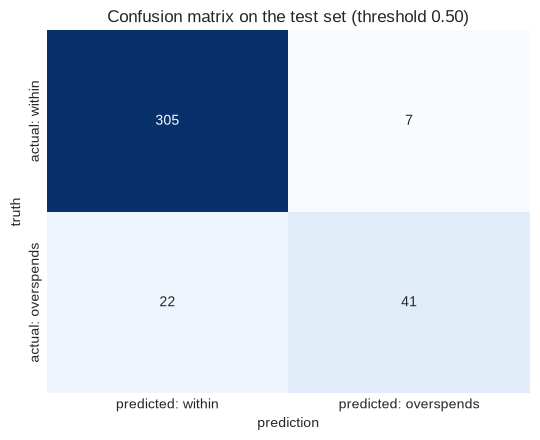

TP 41  FP 7  FN 22  TN 305   |  recall 0.651  precision 0.854  |  22 of 63 overspenders were missed


In [91]:
from sklearn.metrics import confusion_matrix
from sklearn.calibration import calibration_curve

thr = predictor.decision_threshold
p_hat = predictor.predict_proba(test_df[FEATS_TAB])[1].values
y_hat = (p_hat >= thr).astype(int)
cm = confusion_matrix(y_test, y_hat)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["predicted: within", "predicted: overspends"], yticklabels=["actual: within", "actual: overspends"])
ax.set_title(f"Confusion matrix on the test set (threshold {thr:.2f})"); ax.set_xlabel("prediction"); ax.set_ylabel("truth")
plt.tight_layout(); plt.show()

errors = test_df[FEATS_TAB + [LABEL_CLS]].copy()
errors["p_overspend"] = p_hat; errors["predicted"] = y_hat
errors["kind"] = np.select([(y_test == 1) & (y_hat == 0), (y_test == 0) & (y_hat == 1)], ["false negative", "false positive"], "correct")
print(f"TP {tp}  FP {fp}  FN {fn}  TN {tn}   |  recall {tp / (tp + fn):.3f}  precision {tp / (tp + fp):.3f}  |  {fn} of {tp + fn} overspenders were missed")


## 22.2 The hardest mistakes

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Not all mistakes are equal. A false negative at probability 0.48 was a near miss; one at 0.05 means the model was **confidently wrong**, and confident mistakes are where labels, features or the generator's surprises are usually hiding. The two tables rank the mistakes by confidence and show the features next to the probability, so you can read what the model saw.

</div>


In [92]:
show_cols = ["p_overspend", "income", "total_spend", "overspent", "overspend_rate_prev", "avg_spend_prev", "dining", "other", "city_tier", "household_size"]
hard_fn = errors[errors.kind == "false negative"].sort_values("p_overspend").head(5)
hard_fp = errors[errors.kind == "false positive"].sort_values("p_overspend", ascending=False).head(5)

print("Hardest FALSE NEGATIVES: overspent next month, lowest predicted probability")
display(pretty(hard_fn[show_cols], fmt="{:,.2f}", highlight=None))
print("\nHardest FALSE POSITIVES: stayed within budget, highest predicted probability")
display(pretty(hard_fp[show_cols], fmt="{:,.2f}", highlight=None))

ratio_fn = (hard_fn.total_spend / hard_fn.income).mean(); ratio_all_pos = (errors[errors[LABEL_CLS] == 1].total_spend / errors[errors[LABEL_CLS] == 1].income).mean()
print(f"\nhardest FNs: this month's spend/income = {ratio_fn:.2f} on average vs {ratio_all_pos:.2f} for all overspenders  |  their overspend_rate_prev = {hard_fn.overspend_rate_prev.mean():.2f}")
print(f"hardest FPs: overspend_rate_prev = {hard_fp.overspend_rate_prev.mean():.2f}, this month's spend/income = {(hard_fp.total_spend / hard_fp.income).mean():.2f}")


Hardest FALSE NEGATIVES: overspent next month, lowest predicted probability


,p_overspend,income,total_spend,overspent,overspend_rate_prev,avg_spend_prev,dining,other,city_tier,household_size
88,0.07,"4,632.00","1,964.00",0.00,0.00,"1,940.59",281.00,27.00,town,2.00
324,0.12,"3,641.00","2,338.00",0.00,0.05,"2,160.36",215.00,73.00,metro,2.00
318,0.14,"4,054.00","1,969.00",0.00,0.14,"2,217.14",109.00,18.00,town,4.00
123,0.14,"3,774.00","1,851.00",0.00,0.14,"2,059.27",132.00,83.00,town,3.00
316,0.15,"2,761.00","1,215.00",0.00,0.23,"1,597.09",72.00,51.00,town,1.00



Hardest FALSE POSITIVES: stayed within budget, highest predicted probability


,p_overspend,income,total_spend,overspent,overspend_rate_prev,avg_spend_prev,dining,other,city_tier,household_size
169,0.76,"3,869.00","2,554.00",1.00,0.86,"2,695.95",93.00,26.00,metro,5.00
172,0.71,"2,860.00","2,087.00",1.00,0.82,"2,056.82",191.00,151.00,city,3.00
267,0.67,"2,083.00","1,514.00",1.00,0.95,"1,602.23",92.00,118.00,town,4.00
196,0.58,"3,171.00","1,869.00",0.00,0.64,"2,096.09",49.00,73.00,town,5.00
213,0.58,"3,628.00","1,787.00",0.00,0.59,"2,118.14",30.00,4.00,town,5.00



hardest FNs: this month's spend/income = 0.50 on average vs 0.67 for all overspenders  |  their overspend_rate_prev = 0.11
hardest FPs: overspend_rate_prev = 0.77, this month's spend/income = 0.64


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The hardest false negatives are households whose history looks safe: a low spend-to-income ratio this month and a low past overspend rate, printed under the table. They overspent next month anyway, and the generator's 6% chance of a surprise expense (a large `other` next month) is the kind of event no feature from this month can see. The hardest false positives are the mirror image: households with a history of overspending who stayed within budget once.

The common misread: calling these rows "model errors" and looking for a better model. Some of them are **irreducible** under these features: no model can predict a surprise from data collected before it. The fix, when there is one, is a new feature or an honest confidence interval, not a bigger ensemble.

</div>

## 22.3 Error rate by segment

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

One aggregate score can hide a model that works for metro households and fails for towns. **Slicing** the test set by a categorical feature and recomputing the metrics per slice is the simplest fairness and robustness check there is. The per-slice base rate matters too: a slice where 30% overspend is harder than one where 10% do, and recall is the fair comparison.

</div>


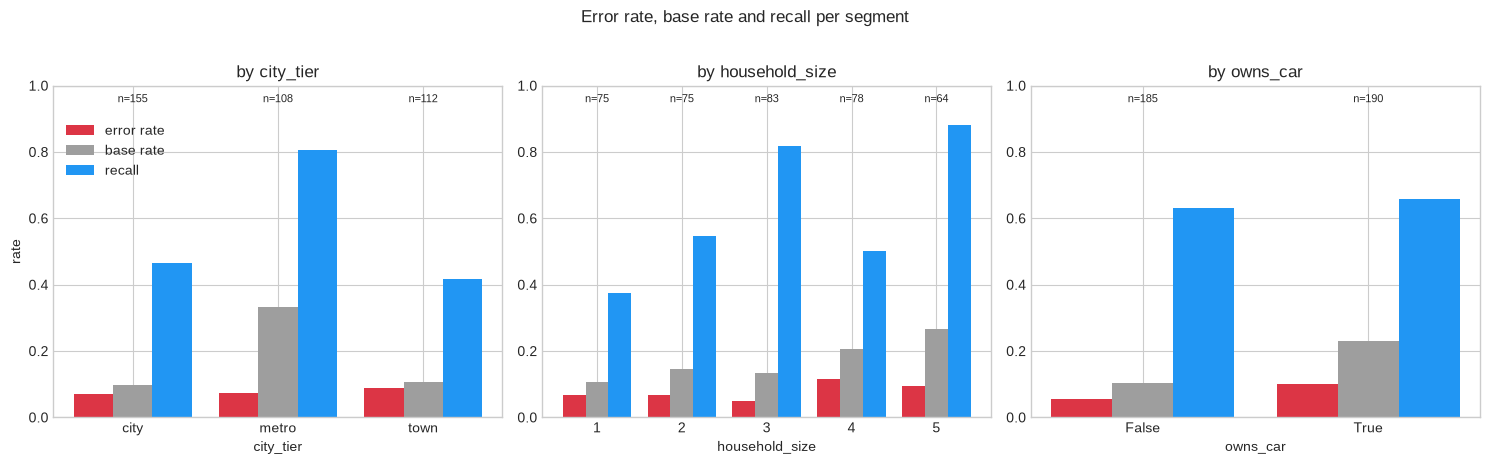

,n,base_rate,error_rate,recall,precision,roc_auc
city_tier,,,,,,
city,155.000,0.097,0.071,0.467,0.700,0.953
metro,108.000,0.333,0.074,0.806,0.967,0.960
town,112.000,0.107,0.089,0.417,0.625,0.849


,n,base_rate,error_rate,recall,precision,roc_auc
household_size,,,,,,
1,75.000,0.107,0.067,0.375,1.000,0.987
2,75.000,0.147,0.067,0.545,1.000,0.899
3,83.000,0.133,0.048,0.818,0.818,0.962
4,78.000,0.205,0.115,0.500,0.889,0.868
5,64.000,0.266,0.094,0.882,0.789,0.977


,n,base_rate,error_rate,recall,precision,roc_auc
owns_car,,,,,,
False,185.000,0.103,0.054,0.632,0.800,0.922
True,190.000,0.232,0.100,0.659,0.879,0.940


recall ranges from 0.38 (household_size = 1) to 0.38 (household_size = 1); overall recall 0.65


In [93]:
def segment_table(df, y, p, col, thr):
    # Per-segment counts, base rate, error rate, recall, precision and ROC-AUC (NaN when a segment has one class only).
    rows = []
    for val, idx in df.groupby(col).indices.items():
        yy, pp = y[idx], p[idx]; yh = (pp >= thr).astype(int)
        rows.append({col: val, "n": len(idx), "base_rate": yy.mean(), "error_rate": (yh != yy).mean(),
                     "recall": recall_score(yy, yh, zero_division=0), "precision": precision_score(yy, yh, zero_division=0),
                     "roc_auc": roc_auc_score(yy, pp) if len(np.unique(yy)) == 2 else np.nan})
    return pd.DataFrame(rows).set_index(col)

SEGMENTS = ["city_tier", "household_size", "owns_car"]
seg_tables = {c: segment_table(test_df, y_test, p_hat, c, thr) for c in SEGMENTS}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, SEGMENTS):
    t = seg_tables[c]
    x = np.arange(len(t)); w = 0.27
    ax.bar(x - w, t.error_rate, w, color="#dc3545", label="error rate")
    ax.bar(x, t.base_rate, w, color="#9e9e9e", label="base rate")
    ax.bar(x + w, t.recall, w, color="#2196F3", label="recall")
    ax.set_xticks(x); ax.set_xticklabels([str(v) for v in t.index]); ax.set_title(f"by {c}"); ax.set_ylim(0, 1); ax.set_xlabel(c)
    for xi, n in zip(x, t.n):
        ax.text(xi, 0.95, f"n={n}", ha="center", fontsize=8)
axes[0].set_ylabel("rate"); axes[0].legend(loc="upper left", bbox_to_anchor=(0, 0.92))
fig.suptitle("Error rate, base rate and recall per segment", y=1.02)
plt.tight_layout(); plt.show()

for c in SEGMENTS:
    display(pretty(seg_tables[c], highlight=None))
worst = max(((c, v, t.loc[v, "recall"]) for c, t in seg_tables.items() for v in t.index), key=lambda z: -z[2])
lowest = min(((c, v, t.loc[v, "recall"]) for c, t in seg_tables.items() for v in t.index), key=lambda z: z[2])
print(f"recall ranges from {lowest[2]:.2f} ({lowest[0]} = {lowest[1]}) to {worst[2]:.2f} ({worst[0]} = {worst[1]}); overall recall {tp / (tp + fn):.2f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three slicings of the same test set. The grey bars (base rate) differ across slices because the generator ties rent to city tier and groceries to household size, so some slices overspend more often. The red bars (error rate) should be compared to the grey ones: an error rate below the base rate means the model beats "predict nobody overspends" on that slice. The blue bars (recall) are the number to watch for the expensive mistake, and the printed line gives their range. The `n=` labels matter: a slice of thirty households has a recall that moves by a few points when one household changes side.

The common misread: reading a low error rate on a slice as a good model for that slice. On a slice with a 10% base rate, predicting "within budget" for everyone scores 90% accuracy and 0% recall.

</div>

## 22.4 Calibration by segment

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A probability of 0.3 should mean "three in ten such households overspend", and it should mean it for every city tier. A **reliability diagram** groups predictions into bins and plots the observed rate against the predicted rate; the diagonal is perfect calibration. Drawing one curve per segment shows whether the model is honest everywhere or only on average. The **expected calibration error** (ECE) is the bin-weighted mean gap between the two.

</div>

### 📐 The Math (gently)

$$ \text{ECE} = \sum_{b=1}^{B} \frac{n_b}{n}\,\Big| \overline{y}_b - \overline{p}_b \Big| $$

where bin $b$ holds $n_b$ rows with mean label $\overline{y}_b$ and mean predicted probability $\overline{p}_b$.


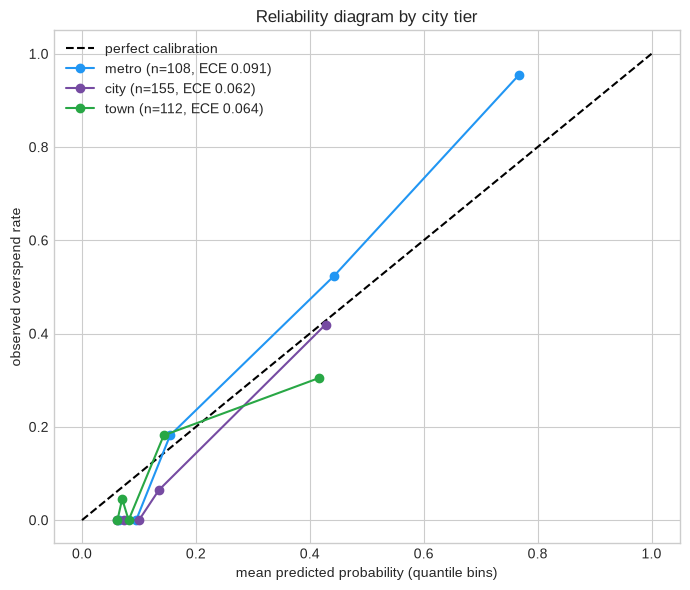

,n,ECE
segment,,
all,375,0.054
metro,108,0.091
city,155,0.062
town,112,0.064


overall ECE 0.054; worst tier metro at 0.091


In [94]:
def ece(y, p, n_bins=5):
    # Expected calibration error with quantile bins (equal-count bins keep every bin populated on small segments).
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1)); idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, n_bins - 1)
    return float(sum(np.mean(idx == b) * abs(y[idx == b].mean() - p[idx == b].mean()) for b in range(n_bins) if np.any(idx == b)))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
cal_rows = [{"segment": "all", "n": len(y_test), "ECE": ece(y_test, p_hat)}]
for tier, color in zip(["metro", "city", "town"], ["#2196F3", "#764ba2", "#28a745"]):
    m = (test_df.city_tier == tier).values
    frac, mean_p = calibration_curve(y_test[m], p_hat[m], n_bins=5, strategy="quantile")
    ax.plot(mean_p, frac, "o-", color=color, label=f"{tier} (n={m.sum()}, ECE {ece(y_test[m], p_hat[m]):.3f})")
    cal_rows.append({"segment": tier, "n": int(m.sum()), "ECE": ece(y_test[m], p_hat[m])})
ax.set_xlabel("mean predicted probability (quantile bins)"); ax.set_ylabel("observed overspend rate"); ax.set_title("Reliability diagram by city tier")
ax.legend(); plt.tight_layout(); plt.show()

cal_table = pd.DataFrame(cal_rows).set_index("segment")
display(pretty(cal_table, highlight="min", subset=["ECE"]))
print(f"overall ECE {cal_table.loc['all', 'ECE']:.3f}; worst tier {cal_table.ECE.iloc[1:].idxmax()} at {cal_table.ECE.iloc[1:].max():.3f}")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Each curve is one city tier; each point is one fifth of that tier's households, placed at their mean predicted probability (x) and their actual overspend rate (y). Points above the diagonal are bins where the model was under-confident (more overspending than it said); below, over-confident. With roughly a hundred households per tier, each point summarises about twenty rows, so a gap of a few points is noise and a consistent offset across bins is a calibration problem. The ECE table ranks the tiers.

The common misread: judging calibration from the overall curve alone. A model can be calibrated on average while being over-confident for one segment and under-confident for another, and the two cancel.

</div>

## 22.5 The learning curve: bias or variance?

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: what would fix it?

Fit the same recipe on 200, 500 and all training rows, and score each fit on the rows it trained on and on the test set. The gap between the two curves is **variance** (the model memorises what it saw and the rest does not generalise); it shrinks as data grows. The height the test curve is converging to is limited by **bias** (what the model family plus these features cannot express) and by **label noise** (what nothing can express). If the test curve is still rising at the last point, more data is the cheapest fix. If it has flattened, more data will not help; better features or a different model might.

</div>

Each fit gets 20 s; three fits run below.


⏱️ learning curve: 3 fits x 20 s: 54.88 s


,roc_auc_train,roc_auc_test,gap,best_model
n_train,,,,
200,0.993,0.919,0.074,WeightedEnsemble_L2
500,0.990,0.933,0.057,WeightedEnsemble_L2
1125,0.958,0.939,0.019,WeightedEnsemble_L2


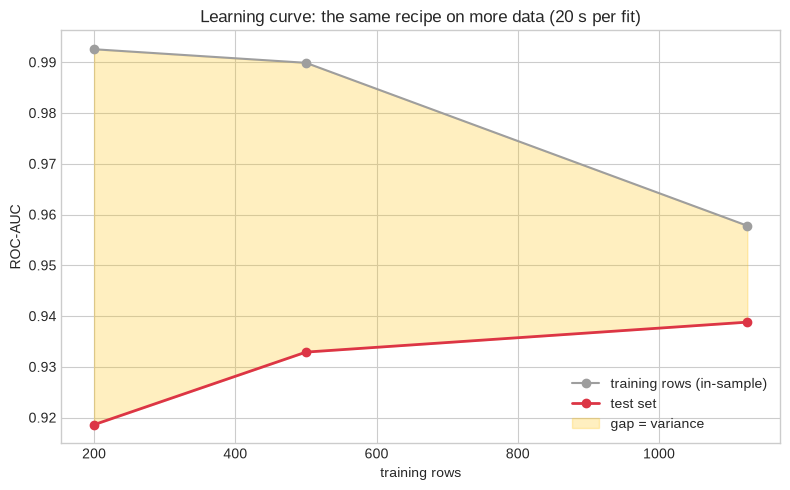

test ROC-AUC 0.919 -> 0.939; gap 0.074 -> 0.019
last step (500 -> 1125 rows) added +0.0059 ROC-AUC: still rising, more data would help


In [95]:
SCRATCH_DIRS = []

def quick_fit(df, time_limit=20, tag="lc"):
    # The same recipe as Part 9's predictor on a smaller budget; every directory is recorded for cleanup.
    d = tempfile.mkdtemp(prefix=f"ag_{tag}_"); SCRATCH_DIRS.append(d)
    return TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=d, verbosity=0).fit(
        df[FEATS_TAB + [LABEL_CLS]], time_limit=time_limit, presets="medium_quality", num_cpus=SAFE_N_CPUS)

sizes_lc = [200, 500, len(train_df)]
learning_curve, lc_predictors = [], {}
with timer(f"learning curve: {len(sizes_lc)} fits x 20 s"):
    for n in sizes_lc:
        sub = train_df if n == len(train_df) else train_test_split(train_df, train_size=n, stratify=train_df[LABEL_CLS], random_state=RANDOM_STATE)[0]
        p = quick_fit(sub); lc_predictors[n] = p
        auc_train = roc_auc_score(sub[LABEL_CLS], p.predict_proba(sub[FEATS_TAB])[1])
        auc_test = roc_auc_score(y_test, p.predict_proba(test_df[FEATS_TAB])[1])
        learning_curve.append({"n_train": n, "roc_auc_train": auc_train, "roc_auc_test": auc_test, "gap": auc_train - auc_test, "best_model": p.model_best})
learning_curve = pd.DataFrame(learning_curve).set_index("n_train")
display(pretty(learning_curve, highlight=None))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(learning_curve.index, learning_curve.roc_auc_train, "o-", color="#9e9e9e", label="training rows (in-sample)")
ax.plot(learning_curve.index, learning_curve.roc_auc_test, "o-", color="#dc3545", lw=2, label="test set")
ax.fill_between(learning_curve.index, learning_curve.roc_auc_test, learning_curve.roc_auc_train, color="#ffc107", alpha=0.25, label="gap = variance")
ax.set_xlabel("training rows"); ax.set_ylabel("ROC-AUC"); ax.set_title("Learning curve: the same recipe on more data (20 s per fit)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

rise = learning_curve.roc_auc_test.iloc[-1] - learning_curve.roc_auc_test.iloc[-2]
print(f"test ROC-AUC {learning_curve.roc_auc_test.iloc[0]:.3f} -> {learning_curve.roc_auc_test.iloc[-1]:.3f}; gap {learning_curve.gap.iloc[0]:.3f} -> {learning_curve.gap.iloc[-1]:.3f}")
print(f"last step ({sizes_lc[-2]} -> {sizes_lc[-1]} rows) added {rise:+.4f} ROC-AUC: " + ("still rising, more data would help" if rise > 0.005 else "flat, more data alone will not help"))


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The grey curve is scored on the rows each fit trained on (including the slice AutoGluon held out internally, so it is slightly less optimistic than a pure training score); the red curve is the test set. The yellow band between them is the variance component, widest at 200 rows and narrowing as rows are added. The red curve's slope at the last step is the answer to "would more data help": the printed line states it for this run. What the red curve cannot reach is the sum of bias and label noise; Task 23 measures the noise part directly.

The common misread: taking the training score as the model's ceiling. In-sample scores near 1.0 at 200 rows are memorisation, not skill.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: three points make a sketch, not a curve

Each fit has one random subsample and a 20 s budget, so each point carries a few thousandths of noise, and the small-data fits also had fewer models finish. A learning curve you would act on repeats each size with several seeds and reports the spread; the shape here is the lesson, not the third decimal.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: run the error analysis before the hyperparameter search

The hardest-mistakes table, the segment recall range and the learning-curve slope each point to a different fix (a missing feature, a segment that needs its own threshold, more rows). None of them is "tune the ensemble longer", and a longer search cannot repair any of them. Look at the errors first; Part 5's knobs are for the problems that remain.

</div>

## 22.6 Task 22 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- The confusion matrix at the deployed threshold names the expensive cell: missed overspenders (false negatives).
- The hardest false negatives have safe histories; part of the error is irreducible under this month's features (surprise expenses).
- Slicing by segment exposes recall ranges that the aggregate hides; compare error rate to the slice's base rate, not to zero.
- Calibration must hold per segment; ECE per tier makes the comparison one number.
- The learning curve separates variance (the gap, shrinking with data) from bias plus noise (the ceiling); its last slope says whether more data would help.

</div>

### 🔑 New variables

| Variable | Type | Meaning |
|---|---|---|
| `thr`, `p_hat`, `y_hat`, `cm` | float, arrays, matrix | the deployed threshold, test probabilities, decisions and confusion matrix |
| `errors`, `hard_fn`, `hard_fp` | DataFrames | every test row tagged by outcome; the five most confident mistakes of each kind |
| `segment_table`, `seg_tables`, `SEGMENTS` | function, dict, list | per-slice metrics for city tier, household size and car ownership |
| `ece`, `cal_table` | function, DataFrame | expected calibration error overall and per tier |
| `quick_fit`, `learning_curve`, `lc_predictors`, `SCRATCH_DIRS` | function, DataFrame, dict, list | the 20 s recipe, the curve at 200/500/all rows, its predictors and their directories |

### ➡️ Next Up

Task 23 checks the data rather than the model: how much label noise costs, whether the splits leak into each other, whether any feature is secretly the target, and whether the model beats the base rate on every segment, all summarised in one diagnostic table.


# Task 23 · The Diagnostics Checklist

## 23.1 How much do noisy labels cost?

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Labels come from people and pipelines, and both make mistakes. A direct way to measure a model's sensitivity is to **corrupt the training labels on purpose**: flip 10% of them at random, refit with the same recipe and budget, and score on the clean test set. The drop is the price of that much noise. A model that drops a little is robust; one that collapses was leaning on a few rows. The clean baseline is the all-rows fit from the learning curve, so the two fits differ only in their labels.

</div>


In [96]:
NOISE = 0.10
rng_noise = np.random.default_rng(RANDOM_STATE + 2)
noisy_train = train_df.copy()
flip = rng_noise.random(len(noisy_train)) < NOISE
noisy_train.loc[flip, LABEL_CLS] = 1 - noisy_train.loc[flip, LABEL_CLS]

with timer("refit on 10% flipped labels (20 s)"):
    noisy_predictor = quick_fit(noisy_train, tag="noise")

p_clean = lc_predictors[len(train_df)].predict_proba(test_df[FEATS_TAB])[1].values
p_noisy = noisy_predictor.predict_proba(test_df[FEATS_TAB])[1].values
noise_cards = pd.concat([report_card(y_test, (p_clean >= 0.5).astype(int), p_clean, name="clean labels (20 s)"),
                         report_card(y_test, (p_noisy >= 0.5).astype(int), p_noisy, name=f"{NOISE:.0%} labels flipped (20 s)")])
display(pretty(noise_cards[["roc_auc", "pr_auc", "log_loss", "brier", "recall", "f1"]]))
auc_drop = noise_cards.roc_auc.iloc[0] - noise_cards.roc_auc.iloc[1]
print(f"{flip.sum()} of {len(train_df)} training labels flipped; positive rate {train_df[LABEL_CLS].mean():.1%} -> {noisy_train[LABEL_CLS].mean():.1%}")
print(f"ROC-AUC drop from label noise: {auc_drop:+.4f}  |  log loss {noise_cards.log_loss.iloc[0]:.3f} -> {noise_cards.log_loss.iloc[1]:.3f}")


⏱️ refit on 10% flipped labels (20 s): 16.42 s


,roc_auc,pr_auc,log_loss,brier,recall,f1
model,,,,,,
clean labels (20 s),0.939,0.819,0.224,0.065,0.635,0.727
10% labels flipped (20 s),0.932,0.795,0.322,0.089,0.429,0.581


123 of 1125 training labels flipped; positive rate 16.8% -> 23.5%
ROC-AUC drop from label noise: +0.0067  |  log loss 0.224 -> 0.322


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Flipping one label in ten moves the positive rate up (most flips turn a 0 into a 1, since most rows are 0) and costs some ROC-AUC and more log loss. Ranking metrics survive symmetric noise fairly well because the flipped rows are spread evenly across the feature space; probabilistic metrics suffer more because the model learns to hedge. The printed drop is the number to keep: it is what 10% label error costs with this recipe on this data.

The common misread: assuming your labels are clean because nobody flipped them on purpose. Survey-based, rule-based and human-entered labels routinely carry noise in this range.

</div>

## 23.2 Duplicates, split overlap, correlation sanity, base rates

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Four cheap checks that catch expensive mistakes

1. **Duplicate rows** inflate a model's confidence in whatever the duplicate says, and if a duplicate straddles the split it leaks the answer.
2. **Train/test overlap** is the same leak by another route: the same household (or the same feature vector) on both sides of the split.
3. **Feature-target correlation** near 1 is the smoking gun of leakage (Part 4 showed it on purpose). A correlation that is high but explainable, such as this month's `overspent` with next month's, is a legitimate signal and should be understood, not deleted.
4. **Better than the base rate on every segment**: a model can beat the base rate overall and still be no better than a coin on one slice.

</div>


In [97]:
# 1. duplicate feature rows
dup_train = int(train_df.duplicated(subset=FEATS_TAB).sum())
dup_all = int(hh.duplicated(subset=FEATS_TAB).sum())

# 2. train/test overlap: by household id and by full feature vector
id_overlap = len(set(train_df[ID_COL]) & set(test_df[ID_COL]))
vec_overlap = len(train_df[FEATS_TAB].merge(test_df[FEATS_TAB].drop_duplicates(), how="inner", on=FEATS_TAB))

# 3. feature-target correlation sanity (numeric features and the binary target)
num_feats = [f for f in FEATS_TAB if np.issubdtype(hh[f].dtype, np.number) or hh[f].dtype == bool]
corr_target = hh[num_feats].astype(float).corrwith(hh[LABEL_CLS].astype(float)).abs().sort_values(ascending=False)
suspicious = corr_target[corr_target > 0.9].index.tolist()

# 4. better than base rate on every segment (AUC above 0.5 and precision above the slice's base rate)
seg_check = pd.concat([t.set_index(pd.Index([f"{c}={v}" for v in t.index], name="segment")) for c, t in seg_tables.items()])
seg_check["beats_base_rate"] = (seg_check.roc_auc > 0.5) & (seg_check.precision > seg_check.base_rate)
failing_segments = seg_check.index[~seg_check.beats_base_rate].tolist()

print(f"1. duplicate feature rows: train {dup_train}, whole table {dup_all}")
print(f"2. train/test overlap: {id_overlap} household ids, {vec_overlap} identical feature vectors")
print(f"3. |corr(feature, {LABEL_CLS})| top 5:")
print(corr_target.head(5).round(3).to_string())
print(f"   features above 0.9 (leakage suspects): {suspicious if suspicious else 'none'}")
print(f"4. segments where the model does not beat the base rate: {failing_segments if failing_segments else 'none'} ({int(seg_check.beats_base_rate.sum())}/{len(seg_check)} pass)")


1. duplicate feature rows: train 0, whole table 0
2. train/test overlap: 0 household ids, 0 identical feature vectors
3. |corr(feature, overspent_next)| top 5:
overspend_rate_prev    0.703
overspent              0.495
income                 0.409
rent                   0.278
avg_spend_prev         0.199
   features above 0.9 (leakage suspects): none
4. segments where the model does not beat the base rate: none (10/10 pass)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the strongest correlation is not a leak here, but it would be in a lookalike dataset

`overspend_rate_prev` and `overspent` top the correlation list because a household's history predicts its future; both are known before next month begins, so they are legitimate. The identical numbers in a dataset where `overspent` had been computed *from* next month's total would be a leak. The correlation cannot tell the two apart; only the data dictionary and the timestamp of each column can. Ask "when was this column known?" for every feature above the line.

</div>

## 23.3 The diagnostic table

Every check in Parts 9 and 10 that has a threshold, computed once more and summarised with a verdict: ✅ nothing to do, ⚠️ act.


In [98]:
checks = [
    ("class balance: train vs test positive rate", f"{train_df[LABEL_CLS].mean():.1%} vs {test_df[LABEL_CLS].mean():.1%}", abs(train_df[LABEL_CLS].mean() - test_df[LABEL_CLS].mean()) < 0.02),
    ("duplicate feature rows in train", f"{dup_train}", dup_train == 0),
    ("train/test overlap (ids, feature vectors)", f"{id_overlap}, {vec_overlap}", id_overlap == 0 and vec_overlap == 0),
    ("feature-target |corr| > 0.9 (leakage suspects)", f"{len(suspicious)} features, max {corr_target.max():.3f}", len(suspicious) == 0),
    ("beats base rate on every segment", f"{int(seg_check.beats_base_rate.sum())}/{len(seg_check)} segments", not failing_segments),
    ("recall on the weakest segment", f"{seg_check.recall.min():.2f} ({seg_check.recall.idxmin()})", seg_check.recall.min() >= 0.5),
    ("calibration: worst-tier ECE", f"{cal_table.ECE.iloc[1:].max():.3f} ({cal_table.ECE.iloc[1:].idxmax()})", cal_table.ECE.iloc[1:].max() < 0.08),
    ("learning curve: flat at the last step", f"{rise:+.4f} ROC-AUC for the last {sizes_lc[-1] - sizes_lc[-2]} rows", rise <= 0.005),
    ("label-noise sensitivity (10% flipped)", f"{auc_drop:+.4f} ROC-AUC", auc_drop < 0.05),
    ("drift: features past the PSI watch line on the drifted month", f"{len(flagged)}: {flagged}", len(flagged) == 0),
]
diag = pd.DataFrame([(name, value, "✅" if ok else "⚠️") for name, value, ok in checks], columns=["check", "measured", "verdict"]).set_index("check")
display(diag)
n_warn = int((diag.verdict == "⚠️").sum())
print(f"{len(diag) - n_warn} checks pass, {n_warn} need action: {diag.index[diag.verdict == '⚠️'].tolist()}")


,measured,verdict
check,,
class balance: train vs test positive rate,16.8% vs 16.8%,✅
duplicate feature rows in train,0,✅
"train/test overlap (ids, feature vectors)","0, 0",✅
feature-target |corr| > 0.9 (leakage suspects),"0 features, max 0.703",✅
beats base rate on every segment,10/10 segments,✅
recall on the weakest segment,0.38 (household_size=1),⚠️
calibration: worst-tier ECE,0.091 (metro),⚠️
learning curve: flat at the last step,+0.0059 ROC-AUC for the last 625 rows,⚠️
label-noise sensitivity (10% flipped),+0.0067 ROC-AUC,✅


6 checks pass, 4 need action: ['recall on the weakest segment', 'calibration: worst-tier ECE', 'learning curve: flat at the last step', 'drift: features past the PSI watch line on the drifted month']


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Ten verdicts, each computed from a number the notebook produced. The data checks (balance, duplicates, overlap, leakage) should pass on a split made with `train_test_split(stratify=...)` from a table with one row per household, and they do. The model checks (segments, calibration, learning curve, noise) are the ones that vary from run to run, and the drift check is expected to fail: the drifted month was built to trip it. A ⚠️ is a pointer to the Task that explains the fix, not a failing grade.

The common misread: treating the table as a gate you run once. It is the report you re-run after every retrain, next to the manifest.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: keep the checklist as code, next to the model

`monitoring_report` (Task 21) and the `checks` list above are the two artefacts that outlive this notebook. Put them in the same repository as `manifest.json`, run them in the training job, and fail the job on a ⚠️ in any data check. Model checks become alerts; data checks become gates.

</div>


In [99]:
# Clean up the scratch predictors this Part created; the Part 9 predictor stays for the closing Parts.
for d in SCRATCH_DIRS + [FAST_DIR, PRUNE_DIR]:
    shutil.rmtree(d, ignore_errors=True)
print(f"removed {len(SCRATCH_DIRS) + 2} scratch model directories; kept MODEL_DIR ({dir_size_mb(MODEL_DIR):.1f} MB) and DEPLOY_DIR ({dir_size_mb(DEPLOY_DIR):.2f} MB)")


removed 6 scratch model directories; kept MODEL_DIR (52.2 MB) and DEPLOY_DIR (8.12 MB)


## 23.4 Task 23 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- Flipping 10% of training labels costs a measurable amount of ROC-AUC and more log loss; the drop is the price of label quality, and it is worth knowing before buying more data.
- Duplicates and split overlap are two lines of pandas each and catch the most common leak.
- A feature-target correlation above 0.9 is a leakage suspect; the timestamp of the column, not the number, settles it.
- "Beats the base rate on every segment" is the minimum bar for a model that will be used on every segment.
- The diagnostic table is a report to re-run after every retrain, with data checks as gates and model checks as alerts.

</div>

### 🔑 New variables

| Variable | Type | Meaning |
|---|---|---|
| `noisy_train`, `noisy_predictor`, `noise_cards`, `auc_drop` | DataFrame, predictor, DataFrame, float | the 10%-flipped training set, its predictor, the clean-vs-noisy report cards and the drop |
| `dup_train`, `id_overlap`, `vec_overlap` | ints | duplicate rows and split-overlap counts |
| `corr_target`, `suspicious` | Series, list | feature-target correlations and the leakage suspects |
| `seg_check`, `failing_segments` | DataFrame, list | the base-rate test per segment |
| `checks`, `diag` | list, DataFrame | the ten diagnostics and their verdicts |

### ➡️ Next Up

Part 11 covers the 2026 frontier: foundation models for tables, how AutoGluon exposes them, TabArena, and when to use what.


# Part 11 · SOTA 2026: Foundation Models for Tables, TabArena, What to Use When 🔬

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### Where this sits

Parts 1 to 10 taught the AutoGluon of 2023: gradient-boosted trees, a few neural networks, bagging, stacking, a weighted ensemble. That recipe still wins on a great deal of real data. But since 2025 a second family has arrived: **tabular foundation models**, transformers pretrained on millions of synthetic tables that predict a new table *without training on it*. AutoGluon 1.4 (mid-2025) was the first release to ship them; the installed 1.6.3 puts them in its top presets.

This Part answers three questions with code on the household data: **what these models are**, **how the installed AutoGluon exposes them**, and **when a gradient-boosted tree still wins**. Task 25 then places AutoGluon in the wider 2026 toolbox and ends with a decision flowchart.

</div>


# Task 24 · The 2026 Tabular Frontier

## 24.1 What a tabular foundation model is

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: the training set becomes the prompt

Every model so far learned by **fitting**: LightGBM grew trees on the 1,125 training households; the neural network ran gradient descent on them. A tabular foundation model (TFM) does something different. It is a transformer that was pretrained, once, on millions of *synthetic* tables drawn from a prior over plausible data-generating processes (random causal graphs, trees, small neural nets, noise). At prediction time it receives the whole training table **as context**, plus the query rows, and produces predictions in one forward pass. No gradient step touches your data. This is **in-context learning (ICL)**, the same trick that lets a language model answer from a few examples in its prompt.

The consequences follow directly:

- **Fit is free, predict is expensive.** "Training" is copying the table into memory. Every prediction re-reads the whole training context, so inference cost grows with training-set size and runs 12 to 63 times slower on CPU than on GPU (the number AutoGluon's own model docstrings quote).
- **Small data is the sweet spot.** The prior was tuned on tables with hundreds to tens of thousands of rows. TabPFN v2 was built for up to 10,000 rows and 500 features; TabPFN-2.5 for 50,000 rows and 2,000 features; TabICL for about 500,000 rows.
- **No hyperparameters to tune.** The model's "hyperparameters" were baked in during pretraining, which is why a TFM in 2.8 seconds matched a 4-hour tuned ensemble in the TabPFN v2 paper (Nature, 8 January 2025).

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently): a learned posterior predictive

Bayesian prediction asks for the probability of a label $y^*$ at a new row $x^*$ given the observed table $D = \{(x_i, y_i)\}_{i=1}^{n}$:

$$ p(y^* \mid x^*, D) = \int p(y^* \mid x^*, \theta)\, p(\theta \mid D)\, d\theta $$

The integral over all hypotheses $\theta$ is intractable for any interesting prior. A **prior-data fitted network** (PFN) sidesteps it: sample many synthetic datasets from the prior, hold out one row of each, and train a transformer $q_\phi$ to predict the held-out label from the rest. Minimising

$$ \mathcal{L}(\phi) = \mathbb{E}_{D \sim \text{prior}} \big[ -\log q_\phi(y^* \mid x^*, D) \big] $$

makes $q_\phi$ approximate the posterior predictive for *every* dataset the prior can generate. At test time your table is just one more $D$. Everything in the next cells, from the small-data strength to the GPU hunger, is a corollary of the context $D$ living inside the transformer's attention.

</div>

## 24.2 The 2026 line-up

| Model | Who / when | What it is | Rows it is built for | License note |
|---|---|---|---|---|
| **TabPFN v2** | Prior Labs, Nature, Jan 2025 | the PFN that started the wave; classification and regression | up to ~10k rows, 500 features | weights: Prior Labs license |
| **TabPFN-2.5** / **RealTabPFN-2.5** | Prior Labs, Nov 2025 | bigger context, fine-tuned on real data ("Real") | up to 50k rows, 2k features | non-commercial for the weights |
| **TabPFN-2.6**, **TabPFN-3** | Prior Labs, 2026 | the current frontier checkpoints; `TabPFN-3` tops TabArena inside AutoGluon's `noncommercial` preset | 50k+ rows | non-commercial |
| **TabICL** (ICML 2025) / **TabICLv2** (Feb 2026) | Inria soda | column-then-row attention makes ICL scale; about 10x faster than TabPFN v2 on wide data | up to ~500k rows | BSD-3, commercial OK |
| **Mitra** | AWS (AutoGluon team), NeurIPS 2025 | pretrained on *mixed* synthetic priors; built to be fine-tuned | up to 10k rows, 500 features, 10 classes | Apache-2.0 |
| **TabDPT** / **TabDPT-Turbo** | Layer 6, 2025 / 2026 | retrieval-based ICL over real pretraining data | up to 100k rows | open |
| **Nori** | Synthefy, 2026 | regression-only ICL model with predictive distributions (6M and 30M parameters) | up to 10k rows in AutoGluon | Apache-2.0 |
| **LimiX**, **TabFlex**, **Orion** | 2025-2026 | further ICL variants (larger context, attention fixes) | varies | varies |
| **TabM** (ICLR 2025), **RealMLP** | Yandex / Holzmüller | *not* foundation models: strong pre-tuned MLPs that train on your data; TabM runs on CPU with only `torch` | any | Apache-2.0 |

All of these names, except LimiX, TabFlex and Orion, are registered model keys in the installed AutoGluon. The next cell asks the library rather than the documentation.


## 24.3 What the installed AutoGluon exposes

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 💻 Code: ask the library, not the blog post

Two dictionaries inside `autogluon.tabular.configs` define everything a preset does: `presets_configs.tabular_presets_dict` maps a preset name to its `fit` arguments, and `hyperparameter_configs.hyperparameter_config_dict` maps the `hyperparameters` string those presets use (`"zeroshot"`, `"commercial_2026_08_05"`, ...) to the list of model keys and their settings. Printing them answers "what does `extreme_quality` actually train?" without a documentation page that may lag the release.

</div>


In [100]:
# ============================================================
#  What the installed AutoGluon 1.6.3 exposes: presets and their model lists
# ============================================================
import autogluon.tabular as agt
from autogluon.tabular.configs import presets_configs as pc
from autogluon.tabular.configs import hyperparameter_configs as hc

print(f"AutoGluon tabular {agt.__version__}")
PRESETS_OF_INTEREST = ["medium_quality", "good_quality", "high_quality", "best_quality", "extreme_quality", "noncommercial", "tabarena"]
rows = []
for name in PRESETS_OF_INTEREST:
    cfg = pc.tabular_presets_dict[name]
    hp = cfg.get("hyperparameters", "default")
    hp = hp if isinstance(hp, str) else "custom"
    model_keys = list(hc.hyperparameter_config_dict[hp].keys()) if hp in hc.hyperparameter_config_dict else []
    rows.append({"preset": name, "hyperparameters": hp, "bagging": bool(cfg.get("auto_stack")) or cfg.get("num_bag_folds", 0) > 0,
                 "stack_levels": cfg.get("num_stack_levels", "auto" if cfg.get("auto_stack") else 0),
                 "dynamic_stacking": cfg.get("dynamic_stacking", False), "models": ", ".join(model_keys)})
presets_table = pd.DataFrame(rows).set_index("preset")
print(presets_table.to_string())
aliases = {k: v for k, v in pc.tabular_presets_alias.items() if k in ("extreme", "best", "high", "good", "medium", "eq", "bq", "hq", "gq", "mq")}
print(f"\nShort aliases: {aliases}")
print(f"All {len(pc.tabular_presets_dict)} presets: {sorted(pc.tabular_presets_dict)}")


AutoGluon tabular 1.6.3
                          hyperparameters  bagging stack_levels dynamic_stacking                                                   models
preset                                                                                                                                   
medium_quality                    default    False            0            False                  NN_TORCH, GBM, CAT, XGB, FASTAI, RF, XT
good_quality                        light     True         auto             auto                  NN_TORCH, GBM, CAT, XGB, FASTAI, RF, XT
high_quality                     zeroshot     True         auto             auto                  NN_TORCH, GBM, CAT, XGB, FASTAI, RF, XT
best_quality                     zeroshot     True         auto             auto                  NN_TORCH, GBM, CAT, XGB, FASTAI, RF, XT
extreme_quality     commercial_2026_08_05     True            0            False            NORI, TABICL, TABDPT-TURBO, GBM, CAT, REALMLP
noncommerc

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Read the `hyperparameters` column. `medium_quality`, `high_quality` and `best_quality` all draw from the same `zeroshot` portfolio of trees and networks that Parts 1 to 10 trained; they differ in bagging and stacking, not in model family. The 2026 presets change the *family*: `extreme_quality` maps to a portfolio whose name carries the release date (`commercial_2026_08_05`, the 1.6.0 release of 5 August 2026) and leads with **Nori, TabICLv2 and TabDPT-Turbo** before a feature-engineered LightGBM ("TabPrep") and CatBoost. `noncommercial` is `extreme_quality` plus **TabPFN-3**. `tabarena` is the 1.4-era portfolio (RealTabPFN-v2, TabICL, Mitra, TabM and boosted trees) used to report benchmark numbers.

Notice also what `extreme_quality` turns *off*: `dynamic_stacking=False`, `num_stack_levels=0`, eight bag folds. Foundation models are strong enough alone that the release notes report a 67% win-rate over the 1.5 `extreme` preset with 27x faster training, because there is less to stack. The common misread: assuming `extreme_quality` is "best_quality with more time". It is a different model family that wants a GPU; on a CPU-only Colab runtime the 1.6 documentation recommends staying with `best_quality`.

</div>


In [101]:
# ============================================================
#  The model registry: which foundation-model keys exist, and which can run here
# ============================================================
import importlib
from autogluon.tabular.registry import ag_model_registry

# key -> (python package the model imports, pip extra that installs it)
FM_KEYS = {
    "REALTABPFN-V2":   ("tabpfn",  "tabpfn"),
    "REALTABPFN-V2.5": ("tabpfn",  "tabpfn"),
    "TABPFN-2.6":      ("tabpfn",  "tabpfn"),
    "TABPFN-3":        ("tabpfn",  "tabpfn"),
    "TABICL":          ("tabicl",  "tabicl"),
    "MITRA":           ("einx",    "mitra"),      # Mitra's code ships inside autogluon; einx/omegaconf/loguru are its extras
    "TABDPT":          ("tabdpt",  "tabdpt"),
    "TABDPT-TURBO":    ("tabdpt",  "tabdpt"),
    "NORI":            ("synthefy_nori", "nori"),
    "TABM":            ("torch",   "tabm"),       # TabM: pre-tuned MLP ensemble, torch only
    "REALMLP":         ("pytabkit", "realmlp"),
}

RELEASE_NOTES_ADDED = {"TABDPT": "1.5.0", "TABPFN-2.6": "1.6.0"}   # docstrings without a versionadded tag; from the release notes

def _installed(pkg):
    try:
        importlib.import_module(pkg); return True
    except ImportError:
        return False

rows = []
for key, (pkg, extra) in FM_KEYS.items():
    cls = ag_model_registry.key_to_cls(key)
    doc = cls.__doc__ or ""
    added = doc.split("versionadded:: ")[1].split()[0] if "versionadded:: " in doc else RELEASE_NOTES_ADDED.get(key, "?")
    rows.append({"key": key, "class": cls.__name__, "problem_types": ", ".join(cls.supported_problem_types()),
                 "gpu_recommended": bool(getattr(cls, "gpu_strongly_recommended", False)),
                 "added_in": added, "extra_installed": _installed(pkg),
                 "pip": f"autogluon.tabular[{extra}]=={agt.__version__}"})
registry_table = pd.DataFrame(rows).set_index("key")
print(registry_table.to_string())
FM_AVAILABLE = [k for k, r in registry_table.iterrows() if r.extra_installed]
print(f"\nRegistered model keys ({len(ag_model_registry.keys)}): {ag_model_registry.keys}")
print(f"Keys whose extra is installed here (pretrained weights may still download on the first fit): {FM_AVAILABLE or 'none'}")


                              class                             problem_types  gpu_recommended added_in  extra_installed                                pip
key                                                                                                                                                        
REALTABPFN-V2     RealTabPFNv2Model  binary, multiclass, regression, quantile             True    1.5.0            False   autogluon.tabular[tabpfn]==1.6.3
REALTABPFN-V2.5  RealTabPFNv25Model  binary, multiclass, regression, quantile             True    1.5.0            False   autogluon.tabular[tabpfn]==1.6.3
TABPFN-2.6           TabPFNv26Model  binary, multiclass, regression, quantile             True    1.6.0            False   autogluon.tabular[tabpfn]==1.6.3
TABPFN-3               TabPFN3Model  binary, multiclass, regression, quantile             True    1.6.0            False   autogluon.tabular[tabpfn]==1.6.3
TABICL                  TabICLModel  binary, multiclass, regress

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ The keys are not what the blog posts say

The registry is the source of truth. There is no `TABPFNV2` key: TabPFN v2 is `REALTABPFN-V2`, and the frontier checkpoints are `TABPFN-2.6` and `TABPFN-3`. Most foundation models report `extra_installed = False` on a plain `pip install autogluon`, because their code lives in an optional extra (`tabpfn`, `tabicl`, `tabdpt`, `nori`, `realmlp`, or all of them via `autogluon.tabular[tabarena]`). TabM needs only `torch`; Mitra's helper packages arrive with `autogluon.multimodal`, but its weights still download from Hugging Face on the first fit. Passing a key whose extra is missing does not crash `fit` by default: the model is **skipped with a warning** and the leaderboard silently contains only the survivors. Part 5 showed the same silent skip for a model that ran out of time.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: print the registry, then fit with `raise_on_model_failure=True`

Before you type a model key, print `ag_model_registry.keys` and check `extra_installed` the way the cell above does. When you deliberately want one model, pass `raise_on_model_failure=True` so a missing package or a failed weight download is an exception you see, not a leaderboard with one fewer row. Read the license column too: the TabPFN checkpoints from 2.5 onwards are non-commercial, which is exactly why AutoGluon splits its top preset into `extreme_quality` (all commercial-friendly) and `noncommercial`.

</div>

## 24.4 Three families on one table

The next cells fit three models on the household classification task, each with a short budget: the LightGBM that has anchored this course, **TabM** (a 2025 pre-tuned MLP ensemble that runs on CPU with only `torch`), and one **foundation model** in a guarded cell. The foundation model needs its extra and a checkpoint download, so the cell falls back gracefully when either is missing.


In [102]:
# ============================================================
#  Baselines: a 30 s LightGBM and a 45 s TabM on the same features
# ============================================================
import tempfile
from autogluon.tabular import TabularPredictor

TAB_FEATURES = [f for f in FEATURES if f != "note"]          # tabular only; Part 8 covered the text column
train_tab, test_tab = train_df[TAB_FEATURES + [LABEL_CLS]], test_df[TAB_FEATURES + [LABEL_CLS]]

frontier_fits = {}      # name -> (predictor, fit seconds)
frontier_failed = {}    # name -> the exception, if a family could not run here (low memory, missing package)
FRONTIER_PLAN = [("LightGBM", {"GBM": {}}, 30), ("TabM", {"TABM": {}}, 45)]
for name, hp, budget in FRONTIER_PLAN:
    try:
        with timer(f"fit {name} ({budget} s budget)"):
            t0 = _time.perf_counter()
            pred = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=tempfile.mkdtemp(), verbosity=0).fit(
                train_tab, hyperparameters=hp, time_limit=budget, num_cpus=SAFE_N_CPUS, raise_on_model_failure=True)
            frontier_fits[name] = (pred, _time.perf_counter() - t0)
    except Exception as e:                  # e.g. a torch allocation failing on a memory-starved runtime
        err_msg = (str(e).strip().splitlines() or [type(e).__name__])[0]
        frontier_failed[name] = f"{type(e).__name__}: {err_msg[:90]}"
        print(f"{name} could not run here -> {frontier_failed[name]}")

def family_card(name, pred, secs):
    # One report-card row plus fit and predict times for a fitted predictor.
    prob = pred.predict_proba(test_tab)[1]
    lb = pred.leaderboard(test_tab, silent=True).set_index("model")
    member = [m for m in lb.index if not m.startswith("WeightedEnsemble")][0]
    card = report_card(test_tab[LABEL_CLS], (prob >= 0.5).astype(int), prob, name=name)
    card["fit_s"], card["pred_s"] = secs, float(lb.loc[member, "pred_time_test"])
    return card

frontier_cards = pd.concat([family_card(n, p, s) for n, (p, s) in frontier_fits.items()])
print(frontier_cards[["roc_auc", "pr_auc", "log_loss", "f1", "fit_s", "pred_s"]].round(3).to_string())
if {"TabM", "LightGBM"} <= set(frontier_cards.index):
    print(f"\nTabM ran on CPU with torch alone; ROC-AUC gap vs LightGBM: {frontier_cards.loc['TabM', 'roc_auc'] - frontier_cards.loc['LightGBM', 'roc_auc']:+.3f}")
else:
    print(f"\nFamilies that ran: {list(frontier_cards.index)}; skipped: {frontier_failed}")


⏱️ fit LightGBM (30 s budget): 1.48 s


⏱️ fit TabM (45 s budget): 43.38 s


          roc_auc  pr_auc  log_loss     f1   fit_s  pred_s
model                                                     
LightGBM    0.924   0.768     0.250  0.699   1.479   0.007
TabM        0.944   0.829     0.211  0.754  43.375   0.469

TabM ran on CPU with torch alone; ROC-AUC gap vs LightGBM: +0.019


In [103]:
# ============================================================
#  Guarded: one foundation model. Needs its pip extra and (online) a checkpoint download.
# ============================================================
# !pip install -q "autogluon.tabular[tabicl]==1.6.3"     # or [tabpfn], [mitra], [tabdpt], [nori], [tabarena] for all
FM_KEY = "TABICL"                       # try "REALTABPFN-V2", "MITRA" or "TABDPT-TURBO" if you installed those extras
FM_BUDGET = 60
FM_STATUS = None
try:
    with timer(f"fit {FM_KEY} ({FM_BUDGET} s budget)"):
        t0 = _time.perf_counter()
        fm_pred = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=tempfile.mkdtemp(), verbosity=0).fit(
            train_tab, hyperparameters={FM_KEY: {}}, time_limit=FM_BUDGET, num_cpus=SAFE_N_CPUS, raise_on_model_failure=True)
        fm_secs = _time.perf_counter() - t0
    frontier_cards = pd.concat([frontier_cards, family_card(f"{FM_KEY} (foundation)", fm_pred, fm_secs)])
    frontier_fits[FM_KEY] = (fm_pred, fm_secs)
    FM_STATUS = "ran"
    print(f"{FM_KEY} fitted; models: {fm_pred.model_names()}")
except Exception as e:                      # ImportError (missing extra), a blocked download, or a CPU timeout
    FM_STATUS = f"fallback ({type(e).__name__})"
    err_msg = (str(e).strip().splitlines() or [type(e).__name__])[0]
    print(f"{FM_KEY} did not run here: {type(e).__name__}: {err_msg[:110]}")
    ckpt = getattr(ag_model_registry.key_to_cls(FM_KEY), "default_classification_model", None) or "the default checkpoint"
    print(f"Online, with the extra installed, this cell would: (1) download {ckpt!r} from Hugging Face on first use,\n"
          f"  (2) copy the {len(train_tab):,} training rows into the model's context (no gradient step),\n"
          f"  (3) predict {len(test_tab):,} test rows in one forward pass, slowly on CPU, in about a second on a T4 GPU,\n"
          "  (4) add a third row to `frontier_cards` for the plot below.")
print(f"\nFoundation-model status: {FM_STATUS}")
print(frontier_cards[["roc_auc", "pr_auc", "log_loss", "fit_s", "pred_s"]].round(3).to_string())


	Failed to import tabicl! To use the TabICL model, do: `pip install autogluon.tabular[tabicl]==1.6.3`.


TABICL did not run here: ModuleNotFoundError: No module named 'tabicl'
Online, with the extra installed, this cell would: (1) download 'tabicl-classifier-v2-20260212.ckpt' from Hugging Face on first use,
  (2) copy the 1,125 training rows into the model's context (no gradient step),
  (3) predict 375 test rows in one forward pass, slowly on CPU, in about a second on a T4 GPU,
  (4) add a third row to `frontier_cards` for the plot below.

Foundation-model status: fallback (ModuleNotFoundError)
          roc_auc  pr_auc  log_loss   fit_s  pred_s
model                                              
LightGBM    0.924   0.768     0.250   1.479   0.007
TabM        0.944   0.829     0.211  43.375   0.469


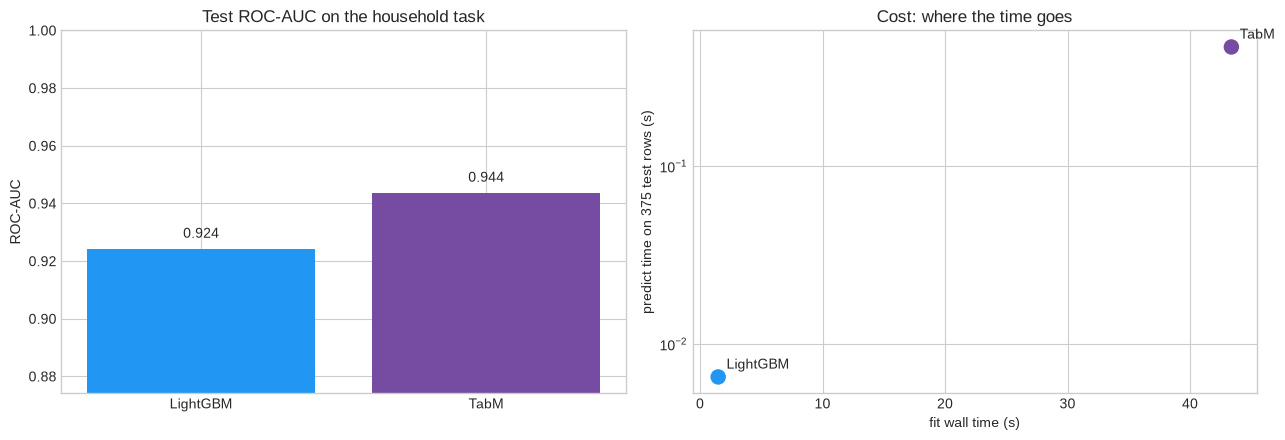

Fastest predict: LightGBM (0.007 s); best ROC-AUC: TabM (0.944)


In [104]:
# ============================================================
#  Picture: quality vs cost for the families that ran
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = list(frontier_cards.index)
colors = ["#2196F3", "#764ba2", "#28a745"][:len(names)]
axes[0].bar(names, frontier_cards["roc_auc"], color=colors)
axes[0].set_ylim(max(0.5, frontier_cards["roc_auc"].min() - 0.05), 1.0)
axes[0].set_title("Test ROC-AUC on the household task"); axes[0].set_ylabel("ROC-AUC")
for i, v in enumerate(frontier_cards["roc_auc"]):
    axes[0].text(i, v + 0.004, f"{v:.3f}", ha="center", fontsize=10)
axes[1].scatter(frontier_cards["fit_s"], frontier_cards["pred_s"], s=160, c=colors, edgecolor="white", linewidth=1.5, zorder=3)
for n, x, y in zip(names, frontier_cards["fit_s"], frontier_cards["pred_s"]):
    axes[1].annotate(n, (x, y), xytext=(6, 6), textcoords="offset points", fontsize=10)
axes[1].set_xlabel("fit wall time (s)"); axes[1].set_ylabel(f"predict time on {len(test_tab)} test rows (s)")
axes[1].set_yscale("log"); axes[1].set_title("Cost: where the time goes")
plt.tight_layout(); plt.show()
print(f"Fastest predict: {frontier_cards['pred_s'].idxmin()} ({frontier_cards['pred_s'].min():.3f} s); "
      f"best ROC-AUC: {frontier_cards['roc_auc'].idxmax()} ({frontier_cards['roc_auc'].max():.3f})")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: test ROC-AUC for every family that ran, with the gap printed under the table. The test set holds 375 households and about one in six overspends, so re-ranking a handful of positives moves ROC-AUC by a gap of that size; the bars describe this run, they do not settle which family is better. Right: cost. LightGBM predicts in milliseconds; TabM, a deep ensemble, is slower to predict and spends most of its budget on training; a foundation model, when it runs, flips the picture with a near-zero fit and the slowest predict, because inference re-reads the training context. The common misread: treating the left panel as "which model is best". Read it with the right panel: on small data the families are close in quality, so **cost, data size and license decide**.

</div>



## 24.5 TabArena: what actually ranks models in 2026

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 The living benchmark

**TabArena** (Erickson, Purucker, Tschalzev and others; arXiv 20 June 2025; `tabarena.ai`) is a curated, continuously updated benchmark of 51 real tabular tasks, each scored with repeated cross-validation, confidence intervals, and training and inference time. Its authors maintain AutoGluon, and the `tabarena` preset above is the portfolio they benchmark with. Three findings shape 2026 practice:

1. **Foundation models now lead on small and medium data.** RealTabPFN-2.5 is the best single model on the public leaderboard; only AutoGluon's `extreme` preset, an ensemble of many methods trained for hours, beats it. AutoGluon's 1.6.0 release notes (5 August 2026) report TabArena-Lite Elo of **1821** for `noncommercial`, **1745** for `extreme_quality` and **1638** for the 1.5 `extreme` preset (higher is better).
2. **Gradient-boosted trees are still strong contenders**, in the TabArena paper's own words. CatBoost and tuned LightGBM stay near the top on datasets with many rows, many categoricals, or where inference latency matters; the benchmark caps at 100,000 training rows, which is where most foundation models also cap.
3. **Ensembling across families is what wins**, which is precisely AutoGluon's design. The paper also warns that some deep models are over-represented in ensembles because they overfit the validation set, the stacked-overfitting problem Part 5's `dynamic_stacking` guards against.

</div>

### The honest table: data size vs recommended approach

| Training rows | Recommended first move (2026) | Why |
|---|---|---|
| under 1,000 | a foundation model (`TABPFN-*`, `TABICL`, `MITRA`) alone, plus a LightGBM as a sanity check | ICL priors dominate; trees overfit; the whole context fits on any GPU |
| 1,000 to 10,000 | `best_quality` on CPU, `extreme_quality` on GPU | the ensemble of trees + TabM + foundation models is the TabArena leader here |
| 10,000 to 100,000 | `extreme_quality` on GPU if latency allows; else `best_quality` | TabICLv2 and TabDPT still fit the context; inference cost starts to bite |
| 100,000 to millions | `best_quality` or `high_quality`; GPU trees (Task 25 points to RAPIDS) | foundation models cap at 50k to 500k rows; trees scale linearly |
| many categoricals with high cardinality | CatBoost-heavy portfolios (`best_quality`) | ordered target statistics beat one-hot encodings that TFMs must build |
| strict inference latency (ms per row) | `high_quality` + `refit_full` + `distill` (Part 9) | ICL inference re-reads the training context on every call |
| regression with predictive intervals on small data | `NORI` / `TABPFN-*` with `problem_type="quantile"` | they return full predictive distributions for free |

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Benchmarks are IID; your data is not

TabArena tasks are curated, shuffled, cross-validated tables. The household problem in this course is a **time** problem: features from one month, targets from the next, with drift (Part 9) and leakage traps (Part 4). A foundation model pretrained on IID synthetic tables gets no special protection from either. Whatever the leaderboard says, the split, the metric, and the leakage check come first, and they are the parts AutoML does not automate (Task 1).

</div>



## 24.6 Task 24 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- A tabular foundation model predicts by **in-context learning**: the training table is the prompt, fit is free, and predict re-reads the context, so it is fastest to train and slowest to serve.
- The installed AutoGluon 1.6.3 registers `REALTABPFN-V2`, `REALTABPFN-V2.5`, `TABPFN-2.6`, `TABPFN-3`, `TABICL`, `MITRA`, `TABDPT`, `TABDPT-TURBO`, `NORI`, `TABM` and `REALMLP`; most need a pip extra, every in-context model downloads weights on the first fit, and the TabPFN checkpoints from 2.5 on are non-commercial.
- `extreme_quality` (GPU) and `noncommercial` are the 2026 presets built on these models; `best_quality` remains the CPU recommendation.
- On the household data the families tie within test-set noise; cost, data size and license decide, and TabArena says trees still win on large or high-cardinality data.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `presets_table` | the installed presets with their model portfolio, bagging and stacking settings |
| `registry_table`, `FM_AVAILABLE` | the foundation-model keys, their class, problem types, release, pip extra, and whether that extra is installed here |
| `frontier_fits`, `frontier_cards`, `frontier_failed` | predictors and one report card per family (LightGBM, TabM, and the foundation model if it ran); families that could not run here |
| `family_card(name, pred, secs)` | one report-card row plus fit and predict seconds for any fitted predictor |
| `FM_KEY`, `FM_STATUS` | which foundation model the guarded cell tried, and whether it ran or fell back |

### ➡️ Next Up

Task 25 steps back from AutoGluon: how it compares with PyCaret, RAPIDS and a hand-built pipeline, how to use the Colab GPU, what agentic AutoML adds, and a flowchart for choosing.

</div>


# Task 25 · AutoGluon in the 2026 Toolbox

## 25.1 Four ways to do the same job

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition: they optimise different things

Every tool in this table can fit the household classifier. They differ in what they make cheap: AutoGluon makes **accuracy per hour of your time** cheap; PyCaret makes the **lifecycle** (setup, compare, tune, interpret, deploy) cheap to write; RAPIDS makes **rows per second** cheap on a GPU; a hand-built scikit-learn pipeline makes **control and review** cheap. The right answer depends on which of those is scarce in your project.

</div>

| | **AutoGluon** | **PyCaret** | **NVIDIA RAPIDS (cuDF + cuML)** | **Hand-built pipeline** |
|---|---|---|---|---|
| What it is | AutoML: portfolio + bagging + stacking + foundation models | low-code lifecycle wrapper around scikit-learn and friends | GPU drop-in for pandas and scikit-learn | `ColumnTransformer` + estimator + your own CV |
| Best at | highest accuracy for the least code; text, time series, multimodal in one API | quick comparison of many models, one-line tuning, MLflow logging | speed on millions of rows; GPU tree ensembles, k-NN, clustering | full control, auditable, minimal dependencies |
| Typical fit | `TabularPredictor(label).fit(df, presets=..., time_limit=...)` | `setup(df, target); compare_models(); tune_model(); finalize_model()` | `cuml.ensemble.RandomForestClassifier`, `xgboost` with `device="cuda"` | `Pipeline([("prep", ColumnTransformer(...)), ("model", HistGradientBoostingClassifier())])` |
| Cost | large install, minutes of training, big model directories (Part 9) | medium install; models are scikit-learn objects | needs an NVIDIA GPU; no foundation models | your time to write and test it |
| Choose it when | you need the best model and can spend compute | a team wants one notebook from EDA to deployment | data is too large for CPU and latency matters | the model must be explained line by line (regulated, or small) |
| Explainability | permutation importance, SHAP wrapper (Part 6) | built-in `interpret_model` (SHAP) | SHAP via the GPU estimators | whatever you add |

## 25.2 Using the Colab GPU

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: ask for the GPU once, at `fit`

In Colab, choose **Runtime → Change runtime type → T4 GPU** before running the setup cell. Then pass `num_gpus=1` to `fit` (or `ag_args_fit={"num_gpus": 1}` to give it to every model). LightGBM, CatBoost, XGBoost, the torch networks and every foundation model pick it up; the `extreme_quality` preset assumes it. The next cell detects the device and builds the call, so the same notebook runs on CPU and GPU without edits.

</div>


In [105]:
# ============================================================
#  Detect the accelerator and fit with the matching resource arguments
# ============================================================
import torch
NUM_GPUS = 1 if torch.cuda.is_available() else 0
device_name = torch.cuda.get_device_name(0) if NUM_GPUS else "CPU only"
fit_kwargs = {"time_limit": 20, "presets": "medium_quality", "num_cpus": SAFE_N_CPUS, "num_gpus": NUM_GPUS,
              "ag_args_fit": {"num_gpus": NUM_GPUS}, "hyperparameters": {"GBM": {}, "XGB": {}}}
print(f"Accelerator: {device_name}  ->  num_gpus={NUM_GPUS}")
print("fit call:", "TabularPredictor(label=LABEL_CLS, eval_metric='roc_auc').fit(train_tab, " +
      ", ".join(f"{k}={v!r}" for k, v in fit_kwargs.items()) + ")")
with timer("fit with explicit resources"):
    gpu_pred = TabularPredictor(label=LABEL_CLS, eval_metric="roc_auc", path=tempfile.mkdtemp(), verbosity=0).fit(train_tab, **fit_kwargs)
print(gpu_pred.leaderboard(test_tab, silent=True)[["model", "score_test", "fit_time", "pred_time_test"]].round(4).to_string(index=False))
recommended = "extreme_quality" if NUM_GPUS else "best_quality"
print(f"\nRecommended top preset for this runtime (AutoGluon 1.6 docs): presets='{recommended}'")


Accelerator: CPU only  ->  num_gpus=0
fit call: TabularPredictor(label=LABEL_CLS, eval_metric='roc_auc').fit(train_tab, time_limit=20, presets='medium_quality', num_cpus=2, num_gpus=0, ag_args_fit={'num_gpus': 0}, hyperparameters={'GBM': {}, 'XGB': {}})


⏱️ fit with explicit resources: 3.86 s
              model  score_test  fit_time  pred_time_test
WeightedEnsemble_L2      0.9281    2.6787          0.0309
            XGBoost      0.9272    0.5795          0.0208
           LightGBM      0.9241    2.0487          0.0066

Recommended top preset for this runtime (AutoGluon 1.6 docs): presets='best_quality'


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ A GPU does not make a small fit faster

On a table this small, `num_gpus=1` would leave the leaderboard above essentially unchanged: tree models on small tables are bound by tree construction, not by matrix arithmetic, and the GPU's start-up cost can exceed the fit. The GPU pays off in three places only: foundation-model inference (12 to 63x, per the model docstrings), neural networks on large tables, and RAPIDS-scale row counts. Request it for those; leave it off for a 30 s LightGBM.

</div>



## 25.3 Agentic AutoML: the next layer up

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 AutoGluon Assistant and MLZero

Everything in this course still required *you* to frame the problem, build the table, choose the metric and read the leaderboard. **AutoGluon Assistant** (the `autogluon.assistant` package) is the AutoGluon team's answer to that layer: an LLM-driven multi-agent system, described in the paper *MLZero: A Multi-Agent System for End-to-end Machine Learning Automation* (arXiv 2505.13941, NeurIPS 2025), that takes a folder of raw files and a natural-language description, perceives the data, selects a library (AutoGluon tabular, time series or multimodal), writes and runs the code, and debugs its own failures with semantic and episodic memory. The paper reports a 92% success rate on its multimodal AutoML benchmark and 86% on MLE-bench Lite.

What it does not change: the checks in this course are the ones the agent must still pass. Ask it for the split it used, the metric it optimised, and the leakage test it ran; Task 10's smoking gun (`feature_importance` concentrated on a column that is a function of the label) is as easy for an agent to fall into as for a person. No code here, because the assistant needs an LLM API key; the pattern is the point.

</div>

## 25.4 When to graduate to deep learning

| Signal | Stay with AutoGluon tabular | Move to a deep-learning stack |
|---|---|---|
| Data type | one row per entity; numbers, categories, short text | images, audio, long documents, graphs, raw sequences |
| Structure | features are meaningful columns | the features must be *learned* (pixels, tokens, waveforms) |
| Rows | thousands to a few million | millions, or a pretrained backbone to fine-tune |
| Text column | short, templated notes (Part 8 showed n-grams tie with a transformer) | long free text where meaning, not keywords, carries the signal |
| Time series | many short series, known covariates | one very long high-frequency series, or multivariate with cross-effects |
| Team | wants a leaderboard by lunch | can afford GPU training loops, tuning, and MLOps for checkpoints |

AutoGluon itself is the bridge: `MultiModalPredictor` (Part 8) and `TimeSeriesPredictor` with Chronos (Part 7) are deep learning behind the same three-line API, so "graduating" often means changing the predictor class, not the toolbox.



## 25.5 The decision flowchart

```text
Start: a prediction problem on structured data
│
├─ Is one row = one entity with named columns?
│    ├─ No  ──▶ images / audio / long text / graphs ──▶ deep learning stack
│    │                                                  (or MultiModalPredictor as the bridge)
│    └─ Yes
│        │
│        ├─ Is the target next-period, with time order? ──▶ split by time first (Part 4), then continue
│        │
│        ├─ How many training rows?
│        │    ├─ < 10k  ──▶ GPU available?  ──▶ yes: presets="extreme_quality" (or a TFM alone)
│        │    │                               └▶ no : presets="best_quality"
│        │    ├─ 10k–100k ──▶ best_quality (CPU) / extreme_quality (GPU)
│        │    └─ > 1M  ──▶ high_quality + refit_full, or RAPIDS / GPU trees
│        │
│        ├─ Strict per-row latency? ──▶ refit_full + distill + infer_limit (Part 9)
│        ├─ Commercial product?     ──▶ avoid `noncommercial`; check every model's license
│        ├─ Must explain every prediction line by line? ──▶ presets="interpretable" or a hand-built pipeline
│        └─ Need a whole lifecycle in one notebook for a team? ──▶ PyCaret; keep AutoGluon as the accuracy ceiling
│
└─ Always: metric matches the business question (Part 2), threshold on validation (Part 3),
           leakage check (Part 4), drift monitor (Part 9), error analysis by segment (Part 10)
```



## 25.6 Task 25 Summary

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Key Takeaways

- AutoGluon buys accuracy per hour of your time; PyCaret buys lifecycle brevity; RAPIDS buys rows per second on a GPU; a hand-built pipeline buys control. Pick by what is scarce.
- `num_gpus=1` (or `ag_args_fit={"num_gpus": 1}`) at `fit` is all the GPU wiring AutoGluon needs; it only pays off for foundation models, neural networks and large tables.
- Agentic AutoML (AutoGluon Assistant / MLZero) automates the framing layer above `fit`, and must still pass the same split, metric and leakage checks.
- Graduate to a deep-learning stack when the features must be learned; `MultiModalPredictor` and Chronos are the bridge inside AutoGluon.

### 🔑 New variables

| Variable | Meaning |
|---|---|
| `NUM_GPUS`, `device_name` | the detected accelerator, and the `num_gpus` value passed to `fit` |
| `fit_kwargs`, `gpu_pred` | the resource-aware fit arguments and the predictor they produced |
| `recommended` | the top preset the 1.6 docs recommend for this runtime |

### ➡️ Next Up

The closing section: a cheat sheet of every API this course used, the metric table, the pitfalls, and where to go next.

</div>


---

# 🏆 Cheat Sheet

## The API (AutoGluon 1.6)

| I want to… | Call | Part |
|---|---|---|
| create a classifier / regressor | `TabularPredictor(label, problem_type=None, eval_metric="roc_auc", path=tmp, verbosity=0)` | 1, 4 |
| quantile regression | `TabularPredictor(label, problem_type="quantile", quantile_levels=[0.1, 0.5, 0.9])` | 4 |
| fit with a budget | `.fit(train, time_limit=60, presets="medium_quality", num_cpus=SAFE_N_CPUS, num_gpus=0)` | 1, 5 |
| bag and stack | `.fit(..., num_bag_folds=5, num_bag_sets=1, num_stack_levels=1, dynamic_stacking="auto")` | 5 |
| choose the models | `.fit(..., hyperparameters={"GBM": [{}, {"num_leaves": 127}], "CAT": {}, "TABM": {}}, excluded_model_types=["KNN"])` | 5, 11 |
| tune hyperparameters | `.fit(..., hyperparameter_tune_kwargs="auto")` | 5 |
| see every model | `.leaderboard(test, extra_info=False, silent=True)` · `.model_names()` · `.model_best` | 2 |
| score it | `.evaluate(test, auxiliary_metrics=True)` · `report_card(y, y_pred, y_prob)` | 2 |
| predict | `.predict(test)` · `.predict_proba(test)[1]` | 1 |
| threshold | `.calibrate_decision_threshold(val, metric="f1")` → `.set_decision_threshold(t)` | 3 |
| importance | `.feature_importance(test, num_shuffle_sets=5)` | 6 |
| persist and reload | `.save()` · `TabularPredictor.load(path)` · `.clone_for_deployment(path)` | 9 |
| speed up serving | `.refit_full()` · `.persist()` · `.distill(time_limit=30)` · `.fit(..., infer_limit=0.001)` | 9 |
| keep training | `.fit_extra(hyperparameters=..., time_limit=...)` | 9 |
| shrink the directory | `.delete_models(models_to_keep="best")` | 9 |
| foundation models | `hyperparameters={"TABICL": {}}` / `"REALTABPFN-V2"` / `"MITRA"` (pip extra required) · `presets="extreme_quality"` on GPU | 11 |
| time series | `TimeSeriesDataFrame.from_data_frame(df, id_column, timestamp_column)` → `TimeSeriesPredictor(prediction_length=3, freq="MS", eval_metric="MASE", quantile_levels=[0.1, 0.5, 0.9]).fit(train, presets="fast_training", time_limit=90)` | 7 |
| zero-shot forecasting | `hyperparameters={"Chronos": {"model_path": "bolt_tiny"}}` | 7 |
| text + numbers | `MultiModalPredictor(label).fit(df, time_limit=120, hyperparameters={"model.hf_text.checkpoint_name": ...})` | 8 |

## Metrics: when to use which

| Metric | Family | Use when | It lies when |
|---|---|---|---|
| accuracy | threshold | classes balanced, costs equal | 17% positives: "always no" scores 83% (Part 2) |
| balanced accuracy, MCC | threshold | imbalance, one number for the confusion matrix | the threshold was tuned on the test set (Part 3) |
| precision / recall / F1 | threshold | asymmetric costs; pick via a cost curve | reported without the threshold that produced them |
| ROC-AUC | ranking | comparing models, any prevalence | heavy imbalance hides poor precision at the top |
| PR-AUC (average precision) | ranking | rare positives, top-of-list matters | prevalence differs between validation and production |
| log loss | probabilistic | you act on probabilities; the default AutoML objective | a few confident mistakes dominate the mean |
| Brier, ECE, reliability diagram | calibration | probabilities feed a decision or a cost model | calibrated on average but not per segment (Part 10) |
| MAE / MedAE | regression | errors in the target's units; robust to outliers | you need to punish large misses |
| RMSE | regression | large errors are expensive | heavy tails; one outlier sets the score |
| MAPE | regression | stakeholders think in percent | targets near zero |
| R² | regression | quick relative fit; near 1 is a leak alarm (Part 4) | comparing across datasets with different variance |
| pinball loss, coverage | quantile / interval | probabilistic forecasts and intervals (Parts 4, 7) | coverage reported without width |
| MASE, WQL, sMAPE | forecasting | scale-free comparison across series (Part 7) | seasonal naive was never run as the baseline |

## The budget dial

`time_limit` first → `presets` (`medium` → `best` on CPU, `extreme` on GPU) → bagging and stacking → `hyperparameters` last (Part 5). Every model directory in `tempfile.mkdtemp()`; `verbosity=0` in notebooks; `RANDOM_STATE` everywhere.



---

# ⚠️ Common Pitfalls to Avoid

1. **Trusting `score_val` as the final answer** (Task 2). It is AutoGluon's own holdout, used to pick the ensemble; report `score_test` on data the predictor never saw.
2. **Accuracy on 17% positives** (Task 4). Read balanced accuracy, MCC, PR-AUC and log loss together; the report card exists so you never read one metric alone.
3. **Picking the threshold on the test set** (Task 7). `calibrate_decision_threshold` on validation data; the test set is for the number you report.
4. **Predicting this month's total from this month's categories** (Task 10). R² near 1 and importance concentrated on a column that is a function of the label is a leak, not a triumph.
5. **Adding hyperparameters before adding time** (Task 13). A longer `time_limit` with `best_quality` beats a hand-typed search space almost every time.
6. **Stacking without out-of-fold predictions** (Task 12). Stack levels must learn from OOF predictions or they overfit; `dynamic_stacking="auto"` detects the leak for you.
7. **Skipping the naive baselines in forecasting** (Task 16). Seasonal naive is the bar; a model that does not beat it has learned nothing.
8. **Paying for a transformer on templated text** (Task 18). Compare with and without the text column, then n-grams vs a backbone; the cost table decides.
9. **Shipping the full bagged ensemble** (Tasks 19-20). `refit_full`, `persist`, `distill` and `infer_limit` exist because bagged models are slow; measure single-row latency with `timer`.
10. **Deploying without a drift monitor** (Task 21). PSI per feature and a prediction-distribution plot cost minutes; a silent drift costs months.
11. **Averaging over segments** (Task 22). A model can beat the base rate overall and lose on `town` households; check calibration and error rate per segment.
12. **Typing a foundation-model key from a blog post** (Task 24). Print `ag_model_registry.keys`, install the extra, check the license, and fit with `raise_on_model_failure=True`.



---

# 🚀 What's Next

1. **Re-run Part 11 on a GPU.** Switch the Colab runtime to T4, `pip install "autogluon.tabular[tabicl]==1.6.3"`, and let the guarded cell add its third bar. Then try `presets="extreme_quality"` at 300 s and compare with Task 11's curve.
2. **Replace the synthetic data with yours.** Keep the three habits the generator forced: a next-period target, a time-aware split, and the leakage check. Everything else in the notebook runs unchanged on any household-shaped table.
3. **Wire the monitoring loop.** Take Task 21's PSI code and Task 19's `clone_for_deployment` directory and schedule them: score daily, alert on drift, refit with `fit_extra` when labels arrive.
4. **Read the TabArena leaderboard** at `tabarena.ai` once a quarter. The ranking changes; the questions in the decision flowchart do not.
5. **Try AutoGluon Assistant** on a folder of raw files with an LLM key, and audit its output with Tasks 10, 22 and 23.

### Where to go deeper

| Topic | Start here |
|---|---|
| Presets, bagging, stacking | AutoGluon tabular "In Depth" tutorial and `TabularPredictor.fit` docstring |
| Foundation models in AutoGluon | tutorial *AutoGluon Tabular - Foundational Models* (1.6 docs) |
| Forecasting | AutoGluon time-series tutorials; Chronos model cards |
| Multimodal | AutoGluon multimodal tutorials (`MultiModalPredictor`) |
| Benchmarks | TabArena paper and `tabarena.ai` leaderboard |
| Other notebooks in this repository | `colabs/06_data_eval_mlops/pycaret_zero_to_hero.ipynb`, `colabs/06_data_eval_mlops/nvidia_rapids_zero_to_hero.ipynb`, `colabs/08_data_mining/logistic_regression_zero_to_hero.ipynb` (the metric families in depth) |

---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 34px; border-radius: 20px; color: white; text-align: center; margin: 24px 0;">

## 🎓 Course Complete

You started with a household budget export and a three-line `fit`.

You finish able to read a leaderboard, choose a metric that matches the question, tune a threshold, calibrate a probability, spot a leak, dial time against quality, forecast with intervals, combine text with numbers, explain a prediction, ship a small fast model, watch it drift, find where it fails by segment, and pick a 2026 foundation model when the data size and the license say so.

The most valuable thing you learned is not an argument to `fit`. It is the question to ask of every leaderboard:

### *"What did the model never see, and is that the number I am reporting?"*

Now go and fit something on data that matters.

</div>



---

# 📚 References

**AutoGluon**
- Erickson, N., Mueller, J., Shirkov, A., Zhang, H., Larroy, P., Li, M., Smola, A. *AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data.* arXiv:2003.06505 (2020).
- AutoGluon documentation, `auto.gluon.ai`: tabular in-depth, foundational models, time series and multimodal tutorials; *What's New* for 1.4.0 (July 2025: Mitra, TabPFNv2, TabICL, RealMLP, TabM), 1.5.0 (December 2025: RealTabPFN-2.5, TabDPT, TabPrep), 1.6.0 (5 August 2026: Nori, TabPFN-3, TabDPT-Turbo, TabPFN-2.6, TabICLv2; `extreme_quality` and `noncommercial` presets). Installed version verified in this notebook: 1.6.3.
- Shchur, O. et al. *AutoGluon-TimeSeries: AutoML for Probabilistic Time Series Forecasting.* AutoML Conference 2023.
- Ansari, A. F. et al. *Chronos: Learning the Language of Time Series.* TMLR 2024; Chronos-Bolt model cards (Hugging Face).

**Benchmarks**
- Erickson, N., Purucker, L., Tschalzev, A. et al. *TabArena: A Living Benchmark for Machine Learning on Tabular Data.* arXiv:2506.16791 (20 June 2025); leaderboard at `tabarena.ai`.

**Tabular foundation models**
- Hollmann, N., Müller, S., Purucker, L. et al. *Accurate predictions on small data with a tabular foundation model* (TabPFN v2). Nature, 8 January 2025.
- Prior Labs. *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models.* arXiv:2511.08667 (November 2025); TabPFN-2.6 and TabPFN-3 model reports, `priorlabs.ai` (2026).
- Qu, J., Holzmüller, D., Varoquaux, G., Le Morvan, M. *TabICL: A Tabular Foundation Model for In-Context Learning on Large Data.* ICML 2025 (arXiv:2502.05564); *TabICLv2: A better, faster, scalable, and open tabular foundation model.* arXiv:2602.11139 (February 2026).
- Zhang, X., Maddix, D. C., Yin, J., Erickson, N. et al. *Mitra: Mixed synthetic priors for enhancing tabular foundation models.* NeurIPS 2025.
- Synthefy. *Nori: a tabular foundation model for regression via in-context learning.* `github.com/synthefy/synthefy-nori` (2026).
- Gorishniy, Y. et al. *TabM: Advancing Tabular Deep Learning with Parameter-Efficient Ensembling.* ICLR 2025. Holzmüller, D. et al. *Better by Default: Strong Pre-Tuned MLPs and Boosted Trees on Tabular Data* (RealMLP). NeurIPS 2024.
- Müller, S. et al. *Transformers Can Do Bayesian Inference* (the PFN idea). ICLR 2022.

**Agentic AutoML**
- Fang, H. et al. *MLZero: A Multi-Agent System for End-to-end Machine Learning Automation.* NeurIPS 2025 (arXiv:2505.13941); AutoGluon Assistant, `github.com/autogluon/autogluon-assistant`.

**Metrics and calibration**
- Saito, T., Rehmsmeier, M. *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets.* PLOS ONE 2015.
- Guo, C. et al. *On Calibration of Modern Neural Networks.* ICML 2017.
- Hyndman, R. J., Koehler, A. B. *Another look at measures of forecast accuracy* (MASE). IJF 2006.

---

<div style="text-align: center; color: #5F6368; font-size: 0.9em; padding: 12px;">
Built for the CMPE 258 zero-to-hero Colab series · verified against <b>AutoGluon 1.6.3</b> · every cell runs on a free Colab CPU; the foundation-model cell falls back when its extra is missing
</div>
